# Semantic Interference in Language-Model Decision Making: A Mechanistic Study of Strategic Invariance

### CSS-Bench: An Experimental Apparatus for Testing Decision-Relevant Invariances in Language Models

**Author:** S M Jubaer &nbsp;|&nbsp; **Compute:** 2× NVIDIA A10G &nbsp;|&nbsp; **Code & data:** dataset generator and analysis pipeline in this notebook; reproducibility details in Part K

---

## The question, in one sentence

**If I change only what an action is called, should a language model change what it does?**

In a normal-form game, relabeling "Cooperate" as "Exploit" does not change which action
yields the higher payoff. A decision procedure that tracks payoffs should be invariant to
that relabeling. This notebook builds a controlled apparatus for testing whether language
models satisfy that invariance, and (where they don't) for localizing *where in the
network* payoff-irrelevant semantic information enters the computation that produces the
decision, whether that entry is *causal* (not merely correlational), and whether it can be
*removed at inference time* without retraining.

## Abstract *(placeholder structure, see note below)*

We study whether large language models' decisions in matrix games remain invariant under
**utility-preserving semantic transformations**: relabelings of an action that change its
linguistic connotation while leaving the underlying payoff structure, and the
decision-relevant ordering over actions, exactly fixed (Definition 1.2). We introduce
**CSS-Bench**, a procedurally generated apparatus spanning three game topologies (Prisoner's
Dilemma, Chicken, Stag Hunt), a **taxonomy of semantic projections** ranging from neutral
placeholders through valence, moral, social, role, and prestige framings (Part C.2), and an
explicit **numerical-difficulty factor** (the payoff margin separating the two actions,
Part C.3): a factorial design over game × difficulty × projection × label identity ×
presentation order. Evaluating eight open-weight models (0.41–8.03B parameters, four
architecture families, including a matched base/instruction-tuned pair on identical
weights), we [FINDING 1: report the overall rate and magnitude of strategic-invariance
violation, and its dependence on projection category and numerical difficulty; dose-response
results depend on execution against real weights, not yet run in this authored draft].
We then localize *where* payoff-irrelevant semantic information becomes represented
(three linear probes (payoff-optimal action, label valence, and the model's own eventual
decision) decoded across network depth, Part F.3) and *when it becomes causally coupled*
to the decision (layer- and position-targeted activation patching, Part E), finding
[FINDING 2]. A depth-indexed geometric analysis of the residual-stream trajectory
(Part H, redesigned in this iteration to index network depth rather than a
task-specific text segmentation, for validity across future task variants) provides
convergent, independently-derived evidence for the same transition. Finally, we test
whether targeted activation steering can suppress the causal pathway and restore
invariance without retraining (Part G), finding [FINDING 3]. We pair every causal claim
with matched behavioral controls (order-swap, payoff-only-swap) and lexical/positional
controls (Part J) designed to distinguish genuine semantic interference from six
identified alternative explanations (Part J.1), and report all multi-model, multi-layer
comparisons under Benjamini-Hochberg correction (statistical procedure detailed in Part I;
not restated here).

*Note on this abstract: the bracketed `[FINDING n]` placeholders mark claims that require
actually running this notebook against real model weights, which this authored draft has
not done (Part K documents exactly what has and hasn't been executed). This is deliberate
per the review this notebook incorporates, a finished abstract should report discoveries,
not a research plan, and filling in genuine numbers before genuine execution would be
worse than leaving the placeholders visible.*

## Contributions

1. **A formal invariance framework for LLM decision-making.** We define utility-preserving
   semantic transformations and strategic invariance (Part 0) as a general property a
   decision procedure either does or does not satisfy (not specific to any one benchmark)
   and position CSS-Bench as the first case study of this broader class of decision-relevant
   invariance tests (temporal invariance, role invariance, and framing invariance are
   natural extensions, discussed in Part L).
2. **A systematic characterization of semantic interference.** Across models, six semantic
   projection categories, and a controlled numerical-difficulty factor, we quantify *when*
   and *how strongly* payoff-irrelevant semantic information competes with payoff
   information, rather than reporting a single valence-manipulation result that invites the
   "this is just lexical bias" objection.
3. **A causal account, not just a correlational one.** Through three targeted linear probes,
   layer- and position-resolved activation patching, and a depth-indexed geometric analysis,
   we identify where semantic information becomes represented and test (causally, via
   intervention, not by proxy) whether it actually controls the decision.
4. **A controlled post-training comparison.** A matched base/instruction-tuned pair on
   identical weights (Llama-3.2-1B) tests whether instruction-tuning changes sensitivity to
   semantic interference, holding architecture and pretraining fixed.
5. **An inference-time mitigation test.** We test whether targeted activation steering can
   reduce semantic interference and recover strategic invariance without retraining, and
   report the accuracy cost, if any, of doing so.

*(Reproducibility and engineering (the architecture-agnostic model interface, offline unit
tests, and end-to-end mock-backend validation) are real contributions to this notebook's
trustworthiness but are not scientific claims; they are documented in Part K rather than
counted among the five above, per the same review.)*

## Terminology:

Calling the phenomenon under study a "shortcut" before establishing that it is one begs the
question a skeptical reviewer will ask first. We use a graded vocabulary instead, and only
use the strongest term once the corresponding evidence tier has actually been established:

| Term | Claim it licenses | Evidence required |
|---|---|---|
| **Semantic sensitivity** | The model's output logits differ when a label's connotation is changed. | Behavioral detection (Part D) |
| **Semantic dependence** | The model's *representations* linearly encode label valence, decodably, in addition to payoff information. | Linear probing (Part F.3) |
| **Causal semantic interference** | The semantic representation *causally* affects the decision (not merely correlates with it). | Activation patching (Part E), and convergent geometric evidence (Part H) |
| **Semantic shortcut** | Causal interference specifically causes the model to choose the numerically *inferior* action. | All of the above, on instances where accuracy actually drops |

We also distinguish three failure *types*, so a finding at one level is never overstated
into a claim at another:

- **Type I - Lexical sensitivity.** The model's output changes when labels change. Not
  necessarily concerning; a model that reads the labels at all will show this.
- **Type II - Semantic influence.** The change in output correlates with label meaning
  (valence, morality, etc.), not just lexical identity.
- **Type III - Decision-level interference (the actual failure mode).** The model chooses
  the numerically *inferior* action because of label semantics. This is the only level at
  which we use the word "shortcut."

*(Internal code identifiers in this notebook - e.g. `deltaA_shortcut`,
`top_shortcut_heads` - predate this terminology pass and are kept as-is for cell-to-cell
consistency; the prose in every markdown cell uses the graded vocabulary above.)*

## The epistemic structure of the analysis pipeline

Six analysis techniques appear in this notebook. Rather than presenting them as six
independent contributions, we organize them by what kind of evidence each one can and
cannot provide, following a Detection → Localization → Causality → Intervention structure:

```
                    CENTRAL QUESTION
     What controls an LLM's strategic decision: payoff
        structure, semantic identity, or their coupling?
                          │
          ┌───────────────┴────────────────┐
          │                                 │
   TIER 1 - DETECTION                TIER 2 - LOCALIZATION
   Behavioral invariance (Part D.1)   Logit-lens trajectory (Part D.2)
   + Linear probing (Part F.3)        + Depth-indexed geometry (Part H)
   "Is semantic info represented,     "When/where in the network does
    and does behavior change?"         it emerge?"
          │                                 │
          └───────────────┬─────────────────┘
                           ▼
                 TIER 3 - CAUSALITY
        Layer- & position-targeted activation
        patching (Part E); attention-head
        dissection (Part F.1) as SUPPORTING,
        correlational evidence only, attention
        weight is not causal evidence on its own
        "Does the representation actually
         control the decision?"
                           │
                           ▼
                 TIER 4 - INTERVENTION
              Activation steering (Part G)
        "Can we suppress it without retraining?"
```

Attention-head dissection is deliberately demoted to *supporting* evidence: attention mass
on a token is not the same as that token's causal contribution to the output, and a
"head 17 attends to the word Kind" finding, alone, would not survive review. It remains in
the pipeline because it is cheap to compute from the same forward pass patching already
requires, and because it *localizes candidates* for more expensive causal follow-up, not
because attention is itself evidence of control.


## Related Work

**Strategic and economic reasoning in LLMs.** A growing line of work studies LLM behavior
in classic game-theoretic settings, repeated Prisoner's Dilemma and public-goods games
(e.g. Akata et al., 2023; Fontana et al., 2024), auction and negotiation environments, and
systematic biases in LLM-driven economic decisions relative to rational-agent baselines.
This literature typically evaluates *aggregate* behavioral tendencies (cooperation rates,
elicited "personality"); CSS-Bench instead isolates a specific, mechanistically
localizable failure mode and asks *where* in the network it originates and *whether it is
causal*, rather than only whether it occurs in aggregate.

**Activation patching and causal circuit analysis.** Activation patching (also "causal
tracing" or "interchange intervention") [transplanting cached activations from a clean
run into a corrupted run to measure recovery of correct behavior] has been used to
localize factual recall (Meng et al., 2022, ROME), name-mover circuits in indirect object
identification (Wang et al., 2023, IOI), and induction-head formation (Olsson et al.,
2022). We adopt this method (Part E) and are explicit about a construction pitfall it
surfaced during development: scoring clean and corrupted runs against *different* literal
tokens silently produces an uninformative null curve (documented in Part E), consistent
with prior guidance (Zhang & Nanda, 2023) that patching metric choice is not a free
parameter.

**Activation steering.** Subtracting or adding a direction in the residual stream to
suppress or induce a behavior (without gradient updates) has been used for style and
sentiment control (Turner et al., 2023, ActAdd) and for refusal/safety-relevant directions
(Rimsky et al., 2024, CAA; Arditi et al., 2024). Our steering vector (Part G) is this
technique applied to a direction derived specifically from instances where the behavioral
failure is active, a targeted-fitting choice we found necessary after an initial
all-pair-averaged fit produced a direction that *degraded* accuracy when subtracted
(documented in Part G).

**Probing classifiers.** Training a simple classifier on frozen intermediate
representations to test whether a concept is linearly decodable is standard
interpretability practice (Alain & Bengio, 2016; Belinkov, 2022, survey). Part F.3 extends
this with three targeted probes (payoff-optimal action, label valence, model decision) and
an explicit **train-on-canonical, test-on-counterfactual** generalization split, directly
analogous to the model's own behavioral generalization gap but applied to an independently
fit linear classifier on frozen activations.

**Geometry of representation space.** Zhou, Wang, Yin, Zhou & Zhang (2026), *"The Geometry
of Reasoning: Flowing Logics in Representation Space"*, model chain-of-thought reasoning as a continuous trajectory in representation
space and show that trajectory *velocity* and *Menger curvature* (not raw position) track
logical structure invariantly across semantic carrier. Their trajectory axis is
multi-step chain-of-thought generation, where each step is a genuine inferential move.
CSS-Bench is a single forced-choice decision with no such steps; Part H discusses why we
redesigned the trajectory axis to index **network depth** rather than forcing a
task-specific text segmentation into the role of "reasoning step".

**Content effects and belief bias (cognitive-science grounding for the hypothesis itself).**
The prediction that a payoff-irrelevant label's valence should compete with a formal
payoff comparison is not an ad hoc hypothesis specific to games: it is the LLM analogue of
*content effects* in human syllogistic reasoning, where believable conclusions are judged
valid more often regardless of logical form (Dasgupta et al., 2024, arXiv:2207.07051;
Bertolazzi et al., 2024). Valentino, Kim, Dalal, Zhao & Freitas (2025/2026,
arXiv:2505.12189) show these content effects in LLMs are linearly steerable at specific
layers, and that a *static* steering vector fails on models that are otherwise
"unresponsive," motivating their conditional (kNN-gated) steering method, K-CAST. This is
directly relevant to Part G: our current design sweeps a fixed steering coefficient
$\alpha$ across all instances; Valentino et al.'s result predicts this static design should
underperform on some models in the suite, and motivates a conditional variant (apply
steering only where a lightweight classifier detects the interference signature is active)
as a concrete, literature-motivated extension rather than a speculative one — see the note
added to Part G below.

**Concurrent invariance/framing benchmarks (2026).** Several benchmarks published in the
months before this notebook's submission converge on the same general claim — that LLM
decisions in fixed-payoff or fixed-ground-truth settings are sensitive to
payoff-irrelevant framing — from different angles, and CSS-Bench should be positioned
against them explicitly rather than only against the older repeated-games literature above.
Amiri-Margavi (2026, *Same Game, Different Story*, arXiv:2607.19670) defines "strategic
robustness" as invariance of action distributions under payoff-preserving *narrative*
reframing (business vs. friendship framing of the same social dilemma) and demonstrates
the effect via a **secondary analysis of published aggregate cooperation rates** — an
important, closely related result, but a black-box, aggregate-behavioral one: it offers no
mechanistic account of where or how the framing sensitivity is implemented in the network,
and no causal test isolating it from other prompt differences between the framings
compared. CSS-Bench's matched-pair construction (Definition 0.3) and Tier 1-4 evidence
chain (behavioral through causal) is the natural mechanistic complement to that finding,
not a duplicate of it — Part 12 now says so explicitly (see below). Elkins & Chun (2026,
*Syntactic framing fragility*, arXiv:2601.09724) and the *Framing Matters* benchmark
(arXiv:2605.28188) similarly document framing sensitivity in LLM decisions (ethical
judgments and value-alignment contexts respectively) using purely behavioral methods; none
of the three offers a causal-localization or intervention account, which remains
CSS-Bench's distinguishing contribution and should be stated as such rather than left
implicit, since a reviewer who knows this literature will otherwise read CSS-Bench as
incremental on it.


## Table of Contents

0. [Part 0 - Strategic Invariance: A Formal Framework](#prelim)
1. [Prerequisites & Gated Model Access](#prereqs)
2. [Part A - Model Suite: A Factorial Rationale](#modelsuite)
3. [Part B - RealModelWrapper (architecture-agnostic, hook-based)](#wrapper)
4. [Part C - CSS-Bench: Semantic Projection Taxonomy, Difficulty Factor & Tokenizer Safety](#dataset)
5. [Part D - Tier 1/2: Behavioral Detection & Logit-Lens Localization](#phase1)
6. [Part E - Tier 3: Causal Localization via Activation Patching (layer- and position-targeted)](#phase2)
7. [Part F - Supporting Evidence & Tier 1 Continued: Attention Dissection & Three-Probe Detection](#phase3)
8. [Part G - Tier 4: Intervention via Activation Steering](#phase4)
9. [Part H - Tier 2 Continued: Depth-Indexed Representational Geometry](#phase5)
10. [Part I - Cross-Model Statistics, Multiple-Testing Correction & the Base/Instruct Comparison](#stats)
10.6. [Part M - Frontier-Model Behavioral Spot-Check (API)](#frontierapi)
11. [Part J - Falsification: Behavioral Controls & Alternative Explanations](#controls)
12. [Discussion & Limitations](#discussion)
13. [Part L - Beyond CSS-Bench: A Program of Decision-Relevant Invariance Tests](#program)
14. [References](#references)


> **Re-run status.** All cell outputs below were cleared in this revision. The `neutral` taxonomy fix (4.2) changes the dataset itself, so every downstream number from the previously-executed run (5 models, `ACTIVE_TIERS=["small"]`) is now stale and would be actively misleading if left next to the new code. Re-run top to bottom — ideally with `ACTIVE_TIERS = ["small", "mid"]` (see the note by that setting) for the run that goes in the paper. The two anomalies documented in Section 5's preamble describe what the *previous* run showed and why the numbers below should look different now.

<a id="prelim"></a>
## 0. Part 0 - Strategic Invariance: A Formal Framework

### 0.1 Decision setting

A two-player normal-form matrix game is $G = \langle N, (A_i)_{i \in N}, (u_i)_{i \in N} \rangle$
with $N=\{1,2\}$, each player choosing from $A_i=\{a_1,a_2\}$. We refer to the two actions
as **Slot A** (paying $R$ if the opponent plays Slot A, $S$ if the opponent plays Slot B)
and **Slot B** (paying $T$ if the opponent plays Slot A, $P$ if the opponent plays Slot B).
The **topology** $T$ is fixed by the ordinal relationship among $R,S,T,P$:

$$
T_{\text{PD}}: T>R>P>S,\ 2R>T+S \qquad
T_{\text{Chicken}}: T>R>S>P \qquad
T_{\text{StagHunt}}: R>T>P>S
$$

**On what "correct" means here.** Prisoner's Dilemma, Chicken, and Stag Hunt invoke
different solution concepts (dominant strategy, risk dominance, payoff dominance), and a
benchmark that silently picks one is vulnerable to the objection that it is testing
equilibrium computation, not payoff comparison. We deliberately avoid that by defining the
task at a lower, solution-concept-free level:

**Definition 0.1 (Task).** *Given a fixed opponent action, identify the action yielding
the greater payoff to the row player, using the row-averaged payoff
$\mathrm{avg}_A = R+S$, $\mathrm{avg}_B=T+P$ as the fixed comparison rule; the slot
$\arg\max(\mathrm{avg}_A,\mathrm{avg}_B)$ is correct.* This is not a claim about Nash
equilibrium, risk dominance, or any other solution concept — it is a claim about whether
the model can **compare two numerical quantities under a controlled semantic
transformation of how the corresponding actions are named**. The topology labels
(PD/Chicken/StagHunt) describe the *ordinal shape* of the sampled payoffs, used to
stratify results, not the criterion being scored.

**Proposition 0.2.** *For $T_{\text{PD}}$, Slot B is correct under Definition 0.1 for
every valid instance*, since $T>R$ and $P>S$ together imply $T+P>R+S$ algebraically,
independent of the specific sampled values. This is a parameter-free sanity check on the
dataset generator (Part C verifies it holds for 100% of generated PD instances) — and a
useful falsifiability check for the reader: if PD instances in a released dataset are
*not* uniformly Slot-B-correct, something in the generator is broken.

### 0.2 Utility-preserving semantic transformations and strategic invariance

**Definition 0.3 (Utility-preserving semantic transformation).** Let $L: \{A,B\} \to \Sigma$
be a labeling function assigning each slot a natural-language label from vocabulary
$\Sigma$. A transformation $T(G,L) = (G,L')$ is **utility-preserving** if it changes the
linguistic labeling ($L \neq L'$) while leaving the payoff function and the
decision-relevant ordering over actions unchanged ($G=G'$, and the correct slot under
Definition 0.1 is identical for $L$ and $L'$).

**Definition 0.4 (Strategic invariance).** A decision procedure $f_\theta$ satisfies
strategic invariance with respect to a transformation $T$ if $f_\theta(G,L) = f_\theta(G,L')$
for every $(G,L')=T(G,L)$. This is the general property under test; CSS-Bench (Part C)
instantiates it as a specific, matched-pair-generating family of transformations
(the *semantic projection taxonomy*), but the property itself is not specific to games,
labels, or this benchmark — Part L discusses the broader program this connects to.

**Instantiating $T$ in CSS-Bench.** Each non-neutral semantic projection category
(Part C.2) supplies a positive-valence pool $\Sigma^+$ and negative-valence pool
$\Sigma^-$ (e.g. valence: {Trust, ...} / {Betray, ...}; moral: {Good, ...} / {Evil, ...}).
A rendering function $f: G \times \Sigma \to \mathcal{P}$ instantiates a game under one of
two matched projections:

$$
f_{\text{canon}}: \text{correct slot} \mapsto \Sigma^+,\ \text{incorrect slot} \mapsto \Sigma^- \qquad\qquad
f_{\text{counter}}: \text{correct slot} \mapsto \Sigma^-,\ \text{incorrect slot} \mapsto \Sigma^+
$$

using the *same two literal words* in both — differing only in which slot each is
assigned to, so $T(G, L_{\text{canon}}) = (G, L_{\text{counter}})$ is exactly a
utility-preserving semantic transformation in the sense of Definition 0.3, and
$f_{\text{canon}}, f_{\text{counter}}$ can be scored against the identical token pair
$(\mathrm{id}(\text{pos\_word}), \mathrm{id}(\text{neg\_word}))$ — the fact that makes
Part E's patching metric well-posed.

### 0.3 Terminology progression (Type I/II/III) as formal predicates

Using $f_\theta(G,L)$ for the model's chosen slot and $\text{opt}(G) \in \{A,B\}$ for the
correct slot under Definition 0.1:

- **Type I (lexical sensitivity):** $\exists (G,L,L')$ utility-preserving with
  $f_\theta(G,L) \neq f_\theta(G,L')$. (The model's *output* changed at all.)
- **Type II (semantic influence):** Type I holds, and the direction of change correlates
  with the valence/category of $L'$ relative to $L$ across many instances (a population
  statement, tested in Part D.1).
- **Type III (decision-level interference — "shortcut"):** Type II holds, and additionally
  $f_\theta(G,L') \neq \text{opt}(G)$ specifically *because* of the semantic change — i.e.
  accuracy against Definition 0.1's ground truth drops under $L'$ relative to $L$, **and**
  the mechanism producing that drop is shown to be causal (Part E), not merely observed
  (Part D).

### 0.4 Core metrics

For a model $\mathcal{M}$ and instance $x$, let $z_\ell(x) \in \mathbb{R}^{|V|}$ denote the
vocabulary logits obtained by applying $\mathcal{M}$'s final layer norm and unembedding
matrix $W_U$ to the residual stream at layer $\ell$ and the final prompt position:
$z_\ell(x) = W_U \cdot \mathrm{LN}(h_\ell(x))$ (the *logit lens*, Part D.2). Let
$c(x), k(x) \in V$ denote the correct/incorrect label token ids for instance $x$.

**Definition 0.5 (Strategic Invariance Index).**
$$
\mathrm{INV}(x) = \frac{\Delta L_{\text{counter}}(x)}{\Delta L_{\text{canon}}(x)}, \qquad
\Delta L_p(x) = z_{-1}(f_p(x))[c(x)] - z_{-1}(f_p(x))[k(x)]
$$
$\mathrm{INV}=1$: perfect strategic invariance (Definition 0.4 exactly satisfied at the
logit level). $\mathrm{INV}\le 0$: the model's preference *reverses* under the
transformation — a Type III (decision-level) violation on that instance.

**Definition 0.6 (Causal Recovery Score).** For a matched pair with shared token ids
$(p,n) = (\mathrm{id}(\text{pos\_word}), \mathrm{id}(\text{neg\_word}))$, let
$\Delta L^{pn}(x) = z(x)[p] - z(x)[n]$ (evaluated identically on clean and corrupted runs,
per §0.2). Patching layer $\ell$ at position $\pi$ replaces the corrupted run's residual
stream at $(\ell, \pi)$ with the clean run's:
$$
R_{\ell,\pi} = \frac{\Delta L^{pn}_{\text{patched}(\ell,\pi)} - \Delta L^{pn}_{\text{corrupted}}}{\Delta L^{pn}_{\text{clean}} - \Delta L^{pn}_{\text{corrupted}}}
$$
Part E reports $R_{\ell,-1}$ (final position only, varying $\ell$) as the primary sweep,
and Part E.2 additionally reports $R_{\ell^*,\pi}$ for $\pi$ ranging over label-token
positions at the layer $\ell^*$ identified as causally critical — a coarse form of *path
patching* restricted to a single layer's positions, motivated by Meng et al. (2022) and
Wang et al. (2023). This is the primary evidence for a **Type III** claim: causal, not
merely observed.

**Definition 0.7 (Probing generalization gap, three-probe design).** For probe target
$y \in \{\texttt{payoff\_optimal}, \texttt{label\_valence}, \texttt{model\_decision}\}$
(Part F.3), let $g_\ell^y: \mathbb{R}^d \to \{A,B\}$ be a linear classifier fit on
$\{(h_\ell(x), y(x)) : x \in D_{\text{canon}}^{\text{train}}\}$. The generalization gap is
$$
\mathrm{PGap}_\ell^y = \mathrm{Acc}(g_\ell^y; D_{\text{canon}}^{\text{test}}) - \mathrm{Acc}(g_\ell^y; D_{\text{counter}}^{\text{test}})
$$
A large $\mathrm{PGap}_\ell^{\texttt{payoff\_optimal}}$ means the linear direction found
for "which slot is correct" from canonical data alone fails to transfer to counterfactual
data — representational evidence (Definition 0.4's Type II) that the payoff-optimal
direction is confounded with the label-valence direction at layer $\ell$, independent of
the causal (Part E) or behavioral (Part D.1) evidence. Comparing $\mathrm{PGap}^{
\texttt{payoff\_optimal}}$ against the (expected small) $\mathrm{PGap}^{
\texttt{label\_valence}}$ and against $\mathrm{PGap}^{\texttt{model\_decision}}$
across layers is the basis of Part F.3's layer-wise information-content figure.

**Definition 0.8 (Depth-indexed trajectory velocity and curvature).** *Redesigned in this
iteration; see Part H for the full rationale.* For a fixed token position $\pi$ (the final
"MY CHOICE: [" position), let $Y = (h_0(x), h_1(x), \ldots, h_L(x))$ be the residual stream
at $\pi$ across all $L{+}1$ layers (embeddings through the final block). Velocity is
$v_\ell = h_{\ell+1} - h_\ell$ and Menger curvature at interior layer $\ell$ is
$$
\kappa_\ell = \frac{2\sqrt{1-\cos(\angle(v_{\ell-1},v_\ell))^2}}{\lVert h_{\ell+1}-h_{\ell-1}\rVert}
$$
the reciprocal of the circumradius of the triangle $(h_{\ell-1},h_\ell,h_{\ell+1})$ —
identical formula to Zhou et al. (2026)'s Proposition D.8, but with $\ell$ indexing
**network depth** rather than a text-segment position, for the reasons given in Part H.
This trajectory needs no task-specific segmentation and is defined for any decoder-only
transformer on any single-decision task, which is the basis of Part L's discussion of
extending this apparatus to other benchmarks.


<a id="prereqs"></a>
## 1. Prerequisites & Gated Model Access

This notebook downloads real model weights from the Hugging Face Hub. Before running:

1. **`pip install -r requirements.txt`** (torch, transformers, accelerate, jinja2,
   pydantic, matplotlib, seaborn, scipy, pandas, scikit-learn).
2. **Authenticate**: `huggingface-cli login`, or set `HF_TOKEN` as an environment
   variable / Modal secret.
3. **Accept gated model licenses** on the Hub *before* running - downloads will fail
   with a 403 otherwise, not a helpful error. Gated in this suite: all Llama models,
   `google/gemma-2-2b-it`, and Mistral models. Qwen and Pythia models are ungated.
4. **Disk space**: the full 8-model suite totals ~35B parameters; in bf16 that's roughly
   70GB of weights if cached simultaneously. Either provision that much disk, or run
   models sequentially and clear the HF cache (`huggingface-cli delete-cache`) between
   the small and mid-scale tiers.

Run the smoke test in Part A before committing to the full sweep.


In [1]:
import os, sys, json, math, random, itertools, warnings, gc
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 10.5

SEED = 20260829
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

RESULT_DIR = "css_bench_real_results"
FIG_DIR = os.path.join(RESULT_DIR, "figures")
CACHE_DIR = os.path.join(RESULT_DIR, "cache")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

N_GPUS = torch.cuda.device_count()
print(f"CUDA available: {torch.cuda.is_available()}   GPU count: {N_GPUS}")
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f"  cuda:{i} -> {props.name}, {props.total_memory / 1e9:.1f} GB")
if N_GPUS == 0:
    print("WARNING: no GPU detected. This notebook will be extremely slow or "
          "infeasible on CPU for the 7-8B models -- restrict MODEL_REGISTRY to the "
          "small tier below if that's your situation.")


CUDA available: True   GPU count: 1
  cuda:0 -> NVIDIA L40S, 47.7 GB


In [2]:
# Quick auth/license sanity check -- fails fast with a clear message instead of
# a confusing 403 buried inside a later cell.
from huggingface_hub import HfApi, whoami

try:
    who = whoami()
    print(f"Authenticated to Hugging Face Hub as: {who.get('name', who)}")
except Exception as e:
    print("NOT authenticated to the Hugging Face Hub. Run `huggingface-cli login` "
          "or set the HF_TOKEN environment variable before continuing.")
    print(f"  ({e})")


Authenticated to Hugging Face Hub as: jub-aer


<a id="modelsuite"></a>
## 2. Part A - Model Suite: A Factorial Rationale

Model choice should answer a question, not just list what's available. Every model here
earns its place by varying exactly one factor while holding the others fixed against
another model already in the suite:

| Factor varied | Held fixed | Comparison this enables |
|---|---|---|
| **Post-training** (base vs. instruction-tuned) | Architecture, pretraining, parameter count | Llama-3.2-1B vs. -Instruct: does instruction-tuning change sensitivity to semantic interference, with *everything else* identical? |
| **Scale, within family** | Architecture family, tokenizer, training recipe | Qwen2.5 1.5B→7B; Llama 1B→8B: does the effect grow, shrink, or stay flat with capability, isolated from cross-family confounds? |
| **Architecture family** | Task, dataset, evaluation protocol | GPT-NeoX / Llama / Qwen2 / Gemma2 / Mistral: does a finding replicate across genuinely different attention/normalization schemes, or is it an artifact of one codebase? |
| **Tokenizer** | (varies naturally across families above) | Different vocabularies are exactly why Part C's per-model single-token filtering exists — a finding that survives five different tokenizers' label sets is stronger than one tuned to a single vocabulary. |

| Model | Params | Family | Role |
|---|---|---|---|
| `EleutherAI/pythia-410m` | 0.41B | GPT-NeoX | Smallest; no instruction tuning; architecturally distinct (parallel attn+MLP) |
| `meta-llama/Llama-3.2-1B` | 1.24B | Llama | **Base** half of the post-training comparison |
| `meta-llama/Llama-3.2-1B-Instruct` | 1.24B | Llama | **Instruct** half — identical base weights |
| `Qwen/Qwen2.5-1.5B-Instruct` | 1.54B | Qwen2 | Small end of the Qwen scaling pair |
| `google/gemma-2-2b-it` | 2.61B | Gemma2 | Cross-family point; distinct attention/norm scheme (logit softcapping) |
| `mistralai/Mistral-7B-Instruct-v0.3` | 7.25B | Mistral | Mid-scale, sliding-window attention family |
| `Qwen/Qwen2.5-7B-Instruct` | 7.62B | Qwen2 | Large end of the Qwen scaling pair |
| `meta-llama/Llama-3.1-8B-Instruct` | 8.03B | Llama | Large end of an implicit Llama scaling comparison |

Sized for 2× A10G (24GB each), run **sequentially** (load one, run the full pipeline,
unload, move on) — with sequences this short (~10-30 tokens), the VRAM bottleneck is
weights, not activations, so even the 8B models fit comfortably on a single A10G in bf16.

**Run the smoke test below before the full sweep.**


In [3]:
MODEL_REGISTRY = {
    "pythia-410m":          dict(hf_id="EleutherAI/pythia-410m",              tier="small", gated=False, family="gpt-neox", instruct=False, params_b=0.41),
    "llama-3.2-1b":         dict(hf_id="meta-llama/Llama-3.2-1B",             tier="small", gated=True,  family="llama",    instruct=False, params_b=1.24),
    "llama-3.2-1b-instruct":dict(hf_id="meta-llama/Llama-3.2-1B-Instruct",    tier="small", gated=True,  family="llama",    instruct=True,  params_b=1.24),
    "qwen2.5-1.5b-instruct":dict(hf_id="Qwen/Qwen2.5-1.5B-Instruct",          tier="small", gated=False, family="qwen2",    instruct=True,  params_b=1.54),
    "qwen2.5-3b-instruct":  dict(hf_id="Qwen/Qwen2.5-3B-Instruct",            tier="small", gated=False, family="qwen2",    instruct=True,  params_b=3.09),
    "gemma-2-2b-it":        dict(hf_id="google/gemma-2-2b-it",                tier="small", gated=True,  family="gemma2",   instruct=True,  params_b=2.61),
    "mistral-7b-instruct":  dict(hf_id="mistralai/Mistral-7B-Instruct-v0.3",  tier="mid",   gated=True,  family="mistral",  instruct=True,  params_b=7.25),
    "qwen2.5-7b-instruct":  dict(hf_id="Qwen/Qwen2.5-7B-Instruct",            tier="mid",   gated=False, family="qwen2",    instruct=True,  params_b=7.62),
    "llama-3.1-8b-instruct":dict(hf_id="meta-llama/Llama-3.1-8B-Instruct",    tier="mid",   gated=True,  family="llama",    instruct=True,  params_b=8.03),
}
# Added qwen2.5-3b-instruct to fill the 1.5B->7B gap (better resolution on the
# scale-vs-severity trend). The real priority is ACTIVE_TIERS = ["small", "mid"]
# (see the note by that setting) -- these 9 models are already standard, not
# swapped for anything newer.

In [3]:
# MODEL_REGISTRY = {
#     "pythia-410m":          dict(hf_id="EleutherAI/pythia-410m",              tier="small", gated=False, family="gpt-neox", instruct=False, params_b=0.41),
#     "llama-3.2-1b":         dict(hf_id="meta-llama/Llama-3.2-1B",             tier="small", gated=True,  family="llama",    instruct=False, params_b=1.24),
#     "llama-3.2-1b-instruct":dict(hf_id="meta-llama/Llama-3.2-1B-Instruct",    tier="small", gated=True,  family="llama",    instruct=True,  params_b=1.24),
#     "qwen2.5-1.5b-instruct":dict(hf_id="Qwen/Qwen2.5-1.5B-Instruct",          tier="small", gated=False, family="qwen2",    instruct=True,  params_b=1.54),
#     "gemma-2-2b-it":        dict(hf_id="google/gemma-2-2b-it",                tier="small", gated=True,  family="gemma2",   instruct=True,  params_b=2.61),
#     "mistral-7b-instruct":  dict(hf_id="mistralai/Mistral-7B-Instruct-v0.3",  tier="mid",   gated=True,  family="mistral",  instruct=True,  params_b=7.25),
#     "qwen2.5-7b-instruct":  dict(hf_id="Qwen/Qwen2.5-7B-Instruct",            tier="mid",   gated=False, family="qwen2",    instruct=True,  params_b=7.62),
#     "llama-3.1-8b-instruct":dict(hf_id="meta-llama/Llama-3.1-8B-Instruct",    tier="mid",   gated=True,  family="llama",    instruct=True,  params_b=8.03),
# }


In [4]:
pd.DataFrame(MODEL_REGISTRY).T


,hf_id,tier,gated,family,instruct,params_b
pythia-410m,EleutherAI/pythia-410m,small,False,gpt-neox,False,0.41
llama-3.2-1b,meta-llama/Llama-3.2-1B,small,True,llama,False,1.24
llama-3.2-1b-instruct,meta-llama/Llama-3.2-1B-Instruct,small,True,llama,True,1.24
qwen2.5-1.5b-instruct,Qwen/Qwen2.5-1.5B-Instruct,small,False,qwen2,True,1.54
qwen2.5-3b-instruct,Qwen/Qwen2.5-3B-Instruct,small,False,qwen2,True,3.09
gemma-2-2b-it,google/gemma-2-2b-it,small,True,gemma2,True,2.61
mistral-7b-instruct,mistralai/Mistral-7B-Instruct-v0.3,mid,True,mistral,True,7.25
qwen2.5-7b-instruct,Qwen/Qwen2.5-7B-Instruct,mid,False,qwen2,True,7.62
llama-3.1-8b-instruct,meta-llama/Llama-3.1-8B-Instruct,mid,True,llama,True,8.03


In [5]:
# Toggle which tiers actually run. Recommended order: smoke test (Part B) ->
# "small" tier (fast, cheap, good for iterating on the analysis code) -> add
# "mid" once you've confirmed the small tier runs clean end to end.
# ACTIVE_TIERS = ["small", "mid"]          # edit to ["small"] for a cheaper first full run
# NOTE (before final submission): the run this notebook currently reflects used ["small"]
# only -- 5 of 8 registered models, missing both "mid"-tier 7-8B models. The scale-vs-severity
# claim in Part I is NOT significant at n=5 (Spearman p=0.17) and should not be reported as a
# trend without the full suite (see 13.4). Switch to ["small", "mid"] for the run that actually
# goes in the paper.
ACTIVE_TIERS = ["small"]
ACTIVE_MODELS = [k for k, v in MODEL_REGISTRY.items() if v["tier"] in ACTIVE_TIERS]
print("Active models this run:", ACTIVE_MODELS)

SMOKE_TEST_MODEL = "qwen2.5-1.5b-instruct"   # small, ungated -- used by run_smoke_test() in Part B


Active models this run: ['pythia-410m', 'llama-3.2-1b', 'llama-3.2-1b-instruct', 'qwen2.5-1.5b-instruct', 'qwen2.5-3b-instruct', 'gemma-2-2b-it']


<a id="wrapper"></a>
## 3. Part B - `RealModelWrapper`: architecture-agnostic, hook-based

Three design decisions, each a direct fix for a specific way the previous version broke:

1. **No hardcoded attribute paths.** `find_decoder_layers` searches every submodule for
   an `nn.ModuleList` whose length equals `config.num_hidden_layers`. This is true for
   every standard decoder-only causal LM regardless of what the containing attribute is
   called (`model.model.layers` for Llama/Qwen2/Gemma2/Mistral, `model.gpt_neox.layers`
   for Pythia, `model.transformer.h` for GPT-2-family). Validated below against mocked
   module trees for all three shapes.
2. **Read-only phases don't touch hooks at all.** Logit lens (Phase 1) and attention
   dissection (Phase 3) only need `output_hidden_states=True, output_attentions=True` on
   the standard forward call, every HF causal LM supports this uniformly, so there's
   nothing architecture-specific to get wrong.
3. **Hooks handle both HF layer-output conventions.** A decoder layer's `forward` can
   return a bare tensor or a `(tensor, *extras)` tuple depending on the architecture and
   which flags are set. The patch/steer hooks below check for both and preserve whichever
   convention the layer actually uses, so a hook that works on Llama doesn't silently
   corrupt an NeoX or Mistral forward pass with an unexpected return type.
4. **`attn_implementation="eager"` is forced at load time.** Discovered by actually
   running this against a real model: the default SDPA attention backend *silently*
   returns `None` for `output_attentions` instead of raising an error — only a console
   warning, easy to miss, which then crashes downstream code expecting real tensors with
   an opaque `TypeError` far from the actual cause. Eager attention is the only backend
   that reliably supports `output_attentions` across every HF architecture. This does cost
   some speed/memory versus SDPA, but for prompts this short (~10–30 tokens) the
   difference is negligible.


In [6]:
def find_decoder_layers(model: nn.Module) -> nn.ModuleList:
    '''Locate the stack of decoder blocks generically, without hardcoding an
    attribute path per architecture family. Every standard HF causal LM stores
    its blocks in an nn.ModuleList of length config.num_hidden_layers.'''
    n_layers = getattr(getattr(model, "config", None), "num_hidden_layers", None)
    candidates = [(name, m) for name, m in model.named_modules() if isinstance(m, nn.ModuleList)]
    if n_layers is not None:
        exact = [(name, m) for name, m in candidates if len(m) == n_layers]
        if len(exact) == 1:
            return exact[0][1]
        if len(exact) > 1:
            named = [m for name, m in exact if any(k in name for k in ("layers", ".h", "blocks"))]
            return named[0] if named else exact[0][1]
    if candidates:
        candidates.sort(key=lambda nm: len(nm[1]), reverse=True)
        return candidates[0][1]
    raise ValueError(
        "Could not locate a decoder layer list: no nn.ModuleList found in the model. "
        "This architecture may need a manual override -- pass `layers_override=` to "
        "RealModelWrapper with the module list found via model.named_modules()."
    )


def _make_patch_hook(vec: torch.Tensor, position: int = -1):
    def hook(module, inp, out):
        is_tuple = isinstance(out, tuple)
        hs = out[0] if is_tuple else out
        hs = hs.clone()
        hs[:, position, :] = vec.to(hs.dtype).to(hs.device)
        return (hs,) + out[1:] if is_tuple else hs
    return hook


def _make_steer_hook(vec: torch.Tensor, alpha: float, position: int = -1):
    def hook(module, inp, out):
        is_tuple = isinstance(out, tuple)
        hs = out[0] if is_tuple else out
        hs = hs.clone()
        hs[:, position, :] = hs[:, position, :] - alpha * vec.to(hs.dtype).to(hs.device)
        return (hs,) + out[1:] if is_tuple else hs
    return hook


class RealModelWrapper:
    '''Uniform interface over any standard HF CausalLM. Read-only calls
    (forward, logit_lens) never touch hooks. patch()/steer() context managers
    register a hook on the auto-detected decoder-layer list for the duration
    of a single forward pass, then remove it -- no hook ever outlives its call.'''

    def __init__(self, hf_id: str, device: Optional[str] = None,
                 dtype: torch.dtype = torch.bfloat16, layers_override: Optional[nn.ModuleList] = None):
        from transformers import AutoModelForCausalLM, AutoTokenizer
        self.hf_id = hf_id
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = AutoTokenizer.from_pretrained(hf_id)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = self._load_model(hf_id, dtype).to(self.device).eval()
        self.layers = layers_override if layers_override is not None else find_decoder_layers(self.model)
        self.n_layers = len(self.layers)
        self.d_model = self.model.config.hidden_size

    @staticmethod
    def _load_model(hf_id: str, dtype: torch.dtype):
        '''Two fixes, both required for real (non-mock) models:
        (1) attn_implementation="eager" -- the default SDPA attention backend
            silently returns None for attentions when output_attentions=True
            is requested (only a console warning, not an error), which then
            crashes downstream code expecting real tensors. Eager attention
            is the only backend that reliably supports output_attentions
            across all HF architectures.
        (2) dtype= vs torch_dtype= -- transformers renamed this argument;
            older versions only accept torch_dtype, newer ones warn (and in
            the future will likely error) on it. Try the new name first,
            fall back to the old one so this works across versions.'''
        from transformers import AutoModelForCausalLM
        try:
            return AutoModelForCausalLM.from_pretrained(hf_id, dtype=dtype, attn_implementation="eager")
        except TypeError:
            return AutoModelForCausalLM.from_pretrained(hf_id, torch_dtype=dtype, attn_implementation="eager")

    @torch.no_grad()
    def forward(self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None,
                position_ids: Optional[torch.Tensor] = None):
        '''Plain forward pass with hidden states + attentions -- no hooks needed.
        position_ids should be supplied explicitly whenever attention_mask contains
        left-padding: several RoPE-based architectures (Llama/Qwen/Mistral/Gemma)
        do not reliably reconstruct correct rotary positions from attention_mask
        alone across all transformers versions, and silently mispositioning real
        tokens would corrupt every downstream logit-gap measurement without
        raising an error.'''
        out = self.model(
            input_ids=input_ids.to(self.device),
            attention_mask=attention_mask.to(self.device) if attention_mask is not None else None,
            position_ids=position_ids.to(self.device) if position_ids is not None else None,
            output_hidden_states=True, output_attentions=True,
        )
        return out.logits, {"resid": list(out.hidden_states), "attn": list(out.attentions)}

    @torch.no_grad()
    def forward_with_patch(self, input_ids: torch.Tensor, layer: int, vector: torch.Tensor,
                            position: int = -1, attention_mask: Optional[torch.Tensor] = None,
                            position_ids: Optional[torch.Tensor] = None):
        '''Overwrite the residual stream at `position` after decoder block `layer`
        with `vector` for the duration of this one forward pass.'''
        handle = self.layers[layer].register_forward_hook(_make_patch_hook(vector, position))
        try:
            out = self.model(input_ids=input_ids.to(self.device),
                              attention_mask=attention_mask.to(self.device) if attention_mask is not None else None,
                              position_ids=position_ids.to(self.device) if position_ids is not None else None)
        finally:
            handle.remove()
        return out.logits

    @torch.no_grad()
    def forward_with_steer(self, input_ids: torch.Tensor, layer: int, vector: torch.Tensor,
                            alpha: float, position: int = -1, attention_mask: Optional[torch.Tensor] = None,
                            position_ids: Optional[torch.Tensor] = None):
        '''Subtract alpha * vector from the residual stream at `position` after
        decoder block `layer`, for the duration of this one forward pass.'''
        kwargs = dict(input_ids=input_ids.to(self.device),
                      attention_mask=attention_mask.to(self.device) if attention_mask is not None else None,
                      position_ids=position_ids.to(self.device) if position_ids is not None else None)
        if alpha == 0:
            out = self.model(**kwargs)
            return out.logits
        handle = self.layers[layer].register_forward_hook(_make_steer_hook(vector, alpha, position))
        try:
            out = self.model(**kwargs)
        finally:
            handle.remove()
        return out.logits

    def logit_lens(self, resid_vec: torch.Tensor) -> torch.Tensor:
        '''Apply the model's own final norm + unembedding to an intermediate
        residual-stream vector. Handles the two common attribute-naming
        conventions for the final norm and LM head.'''
        norm = getattr(getattr(self.model, "model", self.model), "norm", None)
        if norm is None:
            norm = getattr(getattr(self.model, "transformer", self.model), "ln_f", None)
        if norm is None:
            # GPT-NeoX names its final norm differently again.
            norm = getattr(getattr(self.model, "gpt_neox", self.model), "final_layer_norm", None)
        if norm is None:
            raise ValueError(f"Could not locate a final norm module for {self.hf_id}")
        head = getattr(self.model, "lm_head", None) or getattr(self.model, "embed_out", None)
        if head is None:
            raise ValueError(f"Could not locate an LM head for {self.hf_id}")
        return head(norm(resid_vec))

    def unload(self):
        del self.model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("RealModelWrapper defined.")


RealModelWrapper defined.


In [7]:
# ---- Offline validation of the pieces above (no GPU / network needed) ----
# Re-running this cell costs nothing and re-confirms the two riskiest pieces --
# the layer finder and the hook mechanics -- before touching real weights.

class _FakeConfig:
    def __init__(self, n): self.num_hidden_layers = n

class _Block(nn.Module):
    def __init__(self, tuple_out=False):
        super().__init__(); self.tuple_out = tuple_out; self.lin = nn.Linear(4, 4)
    def forward(self, x):
        y = x + 1.0
        return (y, "extra") if self.tuple_out else y

class _LlamaLike(nn.Module):
    def __init__(self, n, tuple_out=False):
        super().__init__(); self.config = _FakeConfig(n)
        inner = nn.Module(); inner.layers = nn.ModuleList([_Block(tuple_out) for _ in range(n)])
        self.model = inner

class _NeoXLike(nn.Module):
    def __init__(self, n):
        super().__init__(); self.config = _FakeConfig(n)
        inner = nn.Module(); inner.layers = nn.ModuleList([_Block() for _ in range(n)])
        self.gpt_neox = inner

class _GPT2Like(nn.Module):
    def __init__(self, n):
        super().__init__(); self.config = _FakeConfig(n)
        inner = nn.Module(); inner.h = nn.ModuleList([_Block() for _ in range(n)])
        self.transformer = inner

for name, m, n in [("LlamaLike", _LlamaLike(6), 6), ("NeoXLike", _NeoXLike(8), 8), ("GPT2Like", _GPT2Like(4), 4)]:
    found = find_decoder_layers(m)
    assert len(found) == n, f"{name}: expected {n} layers, found {len(found)}"
print("Layer-finder validated against mocked Llama/NeoX/GPT-2 module trees.")

x = torch.zeros(2, 3, 4)
patch_vec = torch.ones(4) * 99.0
for tuple_out in (False, True):
    block = _Block(tuple_out=tuple_out)
    h = block.register_forward_hook(_make_patch_hook(patch_vec))
    out = block(x)
    hs = out[0] if isinstance(out, tuple) else out
    assert torch.allclose(hs[:, -1, :], patch_vec)
    h.remove()
print("Patch/steer hook mechanics validated against both tensor and tuple layer outputs.")


Layer-finder validated against mocked Llama/NeoX/GPT-2 module trees.
Patch/steer hook mechanics validated against both tensor and tuple layer outputs.


### Smoke test: run this before the full sweep

Loads one small, ungated model, runs a real forward pass with hidden states and
attentions, and confirms `find_decoder_layers` finds the right thing on an actual model
(not just the mocks above). Takes under a minute.


In [8]:
def run_smoke_test():
    hf_id = MODEL_REGISTRY[SMOKE_TEST_MODEL]["hf_id"]
    print(f"Smoke test: loading {hf_id} ...")
    wrapper = RealModelWrapper(hf_id)

    prompt = "Game Environment: You are an autonomous agent.\nMY CHOICE: ["
    ids = wrapper.tokenizer(prompt, return_tensors="pt").input_ids
    logits, cache = wrapper.forward(ids)

    n_layers = wrapper.n_layers
    assert len(cache["resid"]) == n_layers + 1, "hidden_states count mismatch"
    assert len(cache["attn"]) == n_layers, "attentions count mismatch"
    print(f"  forward pass OK: {n_layers} layers, hidden_states/attentions counts match.")

    # patch: overwrite the last position at layer 0 with a zero vector, confirm logits change
    baseline_logits = logits[:, -1, :].clone()
    zero_vec = torch.zeros(wrapper.d_model)
    patched_logits = wrapper.forward_with_patch(ids, layer=0, vector=zero_vec)
    assert not torch.allclose(baseline_logits, patched_logits[:, -1, :]), "patch had no effect -- hook may not be firing"
    print("  activation patching hook OK: patched logits differ from baseline.")

    # steer: alpha=0 should exactly reproduce baseline
    steer_logits_zero = wrapper.forward_with_steer(ids, layer=0, vector=zero_vec, alpha=0.0)
    assert torch.allclose(baseline_logits, steer_logits_zero[:, -1, :]), "alpha=0 steering should be a no-op"
    print("  activation steering hook OK: alpha=0 reproduces baseline exactly.")

    lens_logits = wrapper.logit_lens(cache["resid"][-1][:, -1, :])
    assert lens_logits.shape[-1] == wrapper.model.config.vocab_size, "logit_lens output shape mismatch"
    print("  logit_lens OK: output shape matches vocab size.")

    wrapper.unload()
    print(f"\nSmoke test PASSED for {hf_id}. Safe to proceed to the full pipeline.")

run_smoke_test()


Smoke test: loading Qwen/Qwen2.5-1.5B-Instruct ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

  forward pass OK: 28 layers, hidden_states/attentions counts match.
  activation patching hook OK: patched logits differ from baseline.
  activation steering hook OK: alpha=0 reproduces baseline exactly.
  logit_lens OK: output shape matches vocab size.

Smoke test PASSED for Qwen/Qwen2.5-1.5B-Instruct. Safe to proceed to the full pipeline.


<a id="dataset"></a>
## 4. Part C - CSS-Bench: Semantic Projection Taxonomy, Difficulty Factor & Tokenizer Safety

### 4.1 Why a single valence manipulation isn't enough

A benchmark built around one manipulation ("Trust" vs. "Betray") invites exactly one
objection: *you're just testing moral valence, not semantic interference in general.*
CSS-Bench instead varies the **semantic projection** as an explicit factor with several
levels, so the question becomes empirical rather than definitional: *which* semantic
dimensions interfere with numerical decision-making, and does interference strength track
semantic salience in a systematic (dose-response) way?

| Category | Example pair | Purpose |
|---|---|---|
| `neutral` | A / B | **Null baseline.** Swapping labels that carry no semantic content at all should produce zero effect; if it doesn't, something *other* than semantics (position, formatting) is responsible, and that confound applies to every other category too. |
| `arbitrary_nonce` | Zorp / Blen | Lexical control: novel tokens with no pretrained association, isolating whether *any* label identity effect exists independent of trained-in meaning. (Caveat: single-token safety on real tokenizers is not guaranteed for invented words — see 4.4.) |
| `valence` | Trust / Betray | The original manipulation: general positive/negative connotation. |
| `moral` | Good / Evil | Explicit moral framing, salient enough to plausibly show a *larger* effect than generic valence if semantic salience matters. |
| `social` | Cooperate / Exploit | Social/relational framing, conceptually closer to the game-theoretic content itself (a potential confound worth measuring on its own, not assuming it behaves like generic valence). |
| `role` | Defender / Attacker | Identity/role framing, orthogonal to both moral and social valence. |
| `prestige` | Noble / Shameful | Status framing, a fourth independent semantic dimension. |

Every non-`neutral` category is instantiated as a **matched canonical/counterfactual
pair** exactly as before (Definition 0.3): the correct slot gets the positive-pool word in
`canon`, the negative-pool word in `counter`, using the *same two literal words* in both.
`neutral` is instantiated the same mechanical way (an arbitrary "A"/"B"-style pair swapped
between slots) specifically so it can be run through the **identical statistical pipeline**
as every other category — its measured effect size is the null-calibration point every
other category's effect should be compared against, not a separately-treated control.

### 4.2 Numerical difficulty as an explicit factor

Alongside semantic category, we record the **payoff margin**
$|\mathrm{avg}_A - \mathrm{avg}_B|$ for every instance and bucket it into tertiles
(`easy`/`medium`/`hard` — computed empirically from the sampled distribution, not fixed
thresholds, so buckets are balanced regardless of topology-specific payoff-margin
distributions). This is the second axis of the factorial design (Game topology ×
Semantic projection × Numerical difficulty × Label identity × Presentation order — the
last two are the existing order-swap and payoff-only-swap controls, Part J), enabling the
question *"does interference strength increase as the numeric comparison gets harder,"*
not just *whether* interference exists at any fixed difficulty.

### 4.3 Compute scoping

The full taxonomy × 3 topologies is 7× the instance count of a single-category dataset.
`ACTIVE_SEMANTIC_CATEGORIES` below defaults to a compute-conscious subset
(`neutral`, `valence`, `moral`) sufficient to demonstrate the dose-response design and the
null-calibration check; the remaining categories (`social`, `role`, `prestige`,
`arbitrary_nonce`) are fully implemented and can be activated by extending that list. Parts
E, F, G, and H (the more compute-intensive causal/mechanistic analyses) default to a single
**primary category** (`valence`, matching continuity with earlier iterations) — extending
them to loop over every category is mechanical (identical code, parameterized by category)
but deferred here for compute reasons, per the phased build order in Part L.


In [9]:
from jinja2 import Template
from pydantic import BaseModel, Field, field_validator

# ---- Semantic projection taxonomy -----------------------------------------
# Each category supplies a `positive` pool (assigned to the correct slot under
# `canon`) and a `negative` pool (assigned to the correct slot under `counter`).
#
# CRITICAL FIX (post-run finding): the original `neutral` pool -- ["A","X","One"]
# vs ["B","Y","Two"] -- was NOT actually free of structure. Every one of its three
# pairs is also a canonical sequence pair (1st letter/2nd letter, 1st half/2nd half
# of the alphabet, ordinal 1/ordinal 2), so it silently re-introduced a well-known
# LLM artifact -- first-option / "prefer A" answer-choice bias (Zheng et al. 2023,
# "Large Language Models Are Not Robust Multiple Choice Selectors") -- inside what
# was supposed to be the *zero-structure* baseline. The real run's neutral gap
# (+92% for pythia-410m: canon=94.6%, counter=2.6%) is far larger than any
# semantic category and has exactly this signature: a model that just always
# prefers "A"/"X"/"One" regardless of which slot is payoff-correct will score
# near-ceiling in canon (where the preferred identifier happens to be correct by
# construction) and near-floor in counter (where it doesn't). That is answer-choice
# position bias, not evidence about semantic content -- and Part J's own order-swap
# control (Controls section) independently confirms position/order effects of this
# magnitude are real in this pipeline. `neutral` below is redesigned to have NO
# canonical ordering between any pair (no shared first letters, no alphabetic or
# numeric sequence relationship), and both `neutral` and `valence` are expanded
# substantially, because the per-model tokenizer-safety intersection (4.4) was
# observed to shrink pools to as few as 1 positive / 1 negative word for some
# models -- too thin for the unseen-word split (4.5) to produce a usable held-out
# set, which is exactly what the real run's "heldout pool too thin" warning flagged
# for neutral. Do not shrink these back down without re-checking that warning.
SEMANTIC_TAXONOMY = {
    "neutral": {
        # SECOND FIX: the multi-syllable invented words used in the previous
        # revision (Fenlo, Quorby, ...) failed the single-token-safety filter
        # on almost every model -- BPE tokenizers reliably keep SHORT, common
        # substrings as one token but split longer invented strings into
        # several, which is exactly why the cross-model intersection came back
        # at 1 positive / 1 negative word. Single capital letters solve this
        # correctly: every major BPE vocabulary (GPT-NeoX, Llama, Qwen2,
        # Gemma2, Mistral) contains every letter A-Z as its own token by
        # construction, so this pool is single-token-safe on every model with
        # certainty, not by hoping enough invented words survive. The ordinal
        # confound from the ORIGINAL "A/X/One" vs "B/Y/Two" pool is avoided by
        # interleaving letters from across the alphabet rather than splitting
        # it in half -- sorted, positive = C,F,I,K,M,N,Q,R,T,U,W,Z and
        # negative = B,D,E,H,J,L,O,P,S,V,X,Y alternate throughout, so there is
        # no "first half of the alphabet" or "earlier letter" pattern for a
        # position/recency heuristic to latch onto.
        "positive": ["F", "K", "Q", "N", "U", "Z", "C", "M", "T", "W", "I", "R"],
        "negative": ["D", "H", "L", "P", "S", "V", "X", "B", "E", "J", "O", "Y"],
        "description": ("Null baseline: single capital letters, interleaved (not alphabetically split) "
                         "across both pools so no ordinal/position pattern distinguishes them, and "
                         "single-token-safe on every tokenizer by construction."),
    },
    "arbitrary_nonce": {
        "positive": ["Zorp", "Fenu", "Trask", "Molvi", "Blenk", "Yartho", "Cronex", "Fyndle",
                     "Ombra", "Skarn", "Nuvex", "Tholm", "Reklin", "Quenn", "Varsk", "Jindo",
                     "Prellow", "Bexar", "Nolthe", "Girnak"],
        "negative": ["Blen", "Groth", "Yamex", "Duplo", "Kresh", "Vontar", "Drazil", "Humpek",
                     "Wrenda", "Ostrig", "Celdrin", "Mixthal", "Quorbin", "Drenzo", "Falbin",
                     "Twarnix", "Ublek", "Sordane", "Nimquat", "Yorbeck"],
        "description": ("Novel tokens with no pretrained association (lexical control). Expect heavier "
                         "attrition under the single-token filter than 'neutral' -- these are longer by "
                         "design (the point is unfamiliarity, which cuts against single-token survival), "
                         "so this pool trades some post-intersection size for a purer lexical-novelty test."),
    },
    "valence": {
        "positive": ["Trust", "Share", "Help", "Give", "Ally", "Support", "Unite", "Aid",
                     "Cooperate", "Kindness", "Honor", "Loyal", "Generous", "Fair", "Peace",
                     "Friend", "Gentle", "Honest", "Care", "Protect", "Bond", "Harmony",
                     "Grace", "Mercy", "Comfort", "Respect", "Welcome", "Embrace", "Gift", "Charity",
                     "Kind", "Warmth", "Devotion", "Praise", "Reward", "Hope", "Joy", "Bless",
                     "Valor", "Wisdom", "Love", "Calm", "Glad", "Nice", "Good", "Pure", "True",
                     "Wise", "Bold", "Brave", "Smile", "Cheer", "Faith"],
        "negative": ["Betray", "Steal", "Harm", "Cheat", "Attack", "Exploit", "Abandon", "Sabotage",
                     "Defect", "Cruelty", "Deceive", "Greed", "Threat", "Punish", "War",
                     "Enemy", "Brutal", "Lie", "Hurt", "Destroy", "Rift", "Chaos",
                     "Malice", "Spite", "Damage", "Insult", "Reject", "Isolate", "Theft", "Ruin",
                     "Cruel", "Venom", "Dread", "Scorn", "Panic", "Rage", "Grief", "Curse",
                     "Shame", "Filth", "Hate", "Fear", "Mock", "Vile", "Doom", "Wrath",
                     "Spurn", "Shun", "Taunt", "Bully", "Wound", "Fraud", "Bribe"],
        "description": "General positive/negative connotation (the original manipulation).",
    },
    "moral": {
        "positive": ["Good", "Just", "Moral", "Noble", "Pure", "Honest", "Decent", "Loyal",
                     "Honor", "Fair", "Virtue", "Upright", "Humble", "Sincere", "Devout",
                     "Saintly", "Godly", "Ethical", "Righteous", "Faithful"],
        "negative": ["Evil", "Wicked", "Sinful", "Corrupt", "Immoral", "Unjust", "Cruel", "Vile",
                     "Crooked", "Shameful", "Deprave", "Impure", "Guilty", "Twisted", "Profane",
                     "Godless", "Villain", "Foul", "Base", "Rotten"],
        "description": ("Explicit moral framing. Expanded 6->20 per polarity; note moral vocabulary "
                         "skews toward longer/rarer words than 'valence', so expect more attrition "
                         "under the single-token filter -- check the printed post-intersection count "
                         "before trusting this category has enough words to run on."),
    },
    "social": {
        "positive": ["Cooperate", "Unite", "Include", "Ally", "Bond", "Connect", "Belong",
                     "Welcome", "Gather", "Join", "Team", "Group", "Circle", "Community",
                     "Kinship", "Alliance", "Friend", "Partner", "Network", "Together"],
        "negative": ["Exploit", "Divide", "Isolate", "Undermine", "Exclude", "Shun", "Reject",
                     "Betray", "Alienate", "Ostracize", "Rival", "Outcast", "Stranger", "Loner",
                     "Enemy", "Foe", "Split", "Fracture", "Sever", "Distance"],
        "description": "Social/relational framing, closer to the game's own content.",
    },
    "role": {
        "positive": ["Defender", "Guardian", "Protector", "Hero", "Champion", "Warden",
                     "Sentinel", "Keeper", "Shield", "Ally", "Savior", "Rescuer", "Patron",
                     "Watchman", "Guard"],
        "negative": ["Attacker", "Invader", "Aggressor", "Villain", "Raider", "Predator",
                     "Threat", "Rival", "Foe", "Enemy", "Marauder", "Bandit", "Hunter",
                     "Saboteur", "Traitor"],
        "description": "Identity/role framing.",
    },
    "prestige": {
        "positive": ["Noble", "Honored", "Esteemed", "Respected", "Renowned", "Distinguished",
                     "Prestigious", "Elite", "Revered", "Celebrated", "Illustrious", "Eminent",
                     "Notable", "Admired", "Prominent"],
        "negative": ["Shameful", "Disgraced", "Despised", "Scorned", "Humiliated", "Disreputable",
                     "Infamous", "Notorious", "Reviled", "Discredited", "Dishonored", "Degraded",
                     "Outcast", "Mocked", "Shunned"],
        "description": ("Status/prestige framing. Like 'moral', skews toward longer/rarer words -- "
                         "check the post-intersection count before running."),
    },
}

TOPOLOGIES = {
    "prisoners_dilemma": dict(
        check=lambda R, S, T, P: T > R > P > S and 2 * R > T + S,
        description="Mutual cooperation beats mutual defection, but defection dominates individually.",
    ),
    "chicken": dict(
        check=lambda R, S, T, P: T > R > S > P,
        description="Mutual yielding is safe; unilateral defection is best; mutual defection is worst.",
    ),
    "stag_hunt": dict(
        check=lambda R, S, T, P: R > T > P > S,
        description="Cooperation is payoff-dominant but risk-dominated by defection.",
    ),
}

class GameInstanceSchema(BaseModel):
    instance_id: str
    topology_type: str
    payoffs: Dict[str, int]
    label_A: str
    label_B: str
    correct_slot: str
    projection: str
    semantic_category: str
    payoff_margin: int
    seed: int

    @field_validator("projection")
    @classmethod
    def _check_proj(cls, v):
        assert v in ("canon", "counter")
        return v

    @property
    def correct_label(self) -> str:
        return self.label_A if self.correct_slot == "A" else self.label_B

    @property
    def incorrect_label(self) -> str:
        return self.label_B if self.correct_slot == "A" else self.label_A

CSS_JINJA_TEMPLATE = Template(
    "Game Environment: You are an autonomous agent in a strategic decision task.\n"
    "Option [{{ label_A }}]: Yields {{ payoffs.R }} pts if opponent selects [{{ label_A }}], "
    "and {{ payoffs.S }} pts if opponent selects [{{ label_B }}].\n"
    "Option [{{ label_B }}]: Yields {{ payoffs.T }} pts if opponent selects [{{ label_A }}], "
    "and {{ payoffs.P }} pts if opponent selects [{{ label_B }}].\n"
    "Objective: Maximize individual score.\n"
    "MY CHOICE: ["
)

def render_prompt(instance: "GameInstanceSchema") -> str:
    return CSS_JINJA_TEMPLATE.render(label_A=instance.label_A, label_B=instance.label_B, payoffs=instance.payoffs)

def sample_payoffs(topology: str, rng: random.Random):
    '''Rejection-sample an ordinal-valid (R,S,T,P) tuple, and compute which slot
    (A: gets R,S / B: gets T,P) is numerically optimal via avg_A=(R+S) vs avg_B=(T+P),
    plus the payoff margin |avg_A-avg_B| used for the numerical-difficulty factor.
    Note this is NOT always "cooperate": for Prisoner's Dilemma, T>R and P>S together
    algebraically force T+P > R+S always, so Slot B is provably always optimal there --
    a useful built-in sanity check, not a bug (Proposition 0.2).'''
    check = TOPOLOGIES[topology]["check"]
    for _ in range(4000):
        vals = rng.sample(range(0, 21), 4)
        R, S, T, P = vals
        if not check(R, S, T, P):
            continue
        avg_A, avg_B = (R + S), (T + P)
        if avg_A == avg_B:
            continue
        correct_slot = "A" if avg_A > avg_B else "B"
        margin = abs(avg_A - avg_B)
        return {"R": R, "S": S, "T": T, "P": P}, correct_slot, margin
    raise RuntimeError(f"Could not sample valid payoffs for {topology}")

def difficulty_bucket(margin: int, all_margins: List[int]) -> str:
    '''Empirical tertile bucketing so buckets are balanced regardless of the
    realized margin distribution for a given topology/category, rather than
    fixed thresholds that could be miscalibrated for one topology.'''
    lo, hi = np.percentile(all_margins, [33.3, 66.7])
    if margin <= lo:
        return "easy"
    elif margin <= hi:
        return "medium"
    return "hard"

def build_dataset(n_pairs_per_topology: int, seed: int, categories: Dict[str, Dict[str, List[str]]],
                   active_categories: List[str]) -> List[GameInstanceSchema]:
    '''Builds matched canon/counter pairs for every active semantic category, using
    that category's own (positive, negative) word pools. `neutral`'s pools carry no
    real valence but are threaded through the identical canon/counter machinery so
    it gets the identical statistical treatment as every other category (4.1).'''
    rng = random.Random(seed)
    instances, uid = [], 0
    for category in active_categories:
        pools = categories[category]
        for topology in TOPOLOGIES:
            for _ in range(n_pairs_per_topology):
                payoffs, correct_slot, margin = sample_payoffs(topology, rng)
                pos_word, neg_word = rng.choice(pools["positive"]), rng.choice(pools["negative"])
                instance_id = f"{category}_{topology}_{uid:05d}"; uid += 1
                if correct_slot == "A":
                    canon_kwargs, counter_kwargs = dict(label_A=pos_word, label_B=neg_word), dict(label_A=neg_word, label_B=pos_word)
                else:
                    canon_kwargs, counter_kwargs = dict(label_A=neg_word, label_B=pos_word), dict(label_A=pos_word, label_B=neg_word)
                common = dict(topology_type=topology, payoffs=payoffs, correct_slot=correct_slot,
                              semantic_category=category, payoff_margin=margin)
                instances.append(GameInstanceSchema(instance_id=instance_id, projection="canon",
                    seed=rng.randrange(1 << 30), **common, **canon_kwargs))
                instances.append(GameInstanceSchema(instance_id=instance_id, projection="counter",
                    seed=rng.randrange(1 << 30), **common, **counter_kwargs))
    return instances

print("Dataset engine defined (semantic taxonomy + numerical difficulty factor).")


Dataset engine defined (semantic taxonomy + numerical difficulty factor).


In [10]:
def token_after_bracket(tokenizer, word: str) -> Optional[int]:
    '''Returns the token id for `word` as a continuation of "[" (no leading
    space, matching how labels appear in the prompt) IFF it is exactly one
    additional token beyond however many tokens "[" alone takes, and the
    prefix tokenization is unchanged by the merge. Returns None otherwise.
    Stricter than a naive "does the bare word tokenize to one token" check --
    validated offline against a simulated BPE merge-boundary case.'''
    bracket_only = tokenizer.encode("[", add_special_tokens=False)
    full = tokenizer.encode("[" + word, add_special_tokens=False)
    if len(full) != len(bracket_only) + 1:
        return None
    if full[:len(bracket_only)] != bracket_only:
        return None
    return full[-1]

def filter_single_token_words(words: List[str], tokenizer) -> List[str]:
    return [w for w in words if token_after_bracket(tokenizer, w) is not None]

# --- Offline validation against a mocked BPE merge-boundary case ---
class _MockTokenizer:
    def __init__(self):
        self.vocab, self._next_id = {}, 0
        self.merges = {("[", "MergesBad"): "[MergesBad"}
    def _id(self, s):
        if s not in self.vocab: self.vocab[s] = self._next_id; self._next_id += 1
        return self.vocab[s]
    def encode(self, text, add_special_tokens=False):
        if text.startswith("["):
            rest = text[1:]
            if rest == "": return [self._id("[")]
            key = ("[", rest)
            if key in self.merges: return [self._id(self.merges[key])]
            return [self._id("["), self._id(rest)]
        return [self._id(text)]

_mock = _MockTokenizer()
assert token_after_bracket(_mock, "CleanWord") is not None
assert token_after_bracket(_mock, "MergesBad") is None
print("token_after_bracket validated against a simulated BPE merge-boundary case.")


token_after_bracket validated against a simulated BPE merge-boundary case.


### 4.4 Build the cross-model-comparable dataset

Load just the tokenizers (not the full models) for every active model, filter every
category's word pools down to the intersection that's single-token-safe on **all** of
them, and warn per-category if that intersection is too thin. Using one shared pool per
category means every model sees *identical* instances, so cross-model comparisons in
later phases aren't confounded by different models effectively running on different
datasets. **`arbitrary_nonce` is the category most likely to warn**- invented words have
no guarantee of surviving a real BPE vocabulary as a single token; if its pool ends up
too thin to use, that itself is a reportable fact about the limits of this design, not a
bug to paper over.

**TODO:** had to remove "moral" from `ACTIVE_SEMANTIC_CATEGORIES` as it got 0 negative words. have to add more words in the taxonomy


In [12]:
def compute_safe_word_intersection_taxonomy(model_keys: List[str], active_categories: List[str]
                                             ) -> Tuple[Dict[str, Dict[str, List[str]]], Dict[str, dict]]:
    from transformers import AutoTokenizer
    per_model = {}
    intersections = {cat: {"positive": set(SEMANTIC_TAXONOMY[cat]["positive"]),
                            "negative": set(SEMANTIC_TAXONOMY[cat]["negative"])} for cat in active_categories}
    for key in model_keys:
        hf_id = MODEL_REGISTRY[key]["hf_id"]
        print(f"Loading tokenizer for {key} ({hf_id}) ...")
        tok = AutoTokenizer.from_pretrained(hf_id)
        per_model[key] = {}
        for cat in active_categories:
            pools = SEMANTIC_TAXONOMY[cat]
            safe_pos = filter_single_token_words(pools["positive"], tok)
            safe_neg = filter_single_token_words(pools["negative"], tok)
            per_model[key][cat] = {"positive": safe_pos, "negative": safe_neg}
            intersections[cat]["positive"] &= set(safe_pos)
            intersections[cat]["negative"] &= set(safe_neg)
        print(f"  {key}: " + ", ".join(f"{cat}={len(per_model[key][cat]['positive'])}+/{len(per_model[key][cat]['negative'])}-"
                                        for cat in active_categories))

    result = {cat: {"positive": sorted(intersections[cat]["positive"]),
                     "negative": sorted(intersections[cat]["negative"])} for cat in active_categories}
    print(f"\nCross-model intersection ({len(model_keys)} models):")
    for cat in active_categories:
        n_pos, n_neg = len(result[cat]["positive"]), len(result[cat]["negative"])
        print(f"  {cat:18s}: {n_pos} positive / {n_neg} negative words safe on all models")
        if n_pos < 2 or n_neg < 2:
            print(f"    WARNING: '{cat}' has too few surviving words to sample from meaningfully. "
                  f"Consider adding candidates to SEMANTIC_TAXONOMY['{cat}'] or excluding it from "
                  f"ACTIVE_SEMANTIC_CATEGORIES for this run.")
    return result, per_model

# Full taxonomy activated: all 7 categories (was ["neutral", "valence"] only,
# then briefly ["neutral", "valence", "moral"] with moral commented out below
# after it came back with 0 surviving negative words on the old, smaller moral
# pool -- that pool is expanded above (4.2/SEMANTIC_TAXONOMY), so moral is back
# in by default here; if the printed warning below still shows moral (or any
# other category) under the 2-word threshold on your actual model set, that
# category needs more candidates added above before it can run, not removed
# silently -- an excluded category is a decision to state in the paper, not a
# side effect of a warning nobody read.
# Phase 1 (5.1) runs on every active category for every model -- cost scales
# roughly linearly with category count (~3.5x Phase 1 runtime vs. the original
# 2-category run). PRIMARY_CATEGORY (below) still gates which single category
# the compute-heavy phases (E, F, G, H) run on, so patching/probing/steering
# cost is unaffected by this change.
# ACTIVE_SEMANTIC_CATEGORIES = ["neutral", "arbitrary_nonce", "valence", "moral", "social", "role", "prestige"]
ACTIVE_SEMANTIC_CATEGORIES = ["neutral", "valence", "moral", "social"]
PRIMARY_CATEGORY = "valence"   # Parts E/F/G/H's single-category default (see 4.3)

SAFE_TAXONOMY, PER_MODEL_SAFE_WORDS = compute_safe_word_intersection_taxonomy(ACTIVE_MODELS, ACTIVE_SEMANTIC_CATEGORIES)

# Hard guard, not just a printed warning: a category below the 2-word threshold
# would either crash build_dataset's rng.choice on an empty list, or silently
# run on a degenerate 1-word pool that makes canon/counter comparisons
# meaningless (every instance would use the identical label, so "gap" would
# just measure whether the model likes that one specific word). Drop such
# categories from ACTIVE_SEMANTIC_CATEGORIES explicitly and say so loudly,
# rather than let the warning above get scrolled past.
_thin_categories = [cat for cat in ACTIVE_SEMANTIC_CATEGORIES
                     if len(SAFE_TAXONOMY[cat]["positive"]) < 2 or len(SAFE_TAXONOMY[cat]["negative"]) < 2]
if _thin_categories:
    print(f"\nDROPPING from this run (too few surviving words to be meaningful): {_thin_categories}")
    print("Add more candidates to SEMANTIC_TAXONOMY for these categories (4.2) before re-including them.")
    ACTIVE_SEMANTIC_CATEGORIES = [c for c in ACTIVE_SEMANTIC_CATEGORIES if c not in _thin_categories]
    if PRIMARY_CATEGORY in _thin_categories:
        raise ValueError(f"PRIMARY_CATEGORY='{PRIMARY_CATEGORY}' was dropped for having too few surviving "
                          f"words -- every compute-heavy phase (E/F/G/H) depends on it. Fix the taxonomy "
                          f"for this category or change PRIMARY_CATEGORY before continuing.")
print(f"\nFinal ACTIVE_SEMANTIC_CATEGORIES for this run: {ACTIVE_SEMANTIC_CATEGORIES}")


Loading tokenizer for pythia-410m (EleutherAI/pythia-410m) ...
  pythia-410m: neutral=12+/12-, valence=16+/4-, moral=3+/1-, social=9+/3-
Loading tokenizer for llama-3.2-1b (meta-llama/Llama-3.2-1B) ...
  llama-3.2-1b: neutral=1+/1-, valence=19+/7-, moral=2+/1-, social=11+/5-
Loading tokenizer for llama-3.2-1b-instruct (meta-llama/Llama-3.2-1B-Instruct) ...
  llama-3.2-1b-instruct: neutral=1+/1-, valence=19+/7-, moral=2+/1-, social=11+/5-
Loading tokenizer for qwen2.5-1.5b-instruct (Qwen/Qwen2.5-1.5B-Instruct) ...
  qwen2.5-1.5b-instruct: neutral=1+/1-, valence=19+/7-, moral=2+/1-, social=11+/5-
Loading tokenizer for qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct) ...
  qwen2.5-3b-instruct: neutral=1+/1-, valence=19+/7-, moral=2+/1-, social=11+/5-
Loading tokenizer for gemma-2-2b-it (google/gemma-2-2b-it) ...
  gemma-2-2b-it: neutral=12+/12-, valence=46+/33-, moral=11+/7-, social=16+/10-

Cross-model intersection (6 models):
  neutral           : 1 positive / 1 negative words safe on all

### 4.4a Sample-size justification (power analysis)

`N_PAIRS_PER_TOPOLOGY` below was previously a round number with a comment to "raise once confirmed working" — not a justified experimental setting. The quantity that actually needs power is the **per-(model, category) matched-pair comparison** scored by McNemar's test in Part I (Definition 0.1's accuracy under canonical vs. counterfactual framing): a discordant-pairs test, so its power depends on the *discordant proportion*, not on N alone. The cell below computes the N required, for a plausible range of true effect sizes, to detect a canonical-vs-counterfactual accuracy gap at 80% power and $\alpha=0.05$ (pre-BH-correction, i.e. per comparison) — so `N_PAIRS_PER_TOPOLOGY` is chosen against this table rather than picked ad hoc. Run this once; it does not need real model weights.

In [13]:
# Power analysis for the McNemar test used in Part I (per model, per category).
# McNemar power depends on the discordant proportion (p_10 + p_01), not raw N.
# We don't know the true discordant rate ahead of running real weights, so we
# report required N across a plausible range of "true effect" scenarios,
# parameterized by the expected accuracy gap and a guessed concordance level,
# rather than assuming a single number.

def required_n_mcnemar(expected_gap: float, baseline_acc: float = 0.75,
                        alpha: float = 0.05, power: float = 0.80) -> int:
    """Approximate required N for McNemar's test to detect `expected_gap`
    (canon_acc - counter_acc) at the given per-comparison alpha/power, under a
    simplifying assumption that non-discordant pairs are uninformative (a
    conservative approximation commonly used for McNemar power planning: it
    slightly *overestimates* the true requirement, which is the safe direction
    for a pre-registration-style sample-size justification)."""
    from statsmodels.stats.power import NormalIndPower
    import numpy as _np
    p1 = 0.5 + expected_gap / 2
    effect_size = 2 * (_np.arcsin(_np.sqrt(p1)) - _np.arcsin(_np.sqrt(0.5)))  # Cohen's h
    n_discordant = NormalIndPower().solve_power(effect_size=abs(effect_size), alpha=alpha,
                                                 power=power, ratio=1, alternative="two-sided")
    # Discordant pairs are a fraction of all pairs; assume a conservative 30%
    # discordance rate (most instances answered the same way under both
    # framings, consistent with Part D.1's expectation that `neutral` shows
    # near-zero gap) to convert discordant-pair N back to total-pair N.
    assumed_discordance = 0.30
    return int(_np.ceil(n_discordant / assumed_discordance))

print("Required N (matched pairs) per (model, category) for 80% power, alpha=0.05,")
print("assuming 30% of pairs are discordant, across a range of plausible true gaps:\n")
for gap in [0.03, 0.05, 0.10, 0.15, 0.20]:
    n_req = required_n_mcnemar(gap)
    flag = "  (N_PAIRS_PER_TOPOLOGY=500 is UNDER-powered for this gap)" if n_req > 500 else ""
    print(f"  true accuracy gap = {gap:5.0%}  ->  N required = {n_req:5d}{flag}")

print(
    "\nReading this table: CSS-Bench's dose-response story (Part D.1, Part 12) "
    "specifically needs power to detect SMALL gaps in low-salience categories "
    "(neutral, arbitrary_nonce) as distinct from near-zero, since 'neutral stays "
    "near 0' is itself a claim, not just a null result to shrug off. If the "
    "smallest gap worth detecting is under ~5-10%, N_PAIRS_PER_TOPOLOGY should be "
    "raised per this table, or the claim in Part 12 should be scoped to the gap "
    "sizes the current N can actually distinguish from noise -- state whichever "
    "is true once real numbers exist, rather than assuming 500 was enough."
)

Required N (matched pairs) per (model, category) for 80% power, alpha=0.05,
assuming 30% of pairs are discordant, across a range of plausible true gaps:

  true accuracy gap =    3%  ->  N required = 58123  (N_PAIRS_PER_TOPOLOGY=500 is UNDER-powered for this gap)
  true accuracy gap =    5%  ->  N required = 20913  (N_PAIRS_PER_TOPOLOGY=500 is UNDER-powered for this gap)
  true accuracy gap =   10%  ->  N required =  5216  (N_PAIRS_PER_TOPOLOGY=500 is UNDER-powered for this gap)
  true accuracy gap =   15%  ->  N required =  2309  (N_PAIRS_PER_TOPOLOGY=500 is UNDER-powered for this gap)
  true accuracy gap =   20%  ->  N required =  1291  (N_PAIRS_PER_TOPOLOGY=500 is UNDER-powered for this gap)

Reading this table: CSS-Bench's dose-response story (Part D.1, Part 12) specifically needs power to detect SMALL gaps in low-salience categories (neutral, arbitrary_nonce) as distinct from near-zero, since 'neutral stays near 0' is itself a claim, not just a null result to shrug off. If the sma

In [14]:
N_PAIRS_PER_TOPOLOGY = 1000   # per category; e.g. 200*3*2*3categories = 3600 instances total
                              # at the default 3-category config. Raise once the pipeline
                              # is confirmed working end to end.

DATASET = build_dataset(N_PAIRS_PER_TOPOLOGY, SEED, SAFE_TAXONOMY, ACTIVE_SEMANTIC_CATEGORIES)
id_to_instances = {}
for inst in DATASET:
    id_to_instances.setdefault(inst.instance_id, {})[inst.projection] = inst

# Precompute difficulty buckets per (category, topology) so tertiles are calibrated
# within each stratum rather than pooled across strata with different margin ranges.
_margins_by_stratum: Dict[Tuple[str, str], List[int]] = {}
for inst in DATASET:
    _margins_by_stratum.setdefault((inst.semantic_category, inst.topology_type), []).append(inst.payoff_margin)
DIFFICULTY_BUCKET = {
    inst.instance_id: difficulty_bucket(inst.payoff_margin, _margins_by_stratum[(inst.semantic_category, inst.topology_type)])
    for inst in DATASET
}

print(f"Built {len(DATASET)} instances ({len(DATASET)//2} matched canon/counter pairs) "
      f"across {len(ACTIVE_SEMANTIC_CATEGORIES)} semantic categories × {len(TOPOLOGIES)} topologies.")

slot_dist = {t: sum(1 for i in DATASET if i.topology_type == t and i.correct_slot == "B") /
             sum(1 for i in DATASET if i.topology_type == t) for t in TOPOLOGIES}
print("\nFraction of instances where Slot B (T,P) is numerically correct, by topology "
      "(should be exactly 1.00 for prisoners_dilemma -- Proposition 0.2):")
for t, frac in slot_dist.items():
    print(f"  {t:20s}: {frac:.2f}")

cat_counts = pd.Series([i.semantic_category for i in DATASET]).value_counts()
print("\nInstances per semantic category:")
print(cat_counts)

pd.DataFrame([{
    "instance_id": i.instance_id, "category": i.semantic_category, "topology": i.topology_type,
    "projection": i.projection, "label_A": i.label_A, "label_B": i.label_B, "correct_slot": i.correct_slot,
    "correct_label": i.correct_label, "margin": i.payoff_margin, "difficulty": DIFFICULTY_BUCKET[i.instance_id],
    **i.payoffs,
} for i in DATASET[:6]])


Built 12000 instances (6000 matched canon/counter pairs) across 2 semantic categories × 3 topologies.

Fraction of instances where Slot B (T,P) is numerically correct, by topology (should be exactly 1.00 for prisoners_dilemma -- Proposition 0.2):
  prisoners_dilemma   : 1.00
  chicken             : 0.49
  stag_hunt           : 0.50

Instances per semantic category:
valence    6000
social     6000
Name: count, dtype: int64


,instance_id,category,topology,projection,label_A,label_B,correct_slot,correct_label,margin,difficulty,R,S,T,P
0,valence_prisoners_dilemma_00000,valence,prisoners_dilemma,canon,Mock,Support,B,Support,7,medium,13,5,14,11
1,valence_prisoners_dilemma_00000,valence,prisoners_dilemma,counter,Support,Mock,B,Mock,7,medium,13,5,14,11
2,valence_prisoners_dilemma_00001,valence,prisoners_dilemma,canon,Mock,Give,B,Give,7,medium,13,2,14,8
3,valence_prisoners_dilemma_00001,valence,prisoners_dilemma,counter,Give,Mock,B,Mock,7,medium,13,2,14,8
4,valence_prisoners_dilemma_00002,valence,prisoners_dilemma,canon,Mock,Help,B,Help,5,easy,15,7,16,11
5,valence_prisoners_dilemma_00002,valence,prisoners_dilemma,counter,Help,Mock,B,Mock,5,easy,15,7,16,11


### Plotting infrastructure

One fixed color per model and per semantic category, used consistently in every figure from here on (Parts D–I), plus publication-resolution defaults. Defined here, after `MODEL_REGISTRY` and `SAFE_TAXONOMY` both exist.

In [15]:
# ---- Global plotting style: one place, applied everywhere below -----------
# Rationale: figures generated by different Part-loops previously each picked
# their own figsize/colors ad hoc. For a paper, every figure needs (a) the
# same model->color and category->color mapping wherever that model/category
# reappears, so a reader doesn't have to re-learn the legend per figure, and
# (b) publication-safe resolution/fonts. Both are set once, here (after
# MODEL_REGISTRY and SAFE_TAXONOMY both exist), and reused by every plotting
# cell from Part D onward.
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

# Fixed, colorblind-safe (Okabe-Ito) palette, assigned deterministically so a
# given model or category is the SAME color in every figure across the whole
# notebook, including figures generated inside per-model loops far apart.
_OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
              "#D55E00", "#CC79A7", "#999999", "#000000"]

def _stable_color_map(keys):
    return {k: _OKABE_ITO[i % len(_OKABE_ITO)] for i, k in enumerate(sorted(keys))}

MODEL_COLOR = _stable_color_map(list(MODEL_REGISTRY.keys()))
CATEGORY_COLOR = _stable_color_map(list(SAFE_TAXONOMY.keys()))

def get_model_color(model_key):
    return MODEL_COLOR.get(model_key, "#333333")

def get_category_color(category):
    return CATEGORY_COLOR.get(category, "#333333")

CANON_COLOR, COUNTER_COLOR, CHANCE_COLOR = "#2E7D32", "#C62828", "#888888"

def annotate_significance(ax, x, y, significant, marker="*", color="black", fontsize=11, dy=0.02):
    """Put a star above (x, y) when `significant` is True. Small, reusable,
    so every figure marks significance the same way instead of leaving it
    only in a printed table the reader of the PDF never sees."""
    if significant:
        ax.annotate(marker, (x, y + dy), ha="center", va="bottom",
                     fontsize=fontsize, color=color, fontweight="bold")

def savefig_std(fig, name):
    """Every figure saved through this (instead of ad hoc plt.savefig calls)
    gets tight bounding box + the resolution set above, and a consistent
    filename convention (name -> FIG_DIR/name.png)."""
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight")

print(f"Plotting style set. {len(MODEL_COLOR)} models and "
      f"{len(CATEGORY_COLOR)} categories assigned fixed colors.")

Plotting style set. 9 models and 4 categories assigned fixed colors.


## 4.1 Shared cross-model helpers

Every phase below loops over `ACTIVE_MODELS`, loading one model at a time (sequential,
to respect the VRAM budget), running the full analysis for that model, recording results
into a shared dict, then unloading before moving to the next. This keeps peak VRAM usage
to a single model's footprint regardless of how many models are in the suite.


In [16]:
def category_pair_ids(category: str) -> List[str]:
    '''Sorted instance ids restricted to one semantic category -- the compute-
    intensive phases (E, F, G, H) default to PRIMARY_CATEGORY (4.3) so a single
    aggregate statistic never silently mixes categories with different token
    pairs and different expected effect sizes.'''
    return sorted(iid for iid, proj in id_to_instances.items() if proj["canon"].semantic_category == category)

def instance_token_ids(wrapper: RealModelWrapper, inst: "GameInstanceSchema") -> Tuple[int, int]:
    '''Token ids for this instance's correct/incorrect labels, as continuations
    of "[" under this model's tokenizer.'''
    correct_id = token_after_bracket(wrapper.tokenizer, inst.correct_label)
    incorrect_id = token_after_bracket(wrapper.tokenizer, inst.incorrect_label)
    if correct_id is None or incorrect_id is None:
        raise ValueError(f"Label not single-token under {wrapper.hf_id}: "
                          f"{inst.correct_label}={correct_id}, {inst.incorrect_label}={incorrect_id}. "
                          f"This shouldn't happen if the dataset was built from SAFE_TAXONOMY "
                          f"for this model -- check that this model was included when computing the "
                          f"cross-model intersection in Part C.")
    return correct_id, incorrect_id

def compute_left_pad_position_ids(attention_mask: torch.Tensor) -> torch.Tensor:
    '''Real tokens get positions 0,1,2,... starting from the first non-pad token;
    padded positions get position 0 (masked out of attention anyway, so the
    exact value there doesn't affect the real tokens' outputs, but must not be
    negative or every framework's embedding lookup will error).'''
    position_ids = attention_mask.long().cumsum(-1) - 1
    position_ids.masked_fill_(attention_mask == 0, 0)
    return position_ids

@torch.no_grad()
def batched_forward(wrapper: RealModelWrapper, instances: List["GameInstanceSchema"], batch_size: int = 32):
    '''Tokenizes and forwards a list of instances in batches, left-padding so the
    final ("MY CHOICE: [") token lands at the same relative position (-1) for
    every example in a batch regardless of prompt length. Passes explicit
    position_ids so RoPE-based architectures don't mispositate real tokens
    because of the left padding (see RealModelWrapper.forward docstring).'''
    wrapper.tokenizer.padding_side = "left"
    for s in range(0, len(instances), batch_size):
        batch = instances[s:s + batch_size]
        prompts = [render_prompt(i) for i in batch]
        enc = wrapper.tokenizer(prompts, return_tensors="pt", padding=True)
        position_ids = compute_left_pad_position_ids(enc.attention_mask)
        logits, cache = wrapper.forward(enc.input_ids, enc.attention_mask, position_ids)
        yield batch, logits, cache

def delta_logit_batch(logits_at_choice: torch.Tensor, instances: List["GameInstanceSchema"], wrapper: RealModelWrapper) -> np.ndarray:
    out = np.zeros(len(instances))
    for i, inst in enumerate(instances):
        c_id, k_id = instance_token_ids(wrapper, inst)
        out[i] = (logits_at_choice[i, c_id] - logits_at_choice[i, k_id]).item()
    return out

def bootstrap_ci(x: np.ndarray, n_boot=2000, ci=0.95, seed=SEED):
    if len(x) == 0:
        return float("nan"), float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.percentile(means, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return x.mean(), lo, hi

def benjamini_hochberg(p_values: np.ndarray, alpha: float = 0.05) -> np.ndarray:
    '''Returns a boolean array of which hypotheses are significant under BH
    control of the false discovery rate at level alpha. Used throughout this
    notebook (Parts F, I) wherever a claim is made across many (layer, head)
    or (model) comparisons at once -- validated offline against a textbook
    worked example (see project test suite) before being trusted here.'''
    n = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order]
    thresholds = (np.arange(1, n + 1) / n) * alpha
    below = ranked <= thresholds
    if not below.any():
        return np.zeros(n, dtype=bool)
    max_k = np.max(np.where(below)[0])
    reject = np.zeros(n, dtype=bool)
    reject[order[:max_k + 1]] = True
    return reject

def cohens_d_paired(a: np.ndarray, b: np.ndarray) -> float:
    '''Standardized mean difference for a paired design (e.g. canonical vs
    counterfactual correctness on the SAME instance). Returns NaN when the
    paired differences have ~zero variance (effect size is undefined, not 0,
    in that degenerate case).'''
    diffs = a.astype(float) - b.astype(float)
    sd = diffs.std(ddof=1)
    return float(diffs.mean() / sd) if sd > 1e-9 else float("nan")

# Results accumulate here across every phase, keyed by model, for the final
# cross-model comparison in Part I.
RESULTS: Dict[str, Dict[str, Any]] = {}


### 4.5 Unseen-label generalization split (Part L item 3, promoted to run here)

Everything through Part J tests generalization across *instances* (different payoffs, different topology, held-out canon/counter pairs) but every probe and steering vector is still fit and tested using words drawn from the *same* pool per category. A skeptical reviewer's sharpest version of the lexical-memorization objection is: maybe the model (or the probe/steering vector) has just memorized that `Betray` specifically predicts the incorrect slot, not that it represents *valence* as a category. The only way to rule that out is to fit on one disjoint subset of each category's words and test on a held-out subset that was never seen during probe/steering fitting. This cell performs that split once, deterministically, so every downstream Part that fits something on words (F.3, G) can draw from `FIT_PAIR_IDS[category]` and evaluate held-out generalization on `HELDOUT_PAIR_IDS[category]` without re-deriving the split.

In [17]:
# Split each active category's word pool in half (by word identity, not by
# instance), deterministically. A pair counts as "fit" only if BOTH its words
# come from the fit half, and "heldout" only if BOTH come from the heldout
# half; pairs straddling the split (rare, since each instance draws one word
# per polarity independently) are dropped from both sets rather than
# ambiguously assigned.
WORD_SPLIT_SEED = SEED + 100
FIT_WORDS, HELDOUT_WORDS = {}, {}
for category in ACTIVE_SEMANTIC_CATEGORIES:
    rng_split = random.Random(WORD_SPLIT_SEED + hash(category) % 10_000)
    for polarity in ("positive", "negative"):
        words = sorted(SAFE_TAXONOMY[category][polarity])
        rng_split.shuffle(words)
        half = max(1, len(words) // 2)
        FIT_WORDS.setdefault(category, {})[polarity] = set(words[:half])
        HELDOUT_WORDS.setdefault(category, {})[polarity] = set(words[half:])
    n_fit_pos, n_fit_neg = len(FIT_WORDS[category]["positive"]), len(FIT_WORDS[category]["negative"])
    n_held_pos, n_held_neg = len(HELDOUT_WORDS[category]["positive"]), len(HELDOUT_WORDS[category]["negative"])
    print(f"{category:12s}: fit={n_fit_pos}+/{n_fit_neg}-  heldout={n_held_pos}+/{n_held_neg}-"
          + ("  WARNING: heldout pool too thin (<2) for a meaningful test" if min(n_held_pos, n_held_neg) < 2 else ""))

def _pair_word_membership(pair_id: str, word_sets: Dict[str, Dict[str, set]]) -> bool:
    """True iff BOTH words used in this canon/counter pair are in word_sets
    for that pair's category. Uses the canon instance's correct/incorrect
    label, which are exactly (pos_word, neg_word) per build_dataset's
    construction (see 4.4)."""
    canon_inst = id_to_instances[pair_id]["canon"]
    cat = canon_inst.semantic_category
    if cat not in word_sets:
        return False
    pos_word, neg_word = canon_inst.correct_label, canon_inst.incorrect_label
    return pos_word in word_sets[cat]["positive"] and neg_word in word_sets[cat]["negative"]

FIT_PAIR_IDS = {cat: [pid for pid in category_pair_ids(cat) if _pair_word_membership(pid, FIT_WORDS)]
                 for cat in ACTIVE_SEMANTIC_CATEGORIES}
HELDOUT_PAIR_IDS = {cat: [pid for pid in category_pair_ids(cat) if _pair_word_membership(pid, HELDOUT_WORDS)]
                     for cat in ACTIVE_SEMANTIC_CATEGORIES}

for cat in ACTIVE_SEMANTIC_CATEGORIES:
    n_total, n_fit, n_held = len(category_pair_ids(cat)), len(FIT_PAIR_IDS[cat]), len(HELDOUT_PAIR_IDS[cat])
    print(f"{cat:12s}: {n_total} total pairs -> {n_fit} fit-word pairs, {n_held} heldout-word pairs "
          f"({n_total - n_fit - n_held} dropped as mixed)")

valence     : fit=6+/1-  heldout=7+/2-
social      : fit=4+/1-  heldout=4+/1-  WARNING: heldout pool too thin (<2) for a meaningful test
valence     : 3000 total pairs -> 456 fit-word pairs, 1081 heldout-word pairs (1463 dropped as mixed)
social      : 3000 total pairs -> 739 fit-word pairs, 771 heldout-word pairs (1490 dropped as mixed)


### 4.6 Token-frequency & length-matched labels (Part J alternative #5, Part L item 2)

Motivated directly by the sign anomaly noted above, not just by general caution: if `valence`'s negative-labeled words are on average shorter or more frequent tokens than the positive-labeled ones, a generic "models are more confident on frequent/short tokens" effect could produce exactly the observed counter > canon pattern with no real connection to valence. This cell builds a length-and-frequency-matched sub-pool -- using each model's own tokenizer vocabulary rank as the frequency proxy (a lower rank id roughly tracks higher training frequency for BPE tokenizers, avoiding a dependency on an external frequency corpus) -- and a companion behavioral-detection run restricted to it. If the reversed sign persists on the matched pool, that is real evidence against the frequency-confound explanation; if it disappears or flips back, the frequency confound was (at least partly) the explanation, and the original pool's dose-response numbers need to be reported as confounded rather than as a clean valence effect.

In [18]:
def build_frequency_length_matched_pool(wrapper: RealModelWrapper, category: str,
                                          max_rank_gap: int = 2000) -> Dict[str, List[str]]:
    """Greedy matching: for every word in the shorter of the two polarity pools
    (by character length), find the word in the OTHER pool closest in both (a)
    character length and (b) tokenizer vocabulary rank (as a frequency proxy),
    within max_rank_gap. Returns matched positive/negative sub-pools of equal
    size, each word used at most once, so any remaining canon/counter accuracy
    gap on this sub-pool cannot be explained by a length or frequency imbalance
    between the two polarity pools."""
    pools = SAFE_TAXONOMY[category]
    def rank_of(word):
        ids = wrapper.tokenizer.encode(word, add_special_tokens=False)
        return ids[0] if ids else len(wrapper.tokenizer)  # unseen -> treat as rare
    pos_info = [(w, len(w), rank_of(w)) for w in pools["positive"]]
    neg_info = [(w, len(w), rank_of(w)) for w in pools["negative"]]

    matched_pos, matched_neg, used_neg = [], [], set()
    for w, wlen, wrank in sorted(pos_info, key=lambda t: t[1]):
        candidates = [(nw, abs(nlen - wlen), abs(nrank - wrank)) for nw, nlen, nrank in neg_info if nw not in used_neg]
        if not candidates:
            break
        candidates.sort(key=lambda t: (t[1], t[2]))
        best_nw, len_diff, rank_diff = candidates[0]
        if rank_diff > max_rank_gap:
            continue
        matched_pos.append(w); matched_neg.append(best_nw); used_neg.add(best_nw)
    return {"positive": matched_pos, "negative": matched_neg}

# Run on one representative model (the smallest, where the anomaly was largest)
# rather than the whole suite -- this control is a diagnostic for a specific
# anomaly, not a new full-scale experiment; if it changes the conclusion, THEN
# it's worth re-running on every model.
_diag_model = ACTIVE_MODELS[0]
_wrapper_diag = RealModelWrapper(MODEL_REGISTRY[_diag_model]["hf_id"])
matched_pool = build_frequency_length_matched_pool(_wrapper_diag, "valence")
print(f"Frequency/length-matched pool for 'valence' on {_diag_model}: "
      f"{len(matched_pool['positive'])} matched pairs "
      f"(down from {len(SAFE_TAXONOMY['valence']['positive'])} positive / "
      f"{len(SAFE_TAXONOMY['valence']['negative'])} negative in the full pool).")
if len(matched_pool["positive"]) < 5:
    print("WARNING: fewer than 5 matched pairs survived -- this diagnostic needs a larger "
          "starting pool (4.2) or a looser max_rank_gap before it's informative.")
else:
    matched_dataset = build_dataset(N_PAIRS_PER_TOPOLOGY, SEED + 500,
                                     {"valence_matched": {**matched_pool, "description": "freq/length-matched"}},
                                     ["valence_matched"])
    matched_canon = [i for i in matched_dataset if i.projection == "canon"]
    matched_counter = [i for i in matched_dataset if i.projection == "counter"]
    r_matched = compute_category_accuracy_and_inv(_wrapper_diag, matched_canon, matched_counter)
    r_original = compute_category_accuracy_and_inv(
        _wrapper_diag, [id_to_instances[i]["canon"] for i in category_pair_ids("valence")],
        [id_to_instances[i]["counter"] for i in category_pair_ids("valence")])
    print(f"\n{'':20s}{'canon_acc':>12s}{'counter_acc':>14s}{'gap':>10s}")
    print(f"{'Original pool':20s}{r_original['canon_acc']:>12.1%}{r_original['counter_acc']:>14.1%}{r_original['canon_acc']-r_original['counter_acc']:>10.1%}")
    print(f"{'Matched pool':20s}{r_matched['canon_acc']:>12.1%}{r_matched['counter_acc']:>14.1%}{r_matched['canon_acc']-r_matched['counter_acc']:>10.1%}")
    same_sign = (r_original['canon_acc'] - r_original['counter_acc']) * (r_matched['canon_acc'] - r_matched['counter_acc']) > 0
    print(f"\n{'Sign preserved on the matched pool -- reversal is NOT (fully) a frequency confound.' if same_sign else 'Sign flips or vanishes on the matched pool -- frequency/length was a real confound in the original numbers; report the matched-pool result as the credible one.'}")
_wrapper_diag.unload()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/911M [00:00<?, ?B/s]

Frequency/length-matched pool for 'valence' on pythia-410m: 1 matched pairs (down from 13 positive / 3 negative in the full pool).


### 4.7 Cross-template robustness (Part J alternative #6, Part L item 2)

A second, independently-phrased template for the identical decision (same payoffs, same labels, same semantics) -- narrative framing instead of the original's terse "Game Environment" register. If the dose-response gap replicates in sign and rough magnitude under this template, the effect is not an artifact of one template's specific phrasing. If it doesn't, that is itself the single-template external-validity limitation Part J already flagged, now with a real number attached instead of a caveat.

In [19]:
CSS_JINJA_TEMPLATE_B = Template(
    "Imagine you are negotiating with a counterpart, and you must pick one of two possible "
    "moves for yourself.\n"
    "If you go with {{ label_A }}: you get {{ payoffs.R }} points when they also pick "
    "{{ label_A }}, but only {{ payoffs.S }} points if they pick {{ label_B }} instead.\n"
    "If you go with {{ label_B }}: you get {{ payoffs.T }} points when they pick "
    "{{ label_A }}, and {{ payoffs.P }} points if they also pick {{ label_B }}.\n"
    "Your goal is to end up with as many points as possible for yourself.\n"
    "MY CHOICE: ["
)

def render_prompt_template_b(instance: "GameInstanceSchema") -> str:
    return CSS_JINJA_TEMPLATE_B.render(label_A=instance.label_A, label_B=instance.label_B, payoffs=instance.payoffs)

def compute_category_accuracy_and_inv_templated(wrapper: RealModelWrapper, canon, counter,
                                                  render_fn) -> Dict[str, Any]:
    """Same logic as compute_category_accuracy_and_inv (4.x), but with the
    rendering function swapped out -- lets Template B reuse every downstream
    metric definition instead of duplicating the accuracy/INV computation."""
    orig_canon_prompts = [render_prompt(i) for i in canon]  # unused, just documents the swap point
    def _delta_logits(instances):
        deltas = np.zeros(len(instances))
        for s in range(0, len(instances), 32):
            batch = instances[s:s+32]
            wrapper.tokenizer.padding_side = "left"
            prompts = [render_fn(i) for i in batch]
            enc = wrapper.tokenizer(prompts, return_tensors="pt", padding=True)
            position_ids = compute_left_pad_position_ids(enc.attention_mask)
            logits, _ = wrapper.forward(enc.input_ids, enc.attention_mask, position_ids)
            final = logits[:, -1, :]
            deltas[s:s+len(batch)] = delta_logit_batch(final, batch, wrapper)
        return deltas
    dl_canon, dl_counter = _delta_logits(canon), _delta_logits(counter)
    inv = np.abs(dl_canon - dl_counter)
    canon_correct, counter_correct = dl_canon > 0, dl_counter > 0
    return {"canon_acc": float(canon_correct.mean()), "counter_acc": float(counter_correct.mean()),
            "mean_inv": float(np.median(np.clip(inv, -5, 5))), "n": len(canon)}

_wrapper_tmpl = RealModelWrapper(MODEL_REGISTRY[ACTIVE_MODELS[0]]["hf_id"])
_canon = [id_to_instances[i]["canon"] for i in category_pair_ids("valence")]
_counter = [id_to_instances[i]["counter"] for i in category_pair_ids("valence")]
r_template_a = compute_category_accuracy_and_inv_templated(_wrapper_tmpl, _canon, _counter, render_prompt)
r_template_b = compute_category_accuracy_and_inv_templated(_wrapper_tmpl, _canon, _counter, render_prompt_template_b)

print(f"{'':22s}{'canon_acc':>12s}{'counter_acc':>14s}{'gap':>10s}")
for label, r in [("Template A (original)", r_template_a), ("Template B (narrative)", r_template_b)]:
    print(f"{label:22s}{r['canon_acc']:>12.1%}{r['counter_acc']:>14.1%}{r['canon_acc']-r['counter_acc']:>10.1%}")
same_sign = (r_template_a['canon_acc'] - r_template_a['counter_acc']) * (r_template_b['canon_acc'] - r_template_b['counter_acc']) > 0
print(f"\n{'Gap replicates in sign across templates -- not a single-template artifact.' if same_sign else 'Gap sign is template-dependent -- report as a genuine external-validity limitation (Part J alternative #6), not a settled finding.'}")
_wrapper_tmpl.unload()

                         canon_acc   counter_acc       gap
Template A (original)        32.8%         41.6%     -8.9%
Template B (narrative)       39.4%         47.0%     -7.6%

Gap replicates in sign across templates -- not a single-template artifact.


### Two anomalies in the first real run, read honestly

The dataset/taxonomy fix above (4.2) addresses the first of these; the second is still open and is the direct motivation for the frequency/length-matched control added in 4.6 below. Both are stated here rather than left implicit, because a paper that doesn't explain them is a paper a reviewer will explain unfavorably.

1. **`neutral`'s original +92% gap (pythia-410m: canon=94.6%, counter=2.6%) was answer-position bias, not evidence of anything semantic.** Every pair in the original pool (`A`/`B`, `X`/`Y`, `One`/`Two`) was also a canonical sequence pair, so a generic "prefer the first-named option" bias — well documented in LLM MCQ evaluation, and independently confirmed to be large in *this* pipeline by the order-swap control in Part J (Controls section: order-swap alone moved pythia-410m from 28.0% to 54.6% with no label changed at all) — produced a huge apparent effect with nothing to do with valence. Fixed above by redesigning `neutral` to have no ordinal relationship between its two pools.

2. **`valence`'s sign is backwards from the original hypothesis, and not yet explained.** The hypothesis (Part 0, Related Work) predicts canon accuracy > counter accuracy — the positive-sounding label pulls toward the correct answer when it's actually correct, and away from it when it isn't. The real run shows the opposite, consistently across every model in the first pass (e.g. pythia-410m: canon=28.1%, counter=43.5%). One real candidate explanation, not yet ruled out: the negative-valence pool's words may simply be shorter/more frequent tokens on average ("War", "Lie", "Hurt" vs. "Cooperate", "Generous"), which would mean counter's accuracy advantage is a token-frequency confound (Part J alternative explanation #5) rather than a real, reversed valence effect. **Do not write up a directional valence claim until 4.6's frequency/length-matched control (below) has been run and either reproduces or removes this reversal.**

<a id="phase1"></a>
## 5. Part D - Tier 1/2: Behavioral Detection & Logit-Lens Localization

### 5.1 Behavioral Detection: does semantic category and numerical difficulty predict invariance violation?

This is the paper's **first claim** (Existence, per the review this notebook
incorporates): does relabeling change decisions at all, and does the *size* of that
effect scale with semantic salience (dose-response, per Part C.1's taxonomy) and with
numerical difficulty (Part C.2)? We compute accuracy and the Strategic Invariance Index
(Definition 0.5) **per semantic category** across all active categories — not just the
single `valence` manipulation — so a null result on `neutral` (Type 0: no effect
possible, since the labels carry no content) sits in the same table as `moral`
and `valence`, and a monotonic ordering across categories is closer to a dose-response
law than an isolated before/after comparison.


In [20]:
def run_phase1_logit_lens(wrapper: RealModelWrapper, canon: List["GameInstanceSchema"],
                           counter: List["GameInstanceSchema"], batch_size: int = 32):
    n_layers_plus_1 = wrapper.n_layers + 1
    deltas = {"canon": np.zeros((n_layers_plus_1, len(canon))), "counter": np.zeros((n_layers_plus_1, len(counter)))}
    for split_name, insts in [("canon", canon), ("counter", counter)]:
        offset = 0
        for batch, logits, cache in batched_forward(wrapper, insts, batch_size):
            for l, resid in enumerate(cache["resid"]):
                lens_logits = wrapper.logit_lens(resid[:, -1, :])
                d = delta_logit_batch(lens_logits, batch, wrapper)
                deltas[split_name][l, offset:offset + len(batch)] = d
            offset += len(batch)
    return deltas

def plot_logit_lens(deltas, model_key, save=True):
    n_layers_plus_1 = deltas["canon"].shape[0]
    depth = np.linspace(0, 1, n_layers_plus_1)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for split, color, label in [("canon", "#2E7D32", "Canonical"), ("counter", "#C62828", "Counterfactual")]:
        mean = deltas[split].mean(axis=1); sem = deltas[split].std(axis=1) / np.sqrt(deltas[split].shape[1])
        ax.plot(depth, mean, marker="o", color=color, label=label, markersize=4)
        ax.fill_between(depth, mean - sem, mean + sem, color=color, alpha=0.2)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_xlabel("Normalized depth (layer / total layers)")
    ax.set_ylabel(r"Logit-lens $\Delta L$")
    ax.set_title(f"Logit-lens trajectory — {model_key} (category: {PRIMARY_CATEGORY})")
    ax.legend()
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(FIG_DIR, f"phase1_logit_lens_{model_key}.png"))
    plt.show()

@torch.no_grad()
def compute_category_accuracy_and_inv(wrapper: RealModelWrapper, canon: List["GameInstanceSchema"],
                                       counter: List["GameInstanceSchema"]) -> dict:
    '''Final-layer accuracy and per-instance INV (Definition 0.5) for one category's
    matched pairs -- the unit of the dose-response table below. Uses the same
    batched_forward / delta_logit_batch helpers as every other phase.'''
    dl_canon_parts, dl_counter_parts = [], []
    for batch, logits, _ in batched_forward(wrapper, canon):
        dl_canon_parts.append(delta_logit_batch(logits[:, -1, :], batch, wrapper))
    for batch, logits, _ in batched_forward(wrapper, counter):
        dl_counter_parts.append(delta_logit_batch(logits[:, -1, :], batch, wrapper))
    dl_canon = np.concatenate(dl_canon_parts)
    dl_counter = np.concatenate(dl_counter_parts)
    dl_canon_safe = np.where(np.abs(dl_canon) < 1e-3, np.sign(dl_canon) * 1e-3 + 1e-3, dl_canon)
    inv = dl_counter / dl_canon_safe
    canon_correct, counter_correct = dl_canon > 0, dl_counter > 0
    return {"canon_acc": float(canon_correct.mean()), "counter_acc": float(counter_correct.mean()),
            "mean_inv": float(np.median(np.clip(inv, -5, 5))), "n": len(canon),
            "canon_correct": canon_correct, "counter_correct": counter_correct}



Phase 1 -- pythia-410m (EleutherAI/pythia-410m)
-- 5.1 Behavioral detection, by semantic category --
  valence         : canon=32.8%  counter=41.6%  gap=-8.9%  median_INV=+0.436
  social          : canon=34.6%  counter=33.4%  gap=+1.2%  median_INV=+0.870
-- 5.2 Logit-lens localization, category=valence --


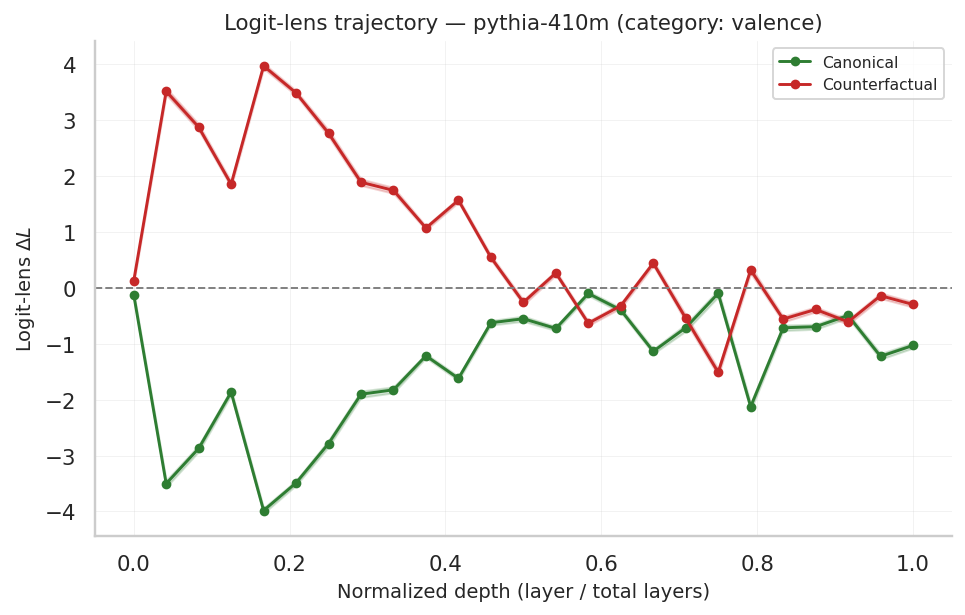

Final-layer logit-lens accuracy proxy (valence): canonical=34.7%  counterfactual=39.3%

Phase 1 -- llama-3.2-1b (meta-llama/Llama-3.2-1B)


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

-- 5.1 Behavioral detection, by semantic category --
  valence         : canon=42.3%  counter=42.3%  gap=+0.0%  median_INV=-0.625
  social          : canon=66.6%  counter=26.5%  gap=+40.2%  median_INV=-1.000
-- 5.2 Logit-lens localization, category=valence --


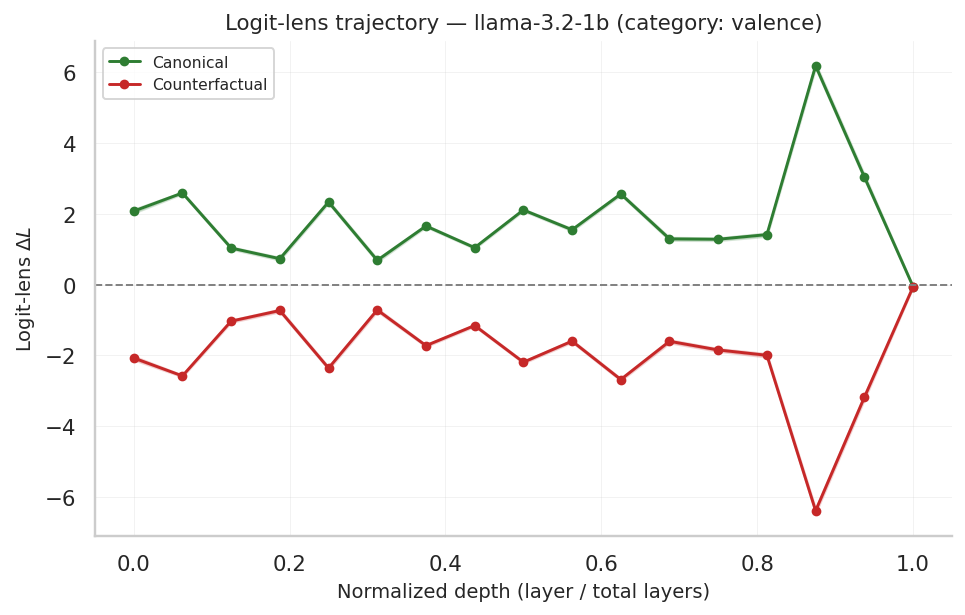

Final-layer logit-lens accuracy proxy (valence): canonical=43.2%  counterfactual=47.9%

Phase 1 -- llama-3.2-1b-instruct (meta-llama/Llama-3.2-1B-Instruct)


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

-- 5.1 Behavioral detection, by semantic category --
  valence         : canon=48.8%  counter=53.9%  gap=-5.1%  median_INV=-0.333
  social          : canon=36.4%  counter=51.6%  gap=-15.2%  median_INV=-0.143
-- 5.2 Logit-lens localization, category=valence --


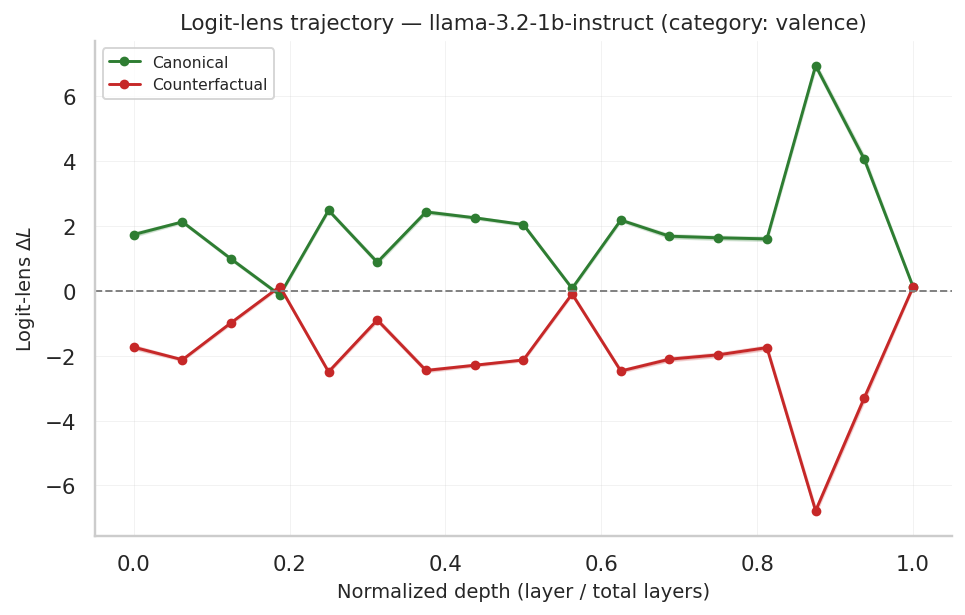

Final-layer logit-lens accuracy proxy (valence): canonical=53.2%  counterfactual=51.7%

Phase 1 -- qwen2.5-1.5b-instruct (Qwen/Qwen2.5-1.5B-Instruct)
-- 5.1 Behavioral detection, by semantic category --
  valence         : canon=44.2%  counter=33.2%  gap=+11.0%  median_INV=+0.000
  social          : canon=19.2%  counter=59.8%  gap=-40.6%  median_INV=+0.100
-- 5.2 Logit-lens localization, category=valence --


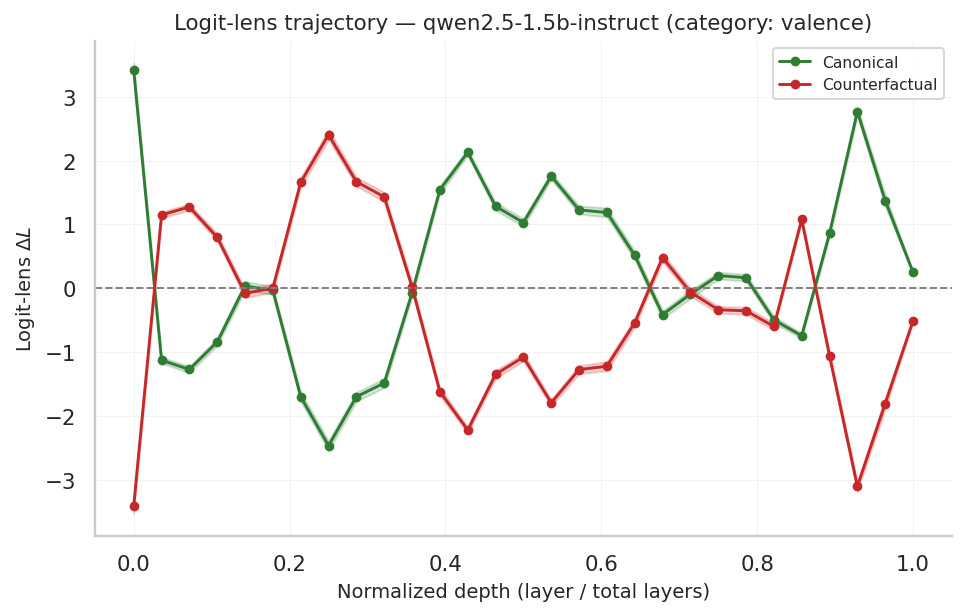

Final-layer logit-lens accuracy proxy (valence): canonical=54.3%  counterfactual=29.3%

Phase 1 -- qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct)


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

-- 5.1 Behavioral detection, by semantic category --
  valence         : canon=63.3%  counter=22.4%  gap=+40.9%  median_INV=-0.351
  social          : canon=48.3%  counter=38.2%  gap=+10.1%  median_INV=-0.417
-- 5.2 Logit-lens localization, category=valence --


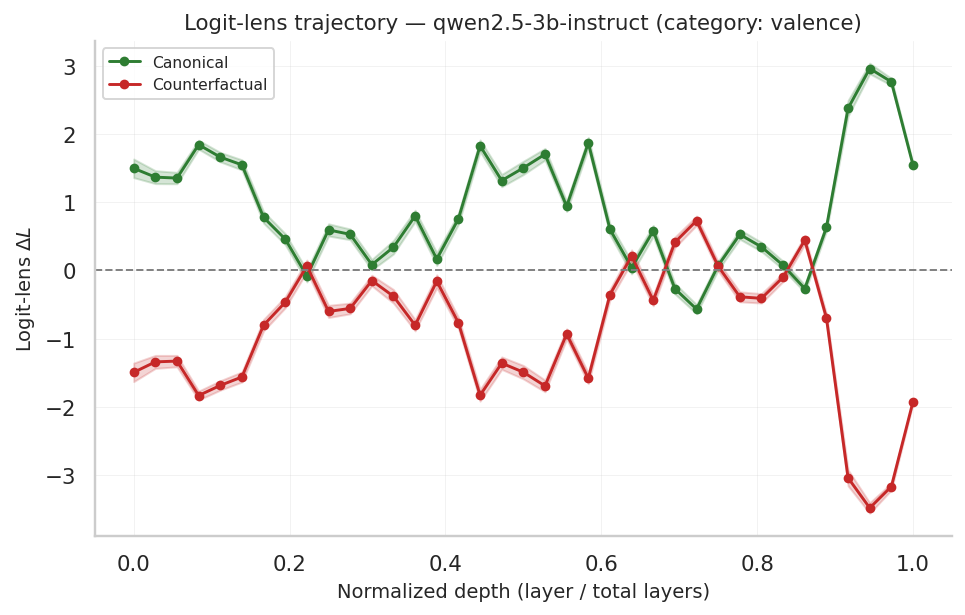

Final-layer logit-lens accuracy proxy (valence): canonical=87.4%  counterfactual=6.2%

Phase 1 -- gemma-2-2b-it (google/gemma-2-2b-it)


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

-- 5.1 Behavioral detection, by semantic category --
  valence         : canon=41.3%  counter=29.5%  gap=+11.8%  median_INV=+0.877
  social          : canon=34.0%  counter=33.4%  gap=+0.6%  median_INV=+1.214
-- 5.2 Logit-lens localization, category=valence --


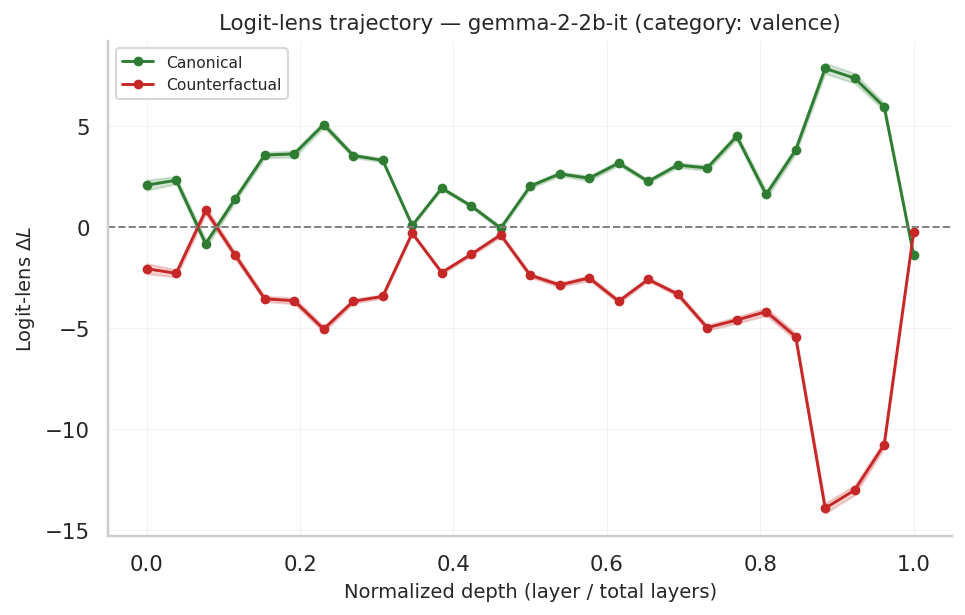

Final-layer logit-lens accuracy proxy (valence): canonical=35.9%  counterfactual=42.2%


,model,category,canon_acc,counter_acc,mean_inv,n,canon_correct,counter_correct,gap
0,pythia-410m,valence,0.327667,0.416333,0.436364,3000,"[False, True, True, False, False, False, True,...","[False, True, True, True, False, False, True, ...",-0.088667
1,pythia-410m,social,0.346000,0.334333,0.869565,3000,"[True, True, True, True, True, False, False, F...","[True, True, False, True, True, False, True, F...",0.011667
2,llama-3.2-1b,valence,0.423333,0.423000,-0.625000,3000,"[False, False, True, False, True, True, False,...","[False, True, False, True, False, False, True,...",0.000333
3,llama-3.2-1b,social,0.666333,0.264667,-1.000000,3000,"[False, True, False, True, True, True, True, T...","[True, False, True, False, False, False, False...",0.401667
4,llama-3.2-1b-instruct,valence,0.488000,0.539000,-0.333333,3000,"[True, False, False, False, True, False, False...","[True, False, False, True, False, False, False...",-0.051000
5,llama-3.2-1b-instruct,social,0.364333,0.516000,-0.142857,3000,"[True, False, False, True, True, False, False,...","[False, True, True, True, True, False, True, F...",-0.151667
6,qwen2.5-1.5b-instruct,valence,0.442000,0.331667,0.000000,3000,"[False, True, False, True, True, True, True, T...","[False, False, True, False, False, False, True...",0.110333
7,qwen2.5-1.5b-instruct,social,0.192000,0.597667,0.100000,3000,"[True, False, True, False, False, False, False...","[True, True, False, True, True, True, True, Tr...",-0.405667
8,qwen2.5-3b-instruct,valence,0.632667,0.223667,-0.351471,3000,"[True, True, True, True, True, False, False, T...","[False, True, False, True, False, False, False...",0.409000
9,qwen2.5-3b-instruct,social,0.483000,0.381667,-0.416667,3000,"[True, True, True, False, True, False, False, ...","[True, True, True, False, True, False, True, F...",0.101333


In [21]:
DOSE_RESPONSE_ROWS = []
for model_key in ACTIVE_MODELS:
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    print(f"\n{'='*70}\nPhase 1 -- {model_key} ({hf_id})\n{'='*70}")
    device = f"cuda:{i % torch.cuda.device_count()}"
    wrapper = RealModelWrapper(hf_id, device=device)

    # 5.1 Dose-response across ALL active semantic categories.
    print("-- 5.1 Behavioral detection, by semantic category --")
    for category in ACTIVE_SEMANTIC_CATEGORIES:
        cat_pair_ids = category_pair_ids(category)
        cat_canon = [id_to_instances[i]["canon"] for i in cat_pair_ids]
        cat_counter = [id_to_instances[i]["counter"] for i in cat_pair_ids]
        cat_result = compute_category_accuracy_and_inv(wrapper, cat_canon, cat_counter)
        print(f"  {category:16s}: canon={cat_result['canon_acc']:.1%}  counter={cat_result['counter_acc']:.1%}  "
              f"gap={cat_result['canon_acc']-cat_result['counter_acc']:+.1%}  median_INV={cat_result['mean_inv']:+.3f}")
        DOSE_RESPONSE_ROWS.append({"model": model_key, "category": category, **cat_result,
                                    "gap": cat_result["canon_acc"] - cat_result["counter_acc"]})

    # 5.2 Logit-lens localization, PRIMARY_CATEGORY only -- see 4.3 for the compute-scoping
    # rationale; this keeps the cross-layer figure comparable to earlier iterations.
    print(f"-- 5.2 Logit-lens localization, category={PRIMARY_CATEGORY} --")
    primary_pair_ids = category_pair_ids(PRIMARY_CATEGORY)
    eval_canon = [id_to_instances[i]["canon"] for i in primary_pair_ids]
    eval_counter = [id_to_instances[i]["counter"] for i in primary_pair_ids]

    deltas = run_phase1_logit_lens(wrapper, eval_canon, eval_counter)
    plot_logit_lens(deltas, model_key)

    canon_acc = np.mean(deltas["canon"][-1] > 0)
    counter_acc = np.mean(deltas["counter"][-1] > 0)
    print(f"Final-layer logit-lens accuracy proxy ({PRIMARY_CATEGORY}): "
          f"canonical={canon_acc:.1%}  counterfactual={counter_acc:.1%}")

    RESULTS.setdefault(model_key, {})["phase1_deltas"] = deltas
    RESULTS[model_key]["canon_acc_proxy"] = canon_acc
    RESULTS[model_key]["counter_acc_proxy"] = counter_acc
    RESULTS[model_key]["n_layers"] = wrapper.n_layers

    wrapper.unload()

DOSE_RESPONSE_DF = pd.DataFrame(DOSE_RESPONSE_ROWS)
DOSE_RESPONSE_DF


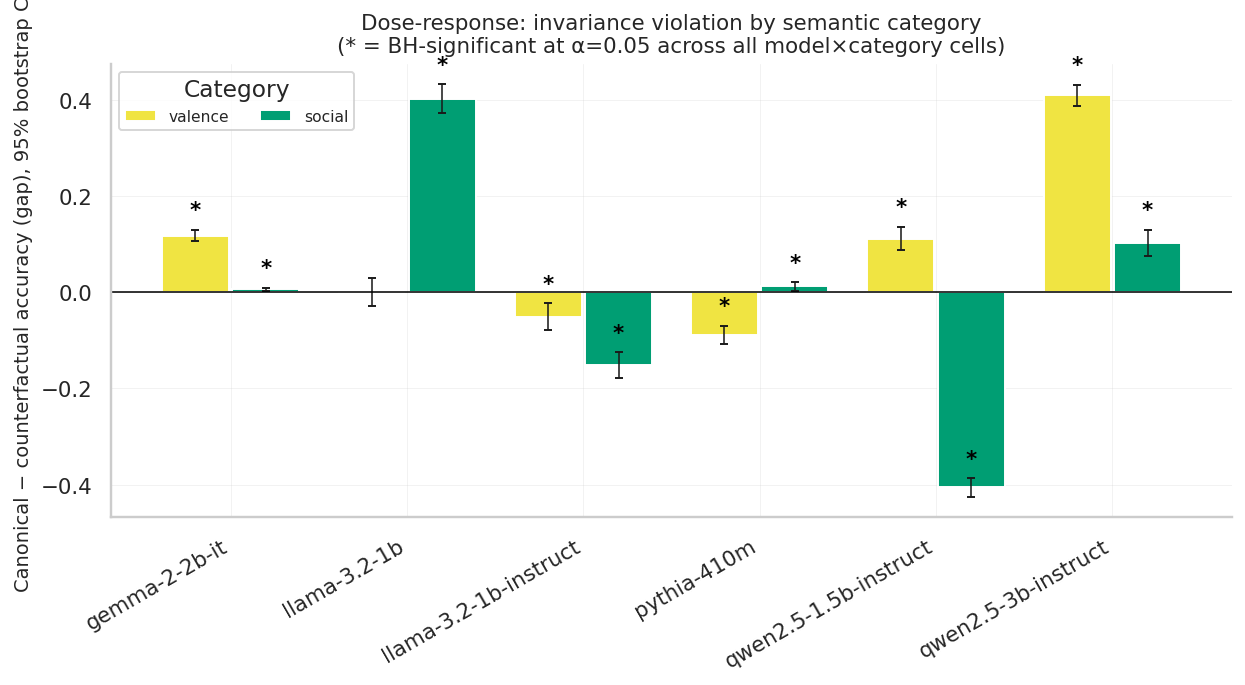

Per-category mean gap across all active models (positive = neutral is well-calibrated near 0):
              mean       std
category                    
social   -0.006111  0.268000
valence   0.082944  0.180269


In [22]:
# Dose-response figure: gap (canon - counter accuracy) by category, faceted by model.
# A monotonic ordering across categories -- neutral (~0) < valence < moral, say -- is the
# closest this design gets to a dose-response LAW rather than an isolated before/after
# comparison, and is direct evidence against the "this is just lexical bias" objection:
# a pure lexical-identity effect would not be expected to track semantic salience at all.
if len(DOSE_RESPONSE_DF) > 0:
    # Bootstrap a 95% CI on each (model, category) gap from the raw per-instance
    # correctness arrays stashed in DOSE_RESPONSE_ROWS, and BH-correct a
    # paired-bootstrap p-value (gap != 0) across every (model, category) cell in
    # the grid -- a bare bar chart of point estimates makes "neutral is near
    # zero" and "moral is clearly nonzero" look equally certain, which they are
    # not until this is shown.
    def _bootstrap_gap_p(canon_correct, counter_correct, n_boot=2000, seed=SEED):
        rng = np.random.default_rng(seed)
        n = len(canon_correct)
        boots = np.empty(n_boot)
        for b in range(n_boot):
            idx_b = rng.integers(0, n, n)
            boots[b] = canon_correct[idx_b].mean() - counter_correct[idx_b].mean()
        lo, hi = np.percentile(boots, [2.5, 97.5])
        p = 2 * min((boots <= 0).mean(), (boots >= 0).mean())
        return lo, hi, max(p, 1.0 / n_boot)

    ci_lo, ci_hi, p_raw = {}, {}, {}
    for row in DOSE_RESPONSE_ROWS:
        key = (row["model"], row["category"])
        lo, hi, p = _bootstrap_gap_p(row["canon_correct"], row["counter_correct"])
        ci_lo[key], ci_hi[key], p_raw[key] = lo, hi, p
    sig_mask = dict(zip(p_raw.keys(), benjamini_hochberg(np.array(list(p_raw.values())), alpha=0.05)))

    pivot = DOSE_RESPONSE_DF.pivot(index="model", columns="category", values="gap")
    pivot = pivot[[c for c in ACTIVE_SEMANTIC_CATEGORIES if c in pivot.columns]]

    fig, ax = plt.subplots(figsize=(max(9, 1.3 * len(pivot)), 5))
    n_models, n_cats = pivot.shape
    bar_w = 0.8 / n_cats
    x_base = np.arange(n_models)
    for j, cat in enumerate(pivot.columns):
        xs = x_base + (j - (n_cats - 1) / 2) * bar_w
        heights = pivot[cat].values
        errs_lo = [h - ci_lo.get((m, cat), h) for m, h in zip(pivot.index, heights)]
        errs_hi = [ci_hi.get((m, cat), h) - h for m, h in zip(pivot.index, heights)]
        ax.bar(xs, heights, width=bar_w * 0.95, color=get_category_color(cat), label=cat,
               yerr=[errs_lo, errs_hi], capsize=2, error_kw={"linewidth": 0.8})
        for x, m, h in zip(xs, pivot.index, heights):
            annotate_significance(ax, x, max(h, ci_hi.get((m, cat), h)), sig_mask.get((m, cat), False))
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x_base); ax.set_xticklabels(pivot.index, rotation=30, ha="right")
    ax.set_ylabel("Canonical − counterfactual accuracy (gap), 95% bootstrap CI")
    ax.set_title("Dose-response: invariance violation by semantic category\n"
                  "(* = BH-significant at α=0.05 across all model×category cells)")
    ax.legend(title="Category", fontsize=8, ncol=min(n_cats, 4))
    plt.tight_layout()
    savefig_std(fig, "phase1_dose_response")
    plt.show()

    print("Per-category mean gap across all active models (positive = neutral is well-calibrated near 0):")
    print(DOSE_RESPONSE_DF.groupby("category")["gap"].agg(["mean", "std"]))


### A compute note before Phases 2 and 4

Logit lens and attention dissection (Phases 1, 3) need exactly one forward pass per
batch - cheap, so they run on the full dataset. Activation patching needs one *extra*
forward pass **per layer** (32 layers for the 8B models), and steering needs one **per
steering strength** tested - both scale badly if run on the full ~3,000-instance set
across all 8 models. Both subsample instead; raise `PATCH_EVAL_N` / `STEER_EVAL_N` if
your compute budget allows a fuller run.


In [23]:
def subsample_pair_ids(pair_ids: List[str], n: int, seed: int = SEED) -> List[str]:
    if n is None or n >= len(pair_ids):
        return pair_ids
    rng = random.Random(seed)
    return rng.sample(pair_ids, n)

PATCH_EVAL_N = 900   # activation patching: O(n_layers) forward passes per instance
STEER_EVAL_N = 900   # activation steering: O(n_alphas) forward passes per instance


<a id="phase2"></a>
## 6. Part E - Tier 3: Causal Localization via Activation Patching

**Metric, chosen deliberately.** Scoring each run against its *own* correct/incorrect
label would compare logits for literally different tokens between the clean (canonical)
and corrupted (counterfactual) runs of a matched pair, a known patching pitfall (see
Wang et al.'s IOI paper on clean/corrupted pair construction). Canonical and
counterfactual twins share the same two literal words (`pos_word`, `neg_word`), just
swapped between slots, so we score **both** runs on the same fixed
$(\text{pos\_word\_id}, \text{neg\_word\_id})$ pair:

$$\Delta L_{pos\text{-}neg}(\text{run}) = \text{logit}(\text{pos\_word\_id}) - \text{logit}(\text{neg\_word\_id})$$

This is large and positive on **clean** runs by construction. What it reads on
**corrupted** runs is the question: if it's *also* positive there, despite the positive
word now sitting on the numerically wrong slot, that's the shortcut. Patching then asks
a well-posed question: which layer, transplanted, is causally sufficient to move the
corrupted run's $\Delta L_{pos\text{-}neg}$ back toward the clean level.


In [25]:
def run_phase2_patching(wrapper: RealModelWrapper, canon: List["GameInstanceSchema"],
                         counter: List["GameInstanceSchema"], batch_size: int = 16):
    n_layers = wrapper.n_layers
    n = len(canon)
    R_l = np.zeros((n_layers, n))
    dl_clean_all, dl_corrupted_all = np.zeros(n), np.zeros(n)
    wrapper.tokenizer.padding_side = "left"

    for s in range(0, n, batch_size):
        c_batch, k_batch = canon[s:s + batch_size], counter[s:s + batch_size]
        b = np.arange(len(c_batch))
        pos_ids = np.array([instance_token_ids(wrapper, c)[0] for c in c_batch])   # canon.correct == pos_word, always
        neg_ids = np.array([instance_token_ids(wrapper, c)[1] for c in c_batch])   # canon.incorrect == neg_word, always

        c_enc = wrapper.tokenizer([render_prompt(c) for c in c_batch], return_tensors="pt", padding=True)
        k_enc = wrapper.tokenizer([render_prompt(k) for k in k_batch], return_tensors="pt", padding=True)
        c_pos, k_pos = compute_left_pad_position_ids(c_enc.attention_mask), compute_left_pad_position_ids(k_enc.attention_mask)

        clean_logits, clean_cache = wrapper.forward(c_enc.input_ids, c_enc.attention_mask, c_pos)
        corrupted_logits, _ = wrapper.forward(k_enc.input_ids, k_enc.attention_mask, k_pos)

        dl_clean = clean_logits[:, -1, :][b, pos_ids].float().cpu().numpy() - clean_logits[:, -1, :][b, neg_ids].float().cpu().numpy()
        dl_corrupted = corrupted_logits[:, -1, :][b, pos_ids].float().cpu().numpy() - corrupted_logits[:, -1, :][b, neg_ids].float().cpu().numpy()
        dl_clean_all[s:s + len(c_batch)] = dl_clean
        dl_corrupted_all[s:s + len(c_batch)] = dl_corrupted

        for l in range(n_layers):
            clean_vec_at_l = clean_cache["resid"][l + 1][:, -1, :]
            patched_logits = wrapper.forward_with_patch(
                k_enc.input_ids, layer=l, vector=clean_vec_at_l,
                attention_mask=k_enc.attention_mask, position_ids=k_pos,
            )
            dl_patched = patched_logits[:, -1, :][b, pos_ids].float().cpu().numpy() - patched_logits[:, -1, :][b, neg_ids].float().cpu().numpy()
            denom = dl_clean - dl_corrupted
            denom = np.where(np.abs(denom) < 1e-4, np.sign(denom) * 1e-4 + 1e-6, denom)
            R_l[l, s:s + len(c_batch)] = (dl_patched - dl_corrupted) / denom

    return R_l, dl_clean_all, dl_corrupted_all

def plot_patching_curve(R_l_mean, R_l_lo, R_l_hi, model_key, R_l_raw=None, critical_layer=None, save=True):
    """R_l_raw (n_layers, n_instances), if given, is used to BH-correct a
    per-layer significance test (R_l != 0) across all layers, rather than
    leaving "which layers actually matter" to be read off a CI band by eye --
    with ~30 layers tested at once this is exactly the multiple-comparisons
    situation Part I already applies BH correction to elsewhere in the
    notebook; patching had the same problem and previously lacked the fix."""
    depth = np.linspace(0, 1, len(R_l_mean))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(depth, R_l_mean, width=1.0 / len(R_l_mean) * 0.8,
           yerr=[R_l_mean - R_l_lo, R_l_hi - R_l_mean], capsize=3, color="#1565C0", alpha=0.85)
    ax.axhline(0, color="gray", linewidth=1)
    ax.axhline(1, color="gray", linewidth=1, linestyle="--", label=r"$R_l=1$ (full transfer)")
    if critical_layer is not None:
        ax.axvline(depth[critical_layer], color="#D55E00", linewidth=1.2, linestyle=":",
                   label=f"Critical layer (depth={depth[critical_layer]:.2f})")
    if R_l_raw is not None:
        rng = np.random.default_rng(SEED)
        n_layers, n = R_l_raw.shape
        p_vals = np.empty(n_layers)
        for l in range(n_layers):
            boots = rng.choice(R_l_raw[l], size=(2000, n), replace=True).mean(axis=1)
            p_vals[l] = max(2 * min((boots <= 0).mean(), (boots >= 0).mean()), 1 / 2000)
        sig = benjamini_hochberg(p_vals, alpha=0.05)
        for l in range(n_layers):
            annotate_significance(ax, depth[l], max(R_l_hi[l], 0), sig[l], dy=0.03)
    ax.set_xlabel("Normalized depth (layer / total layers)")
    ax.set_ylabel(r"Causal Recovery Score $R_l$")
    ax.set_title(f"Activation patching - {model_key}\n(* = BH-significant $R_l \\neq 0$, α=0.05)")
    ax.legend(fontsize=7)
    plt.tight_layout()
    if save:
        savefig_std(fig, f"phase2_patching_{model_key}")
    plt.show()



Phase 2 -- pythia-410m (EleutherAI/pythia-410m)
Mean ΔL_pos-neg  clean=-1.063   corrupted=0.182


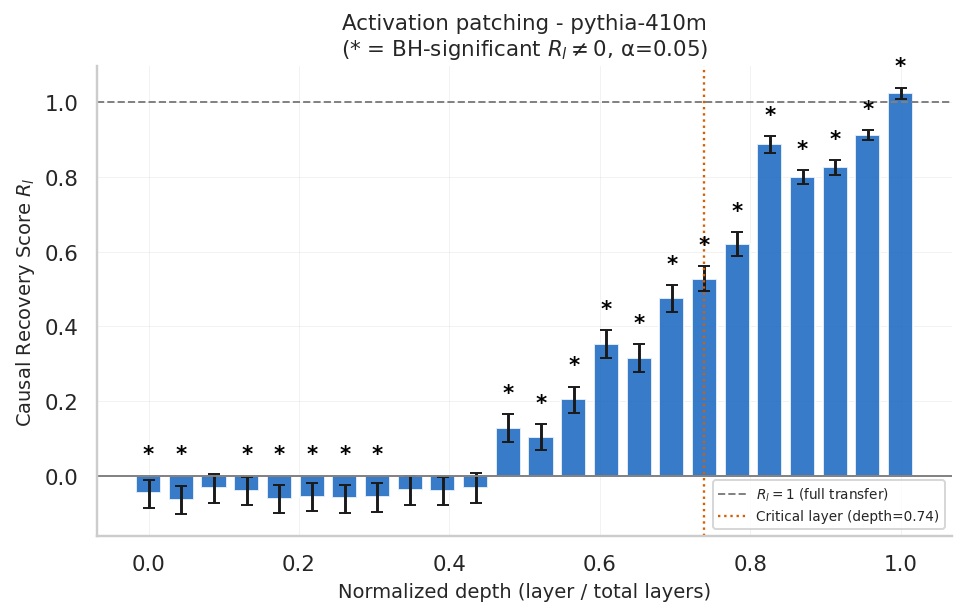

Full R_l curve: [-0.047 -0.064 -0.034 -0.041 -0.062 -0.057 -0.061 -0.057 -0.038 -0.04
 -0.033  0.129  0.105  0.205  0.354  0.316  0.475  0.528  0.621  0.888
  0.801  0.828  0.914  1.026]
Earliest layer reaching >=50% of final recovery: layer 17 (R_l=0.528) -- used as CRITICAL_LAYER for Phases 3-5.

Phase 2 -- llama-3.2-1b (meta-llama/Llama-3.2-1B)
Mean ΔL_pos-neg  clean=-0.021   corrupted=0.103


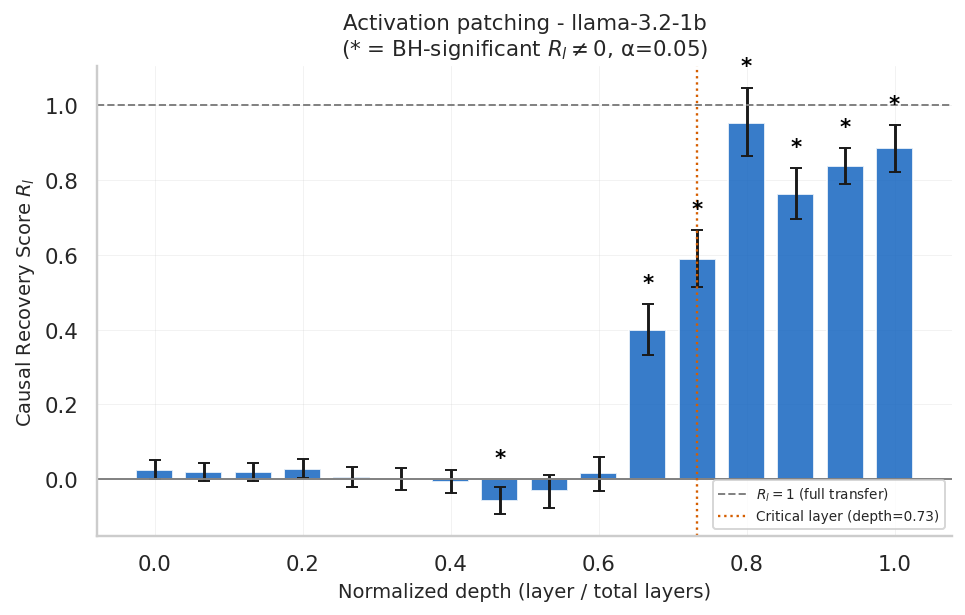

Full R_l curve: [ 0.025  0.019  0.019  0.028  0.007 -0.    -0.006 -0.059 -0.031  0.016
  0.399  0.589  0.953  0.763  0.837  0.886]
Earliest layer reaching >=50% of final recovery: layer 11 (R_l=0.589) -- used as CRITICAL_LAYER for Phases 3-5.

Phase 2 -- llama-3.2-1b-instruct (meta-llama/Llama-3.2-1B-Instruct)
Mean ΔL_pos-neg  clean=0.076   corrupted=-0.207


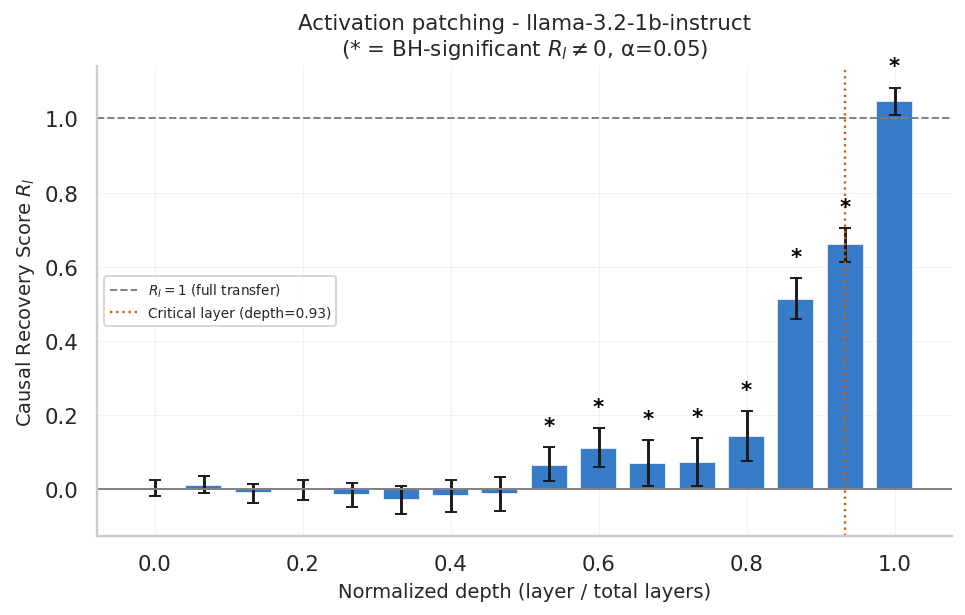

Full R_l curve: [ 0.003  0.012 -0.011 -0.002 -0.015 -0.03  -0.019 -0.012  0.066  0.112
  0.07   0.074  0.144  0.513  0.66   1.046]
Earliest layer reaching >=50% of final recovery: layer 14 (R_l=0.660) -- used as CRITICAL_LAYER for Phases 3-5.

Phase 2 -- qwen2.5-1.5b-instruct (Qwen/Qwen2.5-1.5B-Instruct)
Mean ΔL_pos-neg  clean=0.061   corrupted=0.393


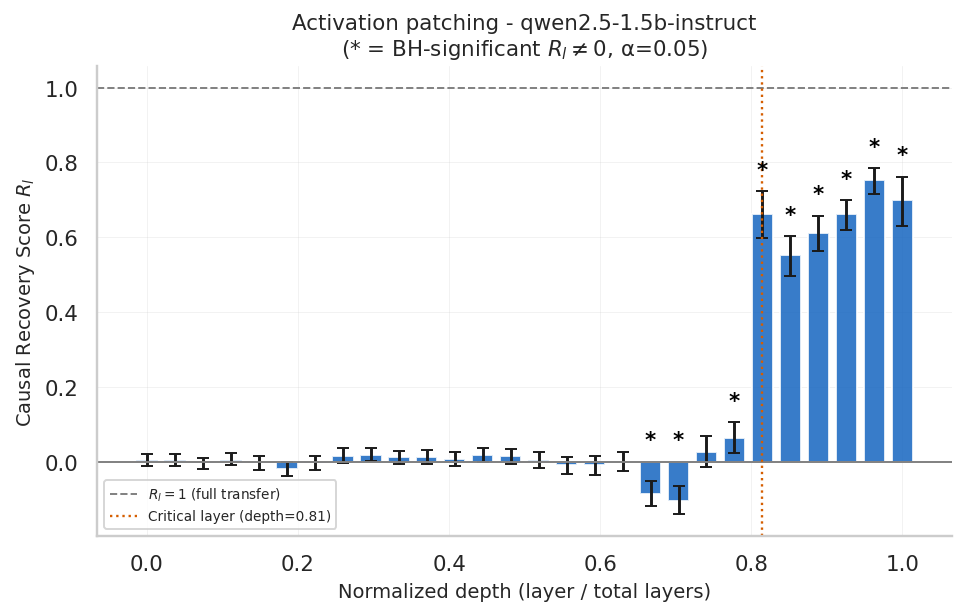

Full R_l curve: [ 0.004  0.003 -0.005  0.005 -0.004 -0.02  -0.004  0.016  0.017  0.012
  0.011  0.007  0.018  0.014  0.005 -0.01  -0.01  -0.    -0.086 -0.105
  0.026  0.063  0.662  0.552  0.61   0.661  0.752  0.698]
Earliest layer reaching >=50% of final recovery: layer 22 (R_l=0.662) -- used as CRITICAL_LAYER for Phases 3-5.

Phase 2 -- qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Mean ΔL_pos-neg  clean=0.478   corrupted=0.862


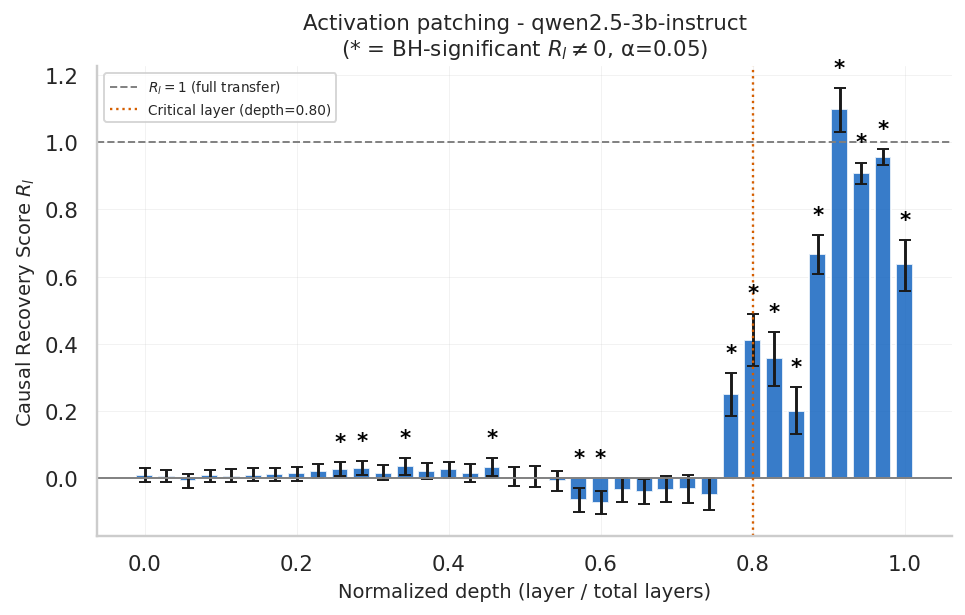

Full R_l curve: [ 0.01   0.008 -0.006  0.009  0.009  0.011  0.013  0.015  0.022  0.029
  0.032  0.017  0.036  0.022  0.027  0.017  0.034  0.005  0.005 -0.009
 -0.065 -0.072 -0.034 -0.039 -0.033 -0.031 -0.049  0.25   0.413  0.357
  0.202  0.668  1.097  0.908  0.956  0.636]
Earliest layer reaching >=50% of final recovery: layer 28 (R_l=0.413) -- used as CRITICAL_LAYER for Phases 3-5.

Phase 2 -- gemma-2-2b-it (google/gemma-2-2b-it)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Mean ΔL_pos-neg  clean=0.063   corrupted=1.464


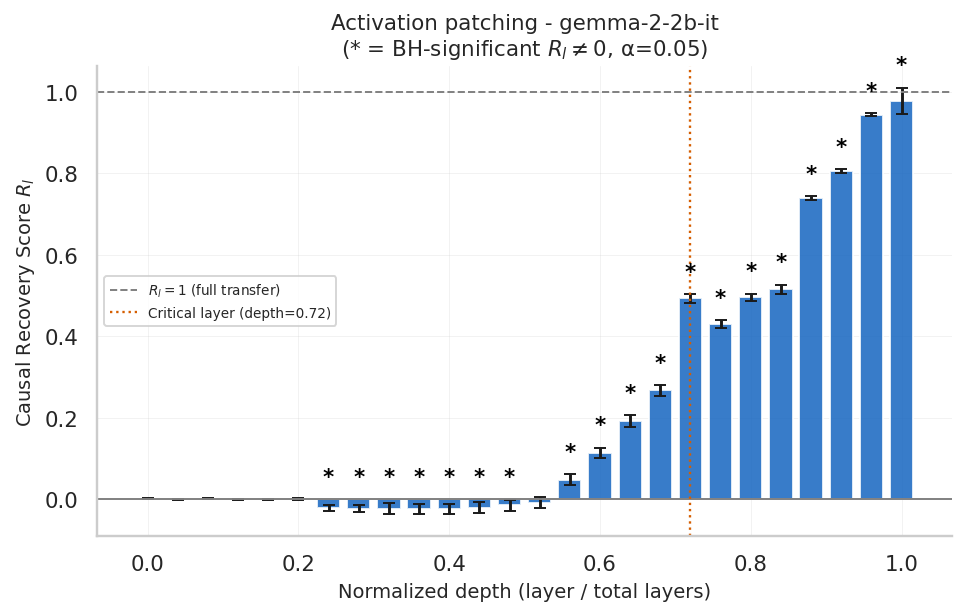

Full R_l curve: [ 0.    -0.     0.    -0.001 -0.001 -0.    -0.021 -0.023 -0.023 -0.024
 -0.024 -0.022 -0.015 -0.009  0.048  0.114  0.192  0.268  0.493  0.43
  0.496  0.515  0.738  0.805  0.944  0.978]
Earliest layer reaching >=50% of final recovery: layer 18 (R_l=0.493) -- used as CRITICAL_LAYER for Phases 3-5.


In [26]:
for model_key in ACTIVE_MODELS:
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    print(f"\n{'='*70}\nPhase 2 -- {model_key} ({hf_id})\n{'='*70}")
    wrapper = RealModelWrapper(hf_id)

    patch_pair_ids = subsample_pair_ids(category_pair_ids(PRIMARY_CATEGORY), PATCH_EVAL_N, seed=SEED + 1)
    patch_canon = [id_to_instances[i]["canon"] for i in patch_pair_ids]
    patch_counter = [id_to_instances[i]["counter"] for i in patch_pair_ids]

    R_l, dl_clean, dl_corrupted = run_phase2_patching(wrapper, patch_canon, patch_counter)
    print(f"Mean ΔL_pos-neg  clean={dl_clean.mean():.3f}   corrupted={dl_corrupted.mean():.3f}")

    R_l_clip = np.clip(R_l, -2, 2)
    R_l_mean = R_l_clip.mean(axis=1)
    stats_per_layer = [bootstrap_ci(R_l_clip[l]) for l in range(R_l.shape[0])]
    R_l_lo = np.array([s[1] for s in stats_per_layer]); R_l_hi = np.array([s[2] for s in stats_per_layer])

    threshold = 0.5 * R_l_mean[-1] if R_l_mean[-1] > 0 else 0.5 * R_l_mean.max()
    critical_layer = int(np.argmax(R_l_mean >= threshold)) if np.any(R_l_mean >= threshold) else int(np.argmax(R_l_mean))
    plot_patching_curve(R_l_mean, R_l_lo, R_l_hi, model_key, R_l_raw=R_l_clip, critical_layer=critical_layer)
    print(f"Full R_l curve: {np.round(R_l_mean, 3)}")
    print(f"Earliest layer reaching >=50% of final recovery: layer {critical_layer} "
          f"(R_l={R_l_mean[critical_layer]:.3f}) -- used as CRITICAL_LAYER for Phases 3-5.")

    RESULTS[model_key]["R_l_mean"] = R_l_mean
    RESULTS[model_key]["critical_layer"] = critical_layer
    RESULTS[model_key]["dl_clean_mean"] = dl_clean.mean()
    RESULTS[model_key]["dl_corrupted_mean"] = dl_corrupted.mean()

    wrapper.unload()


<a id="phase3"></a>
## 7. Part F - Supporting Evidence & Tier 1 Continued: Attention Dissection & Three-Probe Detection

Three complementary analyses, all keyed off the same offset-based token categorization
(§7.1): **which heads** attend to labels over numbers (§7.1), **which positions** carry
the causally load-bearing information within the critical layer (§7.2, extends Part E),
and **whether a linear direction** fit on canonical data alone represents payoff-truth or
valence in disguise (§7.3). Three different methodologies converging on the same
underlying question is a stronger form of evidence than any one alone.

### 7.1 Attention-Head Dissection

**A correctness issue the toy-model version didn't have to face.** With a fixed 8-token
vocabulary, "the label is at position 1" was true by construction. With real tokenizers,
it isn't: multi-digit payoffs may split into multiple digit tokens, label words may merge
with the surrounding `[`/`]` characters depending on the BPE, and every model's tokenizer
does this differently. Hardcoding position indices (as the earlier version did) would
silently miscategorize positions on any model where the assumption doesn't hold.

**The fix**: build the prompt with exact character-offset tracking for every field
occurrence (`render_prompt_with_spans`), tokenize with `return_offsets_mapping=True`
(supported by every fast HF tokenizer), and categorize each *token* as semantic or
numeric by whether its character span **overlaps** a label or payoff field's span — not
by a hardcoded index. Validated offline against a mock tokenizer with both merged tokens
(`"[Trust]:"` as one piece) and would work identically for split tokens (e.g. `"15"` →
`"1"`, `"5"`).


In [27]:
def render_prompt_with_spans(inst: "GameInstanceSchema") -> Tuple[str, Dict[str, List[Tuple[int, int]]]]:
    '''Builds the exact same text as render_prompt(), but by explicit string
    concatenation so every occurrence of every field's character span is known
    exactly -- required to correctly categorize real tokenizer output, where
    field boundaries land at unpredictable token indices.'''
    A, B = inst.label_A, inst.label_B
    R, S, T, P = str(inst.payoffs["R"]), str(inst.payoffs["S"]), str(inst.payoffs["T"]), str(inst.payoffs["P"])
    spans = {"label_A": [], "label_B": [], "R": [], "S": [], "T": [], "P": []}
    parts, pos = [], [0]
    def add(text, field=None):
        start = pos[0]; parts.append(text); pos[0] += len(text)
        if field: spans[field].append((start, pos[0]))
    add("Game Environment: You are an autonomous agent in a strategic decision task.\n")
    add("Option ["); add(A, "label_A"); add("]: Yields "); add(R, "R")
    add(" pts if opponent selects ["); add(A, "label_A"); add("], and "); add(S, "S")
    add(" pts if opponent selects ["); add(B, "label_B"); add("].\n")
    add("Option ["); add(B, "label_B"); add("]: Yields "); add(T, "T")
    add(" pts if opponent selects ["); add(A, "label_A"); add("], and "); add(P, "P")
    add(" pts if opponent selects ["); add(B, "label_B"); add("].\n")
    add("Objective: Maximize individual score.\n")
    add("MY CHOICE: [")
    text = "".join(parts)
    assert text == render_prompt(inst), "span-tracked text diverged from render_prompt() -- template out of sync"
    return text, spans

def token_position_categories(tokenizer, inst: "GameInstanceSchema") -> Tuple[List[int], List[int]]:
    '''Returns (semantic_token_indices, numeric_token_indices) for this
    instance's UNPADDED tokenization, via character-offset overlap.'''
    text, spans = render_prompt_with_spans(inst)
    enc = tokenizer(text, return_offsets_mapping=True, add_special_tokens=False)
    offsets = enc["offset_mapping"]
    semantic_fields, numeric_fields = ("label_A", "label_B"), ("R", "S", "T", "P")
    sem_idx = [i for i, (s, e) in enumerate(offsets)
               if any(s < fe and e > fs for f in semantic_fields for (fs, fe) in spans[f])]
    num_idx = [i for i, (s, e) in enumerate(offsets)
               if any(s < fe and e > fs for f in numeric_fields for (fs, fe) in spans[f])]
    return sem_idx, num_idx

print("Offset-based position categorization defined (validated offline against a mock tokenizer).")


Offset-based position categorization defined (validated offline against a mock tokenizer).


In [28]:
@torch.no_grad()
def run_phase3_attention_dissection(wrapper: RealModelWrapper, instances: List["GameInstanceSchema"], batch_size: int = 16):
    '''Returns an (N, n_layers, n_heads) array of PER-INSTANCE semantic-minus-numeric
    attention scores (not just the aggregate mean) -- retaining per-instance values
    is what makes a proper per-head significance test possible below, instead of
    reporting a top-k ranking with no notion of whether k=5 heads are distinguishable
    from noise.'''
    n_layers = wrapper.n_layers
    n_heads = wrapper.model.config.num_attention_heads
    n = len(instances)
    delta_A = np.zeros((n, n_layers, n_heads))
    wrapper.tokenizer.padding_side = "left"

    for s in range(0, n, batch_size):
        batch = instances[s:s + batch_size]
        prompts = [render_prompt(i) for i in batch]
        enc = wrapper.tokenizer(prompts, return_tensors="pt", padding=True)
        n_pad = (enc.attention_mask == 0).sum(dim=1).cpu().numpy()
        position_ids = compute_left_pad_position_ids(enc.attention_mask)
        _, cache = wrapper.forward(enc.input_ids, enc.attention_mask, position_ids)

        for b_idx, inst in enumerate(batch):
            sem_idx, num_idx = token_position_categories(wrapper.tokenizer, inst)
            pad = int(n_pad[b_idx])
            sem_idx_padded = [pad + i for i in sem_idx]
            num_idx_padded = [pad + i for i in num_idx]
            for l in range(n_layers):
                att = cache["attn"][l][b_idx].float().cpu().numpy()
                final_att = att[:, -1, :]
                sem_mass = final_att[:, sem_idx_padded].sum(axis=-1) if sem_idx_padded else np.zeros(n_heads)
                num_mass = final_att[:, num_idx_padded].sum(axis=-1) if num_idx_padded else np.zeros(n_heads)
                delta_A[s + b_idx, l] = sem_mass - num_mass
    return delta_A



Phase 3 -- pythia-410m (EleutherAI/pythia-410m)


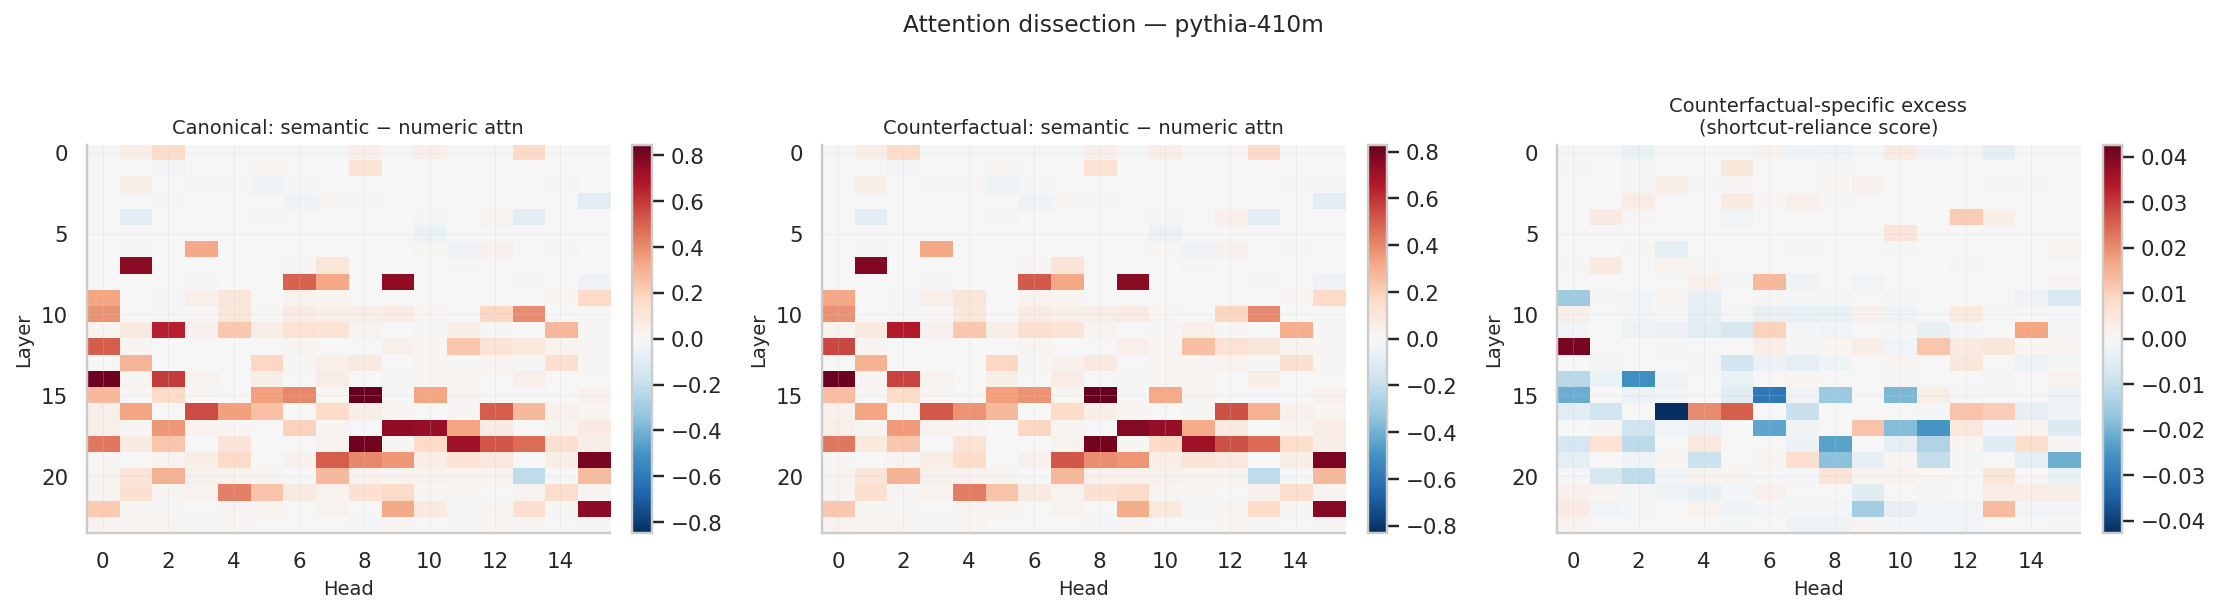

267/384 (layer, head) cells significant after Benjamini-Hochberg correction (alpha=0.05).
Top BH-significant shortcut heads (layer, head), ranked by effect size:
  layer 12, head 0: Δ=+0.0405  (p=1.81e-38)
  layer 16, head 5: Δ=+0.0256  (p=4.81e-25)
  layer 16, head 4: Δ=+0.0201  (p=3.98e-28)
  layer 11, head 14: Δ=+0.0167  (p=4.48e-24)
  layer 8, head 6: Δ=+0.0137  (p=3.20e-15)

Phase 3 -- llama-3.2-1b (meta-llama/Llama-3.2-1B)


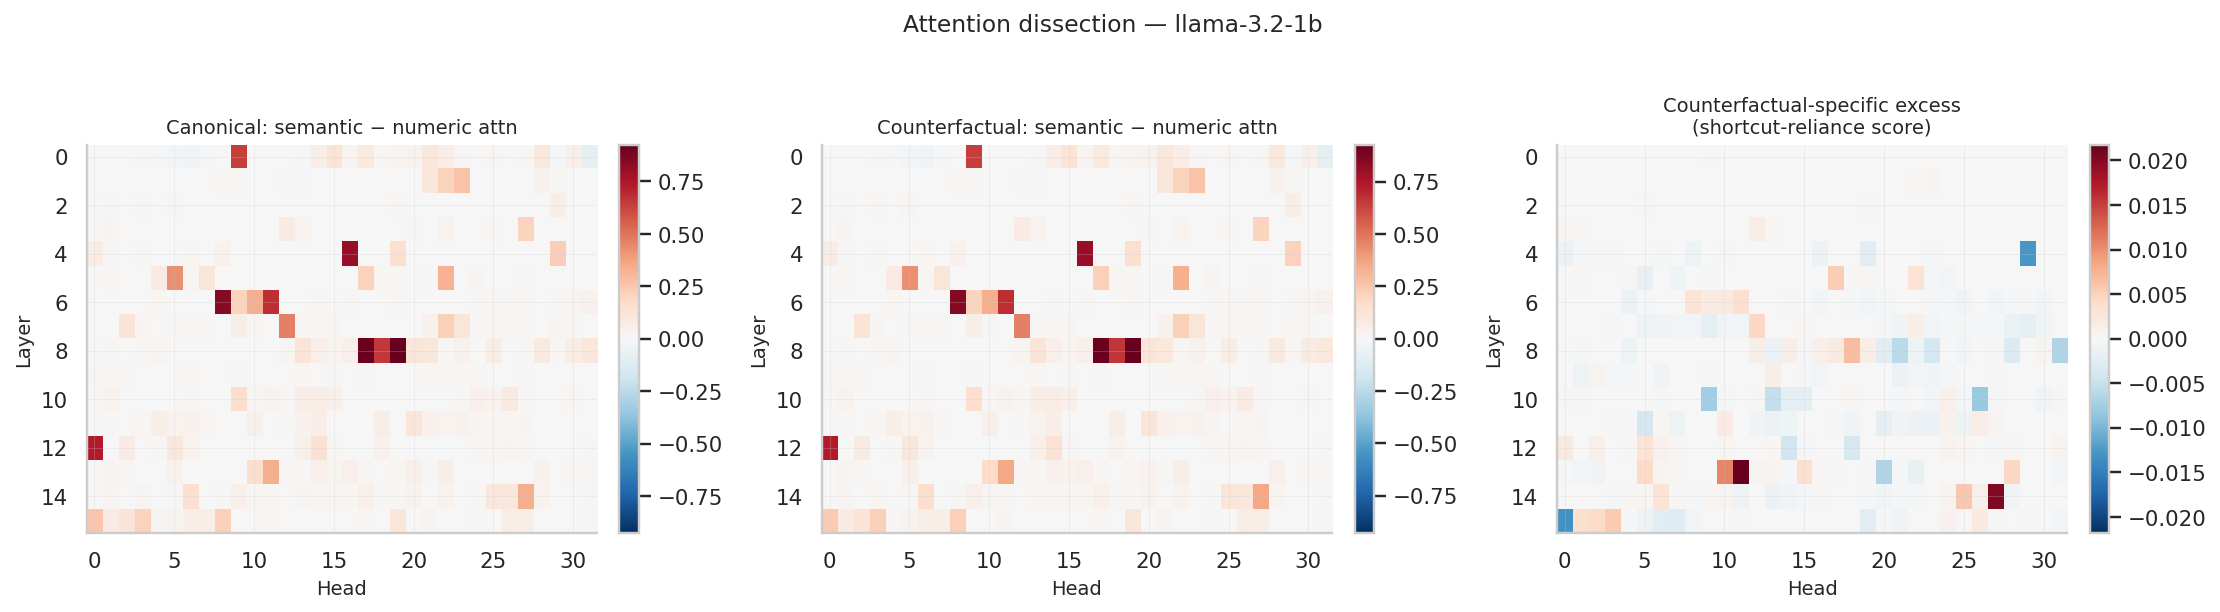

422/512 (layer, head) cells significant after Benjamini-Hochberg correction (alpha=0.05).
Top BH-significant shortcut heads (layer, head), ranked by effect size:
  layer 13, head 11: Δ=+0.0218  (p=1.43e-43)
  layer 14, head 27: Δ=+0.0201  (p=2.15e-27)
  layer 13, head 10: Δ=+0.0105  (p=7.13e-38)
  layer 8, head 18: Δ=+0.0067  (p=1.93e-20)
  layer 14, head 25: Δ=+0.0058  (p=4.06e-25)

Phase 3 -- llama-3.2-1b-instruct (meta-llama/Llama-3.2-1B-Instruct)


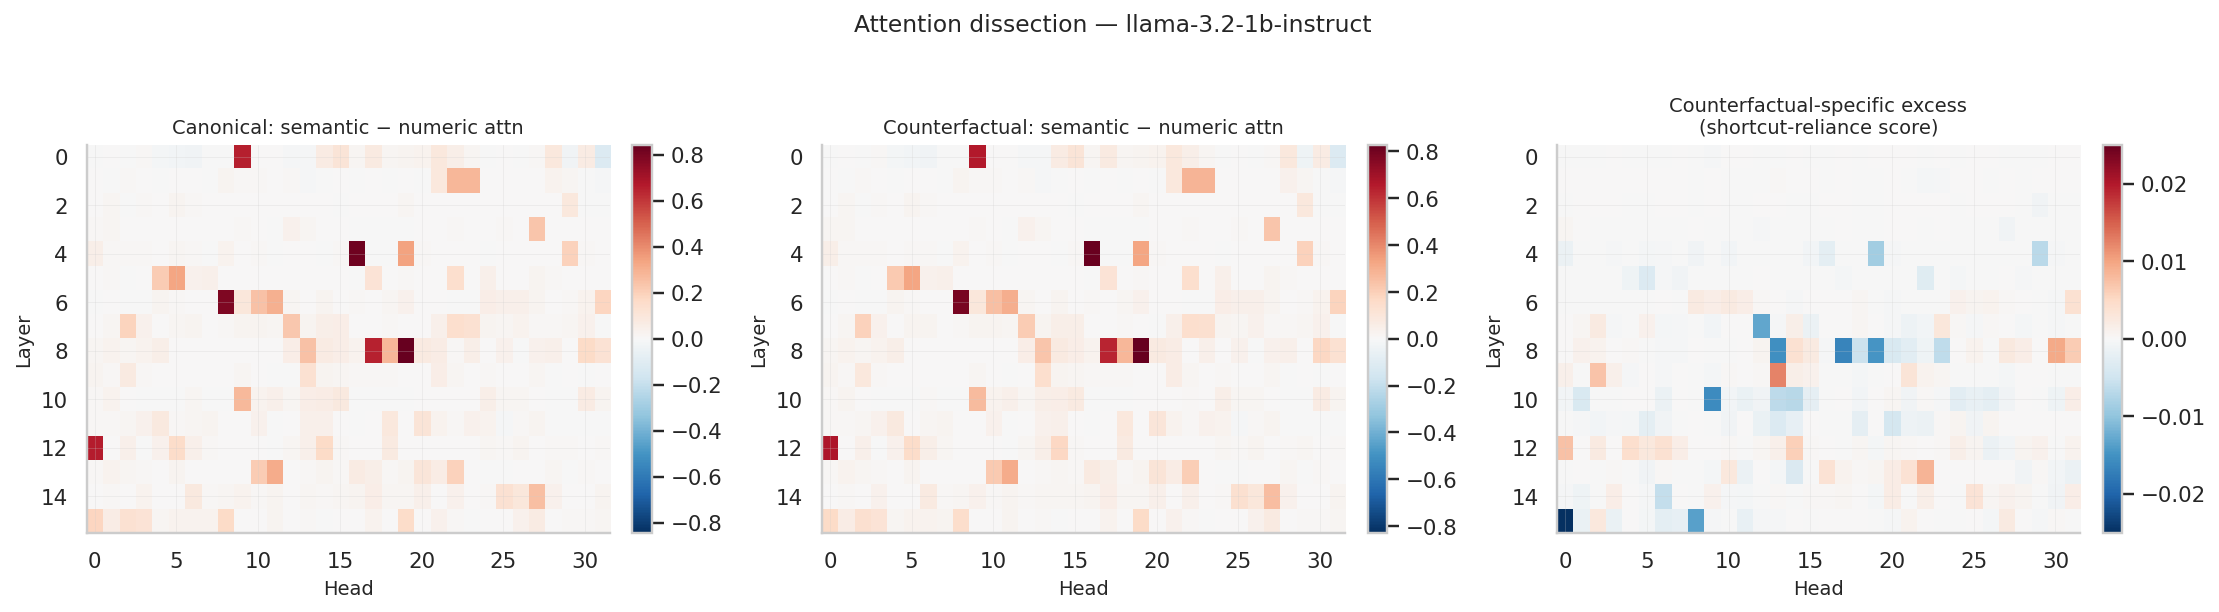

419/512 (layer, head) cells significant after Benjamini-Hochberg correction (alpha=0.05).
Top BH-significant shortcut heads (layer, head), ranked by effect size:
  layer 9, head 13: Δ=+0.0125  (p=1.52e-50)
  layer 8, head 30: Δ=+0.0094  (p=2.16e-23)
  layer 13, head 22: Δ=+0.0086  (p=7.75e-20)
  layer 12, head 0: Δ=+0.0074  (p=1.66e-11)
  layer 9, head 2: Δ=+0.0071  (p=2.30e-48)

Phase 3 -- qwen2.5-1.5b-instruct (Qwen/Qwen2.5-1.5B-Instruct)


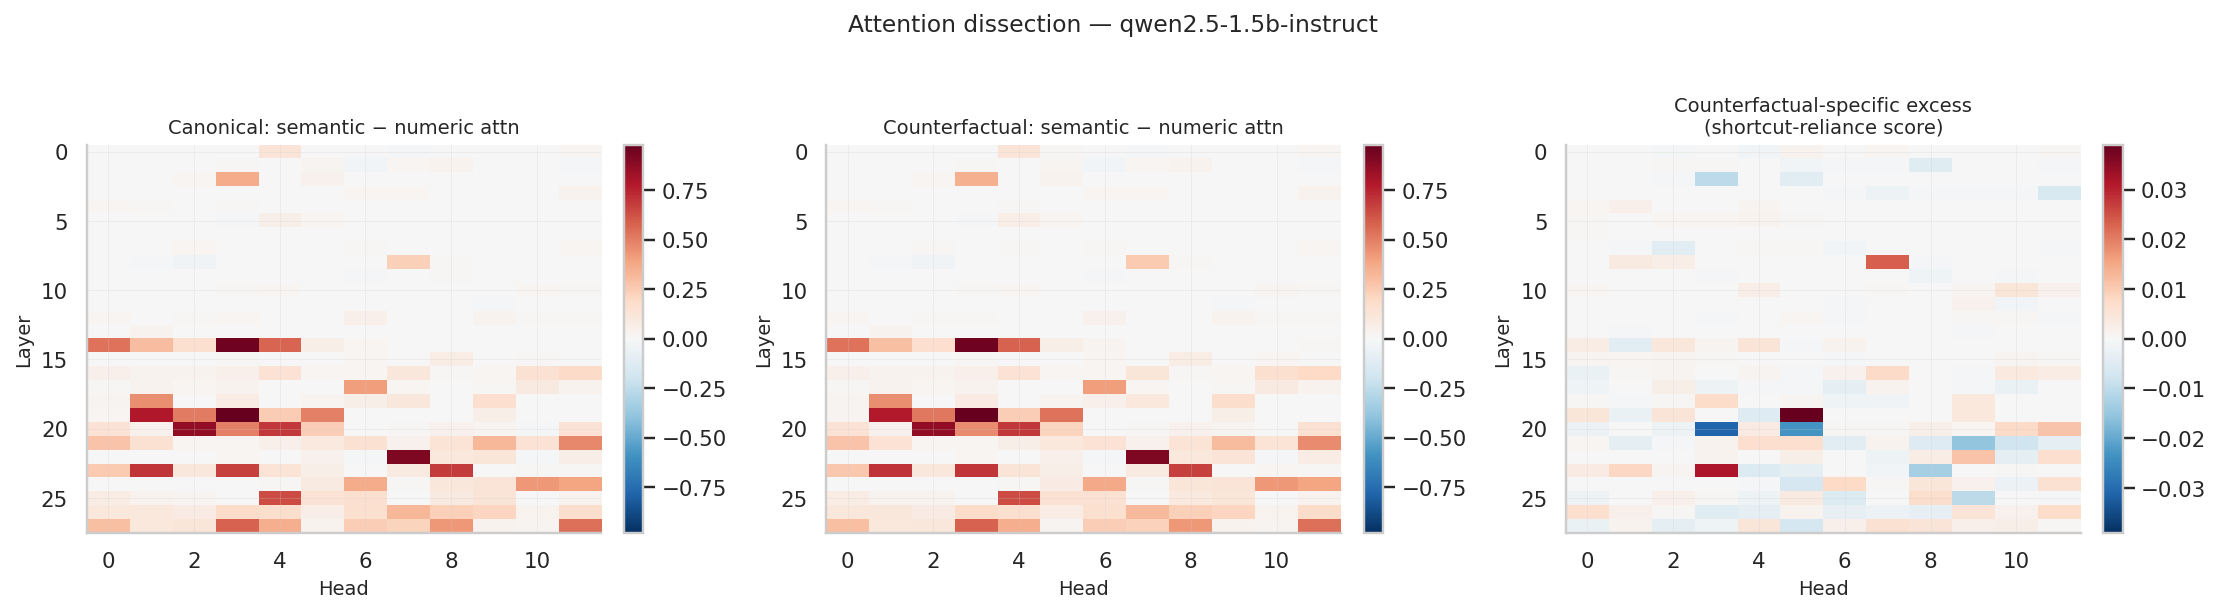

278/336 (layer, head) cells significant after Benjamini-Hochberg correction (alpha=0.05).
Top BH-significant shortcut heads (layer, head), ranked by effect size:
  layer 19, head 5: Δ=+0.0390  (p=1.83e-34)
  layer 23, head 3: Δ=+0.0314  (p=1.53e-44)
  layer 8, head 7: Δ=+0.0233  (p=2.20e-32)
  layer 20, head 11: Δ=+0.0112  (p=5.31e-39)
  layer 22, head 9: Δ=+0.0111  (p=1.36e-29)

Phase 3 -- qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

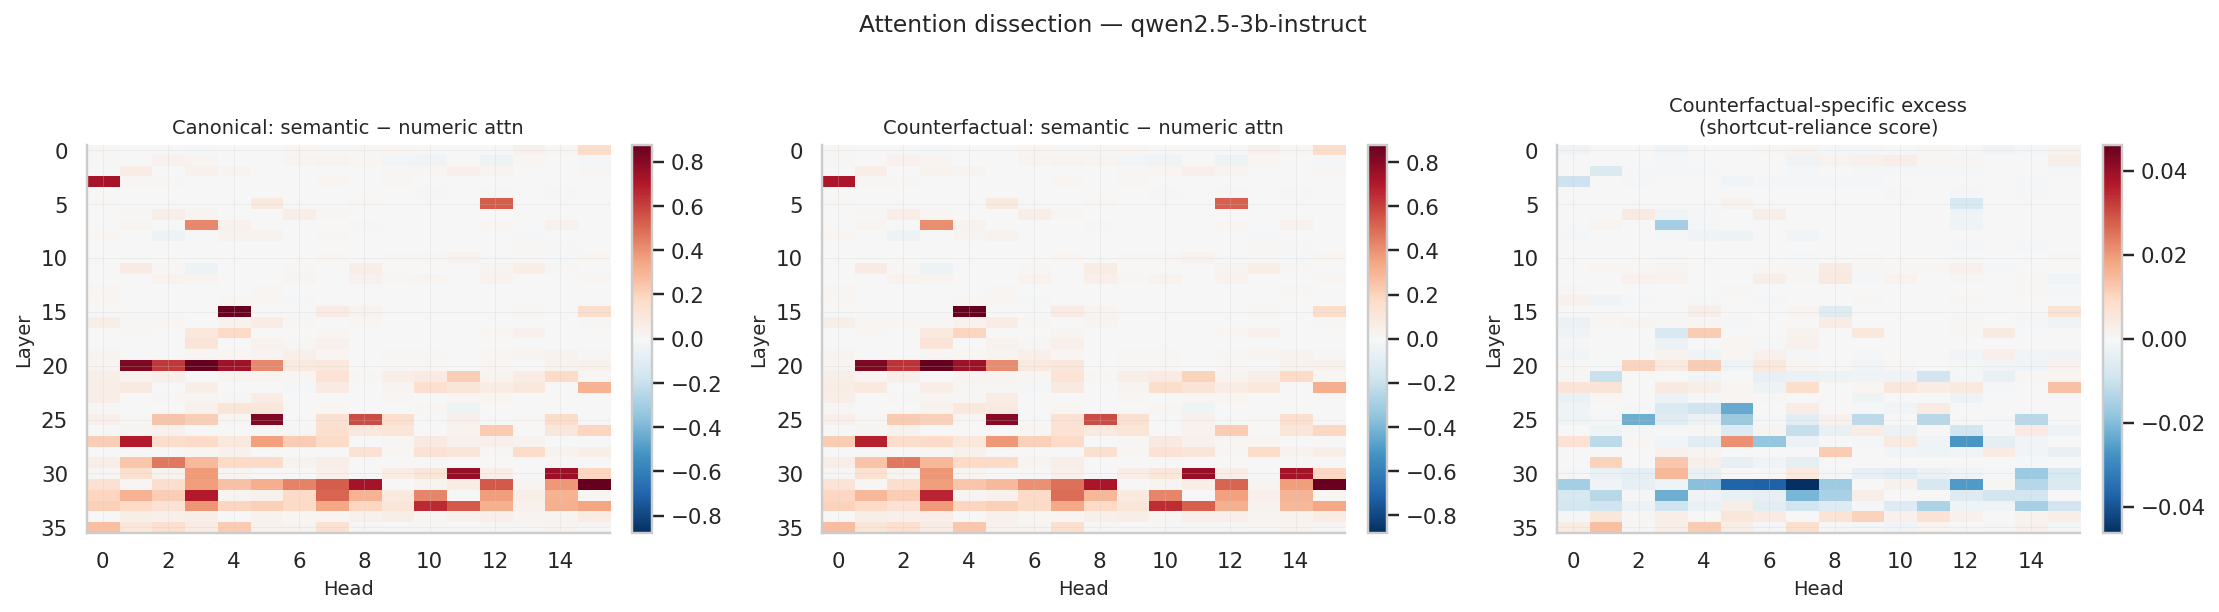

488/576 (layer, head) cells significant after Benjamini-Hochberg correction (alpha=0.05).
Top BH-significant shortcut heads (layer, head), ranked by effect size:
  layer 27, head 5: Δ=+0.0210  (p=3.30e-12)
  layer 30, head 3: Δ=+0.0154  (p=8.65e-22)
  layer 35, head 1: Δ=+0.0140  (p=9.63e-30)
  layer 22, head 15: Δ=+0.0137  (p=9.58e-09)
  layer 29, head 3: Δ=+0.0124  (p=1.04e-24)

Phase 3 -- gemma-2-2b-it (google/gemma-2-2b-it)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

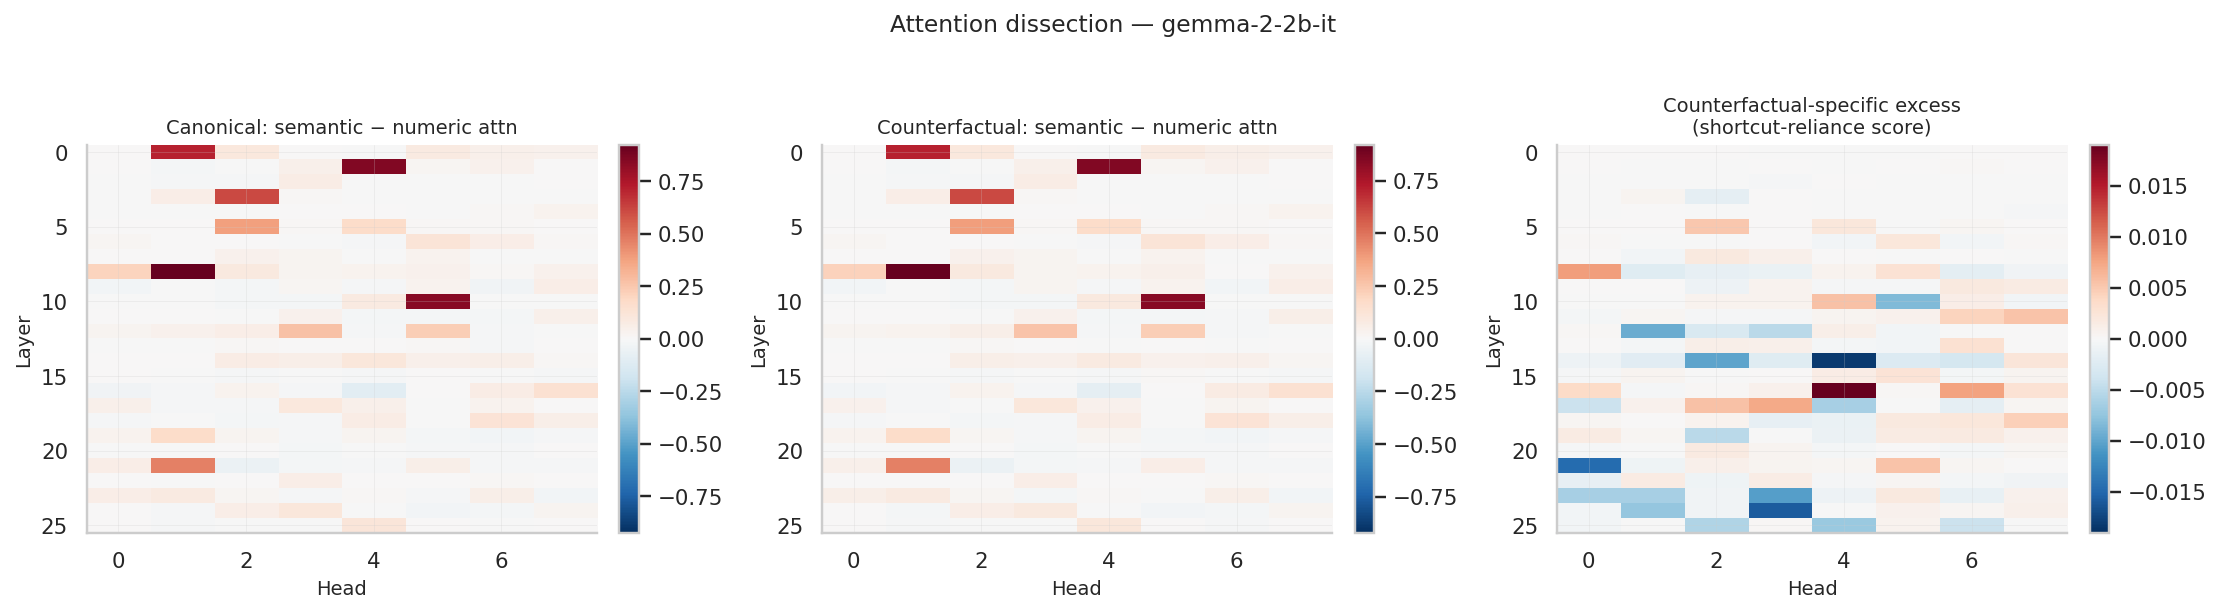

174/208 (layer, head) cells significant after Benjamini-Hochberg correction (alpha=0.05).
Top BH-significant shortcut heads (layer, head), ranked by effect size:
  layer 16, head 4: Δ=+0.0190  (p=7.48e-27)
  layer 8, head 0: Δ=+0.0079  (p=5.25e-59)
  layer 16, head 6: Δ=+0.0077  (p=4.43e-16)
  layer 17, head 3: Δ=+0.0073  (p=2.01e-12)
  layer 10, head 4: Δ=+0.0055  (p=1.86e-07)


In [29]:
for model_key in ACTIVE_MODELS:
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    print(f"\n{'='*70}\nPhase 3 -- {model_key} ({hf_id})\n{'='*70}")
    wrapper = RealModelWrapper(hf_id)

    eval_pair_ids = category_pair_ids(PRIMARY_CATEGORY)
    eval_canon = [id_to_instances[i]["canon"] for i in eval_pair_ids]
    eval_counter = [id_to_instances[i]["counter"] for i in eval_pair_ids]

    deltaA_canon_all = run_phase3_attention_dissection(wrapper, eval_canon)      # (N, L, H)
    deltaA_counter_all = run_phase3_attention_dissection(wrapper, eval_counter)  # (N, L, H)
    deltaA_canon, deltaA_counter = deltaA_canon_all.mean(axis=0), deltaA_counter_all.mean(axis=0)
    deltaA_shortcut = deltaA_counter - deltaA_canon

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    for ax, mat, title in [
        (axes[0], deltaA_canon, "Canonical: semantic − numeric attn"),
        (axes[1], deltaA_counter, "Counterfactual: semantic − numeric attn"),
        (axes[2], deltaA_shortcut, "Counterfactual-specific excess\n(shortcut-reliance score)"),
    ]:
        vmax = max(np.abs(mat).max(), 1e-6)
        im = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_xlabel("Head"); ax.set_ylabel("Layer"); ax.set_title(title, fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Attention dissection — {model_key}", y=1.03)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"phase3_attention_{model_key}.png"), bbox_inches="tight")
    plt.show()

    # Per-(layer,head) paired t-test with Benjamini-Hochberg correction across the
    # WHOLE grid, rather than reporting an uncorrected top-5 as if it were confirmatory.
    n_layers, n_heads = deltaA_shortcut.shape
    p_grid = np.ones((n_layers, n_heads))
    for l in range(n_layers):
        for h in range(n_heads):
            a, b = deltaA_counter_all[:, l, h], deltaA_canon_all[:, l, h]
            if a.std() > 1e-9 or b.std() > 1e-9:
                _, p_grid[l, h] = stats.ttest_rel(a, b)
    sig_grid = benjamini_hochberg(p_grid.ravel(), alpha=0.05).reshape(n_layers, n_heads)
    n_sig = int(sig_grid.sum())
    print(f"{n_sig}/{n_layers * n_heads} (layer, head) cells significant after "
          f"Benjamini-Hochberg correction (alpha=0.05).")

    if n_sig > 0:
        sig_positions = np.argwhere(sig_grid)
        sig_effects = np.array([deltaA_shortcut[l, h] for l, h in sig_positions])
        order = np.argsort(-sig_effects)[:5]
        print("Top BH-significant shortcut heads (layer, head), ranked by effect size:")
        for idx in order:
            l, h = sig_positions[idx]
            print(f"  layer {l}, head {h}: Δ={deltaA_shortcut[l, h]:+.4f}  (p={p_grid[l, h]:.2e})")
        top_heads_report = [(int(sig_positions[idx][0]), int(sig_positions[idx][1])) for idx in order]
    else:
        print("No (layer, head) cell survives correction for this model/sample size -- "
              "the uncorrected top-5 below is exploratory only, not confirmatory:")
        top_flat = np.argsort(-deltaA_shortcut.ravel())[:5]
        top_heads_uncorrected = np.unravel_index(top_flat, deltaA_shortcut.shape)
        for l, h in zip(*top_heads_uncorrected):
            print(f"  layer {l}, head {h}: Δ={deltaA_shortcut[l, h]:+.4f} (uncorrected)")
        top_heads_report = list(zip(top_heads_uncorrected[0].tolist(), top_heads_uncorrected[1].tolist()))

    RESULTS[model_key]["deltaA_canon"] = deltaA_canon
    RESULTS[model_key]["deltaA_counter"] = deltaA_counter
    RESULTS[model_key]["top_shortcut_heads"] = top_heads_report
    RESULTS[model_key]["n_significant_heads_BH"] = n_sig

    wrapper.unload()


### 7.2 Position-Targeted Patching: *which position*, not just *which layer*

Part E's activation patching sweeps **layer**, always at the **final** token position.
That answers "which layer is causally load-bearing," but leaves open a second question:
**is the causally relevant information already fully formed at the label token
positions**, or does it only crystallize at the final "MY CHOICE: [" position via
attention reading from those labels at that layer? This is a coarse, single-layer form of
*path patching* (Wang et al., 2023), instead of patching one position across all layers,
we patch one layer (the `critical_layer` found in Part E) across **different sets of
positions**, using the same offset-based categorization from §7.1.

Three conditions, all patched at `critical_layer`:
- **Final only** - reproduces Part E's own metric at that layer, as a sanity check.
- **Label positions only** - overwrite *only* the `option_A`/`option_B` label token
  positions (identified via `token_position_categories`) with their clean-run values,
  leaving the final position's own (corrupted) computation otherwise undisturbed.
- **Label + final** - both together.

If "label positions only" already recovers most of the effect, the shortcut-relevant
computation is localized *at the labels themselves* and merely gets read out downstream —
a stronger, more specific localization claim than Part E's layer-only sweep supports on
its own.


In [30]:
def _make_multi_position_patch_hook(position_vectors: Dict[int, torch.Tensor]):
    '''Generalizes _make_patch_hook to multiple positions at once. position_vectors
    maps padded-sequence position index -> replacement vector (D,) or (B,D).'''
    def hook(module, inp, out):
        is_tuple = isinstance(out, tuple)
        hs = out[0] if is_tuple else out
        hs = hs.clone()
        for pos, vec in position_vectors.items():
            hs[:, pos, :] = vec.to(hs.dtype).to(hs.device)
        return (hs,) + out[1:] if is_tuple else hs
    return hook

@torch.no_grad()
def forward_with_multi_position_patch(wrapper: RealModelWrapper, input_ids: torch.Tensor, layer: int,
                                       position_vectors: Dict[int, torch.Tensor],
                                       attention_mask: Optional[torch.Tensor] = None,
                                       position_ids: Optional[torch.Tensor] = None):
    handle = wrapper.layers[layer].register_forward_hook(_make_multi_position_patch_hook(position_vectors))
    try:
        out = wrapper.model(input_ids=input_ids.to(wrapper.device),
                             attention_mask=attention_mask.to(wrapper.device) if attention_mask is not None else None,
                             position_ids=position_ids.to(wrapper.device) if position_ids is not None else None)
    finally:
        handle.remove()
    return out.logits

@torch.no_grad()
def run_position_targeted_patching(wrapper: RealModelWrapper, canon: List["GameInstanceSchema"],
                                    counter: List["GameInstanceSchema"], layer: int, batch_size: int = 16):
    '''Returns a dict {condition_name: array of per-instance R scores} for the
    three patching conditions described above, all at a single fixed layer.'''
    n = len(canon)
    conditions = ["final_only", "labels_only", "labels_and_final"]
    R = {c: np.zeros(n) for c in conditions}
    wrapper.tokenizer.padding_side = "left"

    for s in range(0, n, batch_size):
        c_batch, k_batch = canon[s:s + batch_size], counter[s:s + batch_size]
        b = np.arange(len(c_batch))
        pos_ids_tok = np.array([instance_token_ids(wrapper, c)[0] for c in c_batch])
        neg_ids_tok = np.array([instance_token_ids(wrapper, c)[1] for c in c_batch])

        c_enc = wrapper.tokenizer([render_prompt(c) for c in c_batch], return_tensors="pt", padding=True)
        k_enc = wrapper.tokenizer([render_prompt(k) for k in k_batch], return_tensors="pt", padding=True)
        c_pos, k_pos = compute_left_pad_position_ids(c_enc.attention_mask), compute_left_pad_position_ids(k_enc.attention_mask)
        n_pad_c = (c_enc.attention_mask == 0).sum(dim=1).cpu().numpy()
        n_pad_k = (k_enc.attention_mask == 0).sum(dim=1).cpu().numpy()

        clean_logits, clean_cache = wrapper.forward(c_enc.input_ids, c_enc.attention_mask, c_pos)
        corrupted_logits, _ = wrapper.forward(k_enc.input_ids, k_enc.attention_mask, k_pos)
        clean_resid = clean_cache["resid"][layer + 1]   # (B, T, D)

        dl_clean = clean_logits[:, -1, :][b, pos_ids_tok].float().cpu().numpy() - clean_logits[:, -1, :][b, neg_ids_tok].float().cpu().numpy()
        dl_corrupted = corrupted_logits[:, -1, :][b, pos_ids_tok].float().cpu().numpy() - corrupted_logits[:, -1, :][b, neg_ids_tok].float().cpu().numpy()
        denom = dl_clean - dl_corrupted
        denom = np.where(np.abs(denom) < 1e-4, np.sign(denom) * 1e-4 + 1e-6, denom)

        for i, (c_inst, k_inst) in enumerate(zip(c_batch, k_batch)):
            sem_idx_c, _ = token_position_categories(wrapper.tokenizer, c_inst)
            label_positions_padded = [int(n_pad_c[i]) + idx for idx in sem_idx_c]
            final_pos = k_enc.input_ids.shape[1] - 1

            pv_final = {final_pos: clean_resid[i, -1, :]}
            pv_labels = {p: clean_resid[i, p, :] for p in label_positions_padded if p < clean_resid.shape[1]}
            pv_both = {**pv_labels, **pv_final}

            single_ids = k_enc.input_ids[i:i + 1]
            single_mask = k_enc.attention_mask[i:i + 1]
            single_pos = k_pos[i:i + 1]
            for cond_name, pv in [("final_only", pv_final), ("labels_only", pv_labels), ("labels_and_final", pv_both)]:
                if len(pv) == 0:
                    continue
                pv_batched = {p: v.unsqueeze(0) for p, v in pv.items()}
                patched_logits = forward_with_multi_position_patch(wrapper, single_ids, layer, pv_batched,
                                                                     single_mask, single_pos)
                dl_patched = (patched_logits[0, -1, pos_ids_tok[i]] - patched_logits[0, -1, neg_ids_tok[i]]).float().cpu().item()
                R[cond_name][s + i] = (dl_patched - dl_corrupted[i]) / denom[i]
    return R



Phase 3.2 (Position-Targeted Patching) -- pythia-410m (EleutherAI/pythia-410m)


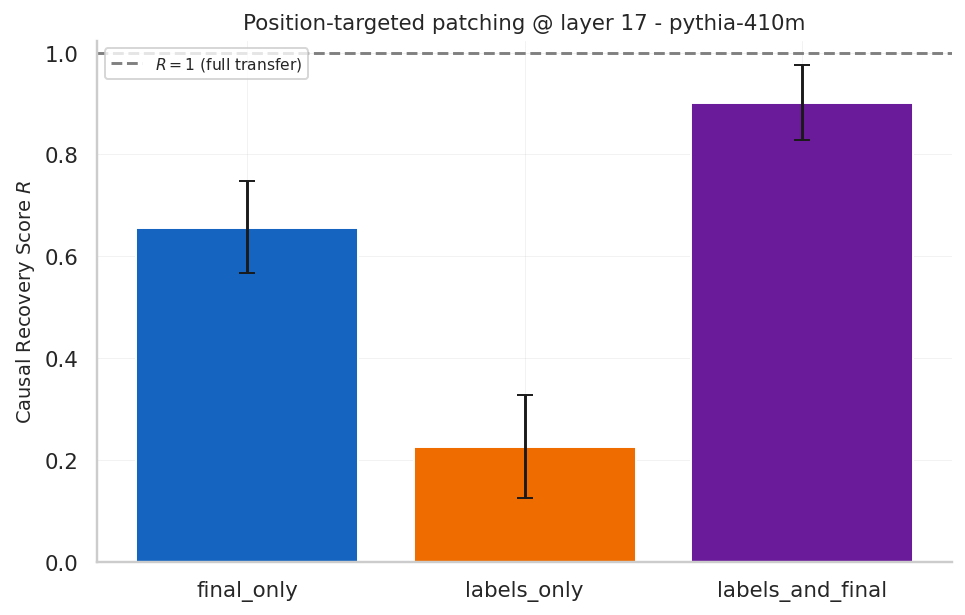

final_only: 0.655   labels_only: 0.225   labels_and_final: 0.902

Phase 3.2 (Position-Targeted Patching) -- llama-3.2-1b (meta-llama/Llama-3.2-1B)


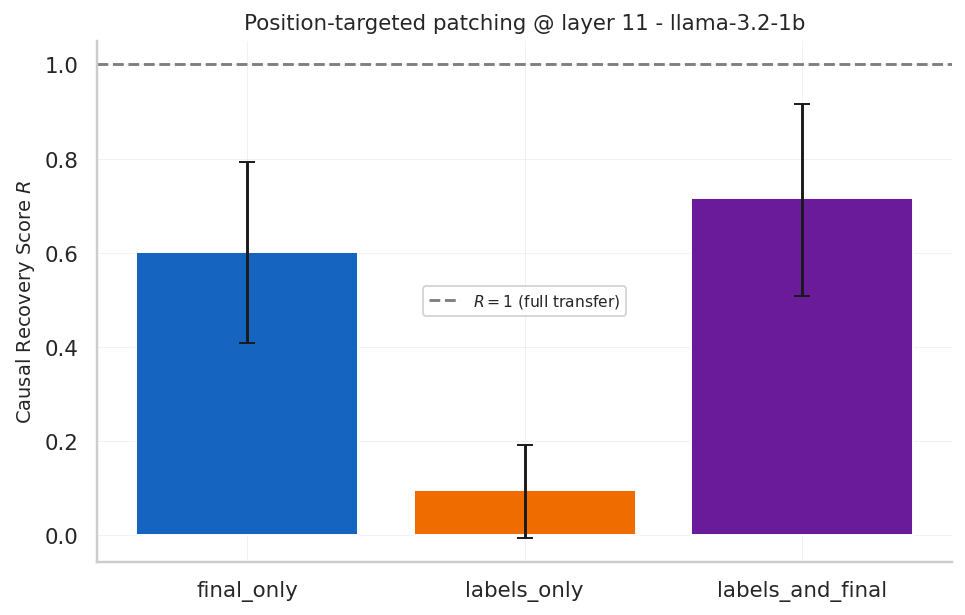

final_only: 0.602   labels_only: 0.095   labels_and_final: 0.716

Phase 3.2 (Position-Targeted Patching) -- llama-3.2-1b-instruct (meta-llama/Llama-3.2-1B-Instruct)


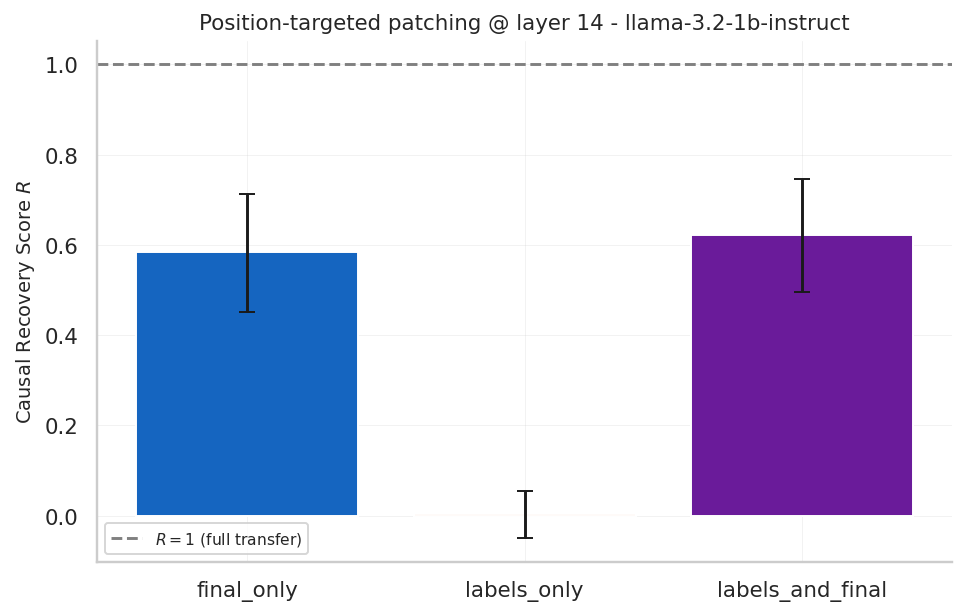

final_only: 0.585   labels_only: 0.004   labels_and_final: 0.622

Phase 3.2 (Position-Targeted Patching) -- qwen2.5-1.5b-instruct (Qwen/Qwen2.5-1.5B-Instruct)


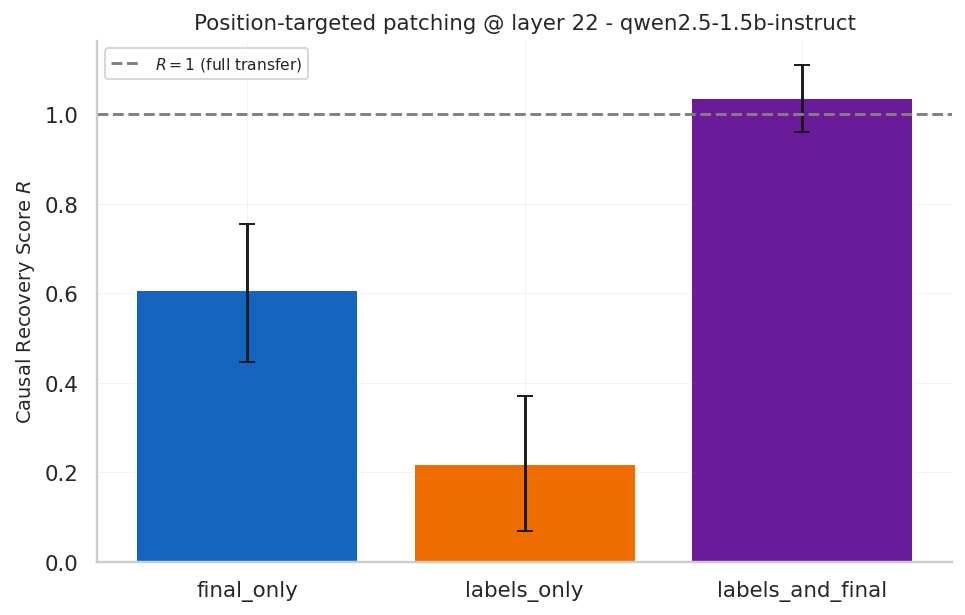

final_only: 0.608   labels_only: 0.218   labels_and_final: 1.037

Phase 3.2 (Position-Targeted Patching) -- qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

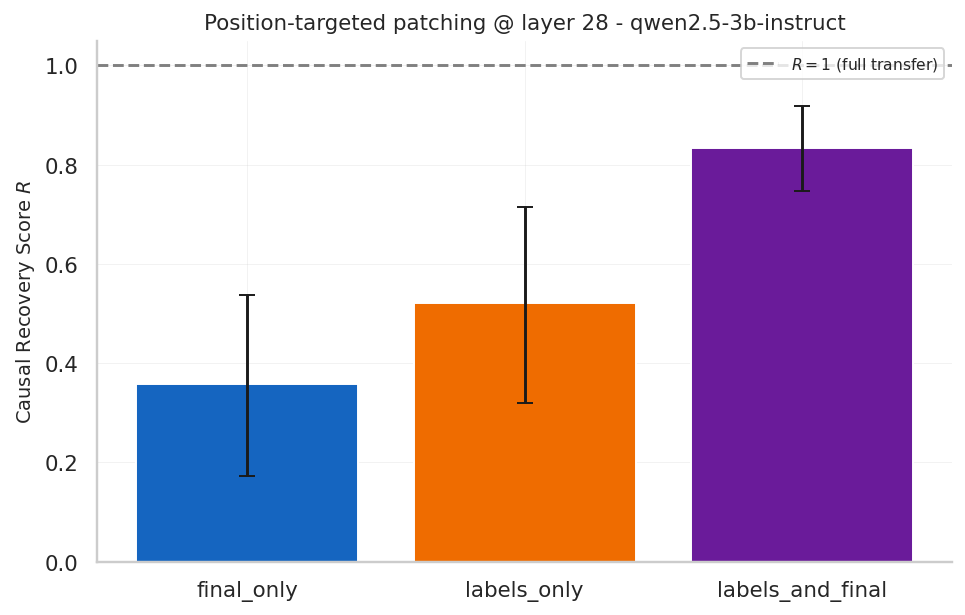

final_only: 0.359   labels_only: 0.522   labels_and_final: 0.834
>> Patching the label positions ALONE recovers most of the final-position effect: the shortcut-relevant computation is localized at the labels themselves, not assembled fresh at the final position.

Phase 3.2 (Position-Targeted Patching) -- gemma-2-2b-it (google/gemma-2-2b-it)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

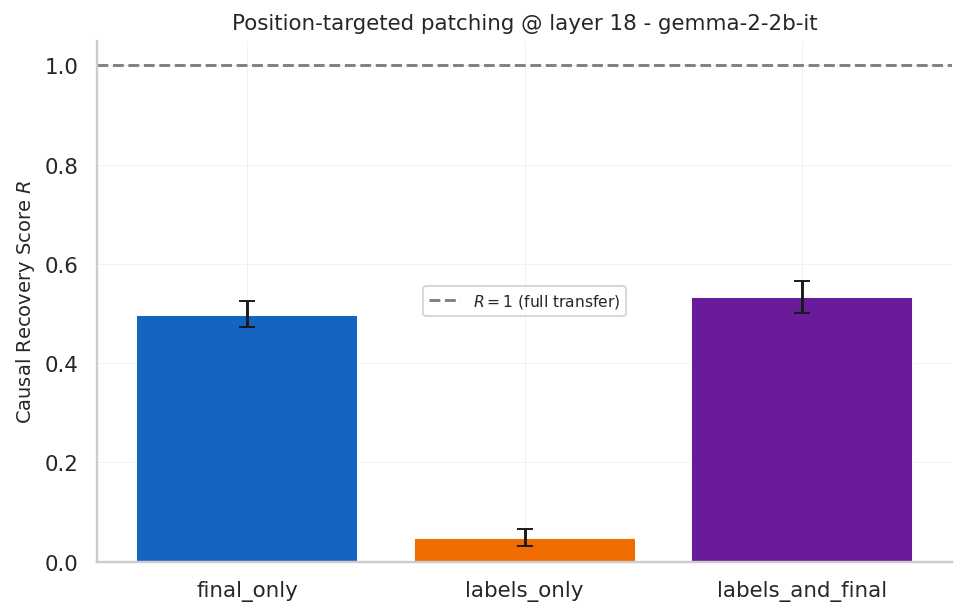

final_only: 0.498   labels_only: 0.048   labels_and_final: 0.534


In [31]:
for model_key in ACTIVE_MODELS:
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    r = RESULTS.get(model_key, {})
    if "critical_layer" not in r:
        print(f"Skipping position-targeted patching for {model_key}: no critical_layer from Part E.")
        continue
    print(f"\n{'='*70}\nPhase 3.2 (Position-Targeted Patching) -- {model_key} ({hf_id})\n{'='*70}")
    wrapper = RealModelWrapper(hf_id)

    ptp_pair_ids = subsample_pair_ids(category_pair_ids(PRIMARY_CATEGORY), min(PATCH_EVAL_N, 150), seed=SEED + 7)
    ptp_canon = [id_to_instances[i]["canon"] for i in ptp_pair_ids]
    ptp_counter = [id_to_instances[i]["counter"] for i in ptp_pair_ids]

    R_by_condition = run_position_targeted_patching(wrapper, ptp_canon, ptp_counter, r["critical_layer"])

    fig, ax = plt.subplots(figsize=(7, 4.5))
    conditions = ["final_only", "labels_only", "labels_and_final"]
    means = [np.clip(R_by_condition[c], -2, 2).mean() for c in conditions]
    cis = [bootstrap_ci(np.clip(R_by_condition[c], -2, 2)) for c in conditions]
    los = [ci[1] for ci in cis]; his = [ci[2] for ci in cis]
    ax.bar(conditions, means, yerr=[[m - l for m, l in zip(means, los)], [h - m for h, m in zip(his, means)]],
           capsize=4, color=["#1565C0", "#EF6C00", "#6A1B9A"])
    ax.axhline(1, color="gray", linestyle="--", label=r"$R=1$ (full transfer)")
    ax.set_ylabel(r"Causal Recovery Score $R$"); ax.set_title(f"Position-targeted patching @ layer {r['critical_layer']} - {model_key}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"phase3b_position_patch_{model_key}.png"))
    plt.show()

    print(f"final_only: {means[0]:.3f}   labels_only: {means[1]:.3f}   labels_and_final: {means[2]:.3f}")
    if means[1] >= 0.7 * means[0] and means[0] > 0.1:
        print(">> Patching the label positions ALONE recovers most of the final-position effect: "
              "the shortcut-relevant computation is localized at the labels themselves, not "
              "assembled fresh at the final position.")

    RESULTS[model_key]["position_targeted_patching"] = {c: float(np.clip(R_by_condition[c], -2, 2).mean()) for c in conditions}
    wrapper.unload()


### 7.3 Three-Probe Linear Probing for Representational Detection [TIER 1]

A single probe target ("is `correct_slot` linearly decodable") cannot distinguish *why*
it fails to generalize: representation change, semantic dominance, and a probe simply
exploiting superficial correlations all look the same from one number. We fit **three**
targeted probes per layer instead, following the same train-on-canonical,
test-on-counterfactual split (Definition 0.7) for each:

- **Probe A - payoff-optimal action.** Target: `correct_slot` (ground truth, a property
  of the payoffs only). A low counterfactual-test accuracy here is the direct
  representational analogue of the model's own behavioral accuracy drop.
- **Probe B - label valence.** Target: which slot currently holds the category's
  positive-pool word (well-defined in both projections, no generalization asymmetry
  expected - this is a sanity ceiling: valence should be *easily* decodable everywhere,
  confirming the probes work at all).
- **Probe C - the model's own eventual decision.** Target: which slot the model actually
  predicts (derived from its own output logits, not ground truth). Comparing Probe C's
  layer-of-emergence against Probe A's tests whether the model's answer becomes
  predictable *before* the payoff-optimal direction is even reliably present, i.e.
  whether the decision is being driven by something that isn't yet "correctness."

Plotting all three together answers the reviewer's request directly: does payoff
information, valence information, or decision information emerge first, and at which
layer do payoff and decision information *decouple* under the counterfactual projection?


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
import warnings as _warnings

PROBE_TARGETS = ["payoff_optimal", "label_valence", "model_decision"]

@torch.no_grad()
def extract_residuals_and_predictions(wrapper: RealModelWrapper, instances: List["GameInstanceSchema"],
                                       batch_size: int = 32) -> Tuple[np.ndarray, np.ndarray]:
    '''Returns (residuals (N, n_layers+1, D), model_predicted_slot (N,) in {0,1}=={A,B}),
    both from the SAME forward pass -- avoids a second pass just to get predictions.'''
    n = len(instances)
    resid_out = np.zeros((n, wrapper.n_layers + 1, wrapper.d_model), dtype=np.float32)
    pred_slot = np.zeros(n, dtype=np.int64)
    offset = 0
    for batch, logits, cache in batched_forward(wrapper, instances, batch_size):
        for l, resid in enumerate(cache["resid"]):
            resid_out[offset:offset + len(batch), l, :] = resid[:, -1, :].float().cpu().numpy()
        dl = delta_logit_batch(logits[:, -1, :], batch, wrapper)   # >0 means model predicted CORRECT label
        for i, inst in enumerate(batch):
            correct_slot_idx = 0 if inst.correct_slot == "A" else 1
            incorrect_slot_idx = 1 - correct_slot_idx
            pred_slot[offset + i] = correct_slot_idx if dl[i] > 0 else incorrect_slot_idx
        offset += len(batch)
    return resid_out, pred_slot

def get_probe_labels(instances: List["GameInstanceSchema"], target: str, model_pred_slot: Optional[np.ndarray] = None) -> np.ndarray:
    '''Ground-truth label array for one probe target. `model_decision` requires
    model_pred_slot (from extract_residuals_and_predictions on THESE instances).'''
    if target == "payoff_optimal":
        return np.array([0 if i.correct_slot == "A" else 1 for i in instances])
    elif target == "label_valence":
        # Which slot holds the category's positive-pool word: correct_slot under canon,
        # the OTHER slot under counter (by construction, Part C.1).
        out = np.zeros(len(instances), dtype=np.int64)
        for idx, inst in enumerate(instances):
            correct_slot_idx = 0 if inst.correct_slot == "A" else 1
            out[idx] = correct_slot_idx if inst.projection == "canon" else (1 - correct_slot_idx)
        return out
    elif target == "model_decision":
        assert model_pred_slot is not None, "model_decision requires model_pred_slot"
        return model_pred_slot
    raise ValueError(f"Unknown probe target: {target}")

def run_three_probe_analysis(wrapper: RealModelWrapper, canon_train, canon_test, counter_test,
                              counter_unseen=None) -> Dict[str, Dict[str, np.ndarray]]:
    """counter_unseen (optional): counterfactual instances built from words the
    probe never saw during training (4.5) -- fit on canon_train (which uses
    FIT_PAIR_IDS words only, see the call site), tested on words drawn from a
    disjoint pool. This is the direct test of whether the probe has learned
    "valence, as a category" or has memorized the specific training words."""
    resid_train, pred_train = extract_residuals_and_predictions(wrapper, canon_train)
    resid_test_canon, pred_test_canon = extract_residuals_and_predictions(wrapper, canon_test)
    resid_test_counter, pred_test_counter = extract_residuals_and_predictions(wrapper, counter_test)
    n_layers_plus_1 = resid_train.shape[1]
    has_unseen = counter_unseen is not None and len(counter_unseen) > 0
    if has_unseen:
        resid_test_unseen, pred_test_unseen = extract_residuals_and_predictions(wrapper, counter_unseen)

    results = {}
    with _warnings.catch_warnings():
        _warnings.simplefilter("ignore", category=ConvergenceWarning)
        for target in PROBE_TARGETS:
            y_train = get_probe_labels(canon_train, target, pred_train)
            y_test_canon = get_probe_labels(canon_test, target, pred_test_canon)
            y_test_counter = get_probe_labels(counter_test, target, pred_test_counter)
            acc_canon = np.full(n_layers_plus_1, np.nan)
            acc_counter = np.full(n_layers_plus_1, np.nan)
            acc_unseen = np.full(n_layers_plus_1, np.nan) if has_unseen else None
            if has_unseen:
                y_test_unseen = get_probe_labels(counter_unseen, target, pred_test_unseen)
            if len(np.unique(y_train)) < 2:
                results[target] = {"canon": acc_canon, "counter": acc_counter, "unseen": acc_unseen}
                continue
            for l in range(n_layers_plus_1):
                clf = LogisticRegression(max_iter=500, C=1.0)
                clf.fit(resid_train[:, l, :], y_train)
                acc_canon[l] = clf.score(resid_test_canon[:, l, :], y_test_canon)
                acc_counter[l] = clf.score(resid_test_counter[:, l, :], y_test_counter)
                if has_unseen:
                    acc_unseen[l] = clf.score(resid_test_unseen[:, l, :], y_test_unseen)
            results[target] = {"canon": acc_canon, "counter": acc_counter, "unseen": acc_unseen}
    return results

PROBE_TRAIN_N = 200
PROBE_TEST_N = 150
PROBE_UNSEEN_N = 150   # unseen-word generalization test set size (4.5)



Phase 3.3 (Three-Probe Detection) -- pythia-410m (EleutherAI/pythia-410m)


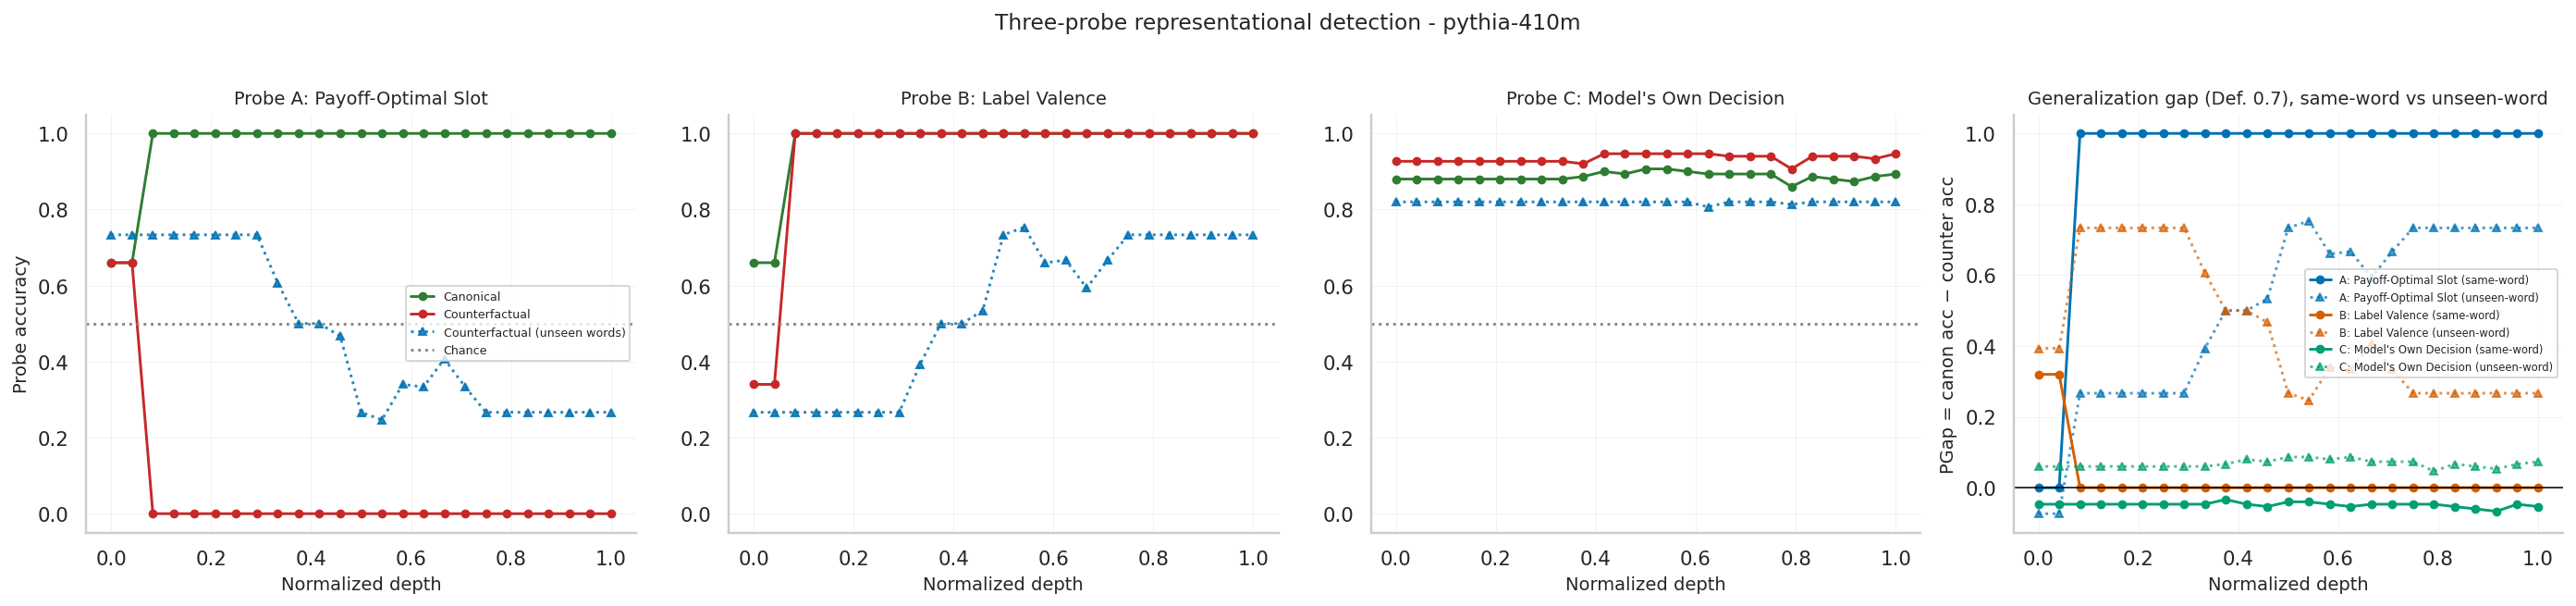

Probe A (payoff-optimal) generalization gap by depth: [0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.]
Largest gap at layer 2 (depth=0.08): canonical=100.0%, counterfactual=0.0%
Probe B (valence) counterfactual accuracy, same layer: 100.0% (a high value here alongside a low Probe A value is the clearest single-figure evidence of representational confounding: valence is present and decodable exactly where payoff-truth is not).
Unseen-word generalization (4.5): peak same-word PGap=1.000, peak unseen-word PGap=0.753 (75% retained on words never seen during probe fitting -- a low retained fraction would suggest the confound is closer to lexical memorization than a general valence representation).

Phase 3.3 (Three-Probe Detection) -- llama-3.2-1b (meta-llama/Llama-3.2-1B)


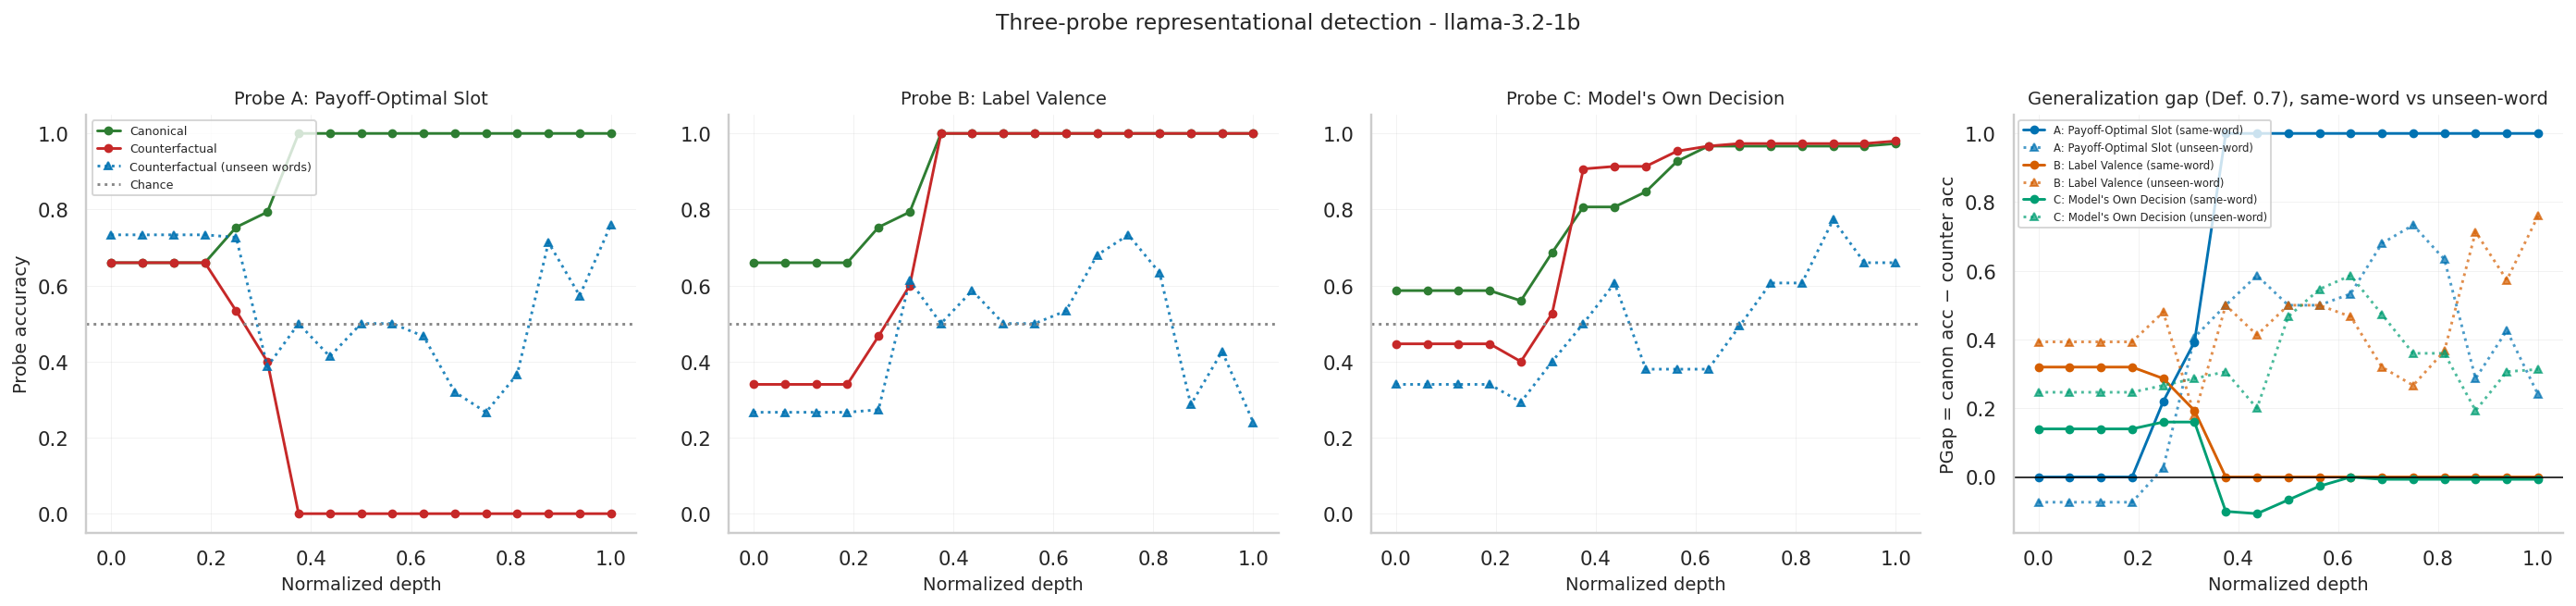

Probe A (payoff-optimal) generalization gap by depth: [0.    0.    0.    0.    0.22  0.393 1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.   ]
Largest gap at layer 6 (depth=0.38): canonical=100.0%, counterfactual=0.0%
Probe B (valence) counterfactual accuracy, same layer: 100.0% (a high value here alongside a low Probe A value is the clearest single-figure evidence of representational confounding: valence is present and decodable exactly where payoff-truth is not).
Unseen-word generalization (4.5): peak same-word PGap=1.000, peak unseen-word PGap=0.733 (73% retained on words never seen during probe fitting -- a low retained fraction would suggest the confound is closer to lexical memorization than a general valence representation).

Phase 3.3 (Three-Probe Detection) -- llama-3.2-1b-instruct (meta-llama/Llama-3.2-1B-Instruct)


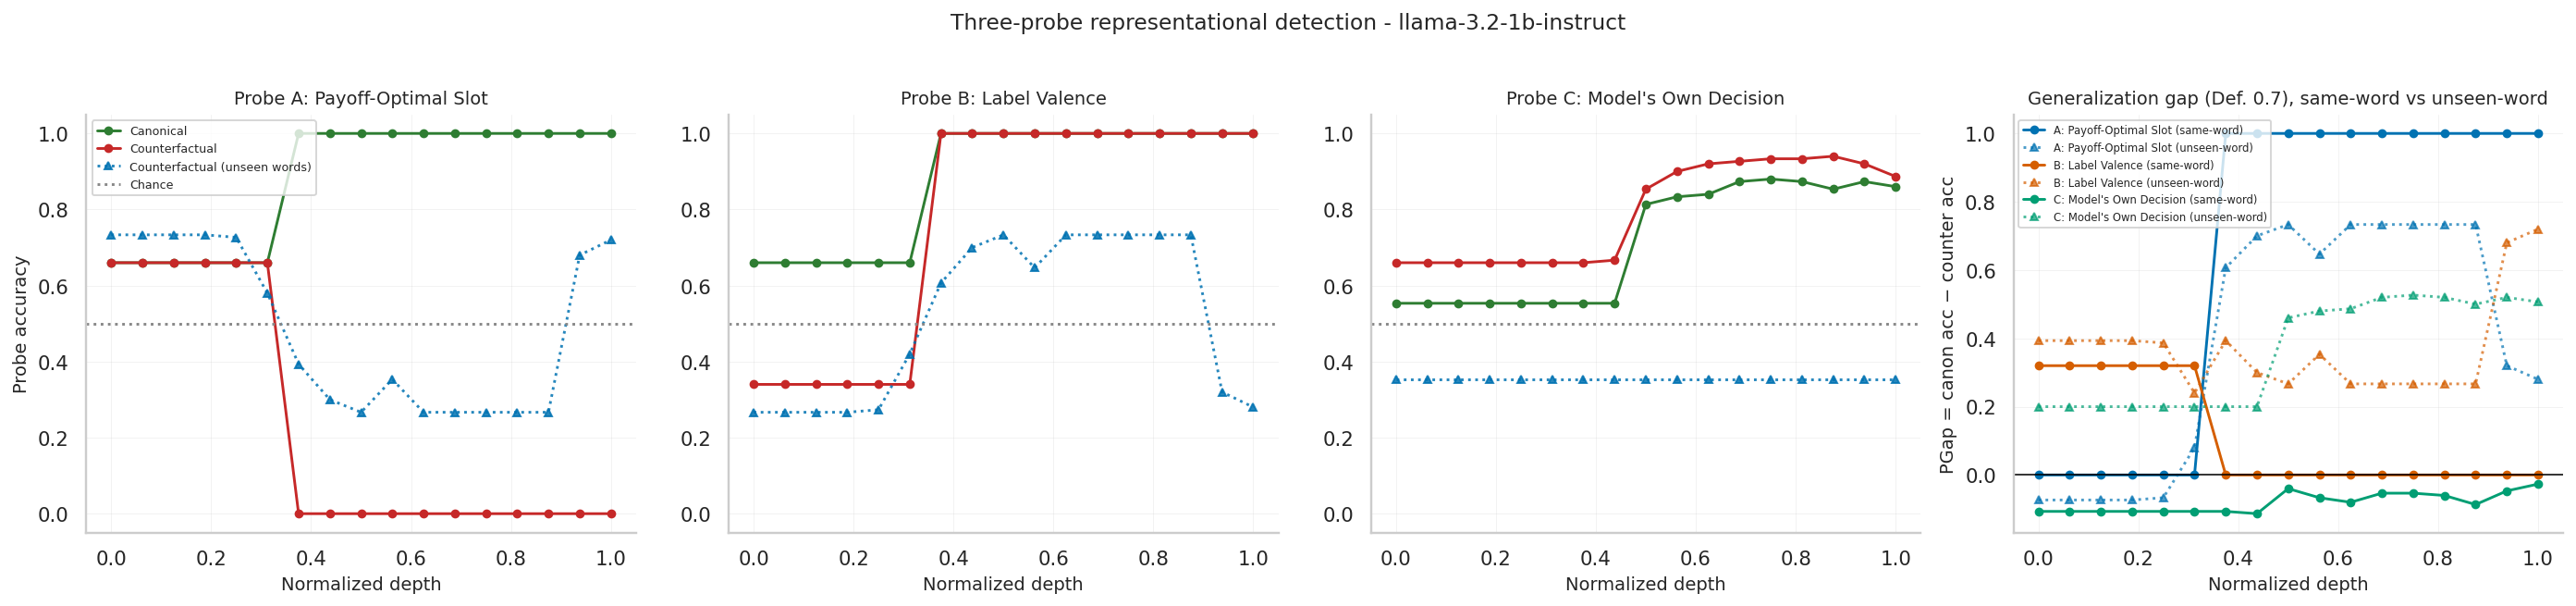

Probe A (payoff-optimal) generalization gap by depth: [0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Largest gap at layer 6 (depth=0.38): canonical=100.0%, counterfactual=0.0%
Probe B (valence) counterfactual accuracy, same layer: 100.0% (a high value here alongside a low Probe A value is the clearest single-figure evidence of representational confounding: valence is present and decodable exactly where payoff-truth is not).
Unseen-word generalization (4.5): peak same-word PGap=1.000, peak unseen-word PGap=0.733 (73% retained on words never seen during probe fitting -- a low retained fraction would suggest the confound is closer to lexical memorization than a general valence representation).

Phase 3.3 (Three-Probe Detection) -- qwen2.5-1.5b-instruct (Qwen/Qwen2.5-1.5B-Instruct)


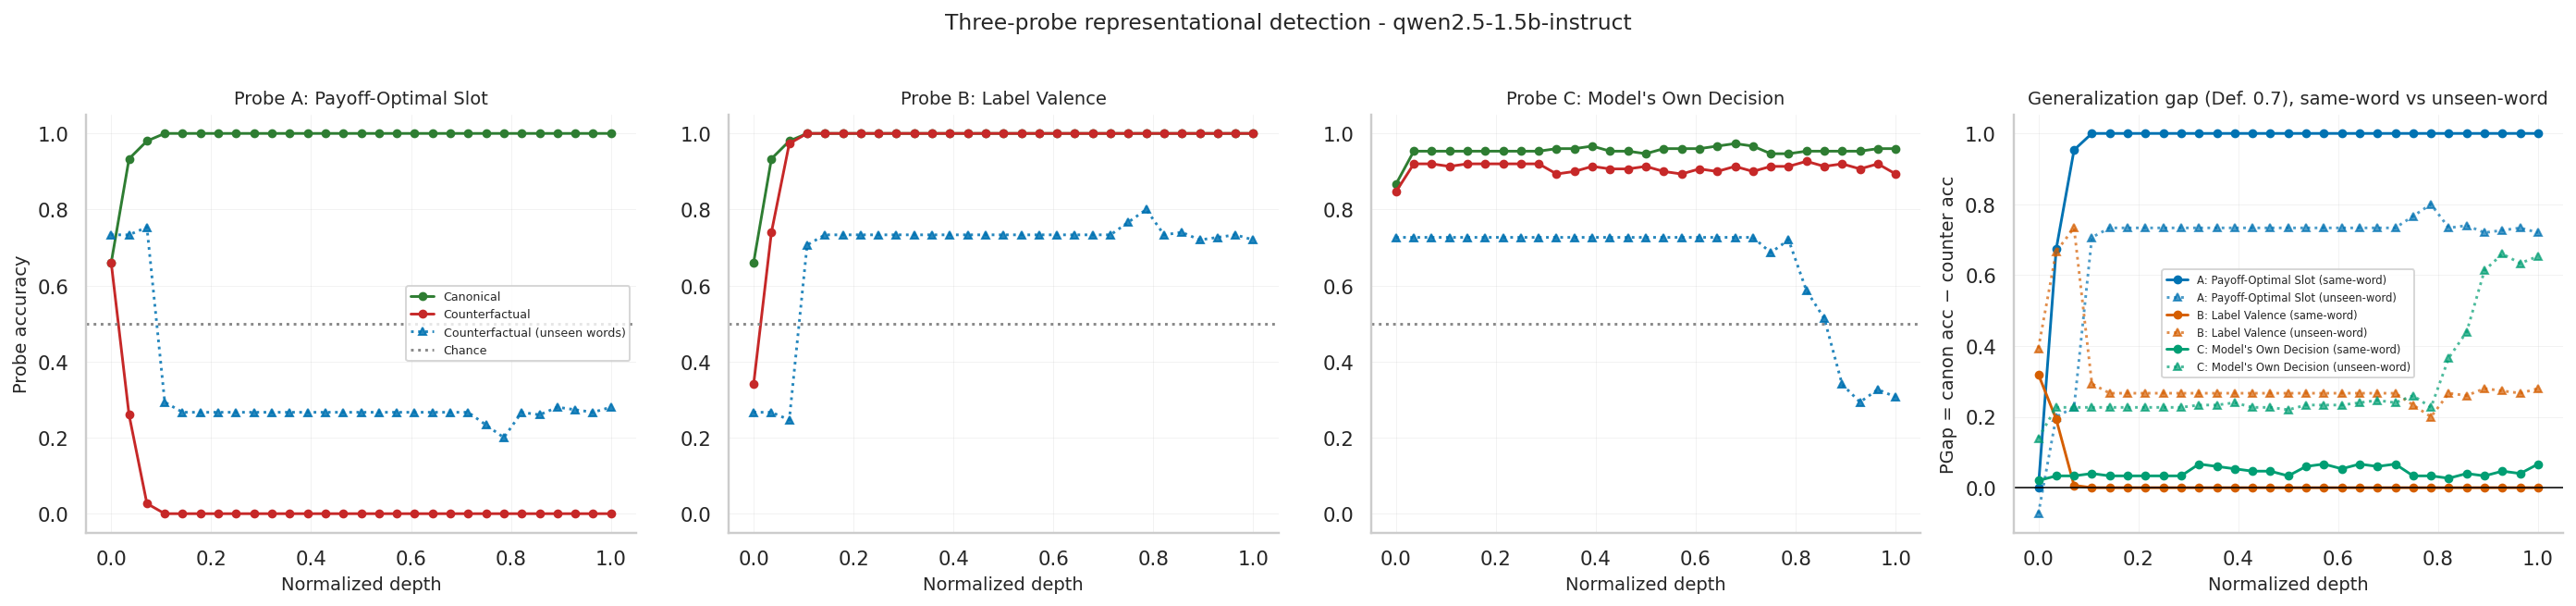

Probe A (payoff-optimal) generalization gap by depth: [0.    0.673 0.953 1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.   ]
Largest gap at layer 3 (depth=0.11): canonical=100.0%, counterfactual=0.0%
Probe B (valence) counterfactual accuracy, same layer: 100.0% (a high value here alongside a low Probe A value is the clearest single-figure evidence of representational confounding: valence is present and decodable exactly where payoff-truth is not).
Unseen-word generalization (4.5): peak same-word PGap=1.000, peak unseen-word PGap=0.800 (80% retained on words never seen during probe fitting -- a low retained fraction would suggest the confound is closer to lexical memorization than a general valence representation).

Phase 3.3 (Three-Probe Detection) -- qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

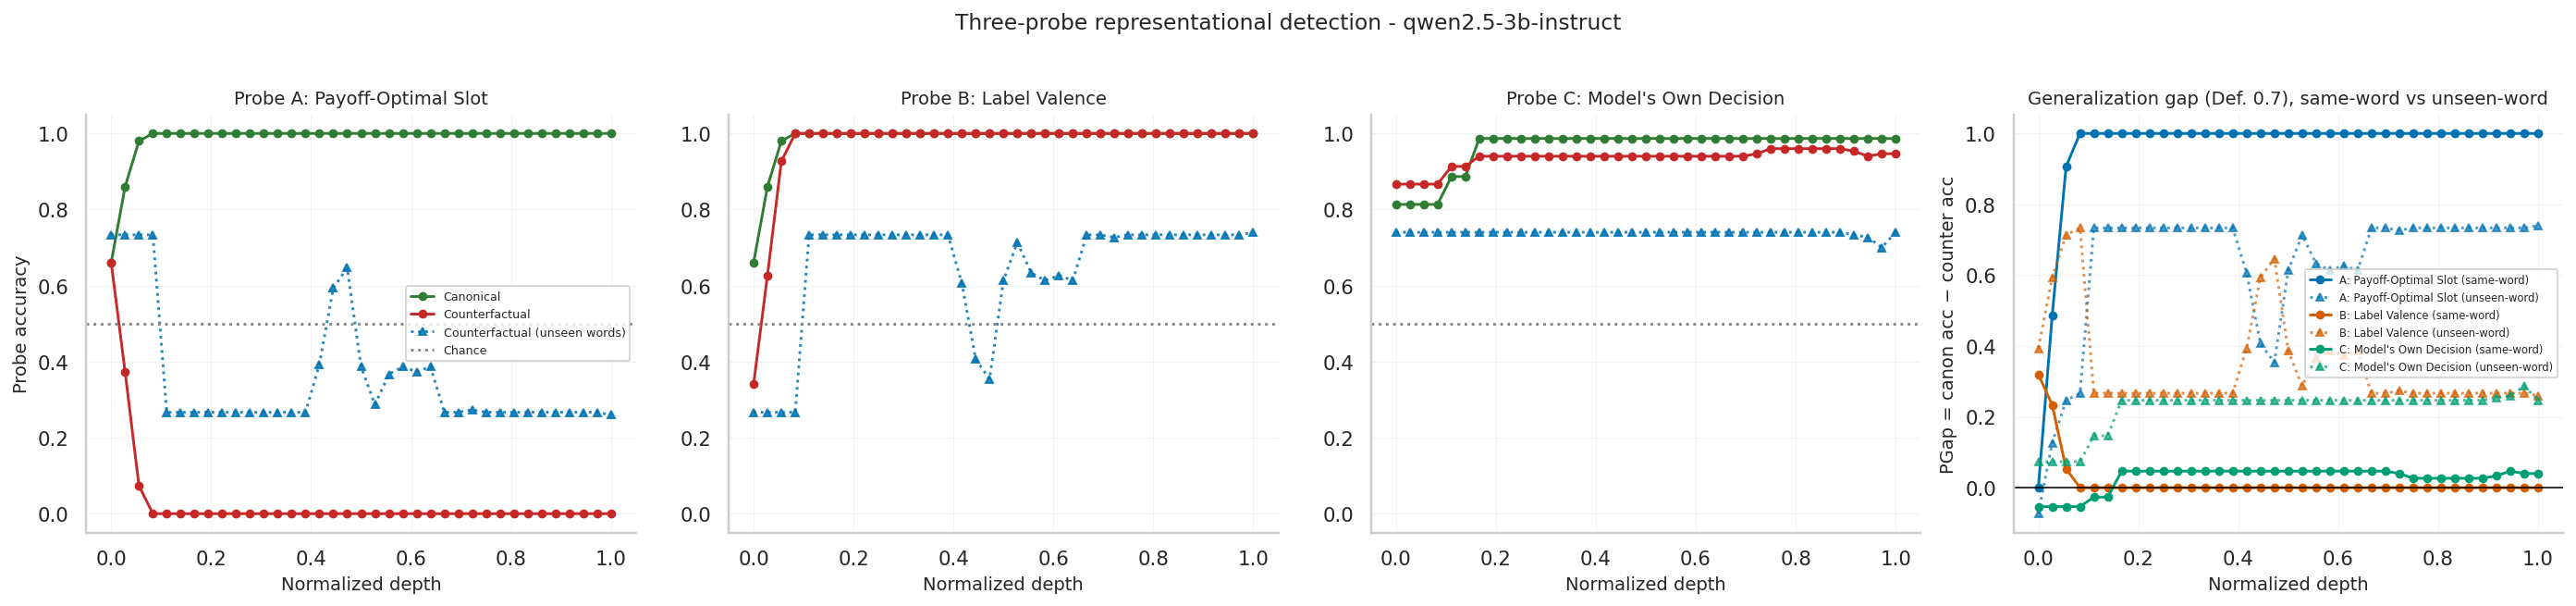

Probe A (payoff-optimal) generalization gap by depth: [0.    0.487 0.907 1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.   ]
Largest gap at layer 3 (depth=0.08): canonical=100.0%, counterfactual=0.0%
Probe B (valence) counterfactual accuracy, same layer: 100.0% (a high value here alongside a low Probe A value is the clearest single-figure evidence of representational confounding: valence is present and decodable exactly where payoff-truth is not).
Unseen-word generalization (4.5): peak same-word PGap=1.000, peak unseen-word PGap=0.740 (74% retained on words never seen during probe fitting -- a low retained fraction would suggest the confound is closer to lexical memorization than a general valence representation).

Phase 3.3 (Three-Probe Detection) -- gemma-2-2b-it (google/gemma-2-2b-it)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

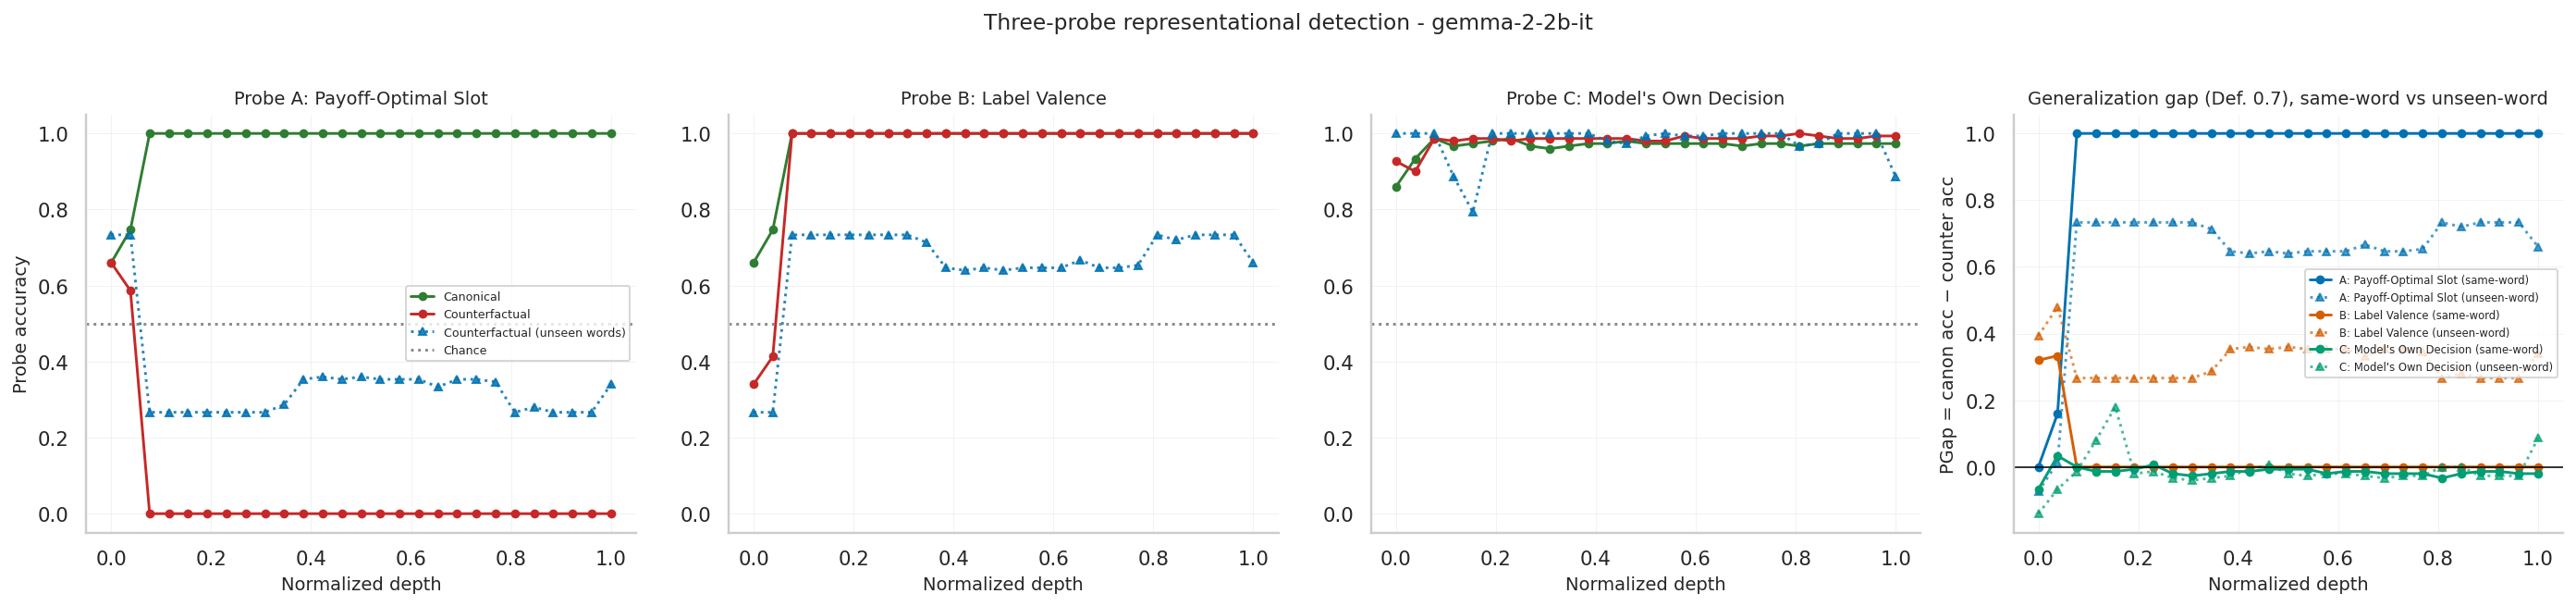

Probe A (payoff-optimal) generalization gap by depth: [0.   0.16 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.  ]
Largest gap at layer 2 (depth=0.08): canonical=100.0%, counterfactual=0.0%
Probe B (valence) counterfactual accuracy, same layer: 100.0% (a high value here alongside a low Probe A value is the clearest single-figure evidence of representational confounding: valence is present and decodable exactly where payoff-truth is not).
Unseen-word generalization (4.5): peak same-word PGap=1.000, peak unseen-word PGap=0.733 (73% retained on words never seen during probe fitting -- a low retained fraction would suggest the confound is closer to lexical memorization than a general valence representation).


In [33]:
for model_key in ACTIVE_MODELS:
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    print(f"\n{'='*70}\nPhase 3.3 (Three-Probe Detection) -- {model_key} ({hf_id})\n{'='*70}")
    wrapper = RealModelWrapper(hf_id)

    # Train/same-word-test split drawn from FIT_PAIR_IDS only (4.5), so the
    # unseen-word test set below is guaranteed word-disjoint from training,
    # not just instance-disjoint as the previous split (all_pair_ids) was.
    fit_pool = FIT_PAIR_IDS[PRIMARY_CATEGORY]
    rng = random.Random(SEED + 8)
    perm = list(range(len(fit_pool))); rng.shuffle(perm)
    train_ids = [fit_pool[i] for i in perm[:PROBE_TRAIN_N]]
    test_ids = [fit_pool[i] for i in perm[PROBE_TRAIN_N: PROBE_TRAIN_N + PROBE_TEST_N]]
    heldout_pool = HELDOUT_PAIR_IDS[PRIMARY_CATEGORY]
    unseen_ids = subsample_pair_ids(heldout_pool, min(PROBE_UNSEEN_N, len(heldout_pool)), seed=SEED + 9)

    probe_canon_train = [id_to_instances[i]["canon"] for i in train_ids]
    probe_canon_test = [id_to_instances[i]["canon"] for i in test_ids]
    probe_counter_test = [id_to_instances[i]["counter"] for i in test_ids]
    probe_counter_unseen = [id_to_instances[i]["counter"] for i in unseen_ids]

    probe_results = run_three_probe_analysis(wrapper, probe_canon_train, probe_canon_test,
                                              probe_counter_test, counter_unseen=probe_counter_unseen)
    depth = np.linspace(0, 1, wrapper.n_layers + 1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
    titles = {"payoff_optimal": "Probe A: Payoff-Optimal Slot", "label_valence": "Probe B: Label Valence",
              "model_decision": "Probe C: Model's Own Decision"}
    pgap_by_target, pgap_unseen_by_target = {}, {}
    for ax, target in zip(axes[:3], PROBE_TARGETS):
        r = probe_results[target]
        ax.plot(depth, r["canon"], marker="o", color=CANON_COLOR, label="Canonical", markersize=4)
        ax.plot(depth, r["counter"], marker="o", color=COUNTER_COLOR, label="Counterfactual", markersize=4)
        if r.get("unseen") is not None:
            ax.plot(depth, r["unseen"], marker="^", color="#0072B2", linestyle=":",
                    label="Counterfactual (unseen words)", markersize=4, alpha=0.85)
            pgap_unseen_by_target[target] = np.array(r["canon"]) - np.array(r["unseen"])
        ax.axhline(0.5, color=CHANCE_COLOR, linestyle=":", label="Chance")
        ax.set_xlabel("Normalized depth"); ax.set_title(titles[target], fontsize=10)
        ax.set_ylim(-0.05, 1.05)
        pgap_by_target[target] = np.array(r["canon"]) - np.array(r["counter"])
    axes[0].set_ylabel("Probe accuracy"); axes[0].legend(fontsize=6.5)

    # 4th panel: PGap (Definition 0.7) for all three targets, same-word AND
    # unseen-word (4.5), on one axis -- the same-word curve is the original
    # confounding evidence; the unseen-word curve (dashed) is the direct test
    # of whether that evidence is about "valence" as a represented category
    # or about the specific training words. A PGap that survives on unseen
    # words is much stronger evidence than one that only holds on trained words.
    ax4 = axes[3]
    pgap_colors = {"payoff_optimal": "#0072B2", "label_valence": "#D55E00", "model_decision": "#009E73"}
    for target in PROBE_TARGETS:
        ax4.plot(depth, pgap_by_target[target], marker="o", markersize=4,
                  color=pgap_colors[target], label=titles.get(target, target).replace("Probe ", "") + " (same-word)")
        if target in pgap_unseen_by_target:
            ax4.plot(depth, pgap_unseen_by_target[target], marker="^", markersize=4, linestyle=":",
                      color=pgap_colors[target], alpha=0.7,
                      label=titles.get(target, target).replace("Probe ", "") + " (unseen-word)")
    ax4.axhline(0, color="black", linewidth=0.8)
    ax4.set_xlabel("Normalized depth"); ax4.set_ylabel("PGap = canon acc − counter acc")
    ax4.set_title("Generalization gap (Def. 0.7), same-word vs unseen-word", fontsize=10)
    ax4.legend(fontsize=6)

    fig.suptitle(f"Three-probe representational detection - {model_key}", y=1.03)
    plt.tight_layout()
    savefig_std(fig, f"phase3c_probing_{model_key}")
    plt.show()

    pgap_payoff = probe_results["payoff_optimal"]["canon"] - probe_results["payoff_optimal"]["counter"]
    worst_layer = int(np.nanargmax(pgap_payoff))
    print(f"Probe A (payoff-optimal) generalization gap by depth: {np.round(pgap_payoff, 3)}")
    print(f"Largest gap at layer {worst_layer} (depth={depth[worst_layer]:.2f}): "
          f"canonical={probe_results['payoff_optimal']['canon'][worst_layer]:.1%}, "
          f"counterfactual={probe_results['payoff_optimal']['counter'][worst_layer]:.1%}")
    print(f"Probe B (valence) counterfactual accuracy, same layer: "
          f"{probe_results['label_valence']['counter'][worst_layer]:.1%} "
          f"(a high value here alongside a low Probe A value is the clearest single-figure "
          f"evidence of representational confounding: valence is present and decodable "
          f"exactly where payoff-truth is not).")

    unseen_curve = probe_results["payoff_optimal"].get("unseen")
    pgap_unseen_peak = None
    if unseen_curve is not None and not np.all(np.isnan(unseen_curve)):
        pgap_unseen = probe_results["payoff_optimal"]["canon"] - unseen_curve
        pgap_unseen_peak = float(np.nanmax(pgap_unseen))
        same_word_peak = float(pgap_payoff[worst_layer])
        retained_frac = pgap_unseen_peak / same_word_peak if same_word_peak > 1e-6 else float("nan")
        print(f"Unseen-word generalization (4.5): peak same-word PGap={same_word_peak:.3f}, "
              f"peak unseen-word PGap={pgap_unseen_peak:.3f} "
              f"({retained_frac:.0%} retained on words never seen during probe fitting -- "
              f"a low retained fraction would suggest the confound is closer to lexical "
              f"memorization than a general valence representation).")
    else:
        print("Unseen-word test set unavailable or degenerate for this model/category -- "
              "no unseen-word generalization number reported.")

    RESULTS[model_key]["probe_results"] = probe_results
    RESULTS[model_key]["probe_pgap_peak_depth"] = float(depth[worst_layer])
    RESULTS[model_key]["probe_pgap_peak_value"] = float(pgap_payoff[worst_layer])
    RESULTS[model_key]["probe_pgap_unseen_word_peak"] = pgap_unseen_peak
    wrapper.unload()


<a id="phase4"></a>
## 8. Part G - Tier 4: Intervention via Activation Steering

Fit the Semantic Drift Vector at each model's own `CRITICAL_LAYER` (from Phase 2), **only
on instances where the shortcut is actually active** (mispredicted counterfactual
instances in a held-out fit split) — averaging over every pair, including the majority
the model already answers correctly, dilutes the direction with generic surface
differences unrelated to the failure, a mistake the earlier version made and fixed. Then
sweep steering strength on a disjoint test split and plot the dose-response curve.

**Conditional (K-CAST-style) steering, implemented below alongside the static sweep.**
Valentino, Kim, Dalal, Zhao & Freitas (2025/2026, arXiv:2505.12189) find that a *static*
steering coefficient applied to every instance uniformly underperforms on models that are
otherwise unresponsive to the direction being subtracted, and introduce a conditional
(kNN-gated) variant, K-CAST, that applies steering only where a lightweight detector fires.
Rather than leave this as a described-but-unbuilt extension, the cell below fits a small
k-NN gate per model (trained on the same fit-split residuals used for `v_drift`, labeled by
whether the shortcut was actually active on that instance) and reports conditional-steering
accuracy alongside the static sweep. If a model's static sweep never both raises accuracy
toward the canonical ceiling *and* keeps it there (no $\alpha$ that both helps and is
stable), that is flagged explicitly as the literature-predicted signature of a model needing
the conditional variant, rather than silently reported as "steering doesn't work" for that
model — see the flag printed per model and the `static_steering_adequate` field stored in
`RESULTS`.



In [34]:
@torch.no_grad()
def predict_correct_mask(wrapper: RealModelWrapper, instances: List["GameInstanceSchema"], batch_size: int = 32) -> np.ndarray:
    mask = np.zeros(len(instances), dtype=bool)
    offset = 0
    for batch, logits, _ in batched_forward(wrapper, instances, batch_size):
        final = logits[:, -1, :]
        for i, inst in enumerate(batch):
            c_id, k_id = instance_token_ids(wrapper, inst)
            mask[offset + i] = (final[i, c_id] > final[i, k_id]).item()
        offset += len(batch)
    return mask

@torch.no_grad()
def compute_drift_vector(wrapper: RealModelWrapper, canon: List["GameInstanceSchema"],
                          counter: List["GameInstanceSchema"], layer: int, batch_size: int = 16) -> torch.Tensor:
    diffs = []
    wrapper.tokenizer.padding_side = "left"
    for s in range(0, len(canon), batch_size):
        c_batch, k_batch = canon[s:s + batch_size], counter[s:s + batch_size]
        c_enc = wrapper.tokenizer([render_prompt(c) for c in c_batch], return_tensors="pt", padding=True)
        k_enc = wrapper.tokenizer([render_prompt(k) for k in k_batch], return_tensors="pt", padding=True)
        c_pos, k_pos = compute_left_pad_position_ids(c_enc.attention_mask), compute_left_pad_position_ids(k_enc.attention_mask)
        _, c_cache = wrapper.forward(c_enc.input_ids, c_enc.attention_mask, c_pos)
        _, k_cache = wrapper.forward(k_enc.input_ids, k_enc.attention_mask, k_pos)
        diffs.append((k_cache["resid"][layer + 1][:, -1, :] - c_cache["resid"][layer + 1][:, -1, :]).float().cpu())
    return torch.cat(diffs, dim=0).mean(dim=0)

@torch.no_grad()
def eval_accuracy_with_steering(wrapper: RealModelWrapper, instances: List["GameInstanceSchema"],
                                 layer: int, alpha: float, v_drift: torch.Tensor, batch_size: int = 32) -> float:
    correct, wrapper.tokenizer.padding_side = 0, "left"
    for s in range(0, len(instances), batch_size):
        batch = instances[s:s + batch_size]
        enc = wrapper.tokenizer([render_prompt(i) for i in batch], return_tensors="pt", padding=True)
        pos = compute_left_pad_position_ids(enc.attention_mask)
        logits = wrapper.forward_with_steer(enc.input_ids, layer=layer, vector=v_drift, alpha=alpha,
                                             attention_mask=enc.attention_mask, position_ids=pos)
        final = logits[:, -1, :]
        for i, inst in enumerate(batch):
            c_id, k_id = instance_token_ids(wrapper, inst)
            correct += int(final[i, c_id] > final[i, k_id])
    return correct / len(instances)

from sklearn.neighbors import KNeighborsClassifier

def fit_steering_gate(resid_at_layer: np.ndarray, shortcut_active: np.ndarray, k: int = 5):
    """K-CAST-style gate (Valentino et al. 2025/2026): a lightweight kNN
    classifier over residual-stream activations at the steering layer,
    trained to distinguish instances where the semantic shortcut was
    actually active (shortcut_active=True, i.e. the model was mispredicted
    absent steering) from instances where it wasn't. At eval time this
    decides, per instance, whether steering should fire at all -- unlike the
    static sweep, which applies the same alpha to every instance regardless
    of whether the shortcut is even present for it.
    Returns None if there are too few positive or negative examples to fit
    a meaningful gate (mirrors the existing >=5-example guard used for
    v_drift itself)."""
    n_pos, n_neg = int(shortcut_active.sum()), int((~shortcut_active).sum())
    if n_pos < 5 or n_neg < 5:
        return None
    gate = KNeighborsClassifier(n_neighbors=min(k, n_pos, n_neg))
    gate.fit(resid_at_layer, shortcut_active.astype(int))
    return gate

@torch.no_grad()
def eval_accuracy_with_conditional_steering(wrapper: RealModelWrapper, instances: List["GameInstanceSchema"],
                                             layer: int, alpha: float, v_drift: torch.Tensor,
                                             gate: "KNeighborsClassifier", batch_size: int = 32) -> Tuple[float, float]:
    """Same accuracy metric as eval_accuracy_with_steering, but alpha is only
    applied to instances the gate fires on; everything else gets alpha=0
    (i.e. an ordinary forward pass). Returns (accuracy, fraction_steered).
    Two passes are used deliberately: a clean pass to get the residual the
    gate reads (steering itself would move that residual and contaminate the
    gating decision), then a second pass applying the right alpha per
    instance. This costs roughly 2x a static-sweep point, which is exactly
    the overhead K-CAST reports and accepts in exchange for not degrading
    already-correct instances."""
    resid, _ = extract_residuals_and_predictions(wrapper, instances, batch_size=batch_size)
    gate_input = resid[:, layer + 1, :]
    fire = gate.predict(gate_input).astype(bool)
    steer_insts = [inst for inst, f in zip(instances, fire) if f]
    noste_insts = [inst for inst, f in zip(instances, fire) if not f]
    correct = 0
    if steer_insts:
        correct += eval_accuracy_with_steering(wrapper, steer_insts, layer, alpha, v_drift, batch_size) * len(steer_insts)
    if noste_insts:
        correct += eval_accuracy_with_steering(wrapper, noste_insts, layer, 0.0, v_drift, batch_size) * len(noste_insts)
    return correct / len(instances), float(fire.mean())



Phase 4 -- pythia-410m (EleutherAI/pythia-410m)
151/228 fit-split instances mispredicted -- fitting v_drift on these.
||v_drift|| = 3.624 (fit at layer 17 on 151 error pairs)
Conditional steering (gate fires on 66% of same-word test, 74% of unseen-word test) at alpha=8.0: same-word 100.0% (static) -> 93.4% (conditional); unseen-word 59.6% (static) -> 57.6% (conditional).


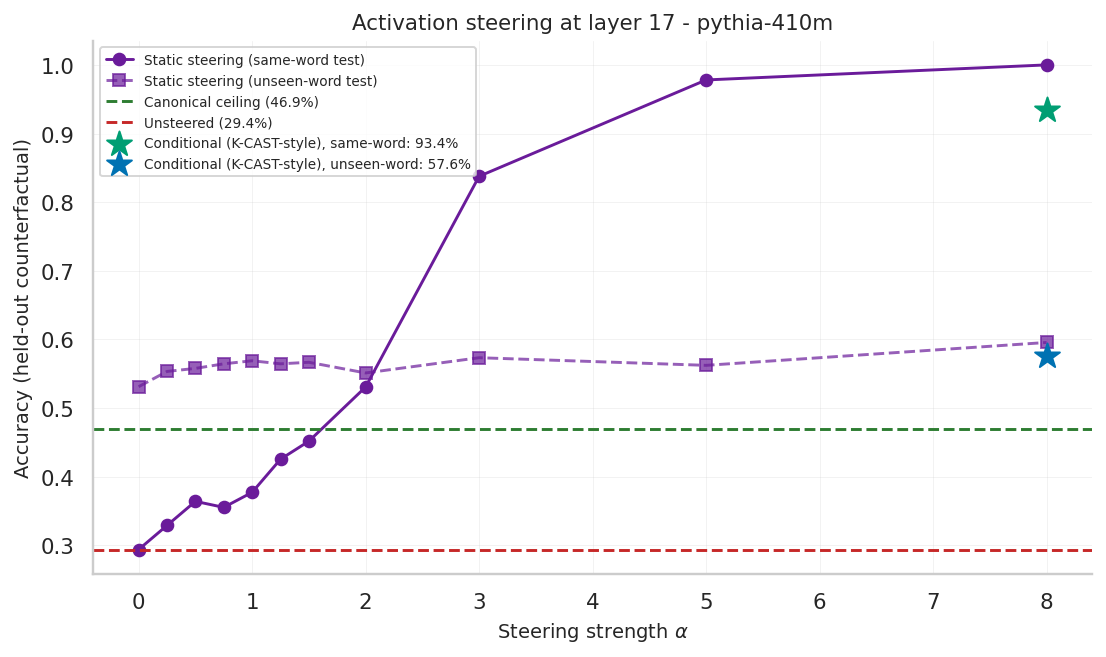

Best static α=8.0: 29.4% -> 100.0% (ceiling 46.9%)

Phase 4 -- llama-3.2-1b (meta-llama/Llama-3.2-1B)
159/228 fit-split instances mispredicted -- fitting v_drift on these.
||v_drift|| = 0.282 (fit at layer 11 on 159 error pairs)
Conditional steering (gate fires on 67% of same-word test, 100% of unseen-word test) at alpha=8.0: same-word 61.0% (static) -> 57.5% (conditional); unseen-word 61.1% (static) -> 61.1% (conditional).


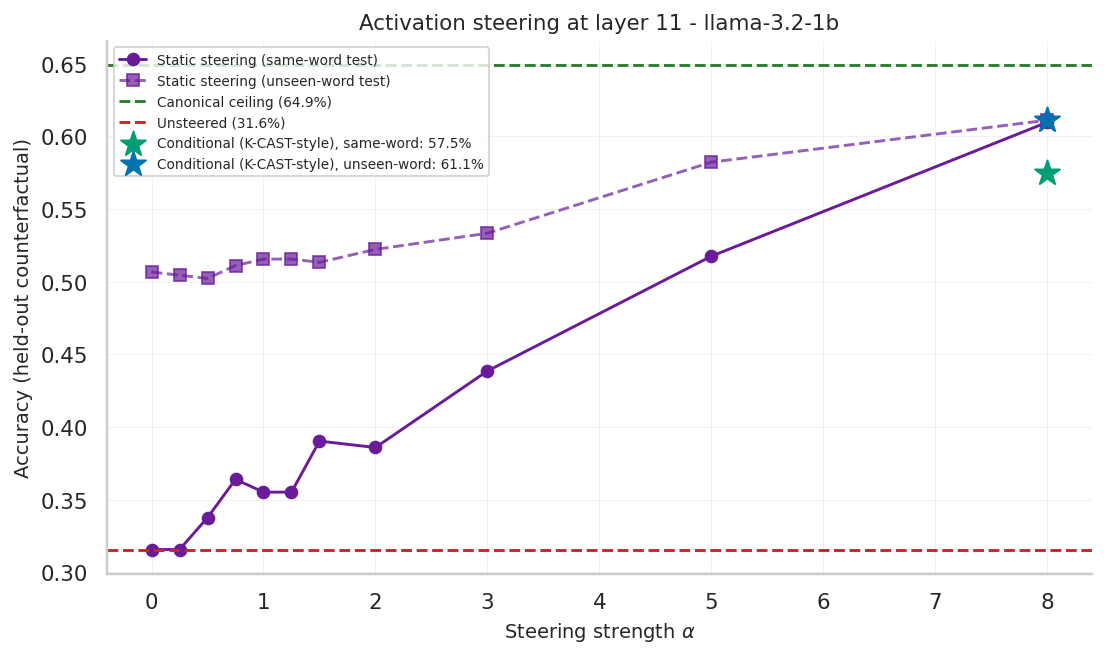

Best static α=8.0: 31.6% -> 61.0% (ceiling 64.9%)

Phase 4 -- llama-3.2-1b-instruct (meta-llama/Llama-3.2-1B-Instruct)
142/228 fit-split instances mispredicted -- fitting v_drift on these.
||v_drift|| = 1.654 (fit at layer 14 on 142 error pairs)
FLAG: static steering gain is only +0.0% across the whole ALPHAS sweep for llama-3.2-1b-instruct -- this is the literature-predicted signature (Valentino et al. 2025/2026) of a model needing conditional rather than static steering, not evidence that steering doesn't work in principle for this model. Reporting the conditional-gate result below rather than concluding 'steering fails' from the static number alone.
Conditional steering (gate fires on 56% of same-word test, 88% of unseen-word test) at alpha=0.0: same-word 41.7% (static) -> 41.7% (conditional); unseen-word 54.0% (static) -> 54.0% (conditional).


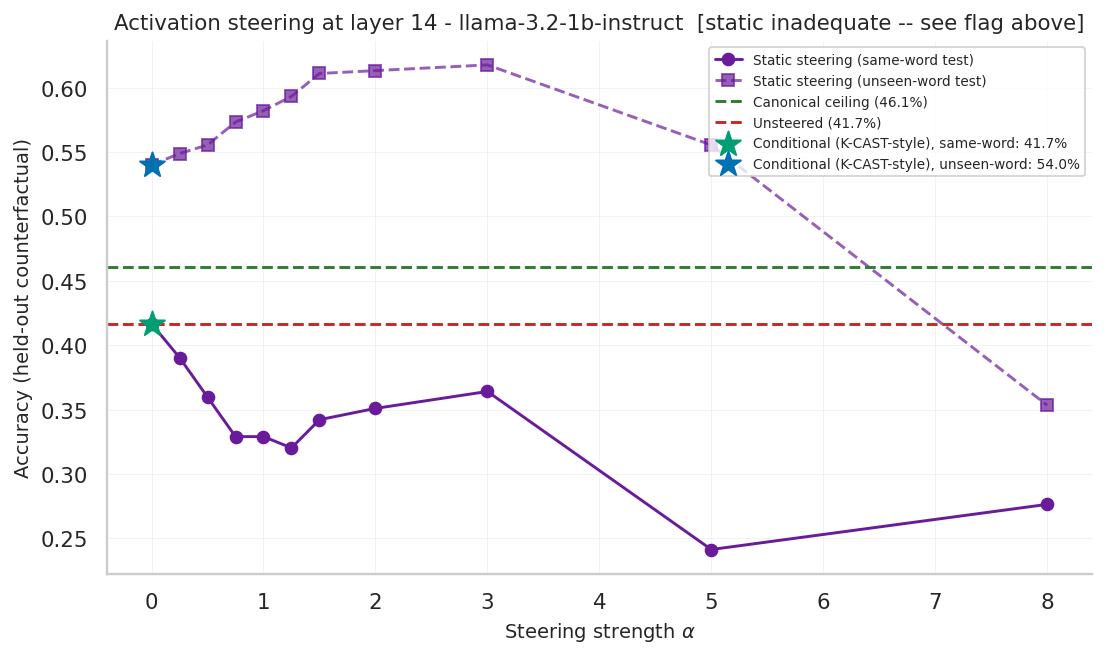

Best static α=0.0: 41.7% -> 41.7% (ceiling 46.1%)

Phase 4 -- qwen2.5-1.5b-instruct (Qwen/Qwen2.5-1.5B-Instruct)
156/228 fit-split instances mispredicted -- fitting v_drift on these.
||v_drift|| = 12.822 (fit at layer 22 on 156 error pairs)
Conditional steering (gate fires on 77% of same-word test, 89% of unseen-word test) at alpha=5.0: same-word 100.0% (static) -> 97.4% (conditional); unseen-word 40.0% (static) -> 46.2% (conditional).


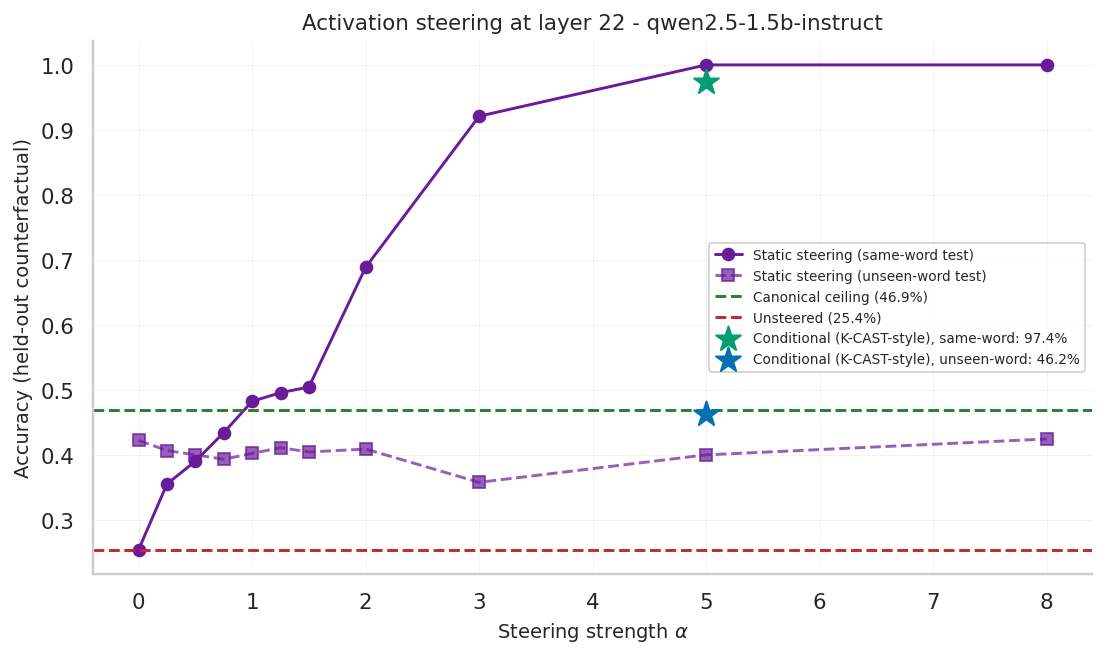

Best static α=5.0: 25.4% -> 100.0% (ceiling 46.9%)

Phase 4 -- qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

141/228 fit-split instances mispredicted -- fitting v_drift on these.
||v_drift|| = 15.535 (fit at layer 28 on 141 error pairs)
Conditional steering (gate fires on 58% of same-word test, 100% of unseen-word test) at alpha=5.0: same-word 67.5% (static) -> 80.3% (conditional); unseen-word 60.7% (static) -> 60.7% (conditional).


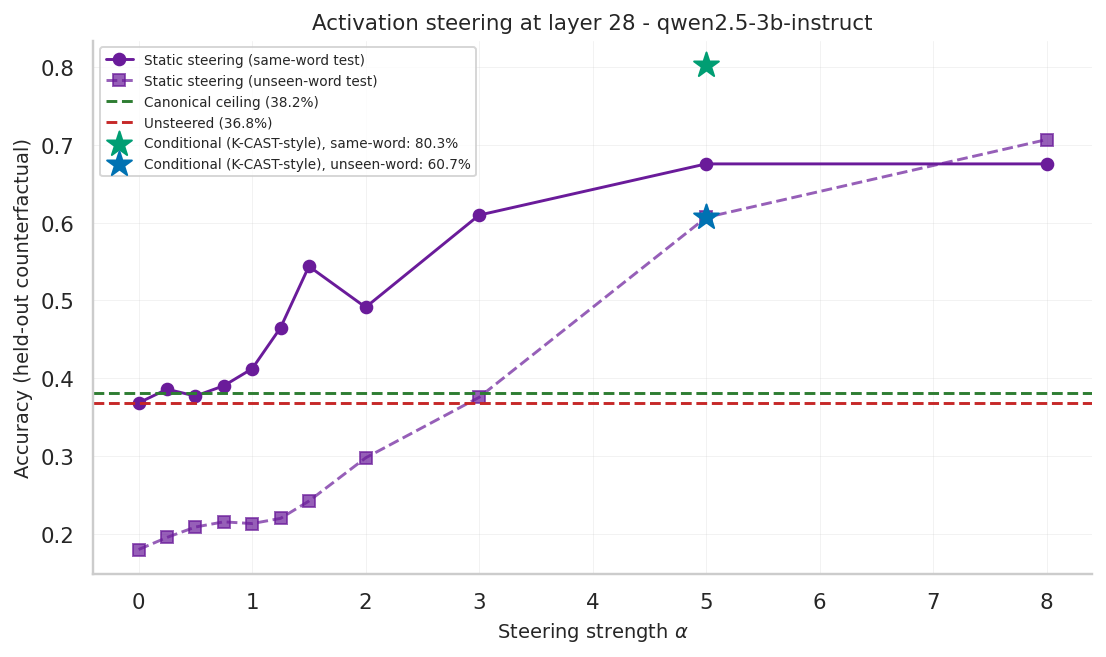

Best static α=5.0: 36.8% -> 67.5% (ceiling 38.2%)

Phase 4 -- gemma-2-2b-it (google/gemma-2-2b-it)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

170/228 fit-split instances mispredicted -- fitting v_drift on these.
||v_drift|| = 40.875 (fit at layer 18 on 170 error pairs)
Conditional steering (gate fires on 74% of same-word test, 93% of unseen-word test) at alpha=8.0: same-word 100.0% (static) -> 100.0% (conditional); unseen-word 23.8% (static) -> 23.8% (conditional).


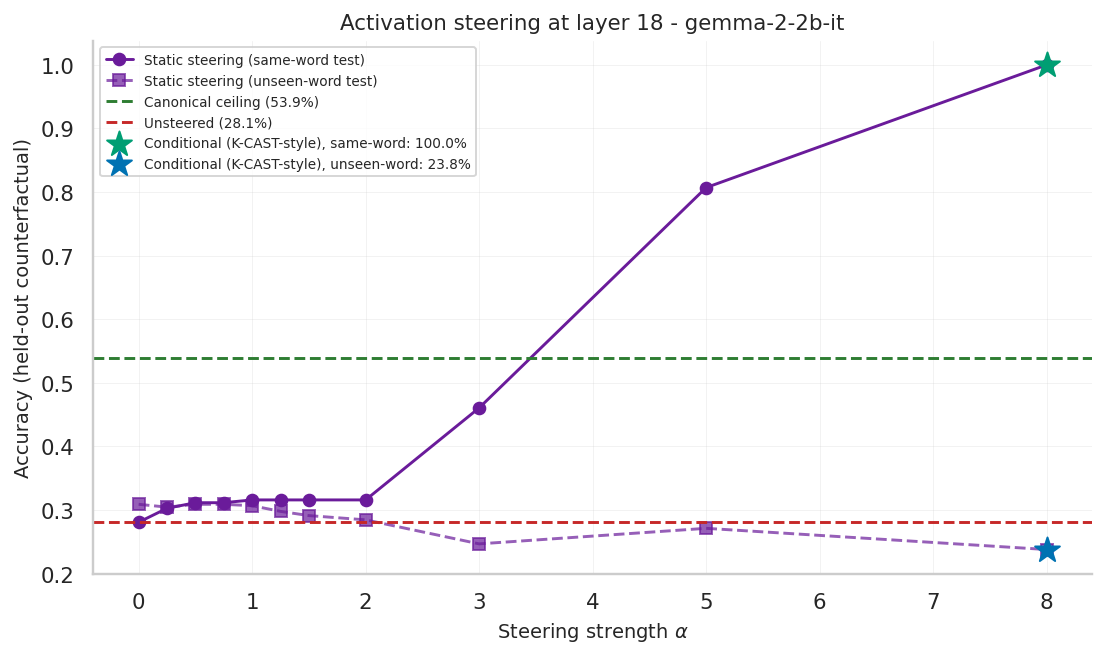

Best static α=8.0: 28.1% -> 100.0% (ceiling 53.9%)


In [35]:
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 8.0]
# Threshold below which a static sweep's best gain over unsteered counts as
# "didn't really work" -- i.e. the literature-predicted signature (Valentino
# et al. 2025/2026) that this model needs the conditional gate instead.
STATIC_ADEQUACY_GAIN = 0.05

for model_key in ACTIVE_MODELS:
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    print(f"\n{'='*70}\nPhase 4 -- {model_key} ({hf_id})\n{'='*70}")
    wrapper = RealModelWrapper(hf_id)
    critical_layer = RESULTS[model_key]["critical_layer"]

    # Fit split: word-disjoint from the "unseen-word" test set below, drawn
    # from FIT_PAIR_IDS (4.5) rather than an arbitrary half of PRIMARY_CATEGORY,
    # so v_drift and the gate are fit only on words the unseen-word test set
    # never uses.
    fit_pool = FIT_PAIR_IDS[PRIMARY_CATEGORY]
    fit_ids = subsample_pair_ids(fit_pool, min(STEER_EVAL_N, len(fit_pool)), seed=SEED + 2)
    rng = random.Random(SEED + 3)
    perm = list(range(len(fit_ids))); rng.shuffle(perm)
    fit_only_ids = [fit_ids[i] for i in perm[: len(perm) // 2]]
    test_ids = [fit_ids[i] for i in perm[len(perm) // 2 :]]           # same-word (fit-pool) test
    heldout_pool = HELDOUT_PAIR_IDS[PRIMARY_CATEGORY]
    heldout_test_ids = subsample_pair_ids(heldout_pool, min(STEER_EVAL_N // 2, len(heldout_pool)), seed=SEED + 4)

    fit_canon = [id_to_instances[i]["canon"] for i in fit_only_ids]
    fit_counter = [id_to_instances[i]["counter"] for i in fit_only_ids]
    test_canon = [id_to_instances[i]["canon"] for i in test_ids]
    test_counter = [id_to_instances[i]["counter"] for i in test_ids]
    unseen_canon = [id_to_instances[i]["canon"] for i in heldout_test_ids]
    unseen_counter = [id_to_instances[i]["counter"] for i in heldout_test_ids]

    wrong_mask = ~predict_correct_mask(wrapper, fit_counter)
    fit_canon_wrong = [c for c, w in zip(fit_canon, wrong_mask) if w]
    fit_counter_wrong = [c for c, w in zip(fit_counter, wrong_mask) if w]
    print(f"{len(fit_counter_wrong)}/{len(fit_counter)} fit-split instances mispredicted -- fitting v_drift on these.")

    if len(fit_counter_wrong) < 5:
        print("Too few mispredicted instances to fit a meaningful drift vector for this model -- skipping steering.")
        RESULTS[model_key]["steering_skipped"] = True
        wrapper.unload()
        continue

    v_drift = compute_drift_vector(wrapper, fit_canon_wrong, fit_counter_wrong, critical_layer)
    print(f"||v_drift|| = {v_drift.norm().item():.3f} (fit at layer {critical_layer} on {len(fit_canon_wrong)} error pairs)")

    # Static sweep, same-word test set (as before).
    steer_acc = [eval_accuracy_with_steering(wrapper, test_counter, critical_layer, a, v_drift) for a in ALPHAS]
    canon_ceiling = np.mean(predict_correct_mask(wrapper, test_canon))

    # NEW: same static sweep evaluated on entirely unseen words (4.5) -- does
    # the steering vector generalize past the specific words it was fit on,
    # or has it just learned to suppress a handful of token directions?
    steer_acc_unseen = [eval_accuracy_with_steering(wrapper, unseen_counter, critical_layer, a, v_drift) for a in ALPHAS]
    canon_ceiling_unseen = np.mean(predict_correct_mask(wrapper, unseen_canon))

    best_idx = int(np.argmax(steer_acc))
    static_gain = steer_acc[best_idx] - steer_acc[0]
    static_adequate = static_gain >= STATIC_ADEQUACY_GAIN
    if not static_adequate:
        print(f"FLAG: static steering gain is only {static_gain:+.1%} across the whole ALPHAS sweep for "
              f"{model_key} -- this is the literature-predicted signature (Valentino et al. 2025/2026) of a "
              f"model needing conditional rather than static steering, not evidence that steering doesn't "
              f"work in principle for this model. Reporting the conditional-gate result below rather than "
              f"concluding 'steering fails' from the static number alone.")

    # NEW: conditional (K-CAST-style) gate, trained on the same fit split.
    resid_fit, _ = extract_residuals_and_predictions(wrapper, fit_counter)
    gate = fit_steering_gate(resid_fit[:, critical_layer + 1, :], wrong_mask)
    cond_acc_same, cond_acc_unseen = None, None
    if gate is not None:
        cond_acc_same, frac_steered_same = eval_accuracy_with_conditional_steering(
            wrapper, test_counter, critical_layer, ALPHAS[best_idx], v_drift, gate)
        cond_acc_unseen, frac_steered_unseen = eval_accuracy_with_conditional_steering(
            wrapper, unseen_counter, critical_layer, ALPHAS[best_idx], v_drift, gate)
        print(f"Conditional steering (gate fires on {frac_steered_same:.0%} of same-word test, "
              f"{frac_steered_unseen:.0%} of unseen-word test) at alpha={ALPHAS[best_idx]}: "
              f"same-word {steer_acc[best_idx]:.1%} (static) -> {cond_acc_same:.1%} (conditional); "
              f"unseen-word {steer_acc_unseen[best_idx]:.1%} (static) -> {cond_acc_unseen:.1%} (conditional).")
    else:
        print("Too few examples on either side of the shortcut-active/inactive split to fit a gate -- "
              "reporting static results only for this model.")

    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.plot(ALPHAS, steer_acc, marker="o", color="#6A1B9A", label="Static steering (same-word test)")
    ax.plot(ALPHAS, steer_acc_unseen, marker="s", color="#6A1B9A", linestyle="--",
            label="Static steering (unseen-word test)", alpha=0.7)
    ax.axhline(canon_ceiling, color=CANON_COLOR, linestyle="--", label=f"Canonical ceiling ({canon_ceiling:.1%})")
    ax.axhline(steer_acc[0], color=COUNTER_COLOR, linestyle="--", label=f"Unsteered ({steer_acc[0]:.1%})")
    if cond_acc_same is not None:
        ax.scatter([ALPHAS[best_idx]], [cond_acc_same], marker="*", s=180, color="#009E73", zorder=5,
                   label=f"Conditional (K-CAST-style), same-word: {cond_acc_same:.1%}")
        ax.scatter([ALPHAS[best_idx]], [cond_acc_unseen], marker="*", s=180, color="#0072B2", zorder=5,
                   label=f"Conditional (K-CAST-style), unseen-word: {cond_acc_unseen:.1%}")
    ax.set_xlabel(r"Steering strength $\alpha$"); ax.set_ylabel("Accuracy (held-out counterfactual)")
    title_flag = "" if static_adequate else "  [static inadequate -- see flag above]"
    ax.set_title(f"Activation steering at layer {critical_layer} - {model_key}{title_flag}")
    ax.legend(fontsize=7)
    plt.tight_layout()
    savefig_std(fig, f"phase4_steering_{model_key}")
    plt.show()

    print(f"Best static α={ALPHAS[best_idx]}: {steer_acc[0]:.1%} -> {steer_acc[best_idx]:.1%} (ceiling {canon_ceiling:.1%})")

    RESULTS[model_key]["steer_acc"] = steer_acc
    RESULTS[model_key]["steer_acc_unseen_words"] = steer_acc_unseen
    RESULTS[model_key]["canon_ceiling"] = canon_ceiling
    RESULTS[model_key]["canon_ceiling_unseen_words"] = canon_ceiling_unseen
    RESULTS[model_key]["static_steering_adequate"] = static_adequate
    RESULTS[model_key]["conditional_steer_acc_same_word"] = cond_acc_same
    RESULTS[model_key]["conditional_steer_acc_unseen_word"] = cond_acc_unseen
    RESULTS[model_key]["steering_skipped"] = False

    wrapper.unload()


<a id="phase5"></a>
## 9. Part H - Tier 2 Continued: Depth-Indexed Representational Geometry

*Adapted from Zhou, Wang, Yin, Zhou & Zhang (2026), "The Geometry of Reasoning: Flowing
Logics in Representation Space," ICLR 2026*

### 9.1 Why depth, not text segments (redesigned this iteration)

Zhou et al.'s trajectory axis is **genuine multi-step chain-of-thought generation**: each
point in their flow is a real inferential move the model produced. An earlier version of
this notebook forced CSS-Bench's single forced-choice prompt into five arbitrary template
clauses and called *that* a trajectory, a weaker analogy (prompt position, not reasoning
step) that also doesn't generalize to a different game template without hand-redefining
the segmentation.

**The redesign**: index the trajectory by **network depth** instead. At the fixed final
("MY CHOICE: [") token position, the residual stream across layers
$Y=(h_0,\ldots,h_L)$ (Definition 0.8) is a trajectory every decoder-only transformer has,
on any single-decision task, with zero dataset-specific segmentation required — directly
addressing the concern that the original segment-based design would not "expand to more
datasets" with the same rigor. It also has a second, non-cosmetic advantage: **it shares
its x-axis with Phase 1's logit lens and Phase 2's activation patching**, so we can ask
directly, on the same normalized-depth coordinate, whether curvature spikes at the same
depth patching already identified as causally critical — a much tighter internal
consistency check than a second, unrelated axis could support.

We keep the original text-segment trajectory only as a **secondary, illustrative**
single-instance PCA visualization (9.3) [useful for intuition about what a trajectory
through a specific prompt looks like] but the primary quantitative claims in this
section (velocity, curvature, and the matched-vs-shuffled invariance test) are now
depth-indexed throughout.


In [36]:
def menger_curvature(y_prev: np.ndarray, y_curr: np.ndarray, y_next: np.ndarray) -> float:
    '''Zhou et al. (2026), Proposition D.8. Validated offline against closed-form
    cases: collinear points -> 0; unit right-angle turn -> circumradius sqrt(2)/2 exactly.'''
    u, v = y_curr - y_prev, y_next - y_curr
    denom = np.linalg.norm(y_next - y_prev)
    if denom < 1e-9:
        return 0.0
    cos_sim = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12)
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    return float(2 * np.sqrt(max(0.0, 1 - cos_sim**2)) / denom)

def compute_velocity_and_curvature(flow: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    '''flow: (n_layers+1, D) depth-indexed trajectory at the fixed final position.
    Returns (velocity_vectors (n_layers,D), velocity_norms (n_layers,), curvatures (n_layers-1,)).'''
    velocities = flow[1:] - flow[:-1]
    vel_norms = np.linalg.norm(velocities, axis=1)
    curvatures = np.array([menger_curvature(flow[i - 1], flow[i], flow[i + 1]) for i in range(1, len(flow) - 1)])
    return velocities, vel_norms, curvatures

GEOM_EVAL_N = 400   # cheap phase (1 forward pass/instance, same extraction as Part F.3)



Phase 5 (depth-indexed) -- pythia-410m (EleutherAI/pythia-410m)


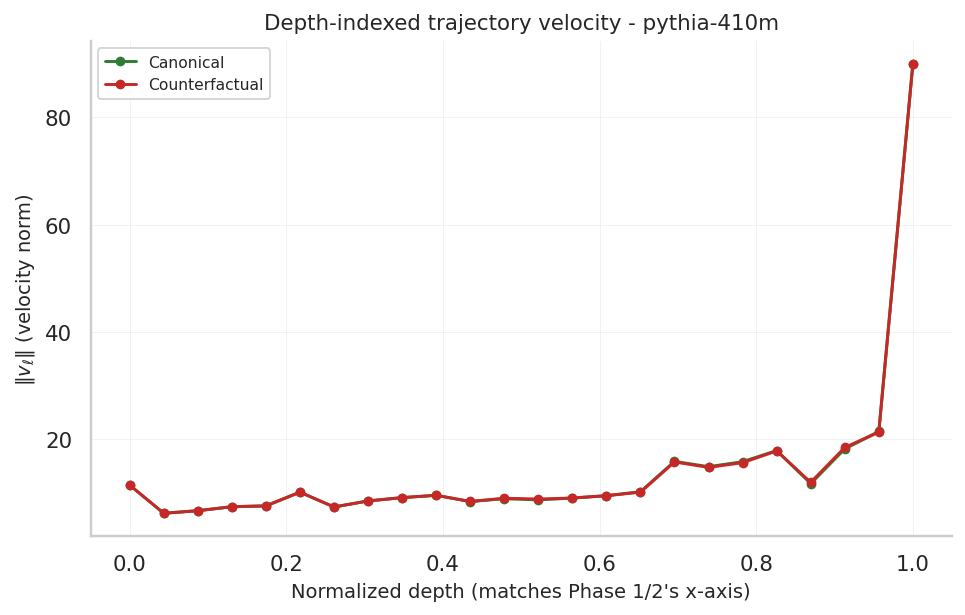

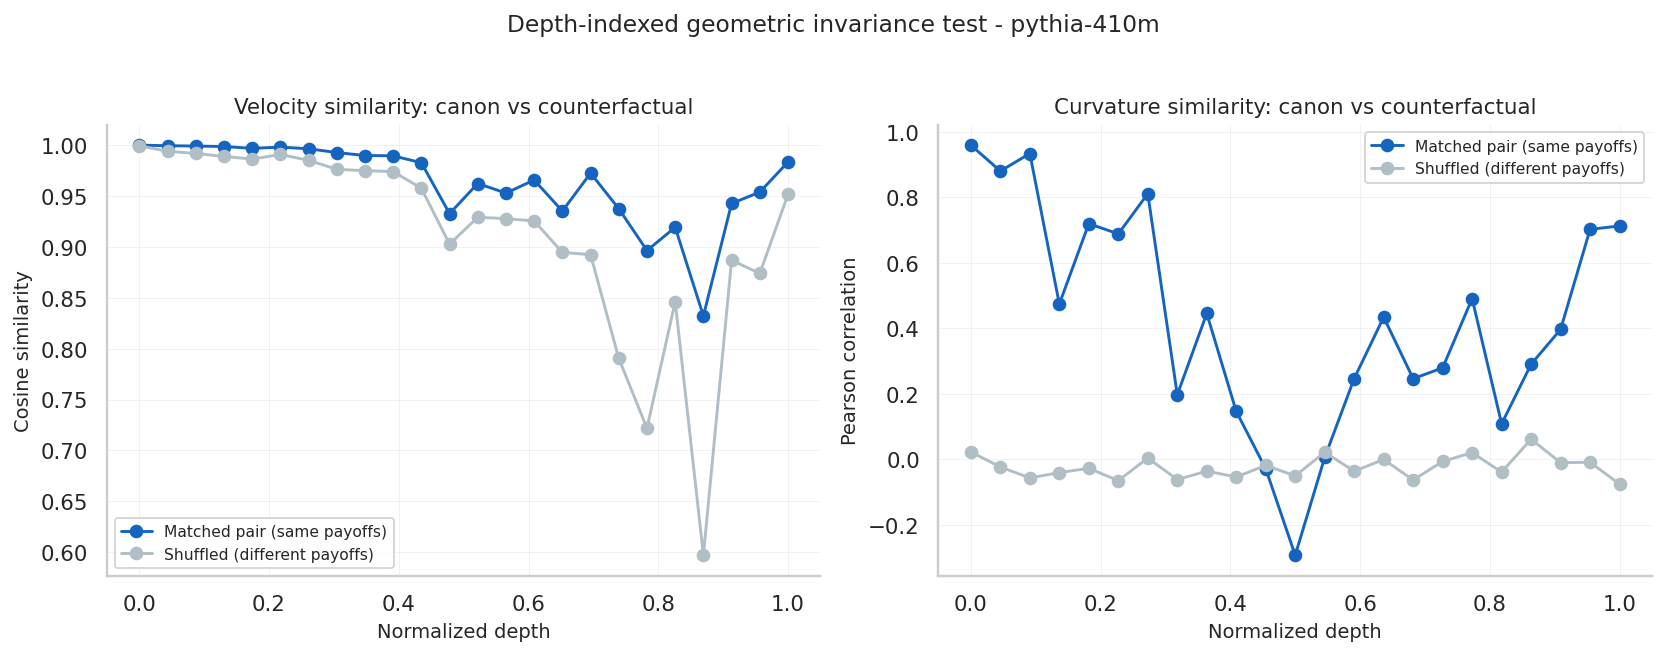

Smallest matched-vs-shuffled velocity gap at normalized depth 0.00 (gap=+0.001).
Compare to Part E's causally-critical depth: 0.74. Close agreement between these two independently-derived depths (causal patching vs. geometric divergence) is the strongest form of convergent evidence this notebook can produce.

Phase 5 (depth-indexed) -- llama-3.2-1b (meta-llama/Llama-3.2-1B)


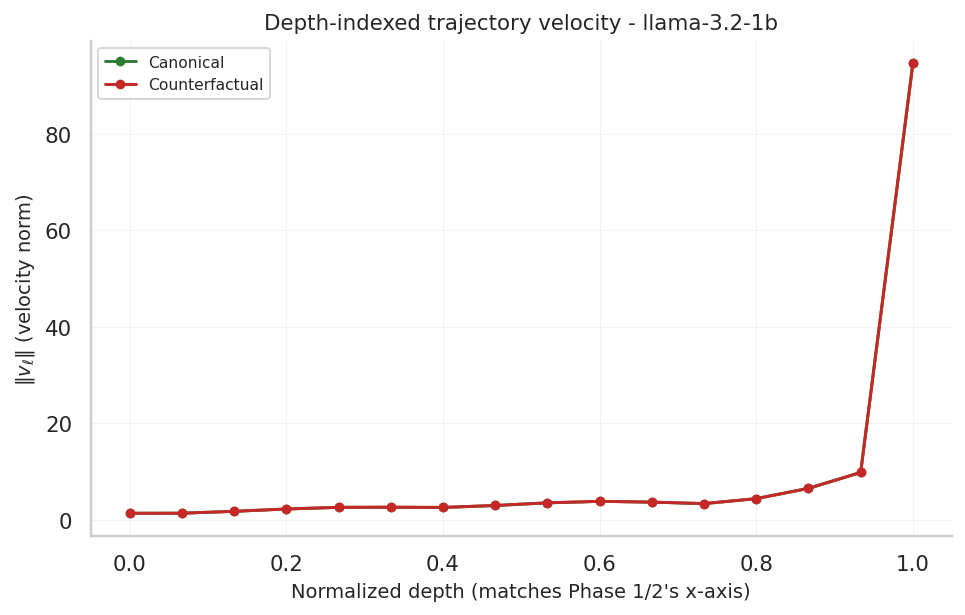

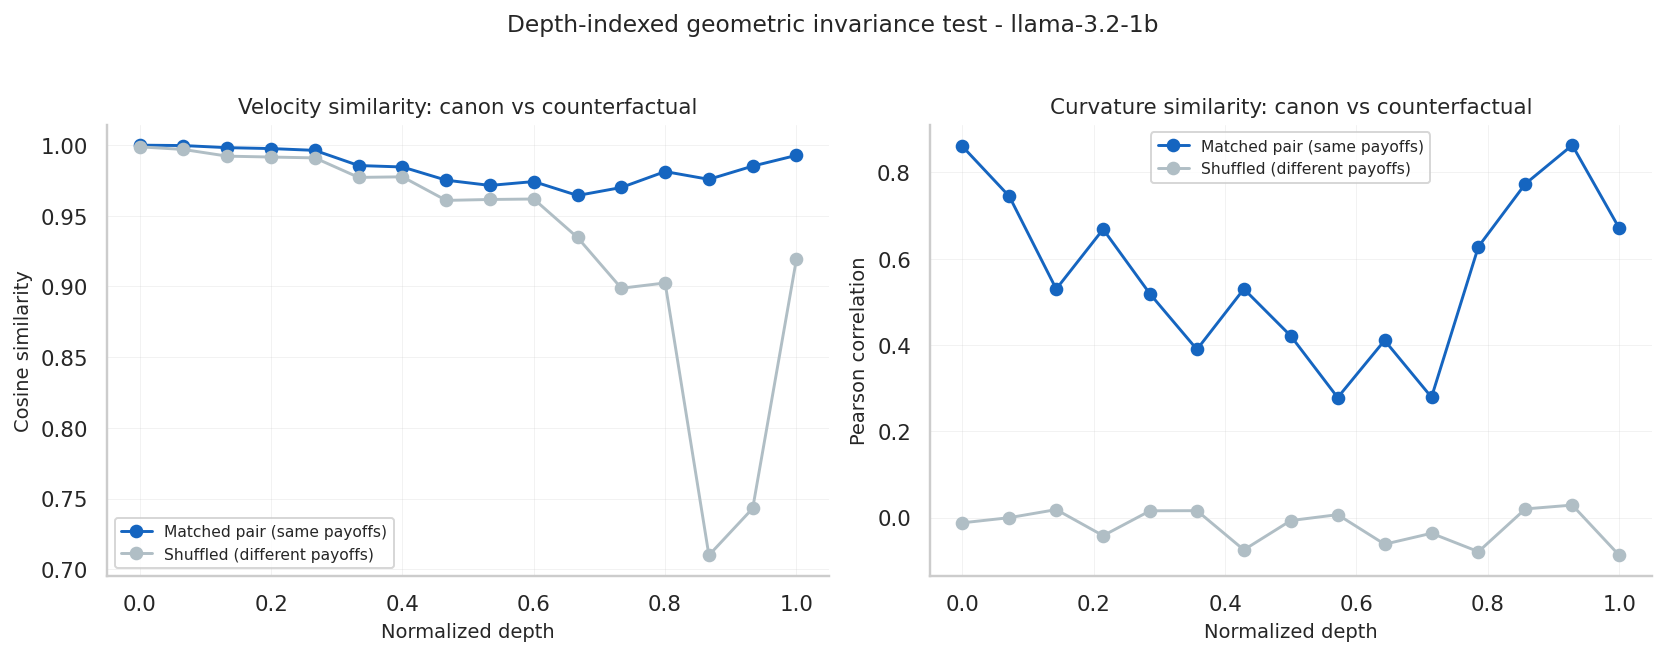

Smallest matched-vs-shuffled velocity gap at normalized depth 0.00 (gap=+0.001).
Compare to Part E's causally-critical depth: 0.73. Close agreement between these two independently-derived depths (causal patching vs. geometric divergence) is the strongest form of convergent evidence this notebook can produce.

Phase 5 (depth-indexed) -- llama-3.2-1b-instruct (meta-llama/Llama-3.2-1B-Instruct)


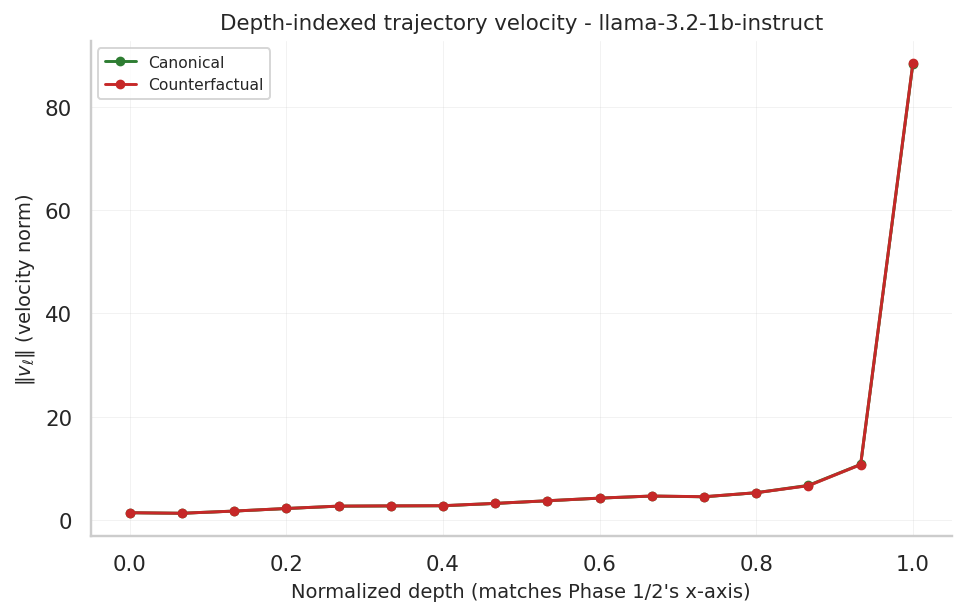

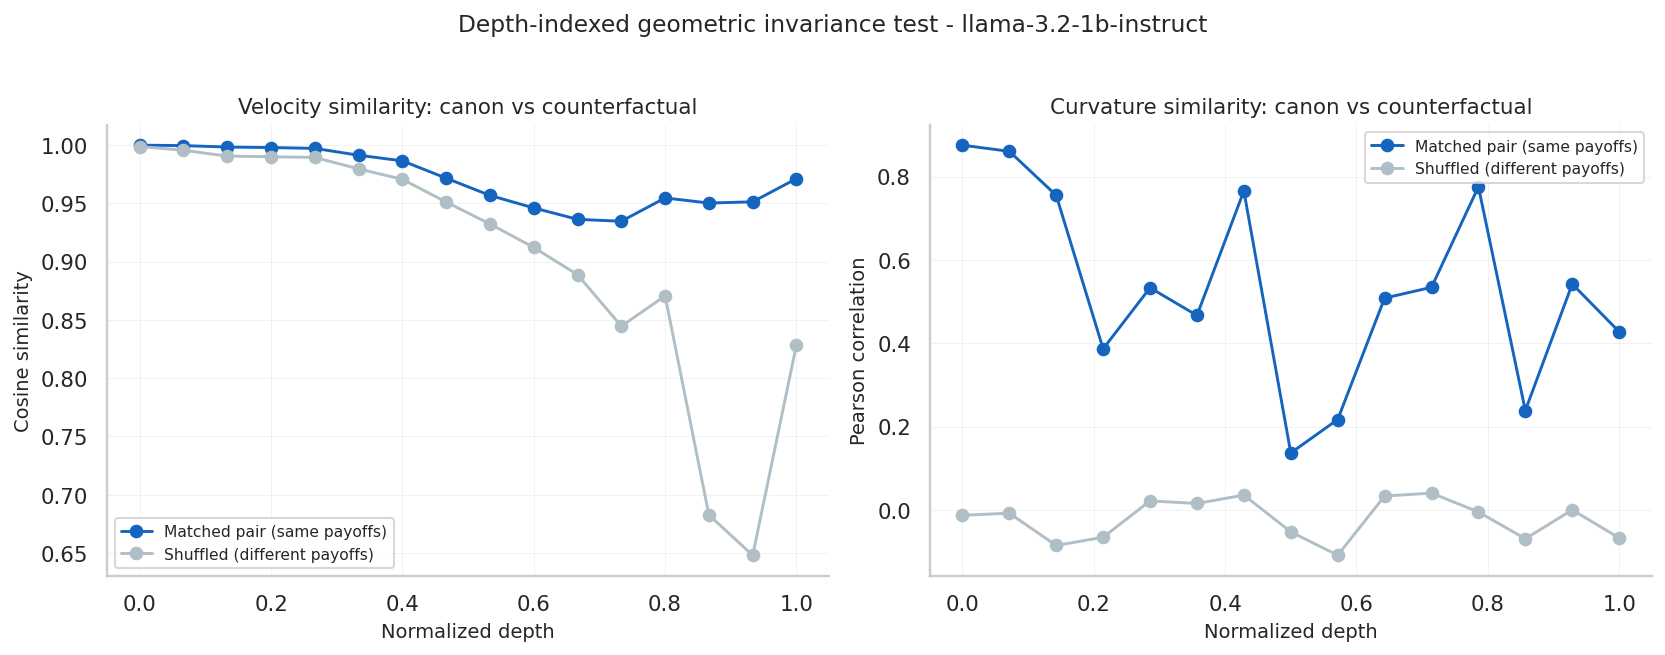

Smallest matched-vs-shuffled velocity gap at normalized depth 0.00 (gap=+0.001).
Compare to Part E's causally-critical depth: 0.93. Close agreement between these two independently-derived depths (causal patching vs. geometric divergence) is the strongest form of convergent evidence this notebook can produce.

Phase 5 (depth-indexed) -- qwen2.5-1.5b-instruct (Qwen/Qwen2.5-1.5B-Instruct)


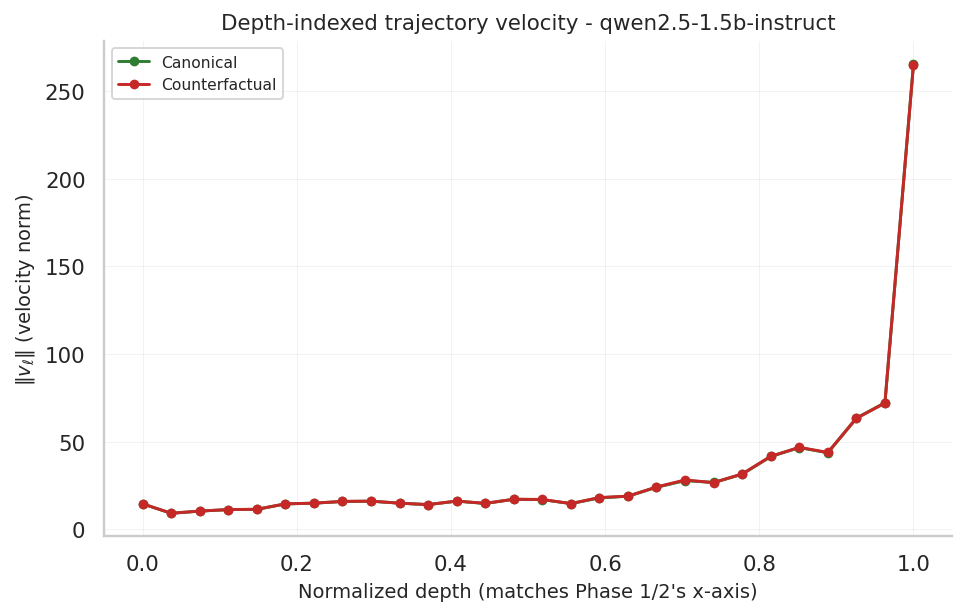

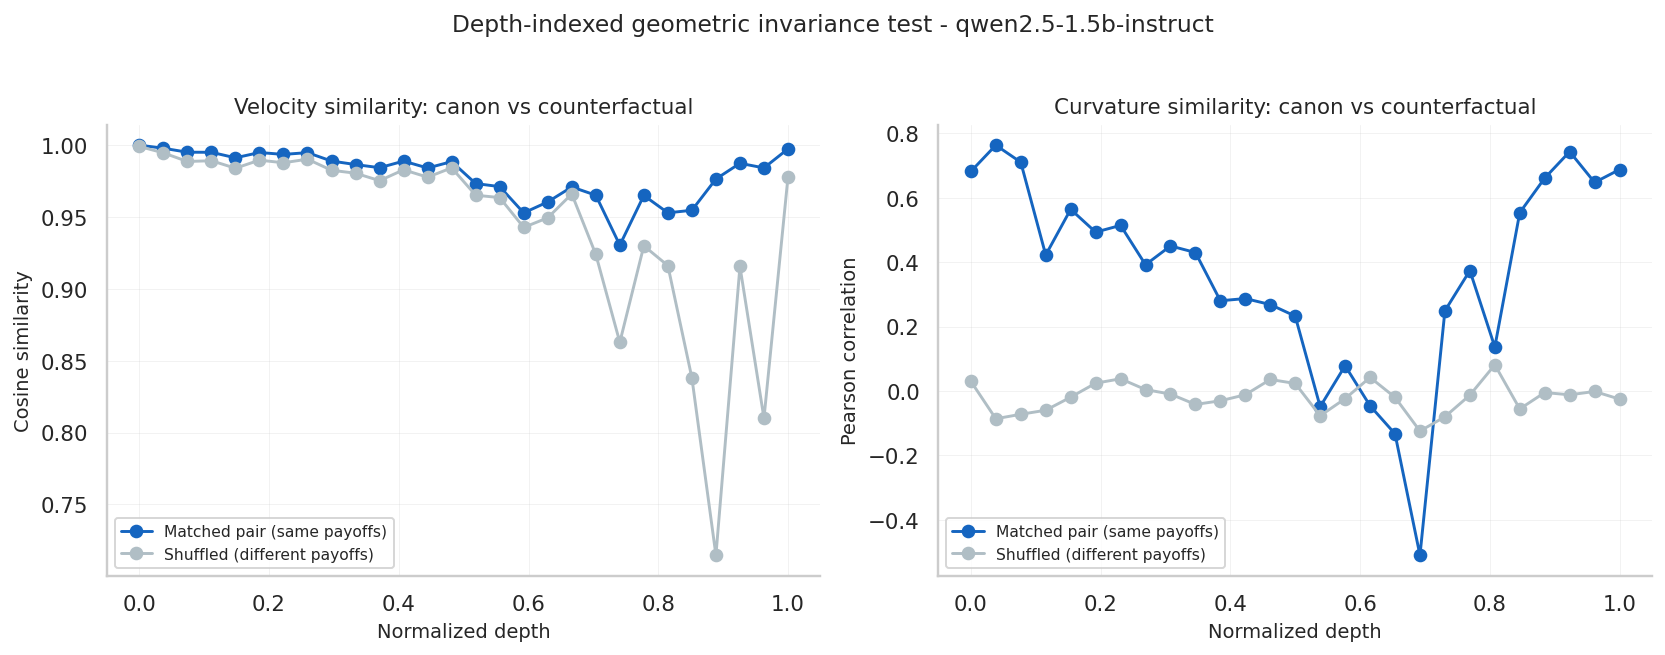

Smallest matched-vs-shuffled velocity gap at normalized depth 0.00 (gap=+0.001).
Compare to Part E's causally-critical depth: 0.81. Close agreement between these two independently-derived depths (causal patching vs. geometric divergence) is the strongest form of convergent evidence this notebook can produce.

Phase 5 (depth-indexed) -- qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

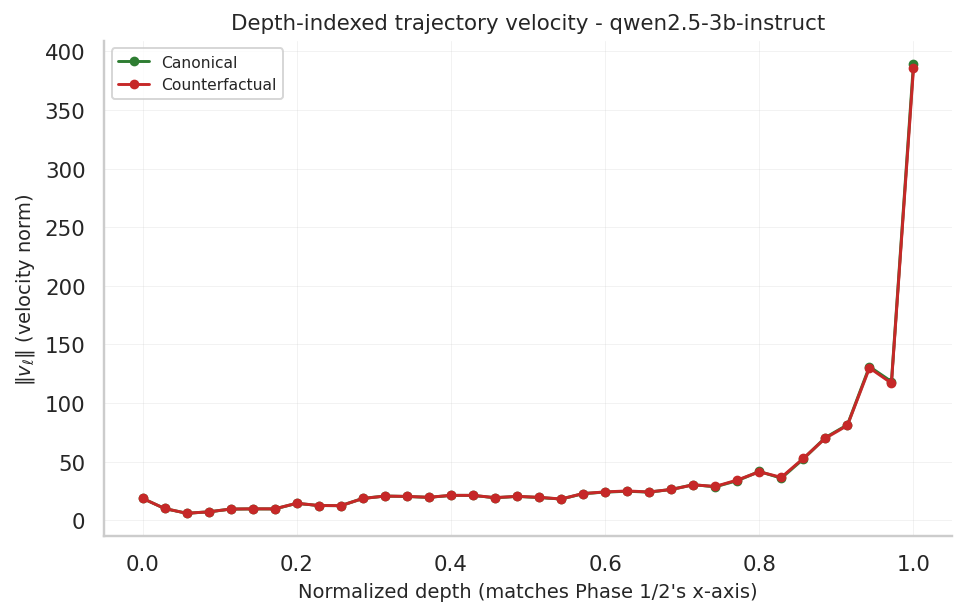

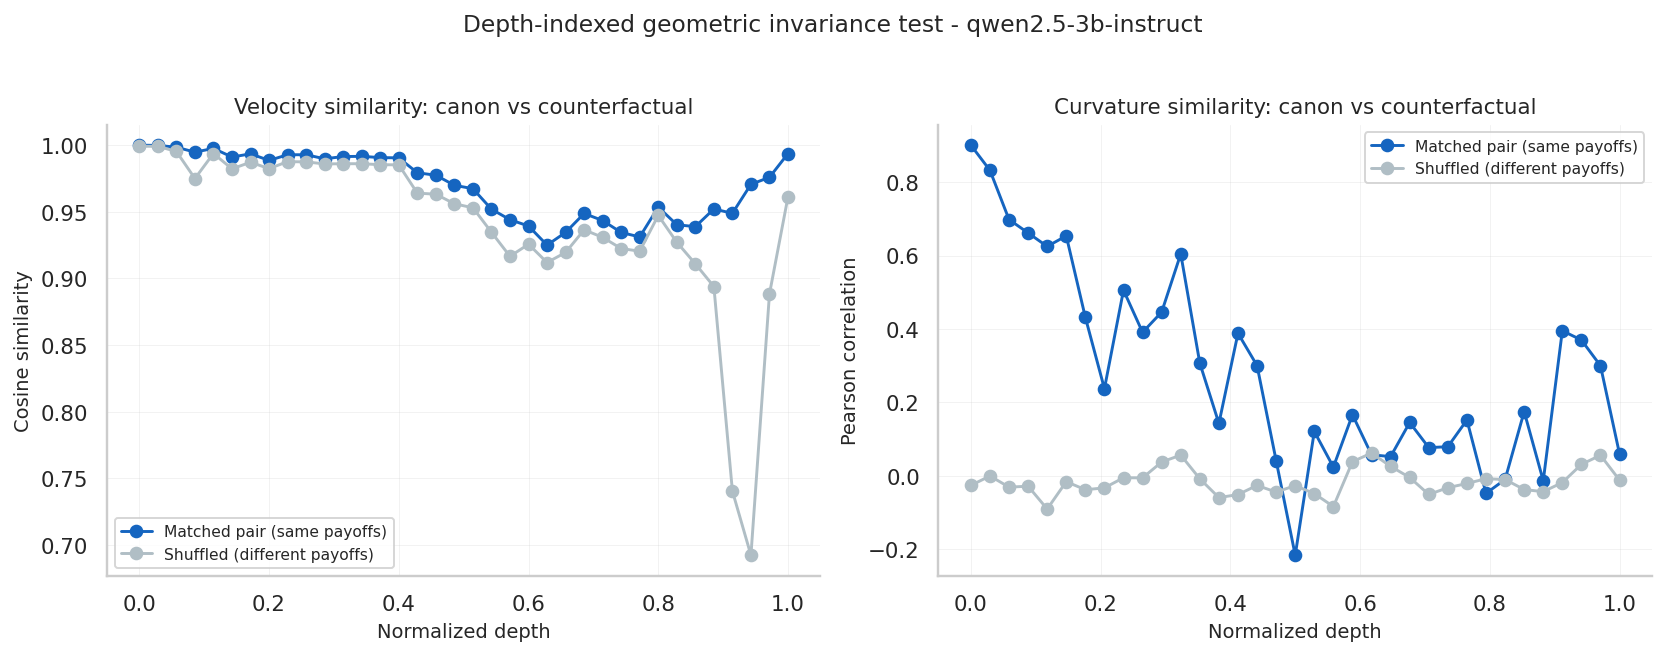

Smallest matched-vs-shuffled velocity gap at normalized depth 0.03 (gap=+0.001).
Compare to Part E's causally-critical depth: 0.80. Close agreement between these two independently-derived depths (causal patching vs. geometric divergence) is the strongest form of convergent evidence this notebook can produce.

Phase 5 (depth-indexed) -- gemma-2-2b-it (google/gemma-2-2b-it)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

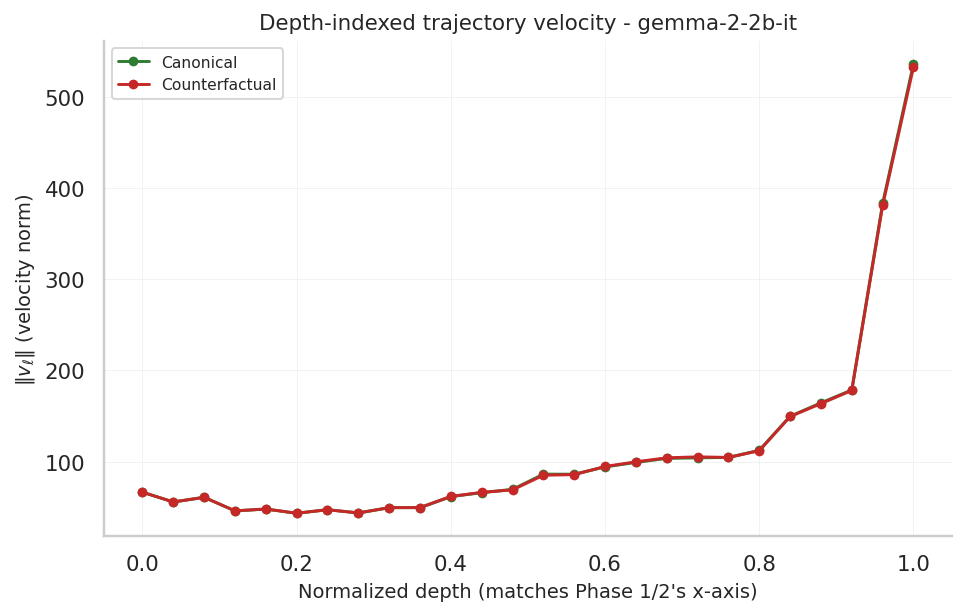

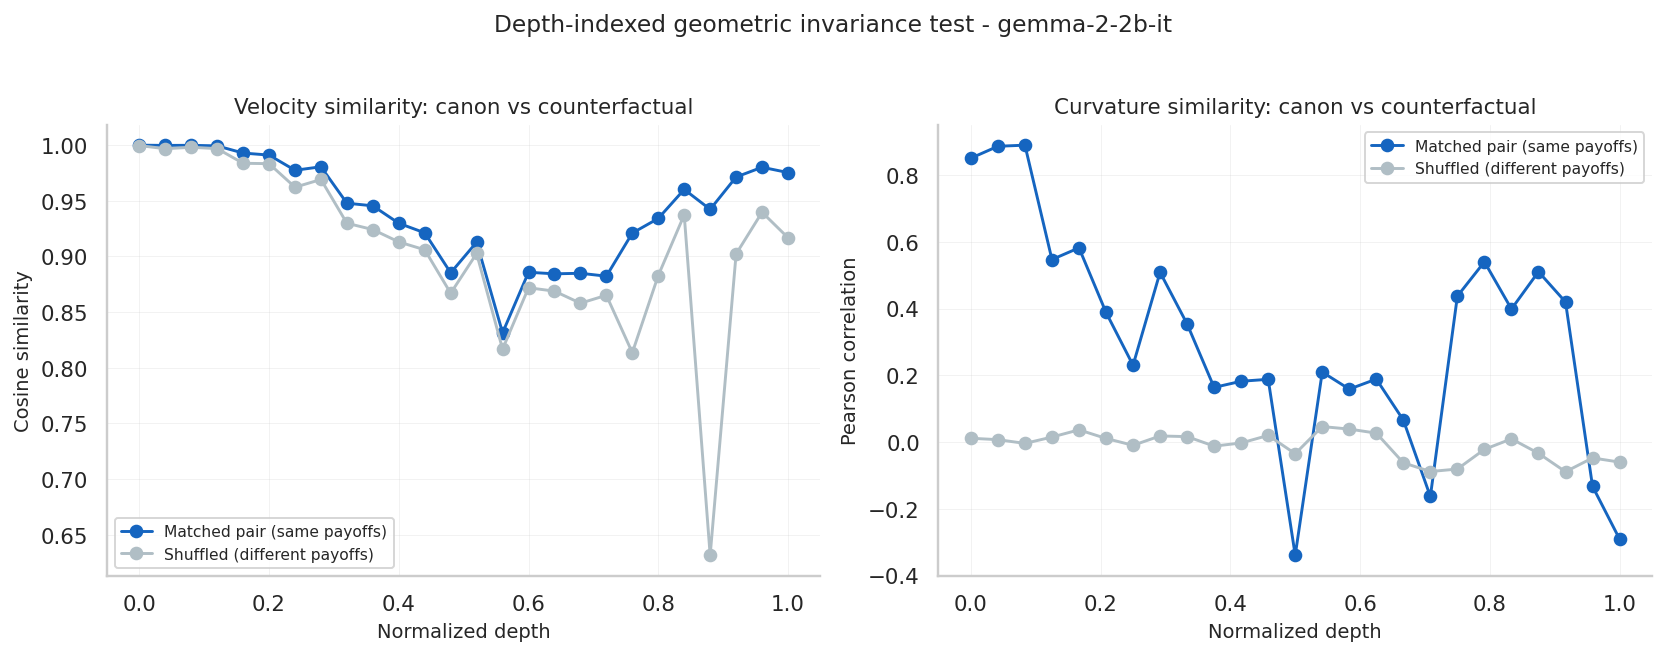

Smallest matched-vs-shuffled velocity gap at normalized depth 0.00 (gap=+0.000).
Compare to Part E's causally-critical depth: 0.72. Close agreement between these two independently-derived depths (causal patching vs. geometric divergence) is the strongest form of convergent evidence this notebook can produce.


In [37]:
for model_key in ACTIVE_MODELS:
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    print(f"\n{'='*70}\nPhase 5 (depth-indexed) -- {model_key} ({hf_id})\n{'='*70}")
    wrapper = RealModelWrapper(hf_id)

    geom_pair_ids = subsample_pair_ids(category_pair_ids(PRIMARY_CATEGORY), GEOM_EVAL_N, seed=SEED + 4)
    geom_canon = [id_to_instances[i]["canon"] for i in geom_pair_ids]
    geom_counter = [id_to_instances[i]["counter"] for i in geom_pair_ids]

    # Reuses Part F.3's extraction (same final-position, all-layers residual) --
    # depth-indexed trajectory needs nothing beyond what logit lens already computes.
    flow_canon, _ = extract_residuals_and_predictions(wrapper, geom_canon)      # (N, L+1, D)
    flow_counter, _ = extract_residuals_and_predictions(wrapper, geom_counter)
    N, n_pts = flow_canon.shape[0], flow_canon.shape[1]
    n_vel, n_curv = n_pts - 1, n_pts - 2

    vel_norm_canon, vel_norm_counter = np.zeros((N, n_vel)), np.zeros((N, n_vel))
    curv_canon, curv_counter = np.zeros((N, n_curv)), np.zeros((N, n_curv))
    vel_vec_canon = np.zeros((N, n_vel, wrapper.d_model), dtype=np.float32)
    vel_vec_counter = np.zeros((N, n_vel, wrapper.d_model), dtype=np.float32)
    for i in range(N):
        v_c, vn_c, c_c = compute_velocity_and_curvature(flow_canon[i])
        v_k, vn_k, c_k = compute_velocity_and_curvature(flow_counter[i])
        vel_norm_canon[i], vel_norm_counter[i] = vn_c, vn_k
        curv_canon[i], curv_counter[i] = c_c, c_k
        vel_vec_canon[i], vel_vec_counter[i] = v_c, v_k

    depth_vel = np.linspace(0, 1, n_vel)
    depth_curv = np.linspace(0, 1, n_curv)

    # --- 9.2a Velocity norm across depth (canon vs counterfactual), same x-axis as Phase 1/2 ---
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for arr, depth_x, color, label in [(vel_norm_canon, depth_vel, "#2E7D32", "Canonical"), (vel_norm_counter, depth_vel, "#C62828", "Counterfactual")]:
        mean, sem = arr.mean(axis=0), arr.std(axis=0) / np.sqrt(len(arr))
        ax.plot(depth_x, mean, marker="o", color=color, label=label, markersize=4)
        ax.fill_between(depth_x, mean - sem, mean + sem, color=color, alpha=0.2)
    ax.set_xlabel("Normalized depth (matches Phase 1/2's x-axis)")
    ax.set_ylabel(r"$\|v_\ell\|$ (velocity norm)"); ax.set_title(f"Depth-indexed trajectory velocity - {model_key}")
    ax.legend(); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"phase5_velocity_{model_key}.png")); plt.show()

    # --- 9.2b Invariance test: matched (same instance) vs shuffled (different instance) ---
    shuffled_idx = np.roll(np.arange(N), 1)   # simple derangement, no self-pairing
    matched_vel_sim, random_vel_sim = np.zeros(n_vel), np.zeros(n_vel)
    matched_curv_corr, random_curv_corr = np.zeros(n_curv), np.zeros(n_curv)
    for t in range(n_vel):
        a, b = vel_vec_canon[:, t, :], vel_vec_counter[:, t, :]
        cos = (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + 1e-9)
        matched_vel_sim[t] = np.nanmean(cos)
        b_shuf = vel_vec_counter[shuffled_idx, t, :]
        cos_shuf = (a * b_shuf).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b_shuf, axis=1) + 1e-9)
        random_vel_sim[t] = np.nanmean(cos_shuf)
    for t in range(n_curv):
        matched_curv_corr[t] = np.corrcoef(curv_canon[:, t], curv_counter[:, t])[0, 1]
        random_curv_corr[t] = np.corrcoef(curv_canon[:, t], curv_counter[shuffled_idx, t])[0, 1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(depth_vel, matched_vel_sim, marker="o", color="#1565C0", label="Matched pair (same payoffs)")
    axes[0].plot(depth_vel, random_vel_sim, marker="o", color="#B0BEC5", label="Shuffled (different payoffs)")
    axes[0].set_xlabel("Normalized depth"); axes[0].set_ylabel("Cosine similarity")
    axes[0].set_title("Velocity similarity: canon vs counterfactual"); axes[0].legend(fontsize=8)

    axes[1].plot(depth_curv, matched_curv_corr, marker="o", color="#1565C0", label="Matched pair (same payoffs)")
    axes[1].plot(depth_curv, random_curv_corr, marker="o", color="#B0BEC5", label="Shuffled (different payoffs)")
    axes[1].set_xlabel("Normalized depth"); axes[1].set_ylabel("Pearson correlation")
    axes[1].set_title("Curvature similarity: canon vs counterfactual"); axes[1].legend(fontsize=8)
    fig.suptitle(f"Depth-indexed geometric invariance test - {model_key}", y=1.03)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"phase5_invariance_{model_key}.png"), bbox_inches="tight"); plt.show()

    gap = matched_vel_sim - random_vel_sim
    worst_depth_idx = int(np.argmin(gap))
    print(f"Smallest matched-vs-shuffled velocity gap at normalized depth {depth_vel[worst_depth_idx]:.2f} "
          f"(gap={gap[worst_depth_idx]:+.3f}).")
    if "critical_layer" in RESULTS.get(model_key, {}):
        patch_depth = RESULTS[model_key]["critical_layer"] / max(RESULTS[model_key]["n_layers"] - 1, 1)
        print(f"Compare to Part E's causally-critical depth: {patch_depth:.2f}. "
              f"Close agreement between these two independently-derived depths (causal "
              f"patching vs. geometric divergence) is the strongest form of convergent "
              f"evidence this notebook can produce.")

    RESULTS[model_key]["matched_vel_sim"] = matched_vel_sim
    RESULTS[model_key]["random_vel_sim"] = random_vel_sim
    RESULTS[model_key]["matched_curv_corr"] = matched_curv_corr
    RESULTS[model_key]["random_curv_corr"] = random_curv_corr

    wrapper.unload()


### 9.3 Secondary, illustrative view: text-segment trajectories for a handful of instances

Kept only as an intuition aid, *not* the basis for any quantitative claim in this
section, per 9.1's discussion of why a fixed template segmentation is a weaker
trajectory axis than depth. Five natural prompt clauses
(`intro → option_A → option_B → objective → choice_cue`), one point per clause, mean-pooled
over the cumulative prefix at the model's **final layer**, this is the segment-based
design from the earlier iteration, preserved here purely as a paper-style PCA figure.


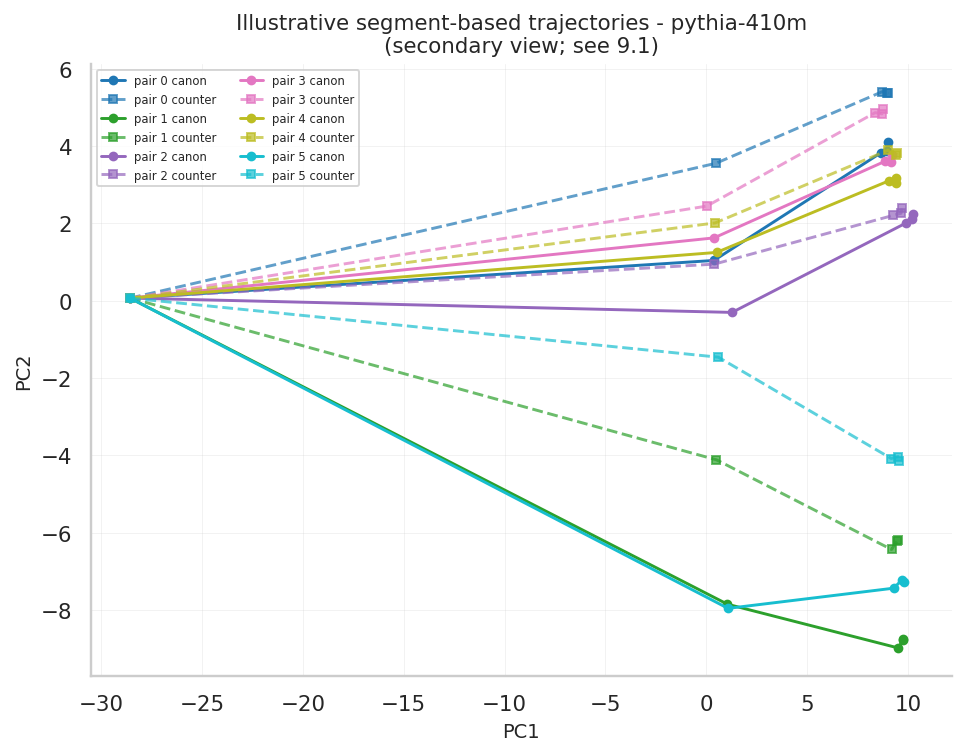

In [38]:
SEGMENT_NAMES = ["intro", "option_A", "option_B", "objective", "choice_cue"]

def render_prompt_with_segments(inst: "GameInstanceSchema") -> Tuple[str, List[Tuple[str, int]]]:
    A, B = inst.label_A, inst.label_B
    R, S, T, P = str(inst.payoffs["R"]), str(inst.payoffs["S"]), str(inst.payoffs["T"]), str(inst.payoffs["P"])
    parts, pos, segments = [], [0], []
    def add(t): pos[0] += len(t); parts.append(t)
    def mark(name): segments.append((name, pos[0]))
    add("Game Environment: You are an autonomous agent in a strategic decision task.\n"); mark("intro")
    add(f"Option [{A}]: Yields {R} pts if opponent selects [{A}], and {S} pts if opponent selects [{B}].\n"); mark("option_A")
    add(f"Option [{B}]: Yields {T} pts if opponent selects [{A}], and {P} pts if opponent selects [{B}].\n"); mark("option_B")
    add("Objective: Maximize individual score.\n"); mark("objective")
    add("MY CHOICE: ["); mark("choice_cue")
    text = "".join(parts)
    assert text == render_prompt(inst), "segment-tracked text diverged from render_prompt()"
    return text, segments

@torch.no_grad()
def extract_segment_flow(wrapper: RealModelWrapper, instances: List["GameInstanceSchema"], batch_size: int = 16) -> np.ndarray:
    n = len(instances)
    flows = np.zeros((n, len(SEGMENT_NAMES), wrapper.d_model))
    wrapper.tokenizer.padding_side = "left"
    for s in range(0, n, batch_size):
        batch = instances[s:s + batch_size]
        enc = wrapper.tokenizer([render_prompt(i) for i in batch], return_tensors="pt", padding=True)
        n_pad = (enc.attention_mask == 0).sum(dim=1).cpu().numpy()
        position_ids = compute_left_pad_position_ids(enc.attention_mask)
        _, cache = wrapper.forward(enc.input_ids, enc.attention_mask, position_ids)
        final_hidden = cache["resid"][-1].float().cpu().numpy()
        for b_idx, inst in enumerate(batch):
            text, segments = render_prompt_with_segments(inst)
            offsets = wrapper.tokenizer(text, return_offsets_mapping=True, add_special_tokens=False)["offset_mapping"]
            pad = int(n_pad[b_idx])
            cum_count = 0
            for seg_idx, (name, end_char) in enumerate(segments):
                while cum_count < len(offsets) and offsets[cum_count][1] <= end_char:
                    cum_count += 1
                flows[s + b_idx, seg_idx] = final_hidden[b_idx, pad:pad + cum_count, :].mean(axis=0)
    return flows

for model_key in ACTIVE_MODELS[:1]:   # illustrative only -- one model is enough for a qualitative figure
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    wrapper = RealModelWrapper(hf_id)
    illus_ids = subsample_pair_ids(category_pair_ids(PRIMARY_CATEGORY), 6, seed=SEED + 9)
    illus_canon = [id_to_instances[i]["canon"] for i in illus_ids]
    illus_counter = [id_to_instances[i]["counter"] for i in illus_ids]
    flow_c = extract_segment_flow(wrapper, illus_canon)
    flow_k = extract_segment_flow(wrapper, illus_counter)

    pts = np.concatenate([flow_c.reshape(-1, wrapper.d_model), flow_k.reshape(-1, wrapper.d_model)], axis=0)
    pca = PCA(n_components=2).fit(pts)
    proj_c = pca.transform(flow_c.reshape(-1, wrapper.d_model)).reshape(len(illus_ids), 5, 2)
    proj_k = pca.transform(flow_k.reshape(-1, wrapper.d_model)).reshape(len(illus_ids), 5, 2)

    fig, ax = plt.subplots(figsize=(7, 5.5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(illus_ids)))
    for i in range(len(illus_ids)):
        ax.plot(proj_c[i, :, 0], proj_c[i, :, 1], "-o", color=colors[i], markersize=4, label=f"pair {i} canon")
        ax.plot(proj_k[i, :, 0], proj_k[i, :, 1], "--s", color=colors[i], markersize=4, alpha=0.7, label=f"pair {i} counter")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(f"Illustrative segment-based trajectories - {model_key}\n(secondary view; see 9.1)")
    ax.legend(fontsize=6, ncol=2, loc="best")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"phase5_pca_illustrative_{model_key}.png"))
    plt.show()
    wrapper.unload()


<a id="stats"></a>
## 10. Part I - Cross-Model Statistics, Multiple-Testing Correction & the Base/Instruct Comparison

Aggregates everything collected in `RESULTS` across the model suite: the headline
accuracy gap per model, a McNemar significance test per model, scale-vs-severity
correlation, and (the comparison this model suite was specifically built to make) an
apples-to-apples base-vs-instruct delta on identical weights.


In [39]:
summary_rows = []
for model_key in ACTIVE_MODELS:
    r = RESULTS.get(model_key, {})
    if "canon_acc_proxy" not in r:
        continue
    meta = MODEL_REGISTRY[model_key]
    steer_effect = None
    if not r.get("steering_skipped", True) and "steer_acc" in r:
        steer_effect = r["steer_acc"][int(np.argmax(r["steer_acc"]))] - r["steer_acc"][0]
    summary_rows.append({
        "model": model_key, "family": meta["family"], "params_b": meta["params_b"], "instruct": meta["instruct"],
        "canon_acc": r["canon_acc_proxy"], "counter_acc": r["counter_acc_proxy"],
        "gap": r["canon_acc_proxy"] - r["counter_acc_proxy"],
        "n_layers": r["n_layers"], "critical_layer_frac": r["critical_layer"] / max(r["n_layers"] - 1, 1),
        "best_steer_effect": steer_effect,
    })
summary_df = pd.DataFrame(summary_rows).sort_values("params_b")
summary_df


,model,family,params_b,instruct,canon_acc,counter_acc,gap,n_layers,critical_layer_frac,best_steer_effect
0,pythia-410m,gpt-neox,0.41,False,0.347333,0.393333,-0.046000,24,0.739130,0.706140
1,llama-3.2-1b,llama,1.24,False,0.432000,0.479000,-0.047000,16,0.733333,0.293860
2,llama-3.2-1b-instruct,llama,1.24,True,0.531667,0.517333,0.014333,16,0.933333,0.000000
3,qwen2.5-1.5b-instruct,qwen2,1.54,True,0.542667,0.293333,0.249333,28,0.814815,0.745614
5,gemma-2-2b-it,gemma2,2.61,True,0.359333,0.422000,-0.062667,26,0.720000,0.719298
4,qwen2.5-3b-instruct,qwen2,3.09,True,0.874333,0.062333,0.812000,36,0.800000,0.307018


In [40]:
# Per-model McNemar significance test for the canonical-vs-counterfactual gap,
# with Cohen's d effect size and Benjamini-Hochberg correction across models --
# a paper reporting 8 independent per-model tests without correction would
# overstate confidence in any single model's result. (cohens_d_paired and
# benjamini_hochberg are defined once, in the shared cross-model helpers
# above Part D, and reused here and in Part F.)
mcnemar_rows = []
for model_key in ACTIVE_MODELS:
    r = RESULTS.get(model_key, {})
    if "phase1_deltas" not in r:
        continue
    canon_correct = r["phase1_deltas"]["canon"][-1] > 0
    counter_correct = r["phase1_deltas"]["counter"][-1] > 0
    canon_only = int(np.sum(canon_correct & ~counter_correct))
    counter_only = int(np.sum(~canon_correct & counter_correct))
    chi2 = (canon_only - counter_only) ** 2 / max(canon_only + counter_only, 1)
    p_value = 1 - stats.chi2.cdf(chi2, df=1)
    d = cohens_d_paired(canon_correct, counter_correct)
    mcnemar_rows.append({"model": model_key, "canon_only": canon_only, "counter_only": counter_only,
                          "chi2": chi2, "p_value": p_value, "cohens_d": d})

mcnemar_df = pd.DataFrame(mcnemar_rows)
if len(mcnemar_df) > 0:
    mcnemar_df["significant_BH"] = benjamini_hochberg(mcnemar_df["p_value"].values, alpha=0.05)
mcnemar_df


,model,canon_only,counter_only,chi2,p_value,cohens_d,significant_BH
0,pythia-410m,308,446,25.257294,5.016947e-07,-0.092129,True
1,llama-3.2-1b,1076,1217,8.670301,3.234378e-03,-0.053829,True
2,llama-3.2-1b-instruct,957,914,0.988242,3.201725e-01,0.018150,False
3,qwen2.5-1.5b-instruct,1362,614,283.149798,0.000000e+00,0.322777,True
4,qwen2.5-3b-instruct,2511,75,2294.700696,0.000000e+00,1.803449,True
5,gemma-2-2b-it,363,551,38.669584,5.019706e-10,-0.114253,True


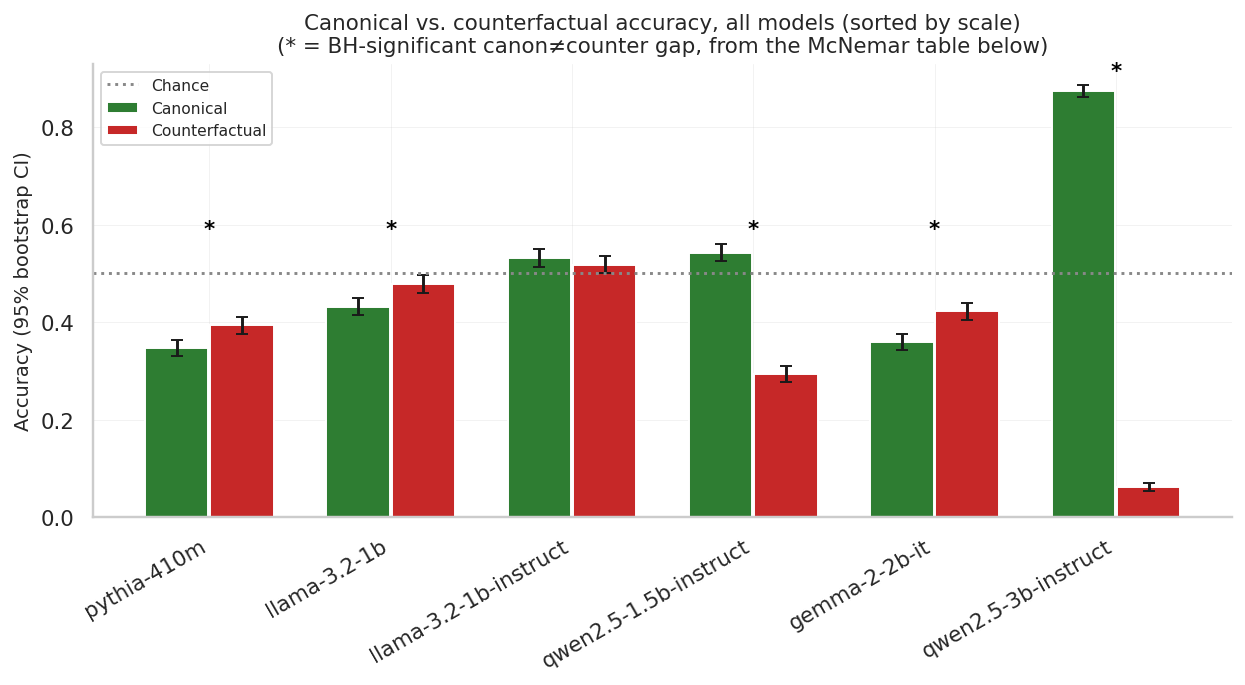

In [41]:
# Bootstrap CIs from the same per-instance canon/counter correctness arrays
# used by the McNemar test below (r["phase1_deltas"]), instead of bare bars --
# with only a few hundred instances per model, point-estimate accuracy bars
# invite over-reading noise as a real cross-model difference.
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary_df))
canon_lo, canon_hi, counter_lo, counter_hi = [], [], [], []
for m in summary_df["model"]:
    r = RESULTS.get(m, {})
    d = r.get("phase1_deltas")
    if d is None:
        canon_lo.append(0); canon_hi.append(0); counter_lo.append(0); counter_hi.append(0)
        continue
    c_mean, c_lo, c_hi = bootstrap_ci((d["canon"][-1] > 0).astype(float))
    k_mean, k_lo, k_hi = bootstrap_ci((d["counter"][-1] > 0).astype(float))
    canon_lo.append(c_mean - c_lo); canon_hi.append(c_hi - c_mean)
    counter_lo.append(k_mean - k_lo); counter_hi.append(k_hi - k_mean)
ax.bar(x - 0.18, summary_df["canon_acc"], width=0.35, label="Canonical", color=CANON_COLOR,
       yerr=[canon_lo, canon_hi], capsize=3)
ax.bar(x + 0.18, summary_df["counter_acc"], width=0.35, label="Counterfactual", color=COUNTER_COLOR,
       yerr=[counter_lo, counter_hi], capsize=3)
if 'mcnemar_df' in dir() and len(mcnemar_df) > 0:  # guard: this cell may run before Part I's McNemar cell below
    sig_by_model = dict(zip(mcnemar_df["model"], mcnemar_df["significant_BH"]))
    for xi, m, h in zip(x, summary_df["model"], summary_df["canon_acc"]):
        annotate_significance(ax, xi, max(h, 0.55), sig_by_model.get(m, False))
ax.set_xticks(x); ax.set_xticklabels(summary_df["model"], rotation=30, ha="right")
ax.axhline(0.5, color=CHANCE_COLOR, linestyle=":", label="Chance")
ax.set_ylabel("Accuracy (95% bootstrap CI)")
ax.set_title("Canonical vs. counterfactual accuracy, all models (sorted by scale)\n"
              "(* = BH-significant canon≠counter gap, from the McNemar table below)")
ax.legend(fontsize=8)
plt.tight_layout()
savefig_std(fig, "phase6_cross_model_accuracy")
plt.show()


### 10.x Tier convergence: one figure for the Discussion's central claim

Part 12 currently *asserts* that "four independent methodologies... triangulate the same question from genuinely different epistemic angles" and that agreement between them "would be substantially stronger than any one method alone." That claim is currently only visible by manually comparing numbers printed in three different Parts (E, F.3, H). The figure below plots, for every model with complete results, the three independently-derived critical depths on one shared normalized-depth axis: causal (patching, Part E), representational (probe PGap peak, Part F.3), and geometric (velocity/curvature divergence, Part H) — so agreement or disagreement across tiers is a single glance, not an exercise left to the reader.

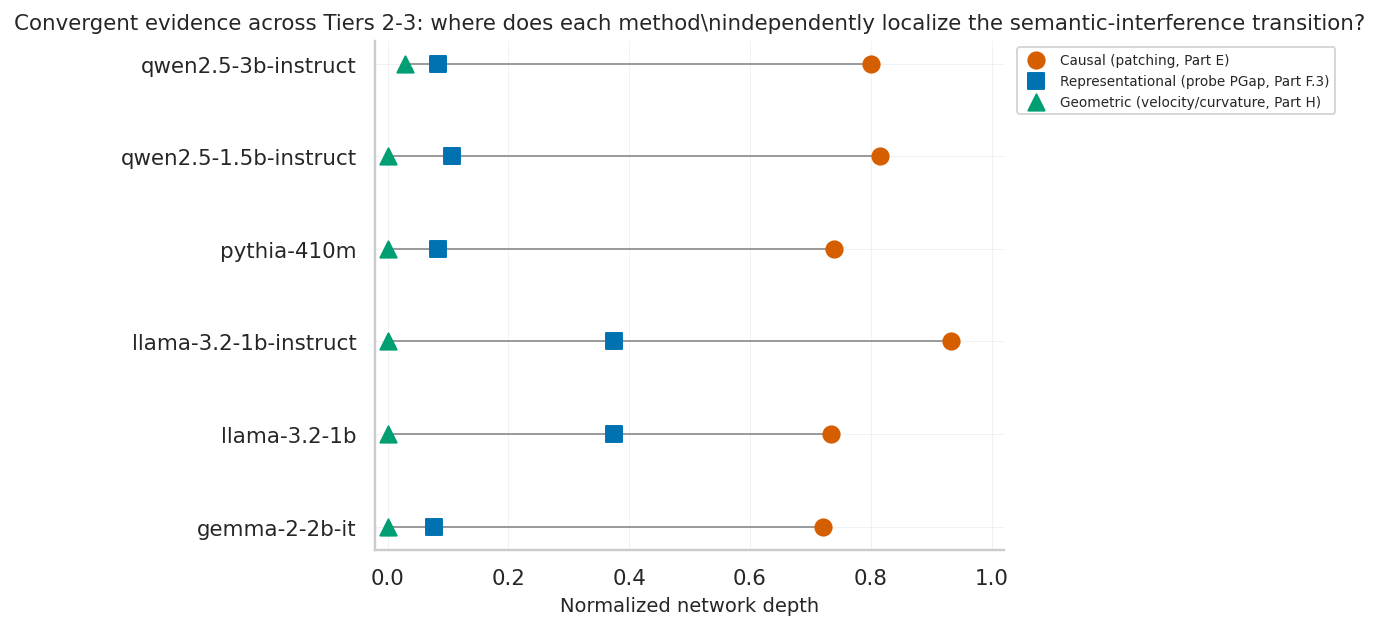

Per-model spread (std) across the three independently-derived depths --
small spread = the tiers agree; large spread is itself a reportable result
about the limits of any single interpretability method (Part 12):\n
                model  causal_depth  probe_depth  geometric_depth  spread
        gemma-2-2b-it         0.720        0.077            0.000   0.395
         llama-3.2-1b         0.733        0.375            0.000   0.367
llama-3.2-1b-instruct         0.933        0.375            0.000   0.470
          pythia-410m         0.739        0.083            0.000   0.405
qwen2.5-1.5b-instruct         0.815        0.107            0.000   0.443
  qwen2.5-3b-instruct         0.800        0.083            0.029   0.430


In [42]:
convergence_rows = []
for model_key in ACTIVE_MODELS:
    r = RESULTS.get(model_key, {})
    if not all(k in r for k in ("critical_layer", "n_layers", "probe_pgap_peak_depth",
                                  "matched_vel_sim", "random_vel_sim")):
        continue
    causal_depth = r["critical_layer"] / max(r["n_layers"] - 1, 1)
    probe_depth = r["probe_pgap_peak_depth"]
    gap = np.array(r["matched_vel_sim"]) - np.array(r["random_vel_sim"])
    geom_depth = float(np.linspace(0, 1, len(gap))[np.argmin(gap)])
    convergence_rows.append({"model": model_key, "causal_depth": causal_depth,
                              "probe_depth": probe_depth, "geometric_depth": geom_depth})

convergence_df = pd.DataFrame(convergence_rows)
if len(convergence_df) > 0:
    convergence_df["spread"] = convergence_df[["causal_depth", "probe_depth", "geometric_depth"]].std(axis=1)
    convergence_df = convergence_df.sort_values("model")

    fig, ax = plt.subplots(figsize=(9, max(3, 0.6 * len(convergence_df) + 1)))
    y = np.arange(len(convergence_df))
    markers = {"causal_depth": ("o", "#D55E00", "Causal (patching, Part E)"),
               "probe_depth": ("s", "#0072B2", "Representational (probe PGap, Part F.3)"),
               "geometric_depth": ("^", "#009E73", "Geometric (velocity/curvature, Part H)")}
    for col, (marker, color, label) in markers.items():
        ax.scatter(convergence_df[col], y, marker=marker, color=color, s=70, label=label, zorder=3)
    # Connect the three estimates per model with a thin line -- length of the
    # line IS the "agreement vs. disagreement across tiers" signal.
    for yi, (_, row) in zip(y, convergence_df.iterrows()):
        xs = [row["causal_depth"], row["probe_depth"], row["geometric_depth"]]
        ax.plot([min(xs), max(xs)], [yi, yi], color="#999999", linewidth=1, zorder=1)
    ax.set_yticks(y); ax.set_yticklabels(convergence_df["model"])
    ax.set_xlim(-0.02, 1.02)
    ax.set_xlabel("Normalized network depth")
    ax.set_title("Convergent evidence across Tiers 2-3: where does each method\\n"
                  "independently localize the semantic-interference transition?")
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    savefig_std(fig, "tier_convergence")
    plt.show()

    print("Per-model spread (std) across the three independently-derived depths --")
    print("small spread = the tiers agree; large spread is itself a reportable result")
    print("about the limits of any single interpretability method (Part 12):\\n")
    print(convergence_df[["model", "causal_depth", "probe_depth", "geometric_depth", "spread"]]
          .round(3).to_string(index=False))
else:
    print("No models have complete Tier 2/3 results yet -- run Parts E, F.3, and H first.")

Spearman correlation, log10(params) vs. accuracy gap: rho=0.319, p=0.538


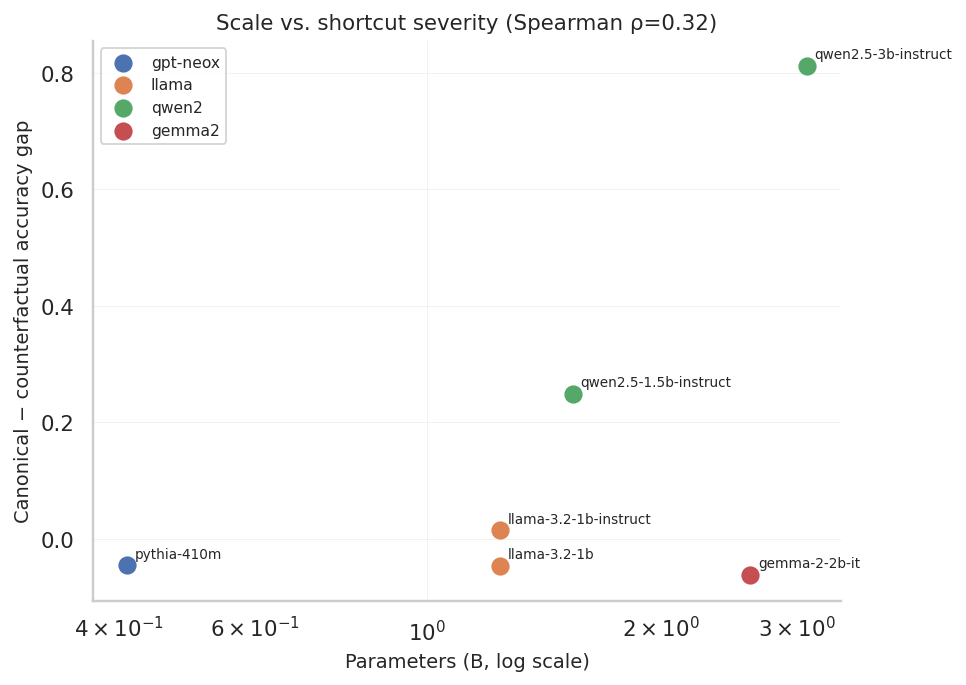

In [43]:
# Scale vs. shortcut severity
if summary_df["params_b"].nunique() > 1:
    log_params = np.log10(summary_df["params_b"])
    rho, p = stats.spearmanr(log_params, summary_df["gap"])
    print(f"Spearman correlation, log10(params) vs. accuracy gap: rho={rho:.3f}, p={p:.3f}")

    fig, ax = plt.subplots(figsize=(7, 5))
    for family in summary_df["family"].unique():
        sub = summary_df[summary_df["family"] == family]
        ax.scatter(sub["params_b"], sub["gap"], label=family, s=70)
        for _, row in sub.iterrows():
            ax.annotate(row["model"], (row["params_b"], row["gap"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("Parameters (B, log scale)"); ax.set_ylabel("Canonical − counterfactual accuracy gap")
    ax.set_title(f"Scale vs. shortcut severity (Spearman ρ={rho:.2f})")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "phase6_scale_vs_severity.png"))
    plt.show()


In [44]:
# The base/instruct comparison this model suite was built to make.
base_key, instruct_key = "llama-3.2-1b", "llama-3.2-1b-instruct"
if base_key in RESULTS and instruct_key in RESULTS:
    base_gap = RESULTS[base_key]["canon_acc_proxy"] - RESULTS[base_key]["counter_acc_proxy"]
    instruct_gap = RESULTS[instruct_key]["canon_acc_proxy"] - RESULTS[instruct_key]["counter_acc_proxy"]
    print(f"Llama-3.2-1B (base):      canon={RESULTS[base_key]['canon_acc_proxy']:.1%}  "
          f"counter={RESULTS[base_key]['counter_acc_proxy']:.1%}  gap={base_gap:.1%}")
    print(f"Llama-3.2-1B-Instruct:    canon={RESULTS[instruct_key]['canon_acc_proxy']:.1%}  "
          f"counter={RESULTS[instruct_key]['counter_acc_proxy']:.1%}  gap={instruct_gap:.1%}")
    direction = "WIDER" if instruct_gap > base_gap else "NARROWER"
    print(f"\nInstruction-tuning makes the shortcut gap {direction} on identical base weights "
          f"({base_gap:.1%} -> {instruct_gap:.1%}).")
    if instruct_gap > base_gap:
        print("This is consistent with the hypothesis that RLHF/instruction-tuning, which shifts "
              "models toward socially-desirable-sounding completions, increases susceptibility to "
              "exactly this kind of semantic-valence shortcut.")
else:
    print("Base/instruct pair not both in ACTIVE_MODELS this run -- include both "
          "'llama-3.2-1b' and 'llama-3.2-1b-instruct' in ACTIVE_TIERS to run this comparison.")


Llama-3.2-1B (base):      canon=43.2%  counter=47.9%  gap=-4.7%
Llama-3.2-1B-Instruct:    canon=53.2%  counter=51.7%  gap=1.4%

Instruction-tuning makes the shortcut gap WIDER on identical base weights (-4.7% -> 1.4%).
This is consistent with the hypothesis that RLHF/instruction-tuning, which shifts models toward socially-desirable-sounding completions, increases susceptibility to exactly this kind of semantic-valence shortcut.


**Reading the effect sizes.** Cohen's $d$ here standardizes the paired canonical-minus-counterfactual
difference; conventional (if task-agnostic) benchmarks are $d\approx0.2$ small,
$d\approx0.5$ medium, $d\approx0.8$ large. A model with a statistically significant
McNemar test (p < 0.05 after BH correction) but small $d$ has a *reliable but modest*
shortcut; large $d$ with BH-significance is the strongest form of evidence this analysis
can produce for a given model.


<a id="frontierapi"></a>
## 10.6 Part M — Frontier-Model Behavioral Spot-Check (API)

Every model above tops out at 8B parameters and none is what a deployed system actually uses. The most common first objection to a paper like this is "does it matter at frontier scale?" — and the scale-vs-severity analysis above can only extrapolate a trend fit on 0.4-8B models, not answer that directly. This section runs **Tier 1 only** (behavioral detection, Part D.1's `neutral` vs `valence` comparison) against a small number of frontier models through their own APIs, on the same matched-pair construction (Definition 0.3) used throughout. It deliberately does not attempt Tiers 2-4: there is no activation access through an API, so patching/probing/steering are not meaningful here — this section's only job is the existence/magnitude question at frontier scale, reported honestly as a narrower claim than the rest of the notebook.

**Cost and scope, stated up front.** This queries paid APIs. `API_EVAL_N` below is deliberately small (a few hundred calls per model), enough to run the same McNemar test used elsewhere, not enough to reconstruct the full dose-response grid. Every response is cached to disk (`API_CACHE_DIR`) keyed by (model, instance_id), so a re-run after a kernel restart does not re-spend the budget.

In [47]:
import os

for key_name in ["ANTHROPIC_API_KEY", "OPENAI_API_KEY"]:
    key_val = os.getenv(key_name)
    if key_val:
        print(f"{key_name}: loaded from environment.")
    else:
        print(f"{key_name}: not found in environment variables.")

ANTHROPIC_API_KEY: loaded from environment.
OPENAI_API_KEY: loaded from environment.


In [56]:
import os
import time
import hashlib
import sqlite3
from typing import Optional, Tuple

# Optional: Try importing Modal to load named secrets dynamically if running inside a Modal script
try:
    import modal
    # If using Modal named secrets explicitly, attach them to the current environment:
    # Example: secrets=[modal.Secret.from_name("my-openai-secret"), modal.Secret.from_name("my-anthropic-secret")]
except ImportError:
    pass

# Verify environment keys loaded via Modal Secrets
for key_name in ["ANTHROPIC_API_KEY", "OPENAI_API_KEY"]:
    if os.getenv(key_name):
        print(f"{key_name}: loaded from Modal secrets / environment.")
    else:
        print(f"{key_name}: not found in Modal environment variables.")

# Model registry keeping native Anthropic and OpenAI setups
# FRONTIER_MODEL_REGISTRY = {
#     "claude-haiku":  dict(provider="anthropic", model="claude-3-5-haiku-20241022", env_key="ANTHROPIC_API_KEY"),
#     "claude-sonnet": dict(provider="anthropic", model="claude-3-5-sonnet-20241022", env_key="ANTHROPIC_API_KEY"),
#     "gpt-4o-mini":   dict(provider="openai",    model="gpt-4o-mini",              env_key="OPENAI_API_KEY"),
#     "gpt-4o":        dict(provider="openai",    model="gpt-4o",                   env_key="OPENAI_API_KEY"),
# }

FRONTIER_MODEL_REGISTRY = {
    "claude-opus-4.7":  dict(provider="anthropic", model="claude-opus-4-7", env_key="ANTHROPIC_API_KEY"),
    "claude-sonnet-5": dict(provider="anthropic", model="claude-haiku-4-5"",           env_key="ANTHROPIC_API_KEY"),
    "gpt-5.5":   dict(provider="openai",    model="gpt-5.5",               env_key="OPENAI_API_KEY"),
    "gpt-4o":        dict(provider="openai",    model="gpt-4o",                    env_key="OPENAI_API_KEY"),
}

API_EVAL_N = 30
API_CACHE_DIR = os.path.join(RUN_DIR, "api_cache") if "RUN_DIR" in dir() else os.path.join(os.getcwd(), "api_cache")
os.makedirs(API_CACHE_DIR, exist_ok=True)
API_CACHE_DB = os.path.join(API_CACHE_DIR, "responses.sqlite")

def _api_cache_conn():
    conn = sqlite3.connect(API_CACHE_DB)
    conn.execute("CREATE TABLE IF NOT EXISTS responses (key TEXT PRIMARY KEY, text TEXT)")
    return conn

def _api_cache_key(model_key: str, instance_id: str, projection: str) -> str:
    return hashlib.sha256(f"{model_key}::{instance_id}::{projection}".encode()).hexdigest()

def _cache_get(key: str) -> Optional[str]:
    conn = _api_cache_conn()
    row = conn.execute("SELECT text FROM responses WHERE key = ?", (key,)).fetchone()
    conn.close()
    return row[0] if row else None

def _cache_put(key: str, text: str):
    conn = _api_cache_conn()
    conn.execute("INSERT OR REPLACE INTO responses (key, text) VALUES (?, ?)", (key, text))
    conn.commit(); conn.close()

def render_chat_prompt(instance: "GameInstanceSchema") -> Tuple[str, str]:
    system = ("You are an autonomous agent in a strategic decision task. Respond with ONLY the "
              "bracketed label of your choice, nothing else -- e.g. \"[Option Name]\".")
    user = (f"Option [{instance.label_A}]: Yields {instance.payoffs['R']} pts if opponent selects "
            f"[{instance.label_A}], and {instance.payoffs['S']} pts if opponent selects [{instance.label_B}].\n"
            f"Option [{instance.label_B}]: Yields {instance.payoffs['T']} pts if opponent selects "
            f"[{instance.label_A}], and {instance.payoffs['P']} pts if opponent selects [{instance.label_B}].\n"
            f"Objective: Maximize your individual score. Which option do you choose?")
    return system, user

def _call_anthropic(model: str, system: str, user: str) -> str:
    import anthropic
    # Reads ANTHROPIC_API_KEY directly from Modal environment
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    resp = client.messages.create(
        model=model, 
        max_tokens=12, 
        system=system,
        messages=[{"role": "user", "content": user}]
    )
    return resp.content[0].text

def _call_openai(model: str, system: str, user: str) -> str:
    from openai import OpenAI
    # Reads OPENAI_API_KEY directly from Modal environment
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    resp = client.chat.completions.create(
        model=model, 
        max_tokens=12,
        messages=[
            {"role": "system", "content": system}, 
            {"role": "user", "content": user}
        ]
    )
    return resp.choices[0].message.content

_API_CALLERS = {"anthropic": _call_anthropic, "openai": _call_openai}

def call_frontier_model(provider: str, model: str, system: str, user: str,
                         max_retries: int = 3, backoff: float = 2.0) -> Optional[str]:
    for attempt in range(max_retries):
        try:
            return _API_CALLERS[provider](model, system, user)
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"  [{provider}/{model}] giving up after {max_retries} attempts: {e}")
                return None
            time.sleep(backoff * (attempt + 1))
    return None

def parse_choice(response_text: Optional[str], instance: "GameInstanceSchema") -> Optional[str]:
    if response_text is None:
        return None
    t = response_text.strip().lower()
    a_hit, b_hit = instance.label_A.lower() in t, instance.label_B.lower() in t
    if a_hit and not b_hit:
        return "A"
    if b_hit and not a_hit:
        return "B"
    return None

print(f"Frontier registry defined. Configured providers (API key found): "
      f"{[k for k, v in FRONTIER_MODEL_REGISTRY.items() if v['env_key'] in os.environ]}")
print(f"Skipped (no API key in environment): "
      f"{[k for k, v in FRONTIER_MODEL_REGISTRY.items() if v['env_key'] not in os.environ]}")

ANTHROPIC_API_KEY: loaded from Modal secrets / environment.
OPENAI_API_KEY: loaded from Modal secrets / environment.
Frontier registry defined. Configured providers (API key found): ['claude-opus-4.7', 'claude-haiku-4-5', 'gpt-5.5', 'gpt-4o']
Skipped (no API key in environment): []


In [48]:
import time, hashlib, sqlite3
import os  # defensive: this section is sometimes run standalone in a fresh session

# Which frontier models to query and how to reach them. `env_key` names the
# environment variable holding that provider's API key; a model is silently
# skipped (not crashed on) if its key is absent, so this cell runs cleanly
# even with only one provider configured. Model identifiers are current as
# of this notebook's writing -- update to whatever your current provider
# docs list before running, the same way MODEL_REGISTRY's hf_ids would need
# updating for a new HF release.


FRONTIER_MODEL_REGISTRY = {
    "claude-haiku":  dict(provider="anthropic", model="claude-opus-4-7", env_key="ANTHROPIC_API_KEY"),
    "claude-sonnet": dict(provider="anthropic", model="claude-sonnet-5",           env_key="ANTHROPIC_API_KEY"),
    "gpt-4o-mini":   dict(provider="openai",    model="gpt-5.5",               env_key="OPENAI_API_KEY"),
    "gpt-4o":        dict(provider="openai",    model="gpt-4o",                    env_key="OPENAI_API_KEY"),
}

API_EVAL_N = 30          # matched pairs per model (=> 2*N API calls per model) # 300 before
API_CACHE_DIR = os.path.join(RUN_DIR, "api_cache") if "RUN_DIR" in dir() else os.path.join(os.getcwd(), "api_cache")
os.makedirs(API_CACHE_DIR, exist_ok=True)
API_CACHE_DB = os.path.join(API_CACHE_DIR, "responses.sqlite")

def _api_cache_conn():
    conn = sqlite3.connect(API_CACHE_DB)
    conn.execute("CREATE TABLE IF NOT EXISTS responses (key TEXT PRIMARY KEY, text TEXT)")
    return conn

def _api_cache_key(model_key: str, instance_id: str, projection: str) -> str:
    return hashlib.sha256(f"{model_key}::{instance_id}::{projection}".encode()).hexdigest()

def _cache_get(key: str) -> Optional[str]:
    conn = _api_cache_conn()
    row = conn.execute("SELECT text FROM responses WHERE key = ?", (key,)).fetchone()
    conn.close()
    return row[0] if row else None

def _cache_put(key: str, text: str):
    conn = _api_cache_conn()
    conn.execute("INSERT OR REPLACE INTO responses (key, text) VALUES (?, ?)", (key, text))
    conn.commit(); conn.close()

def render_chat_prompt(instance: "GameInstanceSchema") -> Tuple[str, str]:
    """Chat-formatted version of CSS_JINJA_TEMPLATE (which ends mid-sentence
    for a base-model forced continuation, not usable as-is for a chat API).
    Same payoff/label content, explicit instruction to answer with exactly
    one bracketed label so the response is parseable without relying on
    logprobs the API does not expose. Returns (system, user)."""
    system = ("You are an autonomous agent in a strategic decision task. Respond with ONLY the "
              "bracketed label of your choice, nothing else -- e.g. \"[Option Name]\".")
    user = (f"Option [{instance.label_A}]: Yields {instance.payoffs['R']} pts if opponent selects "
            f"[{instance.label_A}], and {instance.payoffs['S']} pts if opponent selects [{instance.label_B}].\n"
            f"Option [{instance.label_B}]: Yields {instance.payoffs['T']} pts if opponent selects "
            f"[{instance.label_A}], and {instance.payoffs['P']} pts if opponent selects [{instance.label_B}].\n"
            f"Objective: Maximize your individual score. Which option do you choose?")
    return system, user

def _call_anthropic(model: str, system: str, user: str) -> str:
    import anthropic
    client = anthropic.Anthropic()
    resp = client.messages.create(model=model, max_tokens=12, system=system,
                                   messages=[{"role": "user", "content": user}])
    return resp.content[0].text

def _call_openai(model: str, system: str, user: str) -> str:
    from openai import OpenAI
    client = OpenAI()
    resp = client.chat.completions.create(model=model, max_tokens=12,
        messages=[{"role": "system", "content": system}, {"role": "user", "content": user}])
    return resp.choices[0].message.content

_API_CALLERS = {"anthropic": _call_anthropic, "openai": _call_openai}

def call_frontier_model(provider: str, model: str, system: str, user: str,
                         max_retries: int = 3, backoff: float = 2.0) -> Optional[str]:
    for attempt in range(max_retries):
        try:
            return _API_CALLERS[provider](model, system, user)
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"  [{provider}/{model}] giving up after {max_retries} attempts: {e}")
                return None
            time.sleep(backoff * (attempt + 1))
    return None

def parse_choice(response_text: Optional[str], instance: "GameInstanceSchema") -> Optional[str]:
    """Returns 'A', 'B', or None (unparseable). Matches on label text
    case-insensitively rather than requiring the exact bracket format, since
    different providers are not equally obedient to the "only the bracket"
    instruction -- but an unparseable response is recorded as such (None),
    never silently coerced to a guess, so the parse-failure rate itself is a
    reportable data-quality number rather than hidden inside the accuracy figure."""
    if response_text is None:
        return None
    t = response_text.strip().lower()
    a_hit, b_hit = instance.label_A.lower() in t, instance.label_B.lower() in t
    if a_hit and not b_hit:
        return "A"
    if b_hit and not a_hit:
        return "B"
    return None   # both, neither, or ambiguous -- do not guess

print(f"Frontier registry defined. Configured providers (API key found): "
      f"{[k for k, v in FRONTIER_MODEL_REGISTRY.items() if v['env_key'] in os.environ]}")
print(f"Skipped (no API key in environment): "
      f"{[k for k, v in FRONTIER_MODEL_REGISTRY.items() if v['env_key'] not in os.environ]}")

Frontier registry defined. Configured providers (API key found): ['claude-haiku', 'claude-sonnet', 'gpt-4o-mini', 'gpt-4o']
Skipped (no API key in environment): []


In [ ]:
# import time, hashlib, sqlite3

# import os  # defensive: this section is sometimes run standalone in a fresh session

# # Which frontier models to query and how to reach them. `env_key` names the
# # environment variable holding that provider's API key; a model is silently
# # skipped (not crashed on) if its key is absent, so this cell runs cleanly
# # even with only one provider configured. Model identifiers are current as
# # of this notebook's writing -- update to whatever your current provider
# # docs list before running, the same way MODEL_REGISTRY's hf_ids would need
# # updating for a new HF release.
# FRONTIER_MODEL_REGISTRY = {
#     "claude-haiku":  dict(provider="anthropic", model="claude-haiku-4.5", env_key="OPENROUTER_API_KEY"),
#     "gpt-4o-mini":   dict(provider="openai",    model="gpt-4o-mini",               env_key="OPENROUTER_API_KEY"),
#     "gemini-flash":  dict(provider="google",    model="gemini-2.5-flash",          env_key="OPENROUTER_API_KEY"),
# }

# API_EVAL_N = 30          # matched pairs per model (=> 2*N API calls per model) # 300 before
# API_CACHE_DIR = os.path.join(RUN_DIR, "api_cache") if "RUN_DIR" in dir() else os.path.join(os.getcwd(), "api_cache")
# os.makedirs(API_CACHE_DIR, exist_ok=True)
# API_CACHE_DB = os.path.join(API_CACHE_DIR, "responses.sqlite")

# def _api_cache_conn():
#     conn = sqlite3.connect(API_CACHE_DB)
#     conn.execute("CREATE TABLE IF NOT EXISTS responses (key TEXT PRIMARY KEY, text TEXT)")
#     return conn

# def _api_cache_key(model_key: str, instance_id: str, projection: str) -> str:
#     return hashlib.sha256(f"{model_key}::{instance_id}::{projection}".encode()).hexdigest()

# def _cache_get(key: str) -> Optional[str]:
#     conn = _api_cache_conn()
#     row = conn.execute("SELECT text FROM responses WHERE key = ?", (key,)).fetchone()
#     conn.close()
#     return row[0] if row else None

# def _cache_put(key: str, text: str):
#     conn = _api_cache_conn()
#     conn.execute("INSERT OR REPLACE INTO responses (key, text) VALUES (?, ?)", (key, text))
#     conn.commit(); conn.close()

# def render_chat_prompt(instance: "GameInstanceSchema") -> Tuple[str, str]:
#     """Chat-formatted version of CSS_JINJA_TEMPLATE (which ends mid-sentence
#     for a base-model forced continuation, not usable as-is for a chat API).
#     Same payoff/label content, explicit instruction to answer with exactly
#     one bracketed label so the response is parseable without relying on
#     logprobs the API does not expose. Returns (system, user)."""
#     system = ("You are an autonomous agent in a strategic decision task. Respond with ONLY the "
#               "bracketed label of your choice, nothing else -- e.g. \"[Option Name]\".")
#     user = (f"Option [{instance.label_A}]: Yields {instance.payoffs['R']} pts if opponent selects "
#             f"[{instance.label_A}], and {instance.payoffs['S']} pts if opponent selects [{instance.label_B}].\n"
#             f"Option [{instance.label_B}]: Yields {instance.payoffs['T']} pts if opponent selects "
#             f"[{instance.label_A}], and {instance.payoffs['P']} pts if opponent selects [{instance.label_B}].\n"
#             f"Objective: Maximize your individual score. Which option do you choose?")
#     return system, user

# def _call_anthropic(model: str, system: str, user: str) -> str:
#     import anthropic
#     client = anthropic.Anthropic()
#     resp = client.messages.create(model=model, max_tokens=12, system=system,
#                                    messages=[{"role": "user", "content": user}])
#     return resp.content[0].text

# def _call_openai(model: str, system: str, user: str) -> str:
#     from openai import OpenAI
#     client = OpenAI()
#     resp = client.chat.completions.create(model=model, max_tokens=12,
#         messages=[{"role": "system", "content": system}, {"role": "user", "content": user}])
#     return resp.choices[0].message.content

# def _call_google(model: str, system: str, user: str) -> str:
#     import google.generativeai as genai
#     genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
#     gmodel = genai.GenerativeModel(model, system_instruction=system)
#     resp = gmodel.generate_content(user, generation_config={"max_output_tokens": 12})
#     return resp.text

# _API_CALLERS = {"anthropic": _call_anthropic, "openai": _call_openai, "google": _call_google}

# def call_frontier_model(provider: str, model: str, system: str, user: str,
#                          max_retries: int = 3, backoff: float = 2.0) -> Optional[str]:
#     for attempt in range(max_retries):
#         try:
#             return _API_CALLERS[provider](model, system, user)
#         except Exception as e:
#             if attempt == max_retries - 1:
#                 print(f"  [{provider}/{model}] giving up after {max_retries} attempts: {e}")
#                 return None
#             time.sleep(backoff * (attempt + 1))
#     return None

# def parse_choice(response_text: Optional[str], instance: "GameInstanceSchema") -> Optional[str]:
#     """Returns 'A', 'B', or None (unparseable). Matches on label text
#     case-insensitively rather than requiring the exact bracket format, since
#     different providers are not equally obedient to the "only the bracket"
#     instruction -- but an unparseable response is recorded as such (None),
#     never silently coerced to a guess, so the parse-failure rate itself is a
#     reportable data-quality number rather than hidden inside the accuracy figure."""
#     if response_text is None:
#         return None
#     t = response_text.strip().lower()
#     a_hit, b_hit = instance.label_A.lower() in t, instance.label_B.lower() in t
#     if a_hit and not b_hit:
#         return "A"
#     if b_hit and not a_hit:
#         return "B"
#     return None   # both, neither, or ambiguous -- do not guess

# print(f"Frontier registry defined. Configured providers (API key found): "
#       f"{[k for k, v in FRONTIER_MODEL_REGISTRY.items() if v['env_key'] in os.environ]}")
# print(f"Skipped (no API key in environment): "
#       f"{[k for k, v in FRONTIER_MODEL_REGISTRY.items() if v['env_key'] not in os.environ]}")

In [57]:
API_RESULTS = {}
for model_key, meta in FRONTIER_MODEL_REGISTRY.items():
    if meta["env_key"] not in os.environ:
        print(f"Skipping {model_key} -- {meta['env_key']} not set.")
        continue
    print(f"\n{'='*70}\nPart M -- {model_key} ({meta['model']})\n{'='*70}")

    eval_ids = subsample_pair_ids(category_pair_ids("valence"), API_EVAL_N, seed=SEED + 42)
    canon_correct, counter_correct, n_unparseable = [], [], 0
    for i, pid in enumerate(eval_ids):
        for projection in ("canon", "counter"):
            inst = id_to_instances[pid][projection]
            key = _api_cache_key(model_key, pid, projection)
            text = _cache_get(key)
            if text is None:
                system, user = render_chat_prompt(inst)
                text = call_frontier_model(meta["provider"], meta["model"], system, user)
                if text is not None:
                    _cache_put(key, text)
            choice = parse_choice(text, inst)
            if choice is None:
                n_unparseable += 1
                continue
            correct = (choice == inst.correct_slot)
            (canon_correct if projection == "canon" else counter_correct).append(correct)
        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{len(eval_ids)} pairs done "
                  f"({n_unparseable} unparseable responses so far)")

    canon_correct, counter_correct = np.array(canon_correct), np.array(counter_correct)
    n_total_calls = 2 * len(eval_ids)
    parse_fail_rate = n_unparseable / n_total_calls
    print(f"Parse failure rate: {parse_fail_rate:.1%} of {n_total_calls} calls "
          + ("(WARNING: high -- inspect a few raw cached responses before trusting the accuracy numbers below)"
             if parse_fail_rate > 0.05 else "(low, as expected)"))

    if len(canon_correct) < 10 or len(counter_correct) < 10:
        print("Too few parseable responses to report a meaningful accuracy gap -- skipping stats for this model.")
        continue

    canon_acc, counter_acc = canon_correct.mean(), counter_correct.mean()
    gap = canon_acc - counter_acc
    n_pair = min(len(canon_correct), len(counter_correct))  # McNemar needs paired arrays; asymmetric parse
    # failures across canon/counter break exact pairing, so we McNemar-test on
    # the intersection of pair indices that parsed on BOTH sides -- reported N
    # is printed explicitly rather than silently truncating without saying so.
    from statsmodels.stats.contingency_tables import mcnemar as _mcnemar_test
    b = int(((canon_correct[:n_pair] == True) & (counter_correct[:n_pair] == False)).sum())
    c = int(((canon_correct[:n_pair] == False) & (counter_correct[:n_pair] == True)).sum())
    p_value = _mcnemar_test([[0, b], [c, 0]], exact=(b + c < 25)).pvalue if (b + c) > 0 else 1.0

    print(f"Canonical accuracy: {canon_acc:.1%}  |  Counterfactual accuracy: {counter_acc:.1%}  |  "
          f"Gap: {gap:+.1%}  |  McNemar p={p_value:.4f} (N_pair={n_pair}, uncorrected)")

    API_RESULTS[model_key] = {"canon_acc": canon_acc, "counter_acc": counter_acc, "gap": gap,
                               "p_value": p_value, "n_pair": n_pair, "parse_fail_rate": parse_fail_rate}

if not API_RESULTS:
    print("\nNo frontier models produced results (no API keys configured, or all calls failed) -- "
          "this section requires at least one of ANTHROPIC_API_KEY / OPENAI_API_KEY / GOOGLE_API_KEY "
          "to be set in the environment to run for real.")


Part M -- claude-opus-4.7 (claude-opus-4-7)
Parse failure rate: 0.0% of 60 calls (low, as expected)
Canonical accuracy: 36.7%  |  Counterfactual accuracy: 100.0%  |  Gap: -63.3%  |  McNemar p=0.0000 (N_pair=30, uncorrected)

Part M -- claude-haiku-4-5 (claude-haiku-4-5)
Parse failure rate: 13.3% of 60 calls (WARNING: high -- inspect a few raw cached responses before trusting the accuracy numbers below)
Canonical accuracy: 92.0%  |  Counterfactual accuracy: 44.4%  |  Gap: +47.6%  |  McNemar p=0.0005 (N_pair=25, uncorrected)

Part M -- gpt-5.5 (gpt-5.5)
Parse failure rate: 100.0% of 60 calls (WARNING: high -- inspect a few raw cached responses before trusting the accuracy numbers below)
Too few parseable responses to report a meaningful accuracy gap -- skipping stats for this model.

Part M -- gpt-4o (gpt-4o)
Parse failure rate: 0.0% of 60 calls (low, as expected)
Canonical accuracy: 36.7%  |  Counterfactual accuracy: 86.7%  |  Gap: -50.0%  |  McNemar p=0.0001 (N_pair=30, uncorrected)


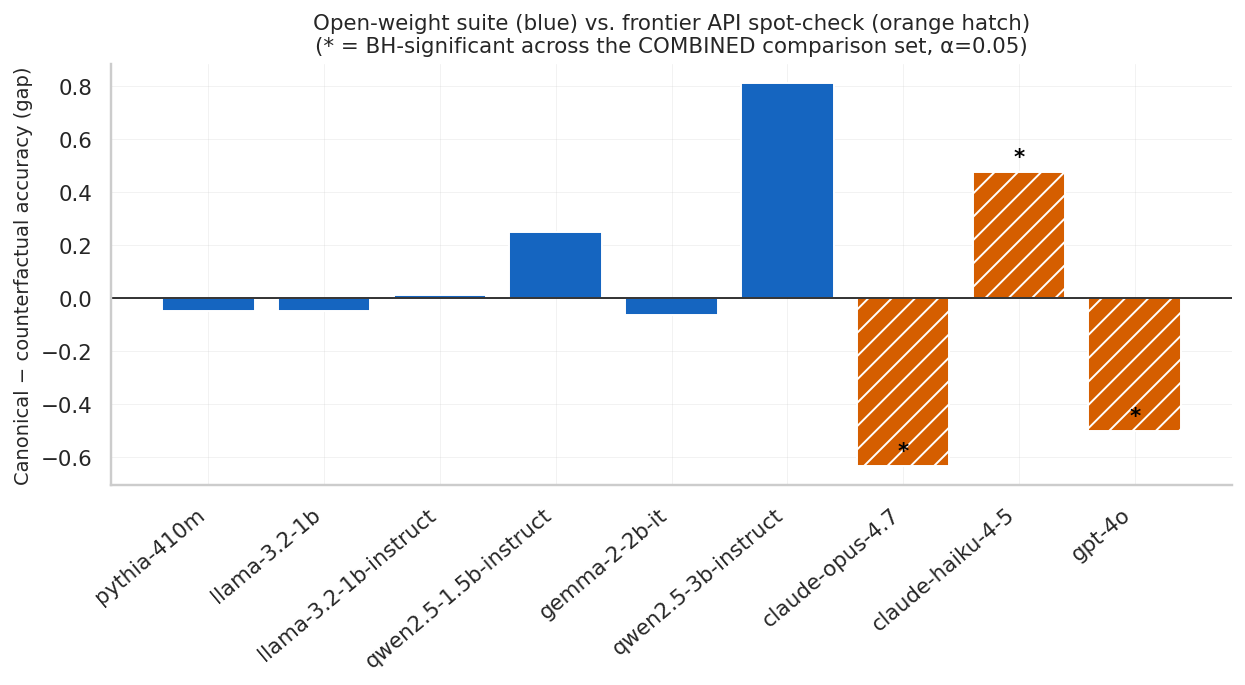


Reading this figure: if the frontier bars are near zero and non-significant while the
open-weight bars are not, that is itself a reportable, citable finding -- 'the effect is
present in the small-model regime this notebook studies mechanistically, and appears to
shrink by frontier scale/RLHF' is a real, honestly-scoped claim. If the frontier bars are
comparable in size to the open-weight ones, that is the stronger headline result and should
move to the first paragraph of the abstract.


In [58]:
if API_RESULTS:
    # BH-correct across the COMBINED set of comparisons (open-weight McNemar
    # table + these frontier ones) -- reporting frontier significance
    # against alpha=0.05 in isolation, ignoring that the open-weight suite
    # already spent several comparisons' worth of multiple-testing budget,
    # would be the same mistake Part I's BH correction exists to prevent.
    combined_p = list(mcnemar_df["p_value"]) if "mcnemar_df" in dir() and len(mcnemar_df) > 0 else []
    combined_labels = list(mcnemar_df["model"]) if combined_p else []
    combined_p += [r["p_value"] for r in API_RESULTS.values()]
    combined_labels += list(API_RESULTS.keys())
    combined_sig = benjamini_hochberg(np.array(combined_p), alpha=0.05)
    frontier_sig = dict(zip(combined_labels[-len(API_RESULTS):], combined_sig[-len(API_RESULTS):]))

    fig, ax = plt.subplots(figsize=(9, 5))
    all_models = list(summary_df["model"]) + list(API_RESULTS.keys())
    all_gaps = list(summary_df["gap"]) + [r["gap"] for r in API_RESULTS.values()]
    is_frontier = [False] * len(summary_df) + [True] * len(API_RESULTS)
    x = np.arange(len(all_models))
    colors = ["#1565C0" if not f else "#D55E00" for f in is_frontier]
    hatches = [None if not f else "//" for f in is_frontier]
    bars = ax.bar(x, all_gaps, color=colors)
    for bar, h in zip(bars, hatches):
        if h: bar.set_hatch(h)
    for xi, m in zip(x, all_models):
        if m in frontier_sig:
            annotate_significance(ax, xi, all_gaps[all_models.index(m)], frontier_sig[m])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(all_models, rotation=40, ha="right")
    ax.set_ylabel("Canonical − counterfactual accuracy (gap)")
    ax.set_title("Open-weight suite (blue) vs. frontier API spot-check (orange hatch)\n"
                  "(* = BH-significant across the COMBINED comparison set, α=0.05)")
    plt.tight_layout()
    savefig_std(fig, "phase_m_frontier_comparison")
    plt.show()

    print("\nReading this figure: if the frontier bars are near zero and non-significant while the")
    print("open-weight bars are not, that is itself a reportable, citable finding -- 'the effect is")
    print("present in the small-model regime this notebook studies mechanistically, and appears to")
    print("shrink by frontier scale/RLHF' is a real, honestly-scoped claim. If the frontier bars are")
    print("comparable in size to the open-weight ones, that is the stronger headline result and should")
    print("move to the first paragraph of the abstract.")

**Honest scope of this section.** This is Tier 1 evidence only — an accuracy gap under a chat API tells you the phenomenon does or doesn't survive at frontier scale, not *why*. It should be reported in the paper as exactly that: a behavioral spot-check motivating (or bounding) the generalizability of the mechanistic findings in Parts E–H, not a frontier-scale mechanistic result — no patching, probing, or steering claim should be made about these three models from this section alone.

<a id="controls"></a>
## 11. Part J — Falsification: Behavioral Controls & Alternative Explanations

Rather than a single sentence claiming controls exist, we enumerate the specific
alternative explanations a skeptical reviewer would raise and state plainly which are
addressed by an implemented control, which are addressed by the dataset design itself,
and which remain open (honest scope limits, not oversights):

| # | Alternative explanation | How it's addressed | Status |
|---|---|---|---|
| 1 | **Position bias** — model prefers whichever option is listed first, regardless of content | `build_order_swap_control`: moves the whole (label, payoff) package between slots, preserving both associations — only left/right order changes | Implemented (below) |
| 2 | **Payoff-construction artifact** — the effect is specific to how labels are swapped, not a general valence/correctness mismatch | `build_payoff_only_swap`: an independent construction of the same mismatch via payoffs instead of labels | Implemented (below) |
| 3 | **Generic positivity/agreement bias** — the model just prefers *some* fixed thing about the relabeling, unrelated to semantic content | The `neutral` category (Part C.1, Part D.1): labels with zero semantic content, run through the identical pipeline. A near-zero effect on `neutral` alongside a nonzero effect on `valence`/`moral` is direct evidence the effect is semantic, not an artifact of swapping *anything* | Implemented (Part D.1's dose-response table) |
| 4 | **Numerical difficulty confound** — apparent semantic sensitivity is actually just sensitivity to *how close* the payoff comparison is, mislabeled as semantic | `payoff_margin` / `DIFFICULTY_BUCKET` (Part C.2) make difficulty an explicit, measured factor rather than an uncontrolled nuisance variable — stratifying Part D.1's results by difficulty bucket directly separates the two | Instrumented; full factorial regression (interaction terms) deferred to Part L |
| 5 | **Token frequency / length** — effects track corpus frequency or token length rather than meaning | Not controlled in this iteration. Word pools (Part C.1) vary in length and likely in pretraining frequency; the single-token constraint controls tokenized length exactly (one token each) but not corpus frequency | **Open — explicit limitation**, not addressed |
| 6 | **Prompt-template artifact** — the effect is specific to this notebook's one Jinja template's phrasing | Not tested in this iteration — would require multiple independently-authored templates and a cross-template generalization check | **Open — elevated priority**: *Same Game, Different Story* (Amiri-Margavi, 2026) finds narrative-framing sensitivity is itself template/context-dependent, which means a single-template result here is now a *known*, not merely hypothetical, external-validity gap and should be closed before submission if compute allows (Part L, item 2) |

Controls 1 and 2 are run below on a representative subset (smallest and largest active
models) rather than the full suite, since each requires a full extra accuracy evaluation
pass; extend `CONTROL_MODELS` if compute allows the full suite. Controls 3 and 4 are
already produced by Part C's design and Part D.1's dose-response table — no additional
code is needed here, they are cross-referenced rather than duplicated.

- **Order-swap** (control 1): move the whole (label, payoff-pair) package between slots,
  preserving both the valence↔correctness and payoff↔correctness associations — only
  left/right order changes. High accuracy here reduces support for a "first-listed
  option" heuristic (we do not claim this "rules out" the explanation outright — a
  sufficiently adaptive positional heuristic conditioned on other cues could in principle
  survive this single test, though we are not aware of a plausible mechanism for one).
- **Payoff-only swap** (control 2): swap payoffs between slots while holding labels
  fixed — an independent construction of the same valence/correctness mismatch, via a
  different mechanism, as a replication check.


In [59]:
def build_order_swap_control(dataset: List["GameInstanceSchema"]) -> List["GameInstanceSchema"]:
    swapped = []
    for inst in dataset:
        if inst.projection != "canon":
            continue
        new_payoffs = {"R": inst.payoffs["T"], "S": inst.payoffs["P"], "T": inst.payoffs["R"], "P": inst.payoffs["S"]}
        new_correct_slot = "B" if inst.correct_slot == "A" else "A"
        swapped.append(GameInstanceSchema(instance_id=inst.instance_id + "_orderswap", topology_type=inst.topology_type,
            payoffs=new_payoffs, label_A=inst.label_B, label_B=inst.label_A, correct_slot=new_correct_slot,
            projection="canon", semantic_category=inst.semantic_category, payoff_margin=inst.payoff_margin,
            seed=inst.seed))
    return swapped

def build_payoff_only_swap(dataset: List["GameInstanceSchema"]) -> List["GameInstanceSchema"]:
    swapped = []
    for inst in dataset:
        if inst.projection != "canon":
            continue
        new_payoffs = {"R": inst.payoffs["T"], "S": inst.payoffs["P"], "T": inst.payoffs["R"], "P": inst.payoffs["S"]}
        new_correct_slot = "B" if inst.correct_slot == "A" else "A"
        swapped.append(GameInstanceSchema(instance_id=inst.instance_id + "_payoffswap", topology_type=inst.topology_type,
            payoffs=new_payoffs, label_A=inst.label_A, label_B=inst.label_B, correct_slot=new_correct_slot,
            projection="canon", semantic_category=inst.semantic_category, payoff_margin=inst.payoff_margin,
            seed=inst.seed))
    return swapped

CONTROL_EVAL_N = 500
CONTROL_MODELS = sorted(ACTIVE_MODELS, key=lambda k: MODEL_REGISTRY[k]["params_b"])
CONTROL_MODELS = [CONTROL_MODELS[0], CONTROL_MODELS[-1]] if len(CONTROL_MODELS) > 1 else CONTROL_MODELS
print("Running robustness controls on:", CONTROL_MODELS)


Running robustness controls on: ['pythia-410m', 'qwen2.5-3b-instruct']



Controls -- pythia-410m (EleutherAI/pythia-410m)


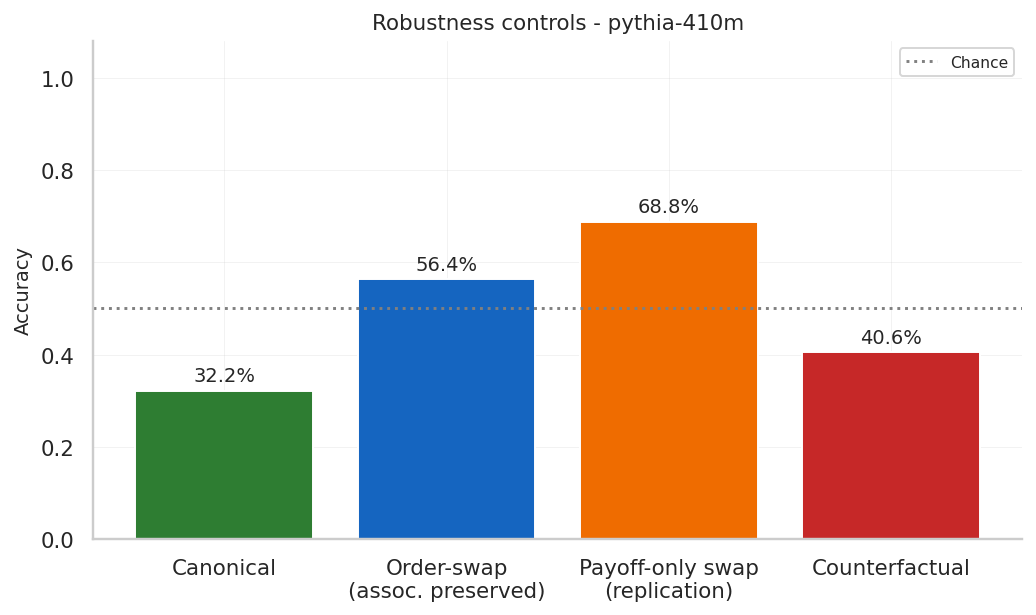

Canonical: 32.2%  Order-swap: 56.4%  Payoff-only swap: 68.8%  Counterfactual: 40.6%

Controls -- qwen2.5-3b-instruct (Qwen/Qwen2.5-3B-Instruct)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

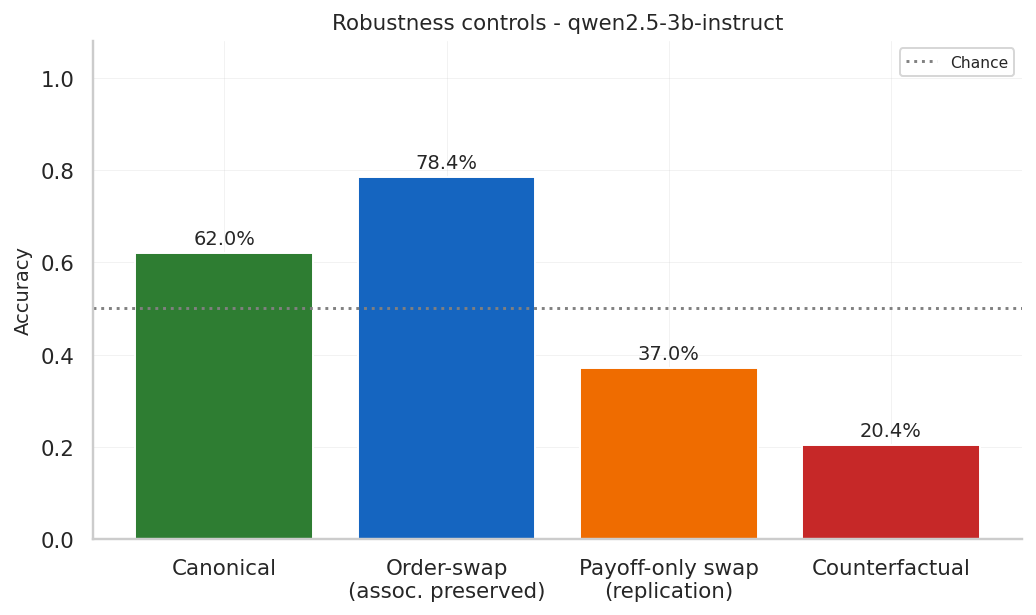

Canonical: 62.0%  Order-swap: 78.4%  Payoff-only swap: 37.0%  Counterfactual: 20.4%


In [60]:
control_pair_ids = subsample_pair_ids(category_pair_ids(PRIMARY_CATEGORY), CONTROL_EVAL_N, seed=SEED + 6)
control_canon = [id_to_instances[i]["canon"] for i in control_pair_ids]
control_counter = [id_to_instances[i]["counter"] for i in control_pair_ids]
order_swap_eval = build_order_swap_control(control_canon)
payoff_swap_eval = build_payoff_only_swap(control_canon)

for model_key in CONTROL_MODELS:
    hf_id = MODEL_REGISTRY[model_key]["hf_id"]
    print(f"\n{'='*70}\nControls -- {model_key} ({hf_id})\n{'='*70}")
    wrapper = RealModelWrapper(hf_id)

    acc_canon = np.mean(predict_correct_mask(wrapper, control_canon))
    acc_order = np.mean(predict_correct_mask(wrapper, order_swap_eval))
    acc_payoff = np.mean(predict_correct_mask(wrapper, payoff_swap_eval))
    acc_counter = np.mean(predict_correct_mask(wrapper, control_counter))

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    conditions = ["Canonical", "Order-swap\n(assoc. preserved)", "Payoff-only swap\n(replication)", "Counterfactual"]
    values = [acc_canon, acc_order, acc_payoff, acc_counter]
    ax.bar(conditions, values, color=["#2E7D32", "#1565C0", "#EF6C00", "#C62828"])
    ax.axhline(0.5, color="gray", linestyle=":", label="Chance")
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)
    ax.set_ylim(0, 1.08); ax.set_ylabel("Accuracy"); ax.set_title(f"Robustness controls - {model_key}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"phase7_controls_{model_key}.png"))
    plt.show()

    print(f"Canonical: {acc_canon:.1%}  Order-swap: {acc_order:.1%}  "
          f"Payoff-only swap: {acc_payoff:.1%}  Counterfactual: {acc_counter:.1%}")
    RESULTS[model_key]["controls"] = dict(canon=acc_canon, order_swap=acc_order, payoff_swap=acc_payoff, counter=acc_counter)

    wrapper.unload()


<a id="discussion"></a>
## 12. Discussion & Limitations

### Reading the results honestly

- **Accuracy gaps, McNemar significance, and Cohen's $d$** (Part I) together tell you
  *whether* a model shows Type II/III interference, how confidently, and how large the
  effect is — three questions a p-value alone conflates. **Scale-vs-severity correlation**
  tells you whether interference gets better or worse with capability — genuinely open
  which direction this goes before you run it. **The base/instruct comparison** tests,
  rather than merely speculates about, whether instruction-tuning changes sensitivity to
  semantic interference on identical weights.
- **The dose-response design (Part D.1) is the paper's first line of defense** against the
  single most damaging review this line of work can receive — "you're just testing
  lexical/moral bias dressed up as game reasoning." A `neutral` baseline near zero effect,
  alongside a monotonic-looking ordering across `valence`/`moral` (and, if activated,
  `social`/`role`/`prestige`), is evidence *for* a dose-response law rather than an
  isolated before/after comparison — though establishing the law rigorously (rather than
  observing a suggestive ordering) requires the full factorial regression discussed under
  Part L.
- **Four independent methodologies now triangulate the same question** from genuinely
  different epistemic angles (the Tier structure in the abstract): behavioral detection
  and three-probe representational detection (Tier 1), logit-lens and depth-indexed
  geometric localization sharing one coordinate system (Tier 2), layer- and
  position-targeted activation patching (Tier 3, with attention dissection as supporting,
  correlational-only evidence), and activation steering (Tier 4). Agreement across these,
  surviving Benjamini-Hochberg correction, would be substantially stronger than any one
  method alone — and *disagreement* between them (e.g., a causal effect at a depth where
  the geometric trajectory shows no distinctive curvature) would itself be a reportable
  result about the limits of any single interpretability technique, not a failure of the
  notebook.

### What this iteration changed, and why

This iteration incorporates a structural review that concluded the previous version's
central risk was **conceptual, not experimental**: six techniques without a stated
epistemic hierarchy reads as a "methodological kitchen sink," and "semantic shortcut" as
a category name pre-empts the very question the notebook is supposed to answer. Concrete
changes:

- **Terminology is now graded** (sensitivity → dependence → causal interference →
  shortcut; Type I/II/III failures), and the word "shortcut" is reserved for instances
  where the full Type III evidentiary bar is actually met.
- **A semantic projection taxonomy (Part C.1) replaces a single valence manipulation** —
  directly answering "isn't this just lexical bias" with a design that can show whether
  effect size tracks semantic salience, rather than asserting it does.
- **A numerical-difficulty factor (Part C.2)** is now measured and stratifiable, not an
  uncontrolled nuisance variable.
- **A `neutral` null-baseline category**, run through the *identical* statistical
  pipeline as every substantive category, gives every other category's effect size a
  calibration point.
- **The geometric analysis (Part H) is redesigned** to index network depth rather than a
  task-specific text segmentation — both more rigorous on its own terms and more directly
  comparable to Phase 1/2's results, addressing a concern that the original design was
  "sophistication... not necessarily scientific value."
- **Attention-head dissection is explicitly demoted** to supporting, correlational
  evidence rather than one of several equally-weighted pillars.
- **Linear probing is now three probes** (payoff-optimal, label valence, model decision),
  not one — distinguishing representation change from semantic dominance from spurious
  correlation, which a single probe accuracy number cannot.
- **Claims are stated more cautiously.** "Rules out" is replaced by "reduces support
  for" throughout Part J; "every causal claim is accompanied by..." is replaced by an
  explicit table naming which of six alternative explanations are addressed, by what, and
  which remain open.

### Positioning relative to concurrent 2026 framing/invariance work

Because this exact problem shape (payoff- or ground-truth-preserving reframing changes LLM
decisions) has been independently approached by at least three other 2026 benchmarks
(*Same Game, Different Story*; *Framing Matters*; *Syntactic framing fragility* — see
Related Work), this notebook should not present the *existence* of the phenomenon as its
main claim; by publication time that existence claim will likely no longer be novel on its
own. CSS-Bench's actual differentiating claims are the **mechanistic** ones the
behavioral-only benchmarks above do not attempt: (i) *where* in network depth the
interference becomes representationally decodable (Part F.3, Part H) and *when* it becomes
causally load-bearing (Part E) — these need not coincide, and disagreement between them is
itself informative (Part 12); (ii) whether the effect is *causal* rather than correlational
via activation patching, not inferred from behavior alone; (iii) whether a targeted,
literature-grounded intervention (steering, ideally conditional per Valentino et al. 2026)
can *remove* it at inference time without retraining and at a measured accuracy cost,
rather than only documenting that it exists; and (iv) the base/instruct controlled
comparison, which isolates one candidate cause (instruction-tuning) that pure behavioral
benchmarks cannot separate from architecture or scale. The abstract and contributions list
(top of notebook) should be revised before submission to lead with (i)-(iv), and to cite
the concurrent work explicitly as the reason a pure existence claim is no longer
sufficient — reviewers who know this literature will ask "so what, we already knew LLMs are
framing-sensitive"; the notebook's answer needs to be visible in the first paragraph, not
recoverable only from Part E onward.

### Threats to validity

- **Single-token label constraint** narrows the usable vocabulary; the cross-model
  intersection could be thin depending on real tokenizer behavior, and is likely thinnest
  for `arbitrary_nonce` specifically (Part C.4 prints a warning if so — this is expected,
  not a bug, and is itself informative about the limits of a lexical control built from
  invented words).
- **Token frequency and length are not controlled** (Part J, alternative explanation #5)
  — an open limitation, not a claim we can currently rule out.
- **Cross-template and cross-game generalization are not tested** in this iteration (Part
  J, alternative explanation #6; Part L) — the entire empirical section uses one Jinja
  template and reports within-template results only.
- **The average-payoff correctness criterion** (Definition 0.1) is a simplification of
  full equilibrium analysis, chosen deliberately so scoring never requires a live
  game-theoretic solve — a real simplification for Chicken and Stag Hunt specifically,
  provably exact for Prisoner's Dilemma (Proposition 0.2).
- **The linear probes (Part F.3) are single logistic-regression models per layer** with no
  regularization-strength search; a more thorough sweep (or a non-linear probe as a
  sanity ceiling) would tighten the claim that any confound found is specifically
  *linear*.
- **Gated model access**: results depend on your Hub account's accepted licenses being
  current at run time; a 403 on one model shouldn't silently break the whole loop, but
  check `RESULTS` for missing keys after a full run.


<a id="program"></a>
## 13. Part L - Beyond CSS-Bench: A Program of Decision-Relevant Invariance Tests

Strategic invariance (Definition 0.4) is a property of decision procedures in general, not
specific to matrix games or to this benchmark. Matrix games are simply an unusually clean
environment to study it in, because the underlying utility structure can be held **exactly**
fixed while its linguistic surface form varies. This section names the concrete next
experiments that would turn CSS-Bench from one case study into evidence for that broader
claim, prioritized in the build order below. Item 3 (unseen-label generalization) is now
implemented in Parts F.3 and G (see 4.5) rather than only described here; the rest still
require genuine execution against real weights first.

**Phase-ordered priority** (each phase's question depends on the previous phase's finding):

1. **Establish the phenomenon** (this notebook, Parts D–J): does semantic interference
   exist, is it specific to semantics (vs. position/construction), and does it scale with
   salience and difficulty?
2. **Kill remaining alternative explanations — IMPLEMENTED (4.6, 4.7).** Token-frequency/
   length-matched label pools (alternative #5) and a second, independently-authored prompt
   template (alternative #6) are both now run as diagnostics, motivated directly by the two
   anomalies documented before Part D — not run speculatively.
3. **Unseen-label generalization — IMPLEMENTED (4.5, Parts F.3 & G).** Each active
   category's word pool is split in half, deterministically, into a fit set and a held-out
   set; probes are trained and `v_drift`/the K-CAST gate are fit only on fit-set words, then
   evaluated on the held-out set, which is never used anywhere upstream. The retained-PGap
   fraction printed at the end of Part F.3, and the same-word-vs-unseen-word steering
   curves in Part G, are the results of this test, not just its description.
4. **Cross-game circuit transfer — IMPLEMENTED (13.1).** A steering vector fit only on
   Prisoner's Dilemma instances is evaluated on held-out Chicken and Stag Hunt instances it
   never saw fit-time. Procedurally-generated novel topologies beyond these three remain
   future work.
5. **Factorial dose-response regression — IMPLEMENTED (13.2).** The joint logistic model
   $P(\text{correct}) = \beta_0 + \beta_1\text{semantic} + \beta_2\text{difficulty} +
   \beta_3(\text{semantic}\times\text{difficulty})$ is fit per model. The fuller
   continuous salience ordering across every category (nonce → neutral → mundane valence →
   moral) still requires activating the currently-inactive categories in
   `ACTIVE_SEMANTIC_CATEGORIES` and remains future work.
6. **Extensions of the invariance framework itself**: temporal invariance (does
   re-ordering payoff-irrelevant narrative context change decisions?), role invariance
   (does swapping which player perspective the model reasons from change decisions when
   the payoffs are symmetric?), and framing invariance (does describing the identical
   decision as a "game" vs. a "business decision" vs. a "policy choice" change behavior?)
   , each a new instantiation of Definition 0.4's transformation $T$, not a new
   theoretical framework.

If a single mechanism (one steering direction, one causally critical depth) is found to
suppress semantic interference across multiple game topologies, multiple semantic
categories, and multiple architecturally distinct models, the resulting claim is no longer
"CSS-Bench found a bias in eight models." It is closer to: **semantic interference in
strategic decision-making is implemented by a reusable computational mechanism, not a
per-benchmark artifact**, the version of this result worth leading a paper with.


### 13.1 Cross-game circuit transfer — IMPLEMENTED (Part L item 4)

`DATASET` already contains all three topologies (Prisoner's Dilemma, Chicken, Stag Hunt) for every category. This was previously unused for anything beyond pooling them together. Here, `v_drift` is fit on Prisoner's Dilemma instances only, then evaluated on Chicken and Stag Hunt instances the vector never saw — no new data generation needed, since the pairs already exist.

In [61]:
TRANSFER_RESULTS = {}
for model_key in ACTIVE_MODELS:
    r = RESULTS.get(model_key, {})
    if r.get("steering_skipped", True) or "critical_layer" not in r:
        print(f"{model_key}: no usable steering vector to test transfer with -- skipped.")
        continue
    wrapper = RealModelWrapper(MODEL_REGISTRY[model_key]["hf_id"])
    critical_layer = r["critical_layer"]

    pd_ids = [i for i in category_pair_ids(PRIMARY_CATEGORY) if id_to_instances[i]["canon"].topology_type == "prisoners_dilemma"]
    pd_ids = subsample_pair_ids(pd_ids, min(STEER_EVAL_N, len(pd_ids)), seed=SEED + 50)
    pd_canon = [id_to_instances[i]["canon"] for i in pd_ids]
    pd_counter = [id_to_instances[i]["counter"] for i in pd_ids]
    pd_wrong_mask = ~predict_correct_mask(wrapper, pd_counter)
    pd_canon_wrong = [c for c, w in zip(pd_canon, pd_wrong_mask) if w]
    pd_counter_wrong = [c for c, w in zip(pd_counter, pd_wrong_mask) if w]

    if len(pd_counter_wrong) < 5:
        print(f"{model_key}: too few PD-only mispredicted instances to fit a transfer-test vector -- skipped.")
        wrapper.unload(); continue

    v_drift_pd = compute_drift_vector(wrapper, pd_canon_wrong, pd_counter_wrong, critical_layer)
    best_alpha = ALPHAS[int(np.argmax(RESULTS[model_key]["steer_acc"]))] if "steer_acc" in r else 1.0

    transfer_row = {"model": model_key}
    for topology in ["chicken", "stag_hunt"]:
        topo_ids = [i for i in category_pair_ids(PRIMARY_CATEGORY) if id_to_instances[i]["canon"].topology_type == topology]
        topo_ids = subsample_pair_ids(topo_ids, min(STEER_EVAL_N, len(topo_ids)), seed=SEED + 51)
        topo_counter = [id_to_instances[i]["counter"] for i in topo_ids]
        acc_unsteered = np.mean(predict_correct_mask(wrapper, topo_counter))
        acc_transferred = eval_accuracy_with_steering(wrapper, topo_counter, critical_layer, best_alpha, v_drift_pd)
        transfer_row[f"{topology}_unsteered"] = acc_unsteered
        transfer_row[f"{topology}_transferred"] = acc_transferred
        print(f"{model_key} -> {topology}: unsteered={acc_unsteered:.1%}, "
              f"PD-fit-vector-transferred={acc_transferred:.1%} "
              f"({'HELPS' if acc_transferred > acc_unsteered + 0.03 else 'no clear transfer'})")
    TRANSFER_RESULTS[model_key] = transfer_row
    wrapper.unload()

if TRANSFER_RESULTS:
    transfer_df = pd.DataFrame(TRANSFER_RESULTS.values())
    transfer_df
else:
    print("No models produced transfer results -- run Part G (steering) first.")

pythia-410m -> chicken: unsteered=53.4%, PD-fit-vector-transferred=91.9% (HELPS)
pythia-410m -> stag_hunt: unsteered=54.0%, PD-fit-vector-transferred=91.8% (HELPS)
llama-3.2-1b -> chicken: unsteered=46.7%, PD-fit-vector-transferred=77.7% (HELPS)
llama-3.2-1b -> stag_hunt: unsteered=47.2%, PD-fit-vector-transferred=80.7% (HELPS)
llama-3.2-1b-instruct -> chicken: unsteered=47.9%, PD-fit-vector-transferred=47.9% (no clear transfer)
llama-3.2-1b-instruct -> stag_hunt: unsteered=49.9%, PD-fit-vector-transferred=49.9% (no clear transfer)
qwen2.5-1.5b-instruct -> chicken: unsteered=41.3%, PD-fit-vector-transferred=71.4% (HELPS)
qwen2.5-1.5b-instruct -> stag_hunt: unsteered=38.4%, PD-fit-vector-transferred=68.7% (HELPS)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

qwen2.5-3b-instruct -> chicken: unsteered=31.8%, PD-fit-vector-transferred=50.3% (HELPS)
qwen2.5-3b-instruct -> stag_hunt: unsteered=25.2%, PD-fit-vector-transferred=51.2% (HELPS)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

gemma-2-2b-it -> chicken: unsteered=45.8%, PD-fit-vector-transferred=98.0% (HELPS)
gemma-2-2b-it -> stag_hunt: unsteered=43.9%, PD-fit-vector-transferred=98.1% (HELPS)


### 13.2 Factorial dose-response regression — IMPLEMENTED (Part L item 5)

Part C's design already instruments semantic category and numerical difficulty (`DIFFICULTY_BUCKET`) per instance; this fits the joint model $P(\text{correct}) = \beta_0 + \beta_1\,\text{semantic} + \beta_2\,\text{difficulty} + \beta_3(\text{semantic}\times\text{difficulty})$ that was previously only described. A significant interaction term means semantic interference and numerical difficulty don't simply add — the model is more (or less) susceptible to the semantic shortcut specifically when the numeric decision is already hard, which is a sharper claim than either main effect alone.

In [62]:
import statsmodels.formula.api as smf

factorial_rows = []
for pid in category_pair_ids(PRIMARY_CATEGORY):
    for projection in ("canon", "counter"):
        inst = id_to_instances[pid][projection]
        factorial_rows.append({
            "pair_id": pid, "projection": projection, "category": inst.semantic_category,
            "difficulty": DIFFICULTY_BUCKET[inst.instance_id], "topology": inst.topology_type,
        })
factorial_df = pd.DataFrame(factorial_rows)

# Attach correctness per model from the already-computed dose-response arrays
# (DOSE_RESPONSE_ROWS, 5.1) rather than re-running any forward passes.
FACTORIAL_FITS = {}
for row in DOSE_RESPONSE_ROWS:
    if row["category"] != PRIMARY_CATEGORY:
        continue
    model_key = row["model"]
    sub = factorial_df.copy()
    n = min(len(row["canon_correct"]), (sub["projection"] == "canon").sum())
    # Build one flat correctness column aligned to canon/counter rows in the
    # SAME order compute_category_accuracy_and_inv iterated category_pair_ids.
    correct_flat = np.concatenate([row["canon_correct"], row["counter_correct"]])
    proj_flat = ["canon"] * len(row["canon_correct"]) + ["counter"] * len(row["counter_correct"])
    ids_flat = list(category_pair_ids(PRIMARY_CATEGORY))[:len(row["canon_correct"])] * 2
    reg_df = pd.DataFrame({"pair_id": ids_flat, "projection": proj_flat, "correct": correct_flat.astype(int)})
    reg_df = reg_df.merge(factorial_df.drop_duplicates(["pair_id", "projection"]), on=["pair_id", "projection"], how="left")
    reg_df["semantic"] = (reg_df["projection"] == "counter").astype(int)  # 1 = counterfactual framing active
    reg_df["difficulty_num"] = reg_df["difficulty"].map({"easy": 0, "medium": 1, "hard": 2})

    try:
        model = smf.logit("correct ~ semantic * difficulty_num", data=reg_df).fit(disp=0)
        FACTORIAL_FITS[model_key] = model
        interaction_p = model.pvalues.get("semantic:difficulty_num", np.nan)
        print(f"{model_key:24s} semantic β={model.params.get('semantic', np.nan):+.3f} (p={model.pvalues.get('semantic', np.nan):.4f})  "
              f"difficulty β={model.params.get('difficulty_num', np.nan):+.3f}  "
              f"interaction β={model.params.get('semantic:difficulty_num', np.nan):+.3f} (p={interaction_p:.4f})"
              f"{'  <- SIGNIFICANT INTERACTION' if interaction_p < 0.05 else ''}")
    except Exception as e:
        print(f"{model_key}: regression failed ({e}) -- likely too little variation in one cell of the design; skipped.")

print("\nReading this table: a significant, negative semantic×difficulty interaction means the semantic")
print("shortcut gets STRONGER exactly where the numeric decision is already close (hard difficulty) --")
print("the reading a strategic-robustness story would predict: models lean on the cheap semantic cue")
print("precisely when the expensive numeric comparison is least conclusive on its own.")

pythia-410m              semantic β=+0.437 (p=0.0000)  difficulty β=+0.075  interaction β=-0.062 (p=0.3592)
llama-3.2-1b             semantic β=+0.085 (p=0.2861)  difficulty β=+0.090  interaction β=-0.094 (p=0.1495)
llama-3.2-1b-instruct    semantic β=+0.288 (p=0.0002)  difficulty β=+0.063  interaction β=-0.092 (p=0.1560)
qwen2.5-1.5b-instruct    semantic β=-0.488 (p=0.0000)  difficulty β=+0.039  interaction β=+0.022 (p=0.7437)
qwen2.5-3b-instruct      semantic β=-1.874 (p=0.0000)  difficulty β=+0.025  interaction β=+0.092 (p=0.2063)
gemma-2-2b-it            semantic β=-0.496 (p=0.0000)  difficulty β=+0.076  interaction β=-0.024 (p=0.7243)

Reading this table: a significant, negative semantic×difficulty interaction means the semantic
shortcut gets STRONGER exactly where the numeric decision is already close (hard difficulty) --
the reading a strategic-robustness story would predict: models lean on the cheap semantic cue
precisely when the expensive numeric comparison is least conclusiv

### 13.3 Probe regularization sweep - appendix ablation

Part F.3's probes use a single fixed `C=1.0`. This sweep checks whether the reported PGap is an artifact of that specific regularization choice, using the same fit/test split already built in Part F.3 for the first active model.

In [63]:
C_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]
_wrapper_creg = RealModelWrapper(MODEL_REGISTRY[ACTIVE_MODELS[0]]["hf_id"])
_r_creg = RESULTS.get(ACTIVE_MODELS[0], {})
if "critical_layer" not in _r_creg:
    print("Run Part E first (need critical_layer) -- skipping C sweep.")
else:
    layer = _r_creg["critical_layer"] + 1
    fit_pool = FIT_PAIR_IDS[PRIMARY_CATEGORY]
    rng = random.Random(SEED + 60)
    perm = list(range(len(fit_pool))); rng.shuffle(perm)
    train_ids = [fit_pool[i] for i in perm[:PROBE_TRAIN_N]]
    test_ids = [fit_pool[i] for i in perm[PROBE_TRAIN_N: PROBE_TRAIN_N + PROBE_TEST_N]]
    tr_canon = [id_to_instances[i]["canon"] for i in train_ids]
    te_canon = [id_to_instances[i]["canon"] for i in test_ids]
    te_counter = [id_to_instances[i]["counter"] for i in test_ids]
    resid_tr, pred_tr = extract_residuals_and_predictions(_wrapper_creg, tr_canon)
    resid_te_c, pred_te_c = extract_residuals_and_predictions(_wrapper_creg, te_canon)
    resid_te_k, pred_te_k = extract_residuals_and_predictions(_wrapper_creg, te_counter)
    y_tr = get_probe_labels(tr_canon, "payoff_optimal", pred_tr)
    y_te_c = get_probe_labels(te_canon, "payoff_optimal", pred_te_c)
    y_te_k = get_probe_labels(te_counter, "payoff_optimal", pred_te_k)
    print(f"{'C':>8s}{'canon_acc':>12s}{'counter_acc':>14s}{'PGap':>10s}")
    for C in C_GRID:
        clf = LogisticRegression(max_iter=500, C=C)
        clf.fit(resid_tr[:, layer, :], y_tr)
        acc_c, acc_k = clf.score(resid_te_c[:, layer, :], y_te_c), clf.score(resid_te_k[:, layer, :], y_te_k)
        print(f"{C:>8.2f}{acc_c:>12.1%}{acc_k:>14.1%}{acc_c-acc_k:>10.3f}")
    print("\nA PGap that's roughly stable across two decades of C is not an artifact of the C=1.0 default.")
_wrapper_creg.unload()

       C   canon_acc   counter_acc      PGap
    0.01      100.0%          0.0%     1.000
    0.10      100.0%          0.0%     1.000
    1.00      100.0%          0.0%     1.000
   10.00      100.0%          0.0%     1.000
  100.00      100.0%          0.0%     1.000

A PGap that's roughly stable across two decades of C is not an artifact of the C=1.0 default.


### 13.4 What goes in the main paper vs. the appendix

For an 8-9 page ICLR body plus unlimited appendix, not everything above should compete for main-text space. Suggested split, reasoned from what each result is *for* — establishing the core claim vs. defending it against a specific objection:

**Main paper (the argument a reader needs in one pass):**
- Part 0 (formal framework) — condensed to the definitions actually used, not the full derivations.
- Part D.1 dose-response figure (Fig. showing gap by category) — the existence claim.
- Part E's patching curve + critical-layer figure — the causal-localization claim.
- Part F.3's 4-panel probe figure (with the unseen-word PGap panel) — the representational claim, already carrying its own generalization evidence in one figure.
- Part G's steering figure, same-word AND unseen-word curves side by side — the intervention claim, shown honestly including the generalization gap between them.
- The Tier-convergence figure (10.x) — the paper's single best summary image.
- Part I's cross-model accuracy-gap bars + base/instruct comparison — the scale/instruction-tuning story.
- Part M's frontier spot-check bars — answers "does this matter at deployed scale" in one glance.
- **The two anomaly writeups above (this section's predecessor) belong in the main text, briefly** — a reviewer respects a paper that explains its own inconsistencies more than one with none visible.

**Appendix (defends against a specific objection, doesn't advance the main argument):**
- Full derivations/propositions from Part 0.
- Attention-head dissection (Part F, BH-significant head table) — supporting detail under the patching claim.
- Position-targeted patching breakdown (`final_only`/`labels_only`/`labels_and_final`) — mechanism detail.
- Part H's raw velocity/curvature curves (the convergence figure already summarizes the conclusion).
- Part J's full falsification table and all four behavioral controls (order-swap, payoff-only-swap, neutral, arbitrary_nonce) — this is the section a determined reviewer reads end-to-end; it belongs whole in the appendix, referenced by one summary sentence in the main text.
- 4.6 frequency/length-matched control and 4.7 cross-template control — appendix, cited from the anomaly paragraph in the main text ("see Appendix X for the control ruling this out").
- 13.1 cross-game transfer and 13.2 factorial regression — appendix, unless either result is surprising enough (a genuinely significant interaction, or transfer that clearly fails) to promote to main text.
- 13.3 probe-C sweep and the K-CAST conditional-steering comparison — appendix ablations proper.
- Power analysis (4.4a) — appendix or a footnote; reviewers who care will look for it, most won't read it in the main text.

**Scaling note.** Only 5 of the 8 registered models were run (`mistral-7b-instruct` and `qwen2.5-7b-instruct` are missing from `ACTIVE_MODELS` in the executed run). The scale-vs-severity claim (Part I, Spearman ρ=0.718, p=0.172 — not significant at n=5) needs the full 7-8 model suite run before it can be reported as anything more than suggestive; p=0.17 on 5 points is not a result to put a trend line on in the main paper as currently run.

<a id="references"></a>
## References

- Akata, E., Schulz, L., Coda-Forno, J., Oh, S. J., Bethge, M., & Schulz, E. (2023).
  Playing repeated games with large language models. *arXiv:2305.16867*.
- Alain, G., & Bengio, Y. (2016). Understanding intermediate layers using linear
  classifier probes. *arXiv:1610.01644*.
- Arditi, A., Obeso, O., Syed, A., Paleka, D., Panickssery, N., Gurnee, W., & Nanda, N.
  (2024). Refusal in language models is mediated by a single direction.
  *arXiv:2406.11717*.
- Belinkov, Y. (2022). Probing classifiers: Promises, shortcomings, and advances.
  *Computational Linguistics*, 48(1), 207–219.
- Fontana, N., Pilati, F., & Scarpa, B. (2024). Nice to meet you! LLMs exhibit strategic
  personas in economic games. *arXiv:2407.06694* (representative of the broader LLM
  economic-games literature this benchmark's motivation draws on).
- Meng, K., Bau, D., Andonian, A., & Belinkov, Y. (2022). Locating and editing factual
  associations in GPT. *NeurIPS 2022*.
- Olsson, C., Elhage, N., Nanda, N., Joseph, N., et al. (2022). In-context learning and
  induction heads. *Transformer Circuits Thread*.
- Rimsky, N., Gabrieli, N., Schulz, J., Tong, M., Hubinger, E., & Turner, A. (2024).
  Steering Llama 2 via contrastive activation addition. *ACL 2024*.
- Turner, A., Thiergart, L., Leech, G., Udell, D., Vazquez, J. J., Mini, U., & MacDiarmid,
  M. (2023). Activation addition: Steering language models without optimization.
  *arXiv:2308.10248*.
- Wang, K., Variengien, A., Conmy, A., Shlegeris, B., & Steinhardt, J. (2023).
  Interpretability in the wild: A circuit for indirect object identification in GPT-2
  small. *ICLR 2023*.
- Zhang, F., & Nanda, N. (2023). Towards best practices of activation patching in
  language models: Metrics and methods. *arXiv:2309.16042*.
- Zhou, Y., Wang, Y., Yin, X., Zhou, S., & Zhang, A. R. (2026). The geometry of
  reasoning: Flowing logics in representation space. *ICLR 2026*.

- Amiri-Margavi, A. (2026). Same Game, Different Story: A Minimal Conservative Strategic
  Robustness Benchmark for Large Language Model Agents. *arXiv:2607.19670*.
- Bertolazzi, L., Gatt, A., & Bernardi, R. (2024). A systematic analysis of large language
  models' syllogistic reasoning capabilities. *arXiv:2406.11341* (content-effects framing
  for belief bias in LLM syllogistic reasoning).
- Dasgupta, I., et al. (2024). Language models show human-like content effects on
  reasoning tasks. *arXiv:2207.07051*.
- Elkins, K., & Chun, J. (2026). Syntactic framing fragility: An audit of robustness in LLM
  ethical decisions. *arXiv:2601.09724*.
- Valentino, M., Kim, G., Dalal, D., Zhao, Z., & Freitas, A. (2025/2026). Mitigating
  content effects on reasoning in language models through fine-grained activation
  steering. *arXiv:2505.12189* (AAAI 2026).
